In [1]:
import sys
import ztf_classifier
import numpy as np
import pandas as pd
import astropy
import sklearn
import xgboost
import lightgbm

print("Python:", sys.version)
print("Executable:", sys.executable)
print("ztf_classifier:", ztf_classifier.__file__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Astropy:", astropy.__version__)
print("Scikit-learn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)
print("LightGBM:", lightgbm.__version__)

Python: 3.11.16 (main, Sep 22 2026, 11:08:44) [GCC 15.2.0]
Executable: /home/saeed92m/projects/ztf-classifier/.venv/bin/python
ztf_classifier: /home/saeed92m/projects/ztf-classifier/src/ztf_classifier/__init__.py
NumPy: 2.4.6
Pandas: 3.0.6
Astropy: 8.0.1
Scikit-learn: 1.9.1
XGBoost: 3.2.0
LightGBM: 4.7.0


In [1]:
import requests

url = "https://irsa.ipac.caltech.edu"

response = requests.get(url, timeout=20)

print("HTTP status:", response.status_code)
print("Connection:", "OK" if response.ok else "FAILED")

HTTP status: 200
Connection: OK


In [3]:
import requests

url = "https://irsa.ipac.caltech.edu/cgi-bin/ZTF/nph_light_curves"

params = {
    "POS": "CIRCLE 298.0025 29.87147 0.0014",
    "BANDNAME": "g",
    "FORMAT": "csv",
}

response = requests.get(url, params=params, timeout=60)

print("HTTP status:", response.status_code)
print("URL:", response.url)
print("Response size:", len(response.content), "bytes")
print()
print(response.text[:1000])

HTTP status: 200
URL: https://irsa.ipac.caltech.edu/cgi-bin/ZTF/nph_light_curves?POS=CIRCLE+298.0025+29.87147+0.0014&BANDNAME=g&FORMAT=csv
Response size: 444947 bytes

oid,expid,hjd,mjd,mag,magerr,catflags,filtercode,ra,dec,chi,sharp,filefracday,field,ccdid,qid,limitmag,magzp,magzprms,clrcoeff,clrcounc,exptime,airmass,programid
686103400034440,45051390,2458205.0120740077,58204.513900500002,17.7238064,0.0294359885,0,zg,298.00252119999999,29.871491800000001,0.47299999,-0.00400000019,20180327513854,686,0x3,0x4,20.5799999,26.3803444,0.0242190044,-0.109299645,1.11619411e-05,30,1.26100004,1
686103400034440,45151402,2458206.0122555234,58205.514027800004,17.6604195,0.0288231708,0,zg,298.00255520000002,29.8714631,1.023,-0.063000001,20180328514028,686,0x3,0x4,20.9699993,26.3073921,0.0181296617,-0.0608760379,6.216374e-06,30,1.24699998,1
686103400034440,45251668,2458207.0149724586,58206.516689800002,17.6593704,0.0288133025,0,zg,298.00253579999998,29.871452699999999,1.45299995,-0.104000002,20180329

In [6]:
import requests

url = "https://irsa.ipac.caltech.edu/cgi-bin/ZTF/nph_light_curves"

params = {
    "ID": "686103400034440",
    "FORMAT": "csv",
}

try:
    response = requests.get(
        url,
        params=params,
        timeout=(10, 120),
        headers={
            "User-Agent": "ztf-classifier/0.1.0"
        },
    )

    print("HTTP status:", response.status_code)
    print("Response size:", len(response.content), "bytes")
    print("Final URL:", response.url)
    print()
    print(response.text[:1000])

except requests.exceptions.RequestException as e:
    print(type(e).__name__)
    print(e)

HTTP status: 200
Response size: 214915 bytes
Final URL: https://irsa.ipac.caltech.edu/cgi-bin/ZTF/nph_light_curves?ID=686103400034440&FORMAT=csv

oid,expid,hjd,mjd,mag,magerr,catflags,filtercode,ra,dec,chi,sharp,filefracday,field,ccdid,qid,limitmag,magzp,magzprms,clrcoeff,clrcounc,exptime,airmass,programid
686103400034440,45051390,2458205.0120740077,58204.513900500002,17.7238064,0.0294359885,0,zg,298.00252119999999,29.871491800000001,0.47299999,-0.00400000019,20180327513854,686,0x3,0x4,20.5799999,26.3803444,0.0242190044,-0.109299645,1.11619411e-05,30,1.26100004,1
686103400034440,45151402,2458206.0122555234,58205.514027800004,17.6604195,0.0288231708,0,zg,298.00255520000002,29.8714631,1.023,-0.063000001,20180328514028,686,0x3,0x4,20.9699993,26.3073921,0.0181296617,-0.0608760379,6.216374e-06,30,1.24699998,1
686103400034440,45251668,2458207.0149724586,58206.516689800002,17.6593704,0.0288133025,0,zg,298.00253579999998,29.871452699999999,1.45299995,-0.104000002,20180329516678,686,0x3,0x4,20.

In [7]:
import pandas as pd
from io import StringIO

# Convert the successful API response to a DataFrame
df = pd.read_csv(StringIO(response.text))

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFilters:")
print(df["filtercode"].value_counts())

print("\nObject IDs:")
print(df["oid"].unique())

print("\nFirst 5 rows:")
display(df.head())

Shape: (838, 24)

Columns:
['oid', 'expid', 'hjd', 'mjd', 'mag', 'magerr', 'catflags', 'filtercode', 'ra', 'dec', 'chi', 'sharp', 'filefracday', 'field', 'ccdid', 'qid', 'limitmag', 'magzp', 'magzprms', 'clrcoeff', 'clrcounc', 'exptime', 'airmass', 'programid']

Filters:
filtercode
zg    838
Name: count, dtype: int64

Object IDs:
[686103400034440]

First 5 rows:


,oid,expid,hjd,mjd,mag,magerr,catflags,filtercode,ra,dec,...,ccdid,qid,limitmag,magzp,magzprms,clrcoeff,clrcounc,exptime,airmass,programid
0,686103400034440,45051390,2.458205e+06,58204.513901,17.723806,0.029436,0,zg,298.002521,29.871492,...,0x3,0x4,20.580000,26.380344,0.024219,-0.109300,0.000011,30,1.261,1
1,686103400034440,45151402,2.458206e+06,58205.514028,17.660419,0.028823,0,zg,298.002555,29.871463,...,0x3,0x4,20.969999,26.307392,0.018130,-0.060876,0.000006,30,1.247,1
2,686103400034440,45251668,2.458207e+06,58206.516690,17.659370,0.028813,0,zg,298.002536,29.871453,...,0x3,0x4,20.389999,26.109283,0.018583,-0.060469,0.000006,30,1.222,1
3,686103400034440,45252553,2.458207e+06,58206.525532,17.648050,0.028707,0,zg,298.002556,29.871470,...,0x3,0x4,20.740000,26.333904,0.017060,-0.061754,0.000006,30,1.186,1
4,686103400034440,45350884,2.458208e+06,58207.508843,17.632879,0.028567,0,zg,298.002551,29.871461,...,0x3,0x4,20.170000,26.335695,0.022384,-0.048380,0.000009,30,1.246,1


In [8]:
# Basic ZTF quality inspection

print("Total observations:", len(df))

print("\ncatflags distribution:")
print(df["catflags"].value_counts(dropna=False))

print("\nMissing values:")
print(df[["mjd", "mag", "magerr", "catflags"]].isna().sum())

print("\nMagnitude statistics:")
print(df["mag"].describe())

print("\nMagnitude-error statistics:")
print(df["magerr"].describe())

print("\nMJD range:")
print(df["mjd"].min(), "→", df["mjd"].max())

print("\nTime baseline:")
print(df["mjd"].max() - df["mjd"].min(), "days")

Total observations: 838

catflags distribution:
catflags
0        724
32768    113
32769      1
Name: count, dtype: int64

Missing values:
mjd         0
mag         0
magerr      0
catflags    0
dtype: int64

Magnitude statistics:
count    838.000000
mean      17.709491
std        0.076430
min       17.028065
25%       17.669176
50%       17.709690
75%       17.753496
max       18.075029
Name: mag, dtype: float64

Magnitude-error statistics:
count    838.000000
mean       0.029319
std        0.000742
min        0.024208
25%        0.028906
50%        0.029297
75%        0.029734
max        0.033495
Name: magerr, dtype: float64

MJD range:
58204.5139005 → 60948.2782639

Time baseline:
2743.764363399998 days


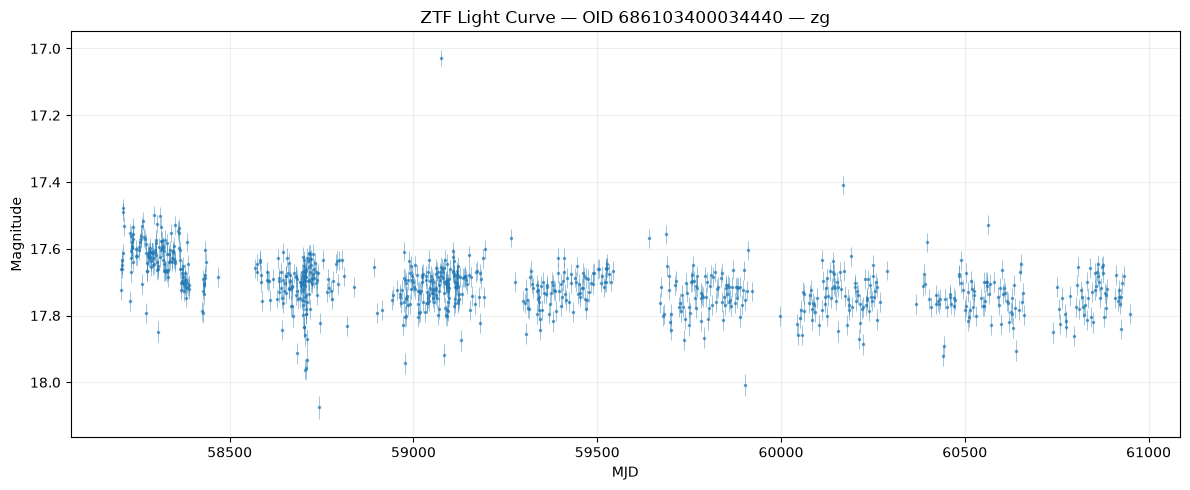

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.errorbar(
    df["mjd"],
    df["mag"],
    yerr=df["magerr"],
    fmt=".",
    markersize=3,
    alpha=0.6,
    elinewidth=0.5,
)

plt.gca().invert_yaxis()

plt.xlabel("MJD")
plt.ylabel("Magnitude")
plt.title(f"ZTF Light Curve — OID {df['oid'].iloc[0]} — zg")

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [11]:
import requests
from io import StringIO
import pandas as pd

url = "https://irsa.ipac.caltech.edu/cgi-bin/ZTF/nph_light_curves"

params = {
    "POS": "CIRCLE 298.0025 29.87147 0.0014",
    "BANDNAME": "g,r",
    "FORMAT": "csv",
}

response = requests.get(
    url,
    params=params,
    timeout=(10, 120),
    headers={"User-Agent": "ztf-classifier/0.1.0"},
)

print("HTTP status:", response.status_code)
print("Response size:", len(response.content), "bytes")

df_gr = pd.read_csv(StringIO(response.text))

print("Shape:", df_gr.shape)
print("\nFilters:")
print(df_gr["filtercode"].value_counts())

print("\nObjects:")
print(df_gr["oid"].nunique())

HTTP status: 200
Response size: 1043892 bytes
Shape: (4074, 24)

Filters:
filtercode
zr    2341
zg    1733
Name: count, dtype: int64

Objects:
7


In [17]:
# Find objects that have observations in both zg and zr
filter_counts = (
    df_gr.groupby(["oid", "filtercode"])
    .size()
    .unstack(fill_value=0)
)

print(filter_counts.head())

common_oids = filter_counts[
    (filter_counts.get("zg", 0) > 0) &
    (filter_counts.get("zr", 0) > 0)
].index

print("\nObjects with both zg and zr:", len(common_oids))

if len(common_oids) > 0:
    target_oid = common_oids[0]
    print("Selected OID:", target_oid)
    print(filter_counts.loc[target_oid])

filtercode         zg    zr
oid                        
686103400034440   838     0
686103400106565   851     0
686203400035219     0  1119
686203400078711     0  1112
1684111300073857   44     0

Objects with both zg and zr: 0


In [18]:
# Unique sky positions in each filter
g_objects = (
    df_gr[df_gr["filtercode"] == "zg"]
    [["oid", "ra", "dec"]]
    .drop_duplicates("oid")
    .reset_index(drop=True)
)

r_objects = (
    df_gr[df_gr["filtercode"] == "zr"]
    [["oid", "ra", "dec"]]
    .drop_duplicates("oid")
    .reset_index(drop=True)
)

print("g objects:", len(g_objects))
print("r objects:", len(r_objects))

print("\nFirst g objects:")
display(g_objects.head())

print("\nFirst r objects:")
display(r_objects.head())

g objects: 3
r objects: 4

First g objects:


,oid,ra,dec
0,686103400034440,298.002521,29.871492
1,686103400106565,298.003728,29.870640
2,1684111300073857,298.002521,29.871488



First r objects:


,oid,ra,dec
0,686203400035219,298.002533,29.871466
1,686203400078711,298.003754,29.870624
2,1684211300083768,298.002473,29.871606
3,1684211300120167,298.003694,29.870763


In [22]:
from astropy.coordinates import SkyCoord
import astropy.units as u

g_coord = SkyCoord(
    ra=g_objects["ra"].to_numpy() * u.deg,
    dec=g_objects["dec"].to_numpy() * u.deg,
)

r_coord = SkyCoord(
    ra=r_objects["ra"].to_numpy() * u.deg,
    dec=r_objects["dec"].to_numpy() * u.deg,
)

idx, sep2d, _ = g_coord.match_to_catalog_sky(r_coord)

matches = g_objects.copy()

matches["r_oid"] = r_objects.iloc[idx]["oid"].to_numpy()
matches["r_ra"] = r_objects.iloc[idx]["ra"].to_numpy()
matches["r_dec"] = r_objects.iloc[idx]["dec"].to_numpy()
matches["separation_arcsec"] = sep2d.arcsec

matches = matches.sort_values("separation_arcsec")

display(matches)

,oid,ra,dec,r_oid,r_ra,r_dec,separation_arcsec
2,1684111300073857,298.002521,29.871488,686203400035219,298.002533,29.871466,0.087157
0,686103400034440,298.002521,29.871492,686203400035219,298.002533,29.871466,0.100137
1,686103400106565,298.003728,29.870640,686203400078711,298.003754,29.870624,0.101680


In [23]:
from astropy.coordinates import search_around_sky

idx_g, idx_r, sep2d, _ = search_around_sky(
    g_coord,
    r_coord,
    seplimit=1 * u.arcsec,
)

all_matches = pd.DataFrame({
    "g_oid": g_objects.iloc[idx_g]["oid"].to_numpy(),
    "r_oid": r_objects.iloc[idx_r]["oid"].to_numpy(),
    "separation_arcsec": sep2d.arcsec,
})

all_matches = all_matches.sort_values("separation_arcsec")

display(all_matches)

,g_oid,r_oid,separation_arcsec
4,1684111300073857,686203400035219,0.087157
0,686103400034440,686203400035219,0.100137
2,686103400106565,686203400078711,0.101680
1,686103400034440,1684211300083768,0.438484
5,1684111300073857,1684211300083768,0.451708
3,686103400106565,1684211300120167,0.454920


In [24]:
g_oid = 686103400106565
r_oid = 686203400078711

g_lc = df_gr[df_gr["oid"] == g_oid].copy()
r_lc = df_gr[df_gr["oid"] == r_oid].copy()

g_lc = g_lc.sort_values("mjd").reset_index(drop=True)
r_lc = r_lc.sort_values("mjd").reset_index(drop=True)

print("g observations:", len(g_lc))
print("r observations:", len(r_lc))

print("\ng time range:")
print(g_lc["mjd"].min(), "→", g_lc["mjd"].max())

print("\nr time range:")
print(r_lc["mjd"].min(), "→", r_lc["mjd"].max())

g observations: 851
r observations: 1112

g time range:
58204.5139005 → 60948.2782639

r time range:
58217.489294 → 60948.1725


In [25]:
print("========== G BAND ==========")
print(g_lc[["mag", "magerr", "catflags"]].describe())

print("\ncatflags:")
print(g_lc["catflags"].value_counts(dropna=False))


print("\n========== R BAND ==========")
print(r_lc[["mag", "magerr", "catflags"]].describe())

print("\ncatflags:")
print(r_lc["catflags"].value_counts(dropna=False))

========== G BAND ==========
              mag      magerr      catflags
count  851.000000  851.000000    851.000000
mean    17.028474    0.024214   4736.151586
std      0.044044    0.000222  11529.063871
min     16.378830    0.021417      0.000000
25%     17.013572    0.024128      0.000000
50%     17.030716    0.024222      0.000000
75%     17.045850    0.024307      0.000000
max     17.226883    0.025405  32769.000000

catflags:
catflags
0        728
32768    122
32769      1
Name: count, dtype: int64

========== R BAND ==========
               mag       magerr      catflags
count  1112.000000  1112.000000   1112.000000
mean     16.275125     0.020141   3447.715827
std       0.052519     0.000172  10058.777068
min      15.667788     0.018806      0.000000
25%      16.255928     0.020083      0.000000
50%      16.273390     0.020132      0.000000
75%      16.290422     0.020181      0.000000
max      17.141178     0.023888  32769.000000

catflags:
catflags
0        993
32768    115


In [26]:
import pandas as pd

def flag_summary(df, band):
    summary = (
        df.groupby("catflags")
        .agg(
            observations=("mag", "size"),
            mag_mean=("mag", "mean"),
            mag_std=("mag", "std"),
            magerr_mean=("magerr", "mean"),
            magerr_std=("magerr", "std"),
        )
        .reset_index()
        .sort_values("catflags")
    )

    summary["fraction"] = (
        summary["observations"] / len(df)
    )

    print(f"\n========== {band} FLAG SUMMARY ==========")
    display(summary)


flag_summary(g_lc, "ZG")
flag_summary(r_lc, "ZR")


========== ZG FLAG SUMMARY ==========


,catflags,observations,mag_mean,mag_std,magerr_mean,magerr_std,fraction
0,0,728,17.030369,0.021445,0.024221,0.000119,0.855464
1,32768,122,17.020209,0.098157,0.024184,0.000485,0.143361
2,32769,1,16.657301,NaN,0.022438,NaN,0.001175



========== ZR FLAG SUMMARY ==========


,catflags,observations,mag_mean,mag_std,magerr_mean,magerr_std,fraction
0,0,993,16.274341,0.023511,0.020136,0.000067,0.892986
1,1,2,16.260516,0.003624,0.020096,0.000010,0.001799
2,32768,115,16.283841,0.146761,0.020192,0.000494,0.103417
3,32769,2,16.177565,0.178473,0.019890,0.000467,0.001799


In [27]:
for band, df in [("ZG", g_lc), ("ZR", r_lc)]:
    flagged = df[df["catflags"] != 0]

    print(f"\n========== {band} FLAGGED OBSERVATIONS ==========")
    print("Count:", len(flagged))
    print("Fraction:", len(flagged) / len(df))

    print("\nMagnitude range:")
    print(flagged["mag"].min(), "→", flagged["mag"].max())

    print("\nMagnitude error range:")
    print(flagged["magerr"].min(), "→", flagged["magerr"].max())


========== ZG FLAGGED OBSERVATIONS ==========
Count: 123
Fraction: 0.1445358401880141

Magnitude range:
16.37883 → 17.2268829

Magnitude error range:
0.021417262 → 0.0254050251

========== ZR FLAGGED OBSERVATIONS ==========
Count: 119
Fraction: 0.10701438848920863

Magnitude range:
15.6677876 → 17.1411781

Magnitude error range:
0.018805692 → 0.0238882415


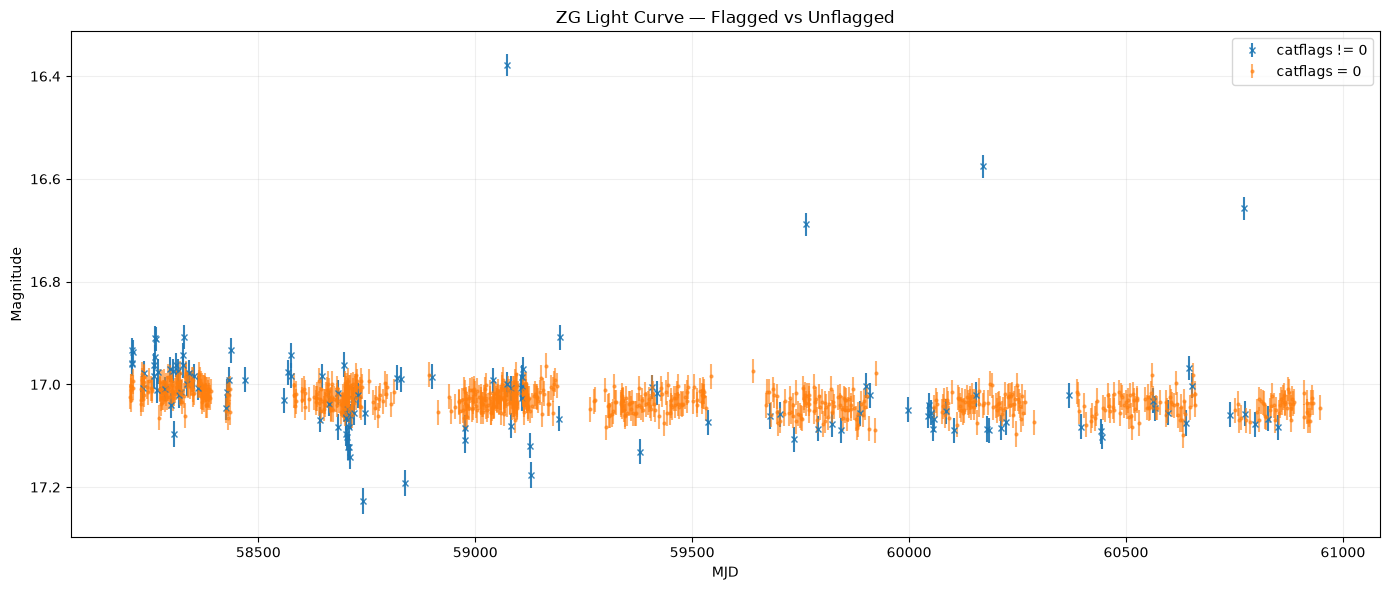

In [28]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))

for flags, group in g_lc.groupby(g_lc["catflags"] == 0):
    if flags:
        label = "catflags = 0"
        marker = "."
        alpha = 0.6
    else:
        label = "catflags != 0"
        marker = "x"
        alpha = 0.9

    ax.errorbar(
        group["mjd"],
        group["mag"],
        yerr=group["magerr"],
        fmt=marker,
        markersize=4,
        alpha=alpha,
        label=label,
    )

ax.invert_yaxis()
ax.set_xlabel("MJD")
ax.set_ylabel("Magnitude")
ax.set_title("ZG Light Curve — Flagged vs Unflagged")
ax.grid(alpha=0.2)
ax.legend()

plt.tight_layout()
plt.show()

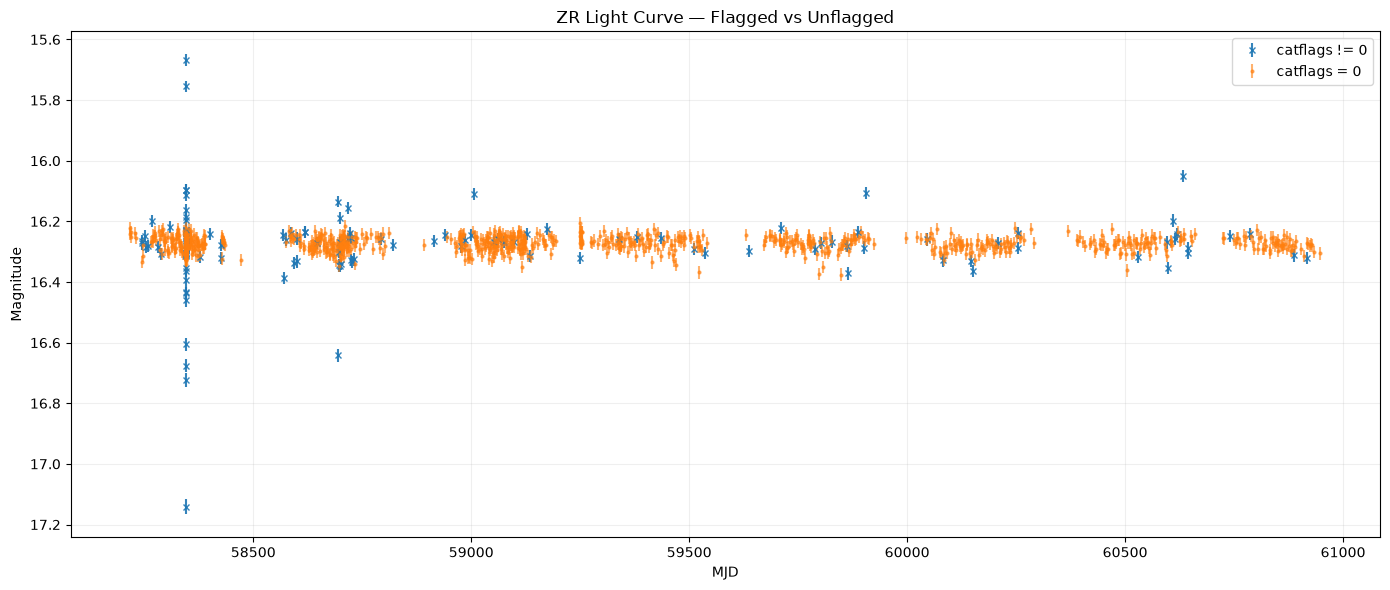

In [29]:
fig, ax = plt.subplots(figsize=(14, 6))

for flags, group in r_lc.groupby(r_lc["catflags"] == 0):
    if flags:
        label = "catflags = 0"
        marker = "."
        alpha = 0.6
    else:
        label = "catflags != 0"
        marker = "x"
        alpha = 0.9

    ax.errorbar(
        group["mjd"],
        group["mag"],
        yerr=group["magerr"],
        fmt=marker,
        markersize=4,
        alpha=alpha,
        label=label,
    )

ax.invert_yaxis()
ax.set_xlabel("MJD")
ax.set_ylabel("Magnitude")
ax.set_title("ZR Light Curve — Flagged vs Unflagged")
ax.grid(alpha=0.2)
ax.legend()

plt.tight_layout()
plt.show()

In [31]:
import numpy as np
import pandas as pd

def validate_lightcurve(df, required_columns=None):
    """
    Basic structural and numerical validation for a ZTF light curve.
    Does not remove rows.
    """
    if required_columns is None:
        required_columns = ["mjd", "mag", "magerr", "catflags"]

    missing_columns = [
        col for col in required_columns
        if col not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Missing required columns: {missing_columns}"
        )

    report = {
        "input_rows": len(df),
        "missing_mjd": int(df["mjd"].isna().sum()),
        "missing_mag": int(df["mag"].isna().sum()),
        "missing_magerr": int(df["magerr"].isna().sum()),
        "missing_catflags": int(df["catflags"].isna().sum()),
        "nonfinite_mjd": int(
            (~np.isfinite(df["mjd"])).sum()
        ),
        "nonfinite_mag": int(
            (~np.isfinite(df["mag"])).sum()
        ),
        "nonfinite_magerr": int(
            (~np.isfinite(df["magerr"])).sum()
        ),
        "nonpositive_magerr": int(
            (df["magerr"] <= 0).sum()
        ),
    }

    return report

In [32]:
g_validation = validate_lightcurve(g_lc)
r_validation = validate_lightcurve(r_lc)

print("========== ZG VALIDATION ==========")
print(g_validation)

print("\n========== ZR VALIDATION ==========")
print(r_validation)

========== ZG VALIDATION ==========
{'input_rows': 851, 'missing_mjd': 0, 'missing_mag': 0, 'missing_magerr': 0, 'missing_catflags': 0, 'nonfinite_mjd': 0, 'nonfinite_mag': 0, 'nonfinite_magerr': 0, 'nonpositive_magerr': 0}

========== ZR VALIDATION ==========
{'input_rows': 1112, 'missing_mjd': 0, 'missing_mag': 0, 'missing_magerr': 0, 'missing_catflags': 0, 'nonfinite_mjd': 0, 'nonfinite_mag': 0, 'nonfinite_magerr': 0, 'nonpositive_magerr': 0}


In [33]:
def apply_quality_mask(df):
    """
    Apply the initial strict-clean quality mask.

    Policy:
    - finite MJD
    - finite magnitude
    - finite magnitude uncertainty
    - positive magnitude uncertainty
    - catflags == 0

    No sigma clipping is applied here.
    """
    mask = (
        np.isfinite(df["mjd"])
        & np.isfinite(df["mag"])
        & np.isfinite(df["magerr"])
        & (df["magerr"] > 0)
        & (df["catflags"] == 0)
    )

    clean = (
        df.loc[mask]
        .copy()
        .sort_values("mjd")
        .reset_index(drop=True)
    )

    qc = {
        "input_rows": len(df),
        "output_rows": len(clean),
        "removed_rows": len(df) - len(clean),
        "retained_fraction": len(clean) / len(df),
    }

    return clean, qc

In [34]:
g_clean, g_qc = apply_quality_mask(g_lc)
r_clean, r_qc = apply_quality_mask(r_lc)

print("========== ZG QUALITY CONTROL ==========")
print(g_qc)

print("\n========== ZR QUALITY CONTROL ==========")
print(r_qc)

========== ZG QUALITY CONTROL ==========
{'input_rows': 851, 'output_rows': 728, 'removed_rows': 123, 'retained_fraction': 0.8554641598119859}

========== ZR QUALITY CONTROL ==========
{'input_rows': 1112, 'output_rows': 993, 'removed_rows': 119, 'retained_fraction': 0.8929856115107914}


In [35]:
print("========== CLEAN ZG ==========")
print(g_clean[["mjd", "mag", "magerr", "catflags"]].describe())

print("\n========== CLEAN ZR ==========")
print(r_clean[["mjd", "mag", "magerr", "catflags"]].describe())

========== CLEAN ZG ==========
                mjd         mag      magerr  catflags
count    728.000000  728.000000  728.000000     728.0
mean   59364.675103   17.030369    0.024221       0.0
std      788.644484    0.021445    0.000119       0.0
min    58204.513901   16.963371    0.023859       0.0
25%    58705.385764   17.016178    0.024142       0.0
50%    59144.193895   17.030876    0.024223       0.0
75%    59957.734760   17.043929    0.024296       0.0
max    60948.278264   17.098568    0.024610       0.0

========== CLEAN ZR ==========
                mjd         mag      magerr  catflags
count    993.000000  993.000000  993.000000     993.0
mean   59172.781699   16.274341    0.020136       0.0
std      806.269881    0.023511    0.000067       0.0
min    58217.489294   16.206932    0.019949       0.0
25%    58346.296725   16.256453    0.020084       0.0
50%    59043.280995   16.273743    0.020133       0.0
75%    59774.384271   16.289207    0.020178       0.0
max    60948.172500

In [36]:
print("ZG flags after cleaning:")
print(g_clean["catflags"].value_counts())

print("\nZR flags after cleaning:")
print(r_clean["catflags"].value_counts())

ZG flags after cleaning:
catflags
0    728
Name: count, dtype: int64

ZR flags after cleaning:
catflags
0    993
Name: count, dtype: int64


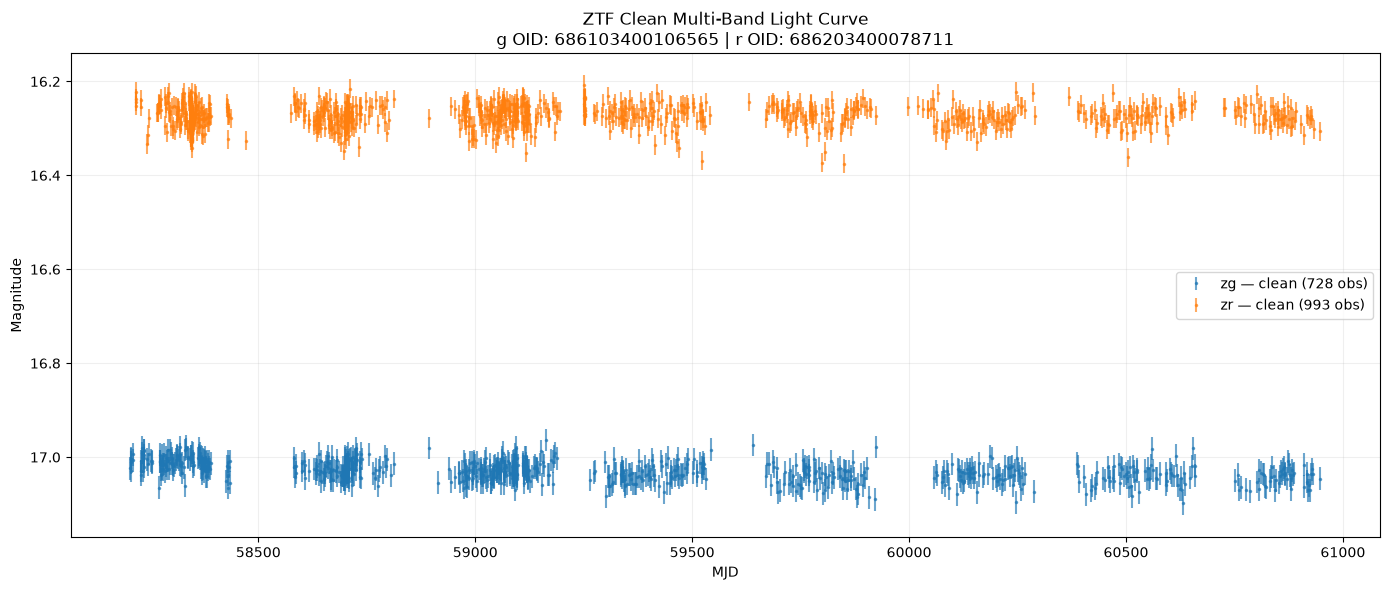

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.errorbar(
    g_clean["mjd"],
    g_clean["mag"],
    yerr=g_clean["magerr"],
    fmt=".",
    markersize=3,
    alpha=0.65,
    label=f"zg — clean ({len(g_clean)} obs)",
)

plt.errorbar(
    r_clean["mjd"],
    r_clean["mag"],
    yerr=r_clean["magerr"],
    fmt=".",
    markersize=3,
    alpha=0.65,
    label=f"zr — clean ({len(r_clean)} obs)",
)

plt.gca().invert_yaxis()

plt.xlabel("MJD")
plt.ylabel("Magnitude")
plt.title(
    f"ZTF Clean Multi-Band Light Curve\n"
    f"g OID: {g_oid} | r OID: {r_oid}"
)

plt.grid(alpha=0.2)
plt.legend()

plt.tight_layout()
plt.show()

In [38]:
import numpy as np
import pandas as pd


def mad(x):
    """Median Absolute Deviation."""
    x = np.asarray(x, dtype=float)
    median = np.median(x)
    return np.median(np.abs(x - median))


def weighted_mean(values, errors):
    """Inverse-variance weighted mean."""
    values = np.asarray(values, dtype=float)
    errors = np.asarray(errors, dtype=float)

    weights = 1.0 / np.square(errors)

    return np.sum(weights * values) / np.sum(weights)


def extract_band_features(df, band):
    """
    Extract basic statistical features from one cleaned ZTF band.
    """

    mag = df["mag"].to_numpy(dtype=float)
    magerr = df["magerr"].to_numpy(dtype=float)
    mjd = df["mjd"].to_numpy(dtype=float)

    features = {
        f"n_obs_{band}": len(df),

        f"baseline_days_{band}":
            mjd.max() - mjd.min(),

        f"mean_mag_{band}":
            np.mean(mag),

        f"median_mag_{band}":
            np.median(mag),

        f"weighted_mean_mag_{band}":
            weighted_mean(mag, magerr),

        f"std_mag_{band}":
            np.std(mag, ddof=1),

        f"mad_mag_{band}":
            mad(mag),

        f"min_mag_{band}":
            np.min(mag),

        f"max_mag_{band}":
            np.max(mag),

        f"amplitude_mag_{band}":
            np.max(mag) - np.min(mag),

        f"p05_mag_{band}":
            np.percentile(mag, 5),

        f"p25_mag_{band}":
            np.percentile(mag, 25),

        f"p75_mag_{band}":
            np.percentile(mag, 75),

        f"p95_mag_{band}":
            np.percentile(mag, 95),

        f"mean_magerr_{band}":
            np.mean(magerr),

        f"median_magerr_{band}":
            np.median(magerr),
    }

    return features

In [39]:
g_features = extract_band_features(g_clean, "g")
r_features = extract_band_features(r_clean, "r")

features = {
    **g_features,
    **r_features,
}

features_df = pd.DataFrame([features])

features_df

,n_obs_g,baseline_days_g,mean_mag_g,median_mag_g,weighted_mean_mag_g,std_mag_g,mad_mag_g,min_mag_g,max_mag_g,amplitude_mag_g,...,mad_mag_r,min_mag_r,max_mag_r,amplitude_mag_r,p05_mag_r,p25_mag_r,p75_mag_r,p95_mag_r,mean_magerr_r,median_magerr_r
0,728,2743.764363,17.030369,17.030876,17.030158,0.021445,0.01379,16.963371,17.098568,0.135197,...,0.016464,16.206932,16.375332,0.1684,16.239626,16.256453,16.289207,16.314196,0.020136,0.020133


In [40]:
features_df["mean_color_g_r"] = (
    features_df["mean_mag_g"]
    - features_df["mean_mag_r"]
)

features_df["median_color_g_r"] = (
    features_df["median_mag_g"]
    - features_df["median_mag_r"]
)

In [41]:
features_df[
    [
        "mean_color_g_r",
        "median_color_g_r",
        "mean_mag_g",
        "mean_mag_r",
    ]
]

,mean_color_g_r,median_color_g_r,mean_mag_g,mean_mag_r
0,0.756027,0.757134,17.030369,16.274341


In [42]:
features_df["variability_ratio_g"] = (
    features_df["std_mag_g"]
    / features_df["mean_magerr_g"]
)

features_df["variability_ratio_r"] = (
    features_df["std_mag_r"]
    / features_df["mean_magerr_r"]
)

In [43]:
features_df[
    [
        "std_mag_g",
        "mean_magerr_g",
        "variability_ratio_g",
        "std_mag_r",
        "mean_magerr_r",
        "variability_ratio_r",
    ]
]

,std_mag_g,mean_magerr_g,variability_ratio_g,std_mag_r,mean_magerr_r,variability_ratio_r
0,0.021445,0.024221,0.88537,0.023511,0.020136,1.167608


In [44]:
# ============================================================
# FEATURE ENGINEERING v0.1
# ZTF Classifier — First Object Feature Vector
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Basic statistical helper functions
# ------------------------------------------------------------

def mad(x):
    """Median Absolute Deviation."""
    x = np.asarray(x, dtype=float)

    median = np.median(x)

    return np.median(np.abs(x - median))


def weighted_mean(values, errors):
    """Inverse-variance weighted mean."""

    values = np.asarray(values, dtype=float)
    errors = np.asarray(errors, dtype=float)

    weights = 1.0 / np.square(errors)

    return np.sum(weights * values) / np.sum(weights)


# ------------------------------------------------------------
# 2. Extract features from one photometric band
# ------------------------------------------------------------

def extract_band_features(df, band):
    """
    Extract basic statistical features from one cleaned
    ZTF light curve.

    Parameters
    ----------
    df : pandas.DataFrame
        Cleaned ZTF light curve.

    band : str
        Band identifier, e.g. "g" or "r".

    Returns
    -------
    dict
        Feature dictionary for the selected band.
    """

    mag = df["mag"].to_numpy(dtype=float)
    magerr = df["magerr"].to_numpy(dtype=float)
    mjd = df["mjd"].to_numpy(dtype=float)

    features = {

        # Observation statistics
        f"n_obs_{band}":
            len(df),

        f"baseline_days_{band}":
            mjd.max() - mjd.min(),

        # Central tendency
        f"mean_mag_{band}":
            np.mean(mag),

        f"median_mag_{band}":
            np.median(mag),

        f"weighted_mean_mag_{band}":
            weighted_mean(mag, magerr),

        # Dispersion / variability
        f"std_mag_{band}":
            np.std(mag, ddof=1),

        f"mad_mag_{band}":
            mad(mag),

        # Range
        f"min_mag_{band}":
            np.min(mag),

        f"max_mag_{band}":
            np.max(mag),

        f"amplitude_mag_{band}":
            np.max(mag) - np.min(mag),

        # Percentiles
        f"p05_mag_{band}":
            np.percentile(mag, 5),

        f"p25_mag_{band}":
            np.percentile(mag, 25),

        f"p75_mag_{band}":
            np.percentile(mag, 75),

        f"p95_mag_{band}":
            np.percentile(mag, 95),

        # Photometric uncertainty
        f"mean_magerr_{band}":
            np.mean(magerr),

        f"median_magerr_{band}":
            np.median(magerr),
    }

    return features


# ------------------------------------------------------------
# 3. Extract ZG + ZR features
# ------------------------------------------------------------

g_features = extract_band_features(g_clean, "g")
r_features = extract_band_features(r_clean, "r")

features = {
    **g_features,
    **r_features,
}

features_df = pd.DataFrame([features])


# ------------------------------------------------------------
# 4. Summary color features
# ------------------------------------------------------------

features_df["mean_color_g_r"] = (
    features_df["mean_mag_g"]
    - features_df["mean_mag_r"]
)

features_df["median_color_g_r"] = (
    features_df["median_mag_g"]
    - features_df["median_mag_r"]
)


# ------------------------------------------------------------
# 5. Variability-to-photometric-error ratio
# ------------------------------------------------------------

features_df["variability_ratio_g"] = (
    features_df["std_mag_g"]
    / features_df["mean_magerr_g"]
)

features_df["variability_ratio_r"] = (
    features_df["std_mag_r"]
    / features_df["mean_magerr_r"]
)


# ------------------------------------------------------------
# 6. Display complete feature vector
# ------------------------------------------------------------

print("=" * 70)
print("ZTF CLASSIFIER — FEATURE VECTOR v0.1")
print("=" * 70)

print(f"\nNumber of features: {features_df.shape[1]}")
print(f"Number of objects:  {features_df.shape[0]}")

display(features_df.T)

ZTF CLASSIFIER — FEATURE VECTOR v0.1

Number of features: 36
Number of objects:  1


,0
n_obs_g,728.000000
baseline_days_g,2743.764363
mean_mag_g,17.030369
median_mag_g,17.030876
weighted_mean_mag_g,17.030158
std_mag_g,0.021445
mad_mag_g,0.013790
min_mag_g,16.963371
max_mag_g,17.098568
amplitude_mag_g,0.135197


In [45]:
from scipy.stats import skew, kurtosis


def extract_advanced_variability_features(df, band):
    """
    Extract additional robust variability features
    from a cleaned ZTF light curve.
    """

    mag = df["mag"].to_numpy(dtype=float)
    magerr = df["magerr"].to_numpy(dtype=float)

    q05, q25, q50, q75, q95 = np.percentile(
        mag,
        [5, 25, 50, 75, 95]
    )

    features = {

        # Robust spread
        f"iqr_mag_{band}":
            q75 - q25,

        f"p95_p05_range_{band}":
            q95 - q05,

        # Distribution shape
        f"skewness_mag_{band}":
            skew(mag, bias=False),

        f"kurtosis_mag_{band}":
            kurtosis(mag, fisher=True, bias=False),

        # RMS around mean
        f"rms_mag_{band}":
            np.sqrt(np.mean(
                (mag - np.mean(mag)) ** 2
            )),

        # Mean squared normalized residual
        f"reduced_chi2_like_{band}":
            np.mean(
                ((mag - np.mean(mag)) / magerr) ** 2
            ),

        # Median normalized residual
        f"median_abs_normalized_residual_{band}":
            np.median(
                np.abs(
                    (mag - np.median(mag)) / magerr
                )
            ),
    }

    return features

In [46]:
g_advanced = extract_advanced_variability_features(
    g_clean,
    "g"
)

r_advanced = extract_advanced_variability_features(
    r_clean,
    "r"
)

advanced_features = {
    **g_advanced,
    **r_advanced,
}

advanced_features_df = pd.DataFrame(
    [advanced_features]
)

display(advanced_features_df.T)

,0
iqr_mag_g,0.027751
p95_p05_range_g,0.071318
skewness_mag_g,0.004370
kurtosis_mag_g,-0.000718
rms_mag_g,0.021430
reduced_chi2_like_g,0.782804
median_abs_normalized_residual_g,0.569665
iqr_mag_r,0.032755
p95_p05_range_r,0.074570
skewness_mag_r,0.493404


In [47]:
features_df = pd.concat(
    [
        features_df,
        advanced_features_df
    ],
    axis=1
)

print("=" * 70)
print("ZTF CLASSIFIER — FEATURE VECTOR v0.2")
print("=" * 70)

print(f"\nNumber of features: {features_df.shape[1]}")

display(features_df.T)

ZTF CLASSIFIER — FEATURE VECTOR v0.2

Number of features: 50


,0
n_obs_g,728.000000
baseline_days_g,2743.764363
mean_mag_g,17.030369
median_mag_g,17.030876
weighted_mean_mag_g,17.030158
std_mag_g,0.021445
mad_mag_g,0.013790
min_mag_g,16.963371
max_mag_g,17.098568
amplitude_mag_g,0.135197


In [48]:
from astropy.timeseries import LombScargle
import numpy as np
import pandas as pd


def lomb_scargle_features(
    df,
    band,
    min_period_days=0.05,
    max_period_days=None,
    samples_per_peak=5,
):
    """
    Extract basic Lomb-Scargle periodicity features
    from a cleaned ZTF light curve.

    Parameters
    ----------
    df : pandas.DataFrame
        Cleaned light curve.

    band : str
        Band name, e.g. "g" or "r".

    min_period_days : float
        Minimum searched period.

    max_period_days : float or None
        Maximum searched period.
        If None, use half of the observational baseline.

    samples_per_peak : int
        Frequency grid density.

    Returns
    -------
    dict
        Periodogram features.
    """

    time = df["mjd"].to_numpy(dtype=float)
    mag = df["mag"].to_numpy(dtype=float)
    error = df["magerr"].to_numpy(dtype=float)

    baseline = time.max() - time.min()

    if max_period_days is None:
        max_period_days = baseline / 2.0

    # Convert period limits to frequency limits
    min_frequency = 1.0 / max_period_days
    max_frequency = 1.0 / min_period_days

    frequency, power = LombScargle(
        time,
        mag,
        error
    ).autopower(
        minimum_frequency=min_frequency,
        maximum_frequency=max_frequency,
        samples_per_peak=samples_per_peak,
    )

    # Best frequency
    best_index = np.argmax(power)

    best_frequency = frequency[best_index]
    best_power = power[best_index]

    best_period = 1.0 / best_frequency

    # False Alarm Probability
    ls = LombScargle(
        time,
        mag,
        error
    )

    false_alarm_probability = ls.false_alarm_probability(
        best_power
    )

    return {
        f"best_period_days_{band}": best_period,
        f"best_frequency_per_day_{band}": best_frequency,
        f"best_period_power_{band}": best_power,
        f"best_period_fap_{band}": false_alarm_probability,
        f"period_search_min_days_{band}": min_period_days,
        f"period_search_max_days_{band}": max_period_days,
    }

In [49]:
g_period = lomb_scargle_features(
    g_clean,
    "g"
)

r_period = lomb_scargle_features(
    r_clean,
    "r"
)

period_features = {
    **g_period,
    **r_period,
}

period_features_df = pd.DataFrame(
    [period_features]
)

display(period_features_df.T)

,0
best_period_days_g,9.974423e-01
best_frequency_per_day_g,1.002564e+00
best_period_power_g,1.928040e-01
best_period_fap_g,3.286077e-30
period_search_min_days_g,5.000000e-02
period_search_max_days_g,1.371882e+03
best_period_days_r,3.324264e-01
best_frequency_per_day_r,3.008185e+00
best_period_power_r,8.139483e-02
best_period_fap_r,9.647542e-15


In [51]:
def plot_lomb_scargle(df, band, min_period_days=0.05, max_period_days=None):

    time = df["mjd"].to_numpy(dtype=float)
    mag = df["mag"].to_numpy(dtype=float)
    error = df["magerr"].to_numpy(dtype=float)

    baseline = time.max() - time.min()

    if max_period_days is None:
        max_period_days = baseline / 2.0

    min_frequency = 1.0 / max_period_days
    max_frequency = 1.0 / min_period_days

    ls = LombScargle(
        time,
        mag,
        error
    )

    frequency, power = ls.autopower(
        minimum_frequency=min_frequency,
        maximum_frequency=max_frequency,
        samples_per_peak=5,
    )

    period = 1.0 / frequency

    best_index = np.argmax(power)

    best_period = period[best_index]
    best_power = power[best_index]

    plt.figure(figsize=(13, 6))

    plt.plot(
        period,
        power,
        linewidth=1
    )

    plt.axvline(
        best_period,
        linestyle="--",
        label=f"Best period = {best_period:.5f} d"
    )

    plt.xscale("log")

    plt.xlabel("Period (days)")
    plt.ylabel("Lomb–Scargle Power")

    plt.title(
        f"ZTF {band} Lomb–Scargle Periodogram"
    )

    plt.grid(alpha=0.2)
    plt.legend()

    plt.tight_layout()
    plt.show()

    print(f"{band} best period: {best_period:.8f} days")
    print(f"{band} best power:  {best_power:.6f}")

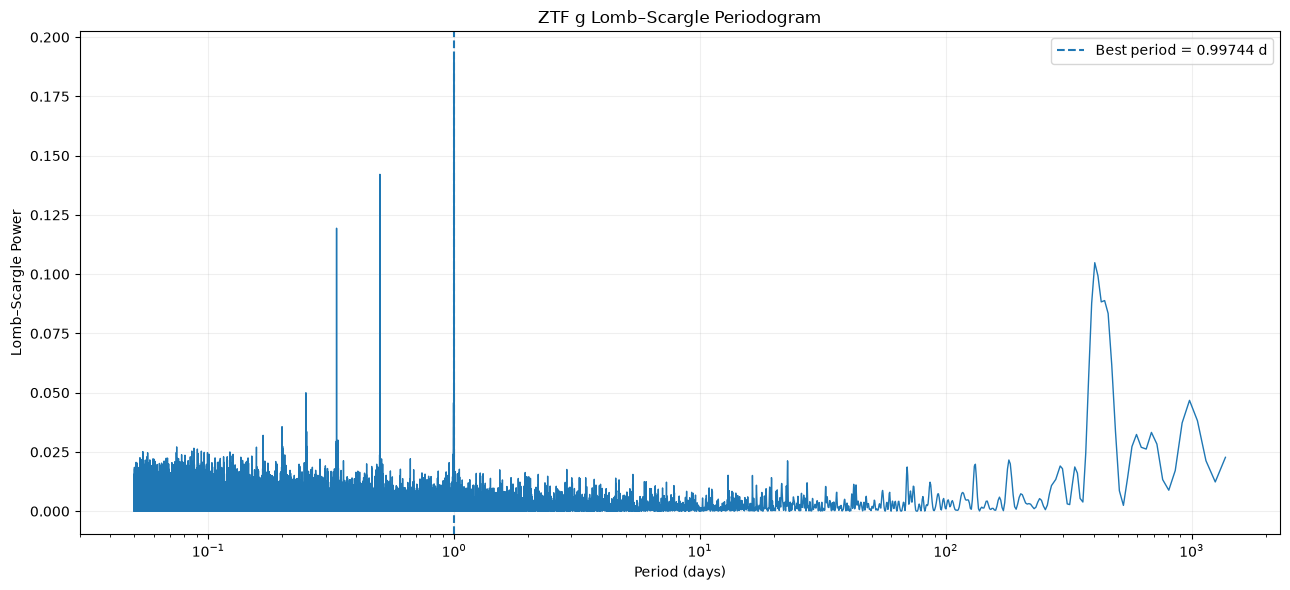

g best period: 0.99744233 days
g best power:  0.192804


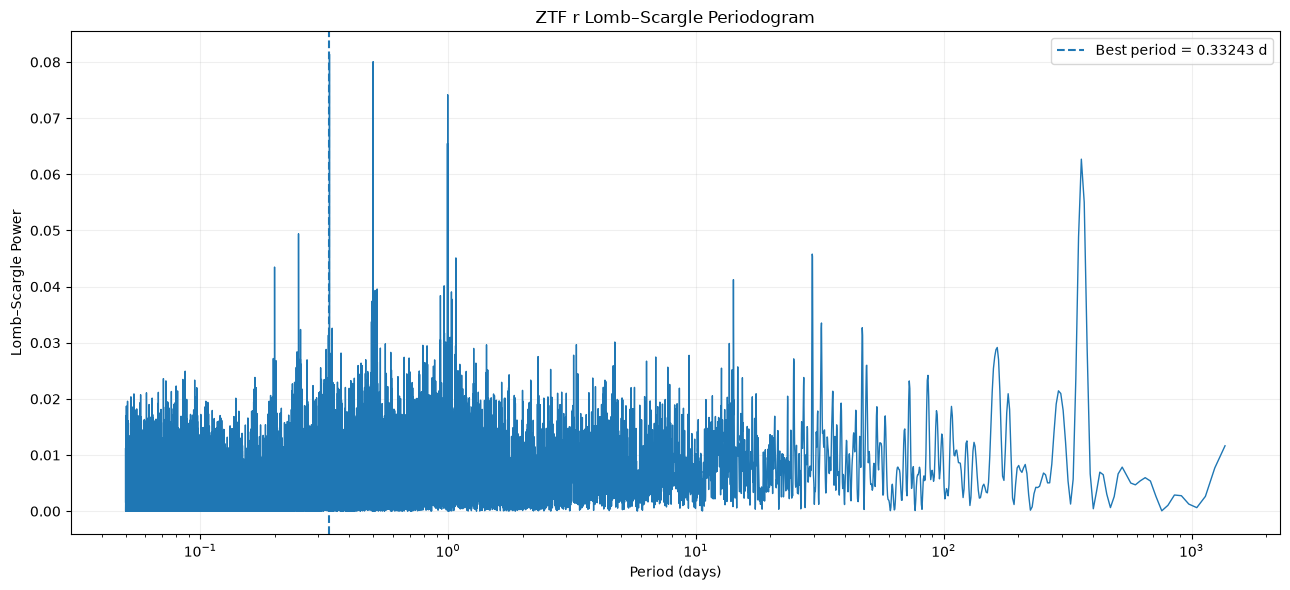

r best period: 0.33242637 days
r best power:  0.081395


In [52]:
plot_lomb_scargle(g_clean, "g")
plot_lomb_scargle(r_clean, "r")

In [53]:
from astropy.timeseries import LombScargle
import numpy as np
import pandas as pd

def lomb_scargle_features(
    df,
    band,
    min_period_days=0.05,
    max_period_days=None,
    samples_per_peak=5,
):
    time = df["mjd"].to_numpy(dtype=float)
    mag = df["mag"].to_numpy(dtype=float)
    error = df["magerr"].to_numpy(dtype=float)

    baseline = time.max() - time.min()

    if max_period_days is None:
        max_period_days = baseline / 2.0

    min_frequency = 1.0 / max_period_days
    max_frequency = 1.0 / min_period_days

    frequency, power = LombScargle(
        time,
        mag,
        error
    ).autopower(
        minimum_frequency=min_frequency,
        maximum_frequency=max_frequency,
        samples_per_peak=samples_per_peak,
    )

    best_index = np.argmax(power)

    best_frequency = frequency[best_index]
    best_power = power[best_index]
    best_period = 1.0 / best_frequency

    ls = LombScargle(time, mag, error)
    false_alarm_probability = ls.false_alarm_probability(best_power)

    return {
        f"best_period_days_{band}": best_period,
        f"best_frequency_per_day_{band}": best_frequency,
        f"best_period_power_{band}": best_power,
        f"best_period_fap_{band}": false_alarm_probability,
        f"period_search_min_days_{band}": min_period_days,
        f"period_search_max_days_{band}": max_period_days,
    }


In [54]:
g_period = lomb_scargle_features(g_clean, "g")
r_period = lomb_scargle_features(r_clean, "r")

period_features = {
    **g_period,
    **r_period,
}

period_features_df = pd.DataFrame([period_features])

display(period_features_df.T)

,0
best_period_days_g,9.974423e-01
best_frequency_per_day_g,1.002564e+00
best_period_power_g,1.928040e-01
best_period_fap_g,3.286077e-30
period_search_min_days_g,5.000000e-02
period_search_max_days_g,1.371882e+03
best_period_days_r,3.324264e-01
best_frequency_per_day_r,3.008185e+00
best_period_power_r,8.139483e-02
best_period_fap_r,9.647542e-15


In [55]:
def plot_lomb_scargle(
    df,
    band,
    min_period_days=0.05,
    max_period_days=None,
):
    time = df["mjd"].to_numpy(dtype=float)
    mag = df["mag"].to_numpy(dtype=float)
    error = df["magerr"].to_numpy(dtype=float)

    baseline = time.max() - time.min()

    if max_period_days is None:
        max_period_days = baseline / 2.0

    min_frequency = 1.0 / max_period_days
    max_frequency = 1.0 / min_period_days

    ls = LombScargle(time, mag, error)

    frequency, power = ls.autopower(
        minimum_frequency=min_frequency,
        maximum_frequency=max_frequency,
        samples_per_peak=5,
    )

    period = 1.0 / frequency

    best_index = np.argmax(power)

    best_period = period[best_index]
    best_power = power[best_index]

    plt.figure(figsize=(13, 6))

    plt.plot(
        period,
        power,
        linewidth=1,
    )

    plt.axvline(
        best_period,
        linestyle="--",
        label=f"Best period = {best_period:.5f} d",
    )

    plt.xscale("log")

    plt.xlabel("Period (days)")
    plt.ylabel("Lomb–Scargle Power")
    plt.title(f"ZTF {band} Lomb–Scargle Periodogram")

    plt.grid(alpha=0.2)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"{band} best period: {best_period:.8f} days")
    print(f"{band} best power:  {best_power:.6f}")

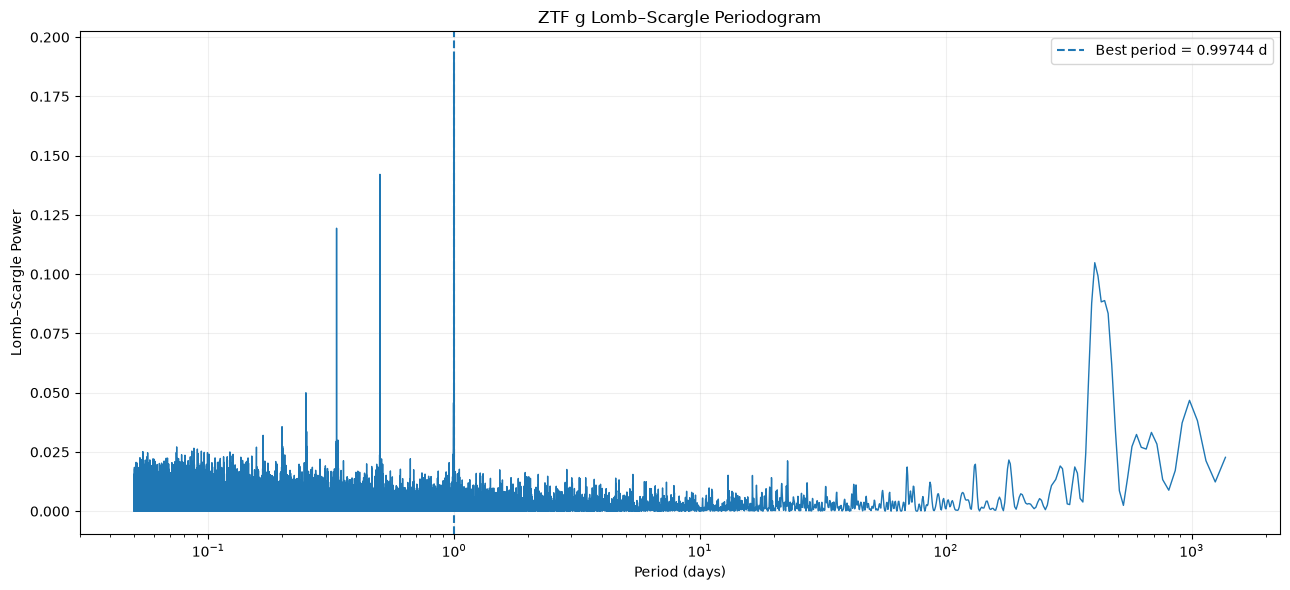

g best period: 0.99744233 days
g best power:  0.192804


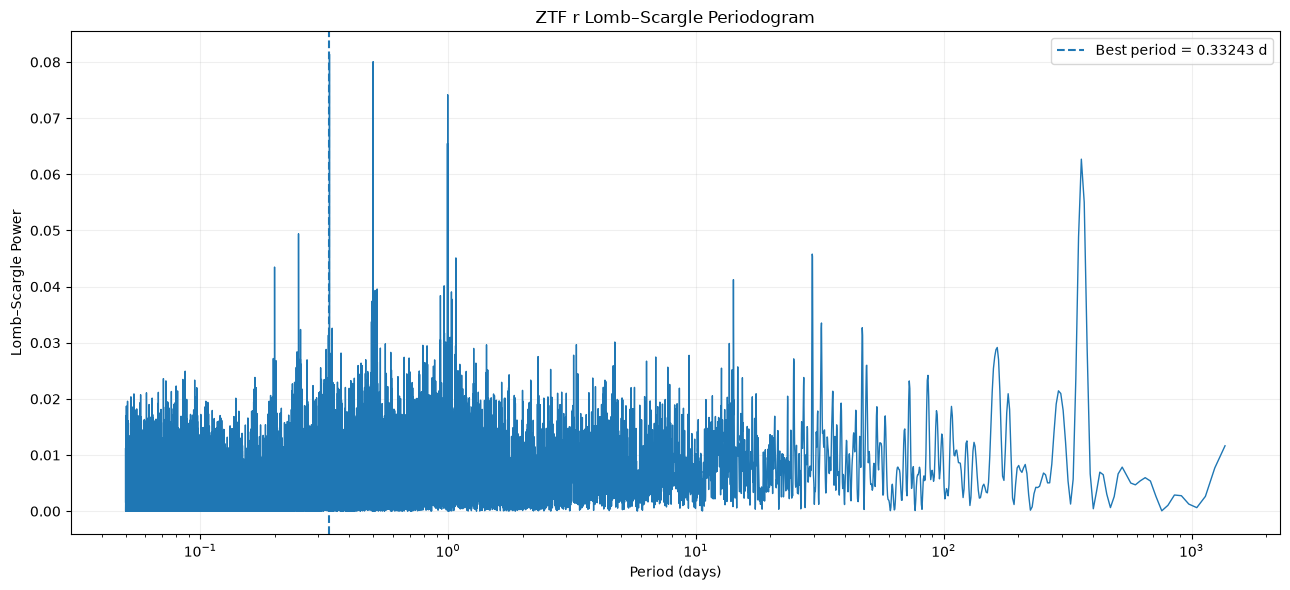

r best period: 0.33242637 days
r best power:  0.081395


In [56]:
plot_lomb_scargle(g_clean, "g")
plot_lomb_scargle(r_clean, "r")

In [57]:
# Merge Lomb–Scargle features into the main feature table

features_df = pd.concat(
    [
        features_df.reset_index(drop=True),
        period_features_df.reset_index(drop=True),
    ],
    axis=1,
)

display(features_df.T)

,0
n_obs_g,7.280000e+02
baseline_days_g,2.743764e+03
mean_mag_g,1.703037e+01
median_mag_g,1.703088e+01
weighted_mean_mag_g,1.703016e+01
...,...
best_frequency_per_day_r,3.008185e+00
best_period_power_r,8.139483e-02
best_period_fap_r,9.647542e-15
period_search_min_days_r,5.000000e-02


In [58]:
from astropy.timeseries import LombScargle
import numpy as np
import pandas as pd


def top_lomb_scargle_peaks(
    df,
    band,
    min_period_days=0.05,
    max_period_days=None,
    samples_per_peak=5,
    top_n=10,
):
    time = df["mjd"].to_numpy(dtype=float)
    mag = df["mag"].to_numpy(dtype=float)
    error = df["magerr"].to_numpy(dtype=float)

    baseline = time.max() - time.min()

    if max_period_days is None:
        max_period_days = baseline / 2.0

    min_frequency = 1.0 / max_period_days
    max_frequency = 1.0 / min_period_days

    ls = LombScargle(time, mag, error)

    frequency, power = ls.autopower(
        minimum_frequency=min_frequency,
        maximum_frequency=max_frequency,
        samples_per_peak=samples_per_peak,
    )

    period = 1.0 / frequency

    # Sort by power, highest first
    order = np.argsort(power)[::-1]

    peaks = []

    for rank, index in enumerate(order[:top_n], start=1):
        peaks.append(
            {
                "rank": rank,
                "band": band,
                "period_days": period[index],
                "frequency_per_day": frequency[index],
                "power": power[index],
            }
        )

    return pd.DataFrame(peaks)

In [59]:
g_peaks = top_lomb_scargle_peaks(
    g_clean,
    "g",
    top_n=10,
)

r_peaks = top_lomb_scargle_peaks(
    r_clean,
    "r",
    top_n=10,
)

display(g_peaks)
display(r_peaks)

,rank,band,period_days,frequency_per_day,power
0,1,g,0.997442,1.002564,0.192804
1,2,g,0.997515,1.002491,0.189074
2,3,g,0.999768,1.000232,0.159566
3,4,g,0.999696,1.000305,0.155321
4,5,g,0.997587,1.002418,0.151565
5,6,g,0.997370,1.002637,0.148685
6,7,g,0.499357,2.002577,0.142117
7,8,g,0.499247,2.003015,0.140834
8,9,g,0.499375,2.002504,0.139925
9,10,g,0.499266,2.002942,0.124596


,rank,band,period_days,frequency_per_day,power
0,1,r,0.332426,3.008185,0.081395
1,2,r,0.498627,2.005505,0.080064
2,3,r,0.332418,3.008258,0.074938
3,4,r,0.997255,1.002753,0.074170
4,5,r,0.498646,2.005432,0.073733
5,6,r,0.994567,1.005463,0.065493
6,7,r,359.300422,0.002783,0.062698
7,8,r,0.994495,1.005536,0.061021
8,9,r,0.332434,3.008112,0.060189
9,10,r,369.011244,0.002710,0.055034


In [60]:
def phase_fold(
    df,
    period_days,
    epoch=None,
):
    time = df["mjd"].to_numpy(dtype=float)
    mag = df["mag"].to_numpy(dtype=float)
    magerr = df["magerr"].to_numpy(dtype=float)

    if epoch is None:
        epoch = time.min()

    phase = ((time - epoch) / period_days) % 1.0

    folded = pd.DataFrame(
        {
            "phase": phase,
            "mag": mag,
            "magerr": magerr,
            "mjd": time,
        }
    )

    folded = folded.sort_values("phase").reset_index(drop=True)

    return folded

In [61]:
def plot_phase_folded(
    df,
    band,
    period_days,
):
    folded = phase_fold(
        df,
        period_days,
    )

    plt.figure(figsize=(13, 6))

    plt.errorbar(
        folded["phase"],
        folded["mag"],
        yerr=folded["magerr"],
        fmt=".",
        markersize=3,
        alpha=0.5,
    )

    plt.gca().invert_yaxis()

    plt.xlabel("Phase")
    plt.ylabel("Magnitude")
    plt.title(
        f"ZTF {band} Phase-Folded Light Curve "
        f"(P = {period_days:.6f} d)"
    )

    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

g candidate period = 0.99744233 days
r candidate period = 0.33242637 days


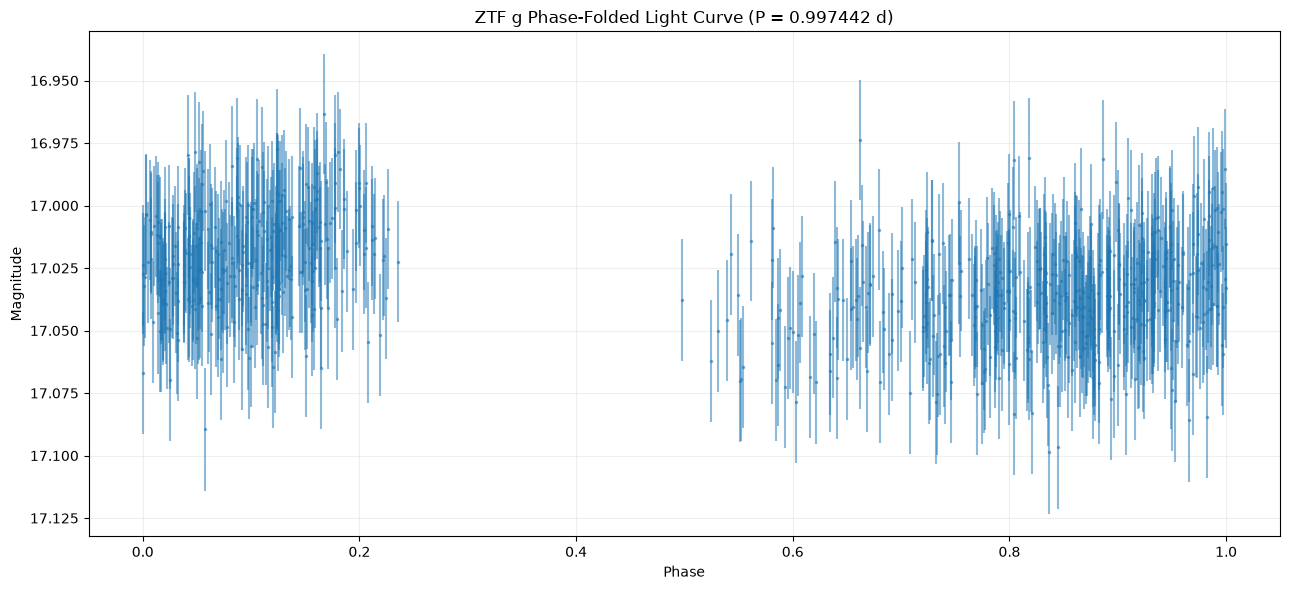

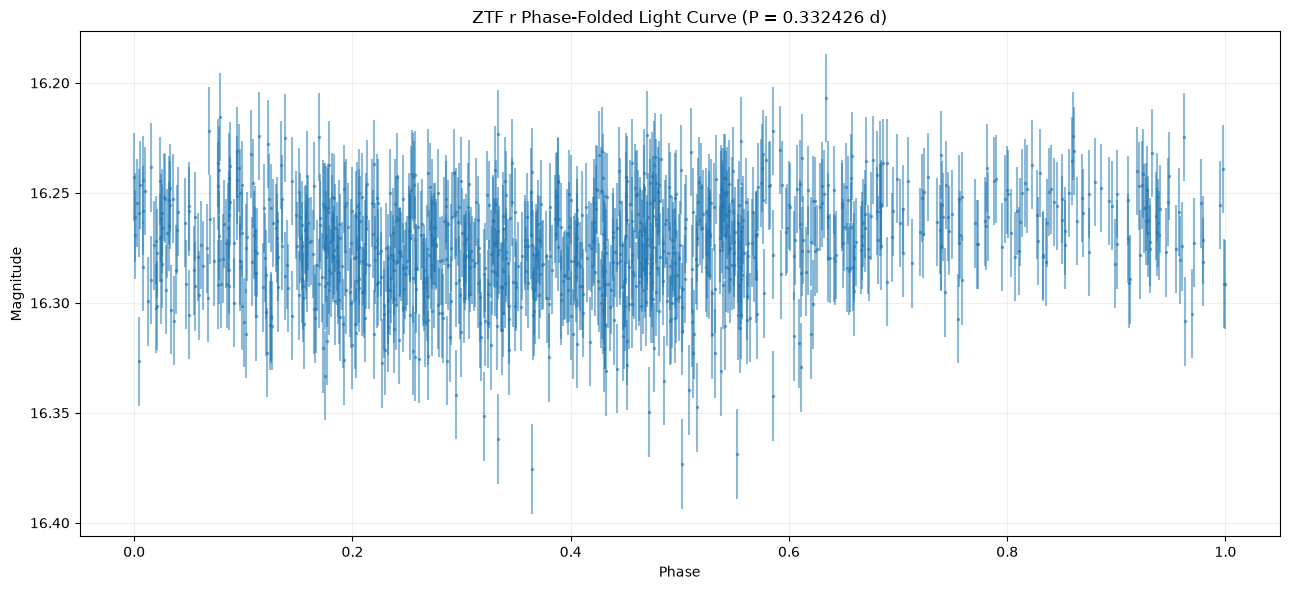

In [62]:
g_best_period = period_features["best_period_days_g"]
r_best_period = period_features["best_period_days_r"]

print(f"g candidate period = {g_best_period:.8f} days")
print(f"r candidate period = {r_best_period:.8f} days")

plot_phase_folded(
    g_clean,
    "g",
    g_best_period,
)

plot_phase_folded(
    r_clean,
    "r",
    r_best_period,
)

In [63]:
from scipy.optimize import least_squares
import numpy as np
import pandas as pd


def fit_sinusoid_features(
    df,
    band,
    period_days,
):
    time = df["mjd"].to_numpy(dtype=float)
    mag = df["mag"].to_numpy(dtype=float)
    magerr = df["magerr"].to_numpy(dtype=float)

    omega = 2.0 * np.pi / period_days

    X = np.column_stack([
        np.ones_like(time),
        np.sin(omega * time),
        np.cos(omega * time),
    ])

    weights = 1.0 / np.maximum(magerr, 1e-12) ** 2

    XtW = X.T * weights
    beta = np.linalg.solve(
        XtW @ X,
        XtW @ mag,
    )

    offset, sin_coeff, cos_coeff = beta

    amplitude = np.sqrt(
        sin_coeff**2 + cos_coeff**2
    )

    phase_rad = np.arctan2(
        cos_coeff,
        sin_coeff,
    )

    model = X @ beta
    residuals = mag - model

    weighted_rms = np.sqrt(
        np.average(
            residuals**2,
            weights=weights,
        )
    )

    chi2 = np.sum(
        ((mag - model) / magerr) ** 2
    )

    dof = max(len(mag) - 3, 1)

    reduced_chi2 = chi2 / dof

    return {
        f"sinusoid_offset_{band}": offset,
        f"sinusoid_amplitude_{band}": amplitude,
        f"sinusoid_phase_rad_{band}": phase_rad,
        f"sinusoid_weighted_rms_{band}": weighted_rms,
        f"sinusoid_chi2_{band}": chi2,
        f"sinusoid_reduced_chi2_{band}": reduced_chi2,
    }

In [64]:
g_sinusoid = fit_sinusoid_features(
    g_clean,
    "g",
    g_best_period,
)

r_sinusoid = fit_sinusoid_features(
    r_clean,
    "r",
    r_best_period,
)

sinusoid_features = {
    **g_sinusoid,
    **r_sinusoid,
}

sinusoid_features_df = pd.DataFrame(
    [sinusoid_features]
)

display(sinusoid_features_df.T)

,0
sinusoid_offset_g,17.030205
sinusoid_amplitude_g,0.013670
sinusoid_phase_rad_g,-1.375931
sinusoid_weighted_rms_g,0.019252
sinusoid_chi2_g,459.961469
sinusoid_reduced_chi2_g,0.634430
sinusoid_offset_r,16.270819
sinusoid_amplitude_r,0.010777
sinusoid_phase_rad_r,-0.292304
sinusoid_weighted_rms_r,0.022483


In [65]:
features_df = pd.concat(
    [
        features_df.reset_index(drop=True),
        sinusoid_features_df.reset_index(drop=True),
    ],
    axis=1,
)

display(features_df.T)

,0
n_obs_g,728.000000
baseline_days_g,2743.764363
mean_mag_g,17.030369
median_mag_g,17.030876
weighted_mean_mag_g,17.030158
...,...
sinusoid_amplitude_r,0.010777
sinusoid_phase_rad_r,-0.292304
sinusoid_weighted_rms_r,0.022483
sinusoid_chi2_r,1238.113224


In [66]:
def phase_morphology_features(
    df,
    band,
    period_days,
):
    folded = phase_fold(
        df,
        period_days,
    )

    phase = folded["phase"].to_numpy()
    mag = folded["mag"].to_numpy()

    q10, q25, q50, q75, q90 = np.percentile(
        mag,
        [10, 25, 50, 75, 90],
    )

    phase_bins = np.linspace(0.0, 1.0, 21)

    bin_index = np.digitize(
        phase,
        phase_bins,
    ) - 1

    bin_medians = []

    for i in range(len(phase_bins) - 1):
        values = mag[bin_index == i]

        if len(values) >= 3:
            bin_medians.append(
                np.median(values)
            )

    bin_medians = np.asarray(
        bin_medians,
        dtype=float,
    )

    if len(bin_medians) >= 2:
        folded_range = (
            np.max(bin_medians)
            - np.min(bin_medians)
        )
    else:
        folded_range = np.nan

    return {
        f"folded_p10_{band}": q10,
        f"folded_p25_{band}": q25,
        f"folded_p50_{band}": q50,
        f"folded_p75_{band}": q75,
        f"folded_p90_{band}": q90,
        f"folded_binned_amplitude_{band}": folded_range,
        f"folded_n_phase_bins_{band}": len(bin_medians),
    }

In [67]:
g_morphology = phase_morphology_features(
    g_clean,
    "g",
    g_best_period,
)

r_morphology = phase_morphology_features(
    r_clean,
    "r",
    r_best_period,
)

morphology_features = {
    **g_morphology,
    **r_morphology,
}

morphology_features_df = pd.DataFrame(
    [morphology_features]
)

display(morphology_features_df.T)

,0
folded_p10_g,17.002121
folded_p25_g,17.016178
folded_p50_g,17.030876
folded_p75_g,17.043929
folded_p90_g,17.057772
folded_binned_amplitude_g,0.046417
folded_n_phase_bins_g,15.000000
folded_p10_r,16.246147
folded_p25_r,16.256453
folded_p50_r,16.273743


In [68]:
features_df = pd.concat(
    [
        features_df.reset_index(drop=True),
        morphology_features_df.reset_index(drop=True),
    ],
    axis=1,
)

print("Total features:", len(features_df.columns))

display(features_df.T)

Total features: 88


,0
n_obs_g,728.000000
baseline_days_g,2743.764363
mean_mag_g,17.030369
median_mag_g,17.030876
weighted_mean_mag_g,17.030158
...,...
folded_p50_r,16.273743
folded_p75_r,16.289207
folded_p90_r,16.305294
folded_binned_amplitude_r,0.027763


In [69]:
def periodic_sampling_features(
    df,
    band,
    period_days,
):
    time = df["mjd"].to_numpy(dtype=float)

    baseline = time.max() - time.min()

    n_cycles = baseline / period_days

    phase = ((time - time.min()) / period_days) % 1.0

    phase_coverage = (
        np.max(phase) - np.min(phase)
    )

    phase_hist, _ = np.histogram(
        phase,
        bins=20,
        range=(0.0, 1.0),
    )

    occupied_bins = np.sum(
        phase_hist > 0
    )

    return {
        f"n_cycles_observed_{band}": n_cycles,
        f"phase_coverage_{band}": phase_coverage,
        f"phase_occupied_bins_{band}": occupied_bins,
        f"phase_occupied_fraction_{band}":
            occupied_bins / 20.0,
    }

In [70]:
g_sampling = periodic_sampling_features(
    g_clean,
    "g",
    g_best_period,
)

r_sampling = periodic_sampling_features(
    r_clean,
    "r",
    r_best_period,
)

sampling_features = {
    **g_sampling,
    **r_sampling,
}

sampling_features_df = pd.DataFrame(
    [sampling_features]
)

features_df = pd.concat(
    [
        features_df.reset_index(drop=True),
        sampling_features_df.reset_index(drop=True),
    ],
    axis=1,
)

display(sampling_features_df.T)

print(
    "\nTotal features:",
    len(features_df.columns),
)

,0
n_cycles_observed_g,2750.800000
phase_coverage_g,0.999750
phase_occupied_bins_g,16.000000
phase_occupied_fraction_g,0.800000
n_cycles_observed_r,8214.400000
phase_coverage_r,0.999981
phase_occupied_bins_r,20.000000
phase_occupied_fraction_r,1.000000



Total features: 96


In [71]:
from scipy.stats import median_abs_deviation


def robust_variability_features(df, band):
    mag = df["mag"].to_numpy(dtype=float)
    magerr = df["magerr"].to_numpy(dtype=float)

    median = np.median(mag)

    mad = median_abs_deviation(
        mag,
        scale="normal",
    )

    normalized_residuals = (
        (mag - median) / magerr
    )

    robust_z_median = np.median(
        np.abs(normalized_residuals)
    )

    robust_z_p95 = np.percentile(
        np.abs(normalized_residuals),
        95,
    )

    robust_z_max = np.max(
        np.abs(normalized_residuals)
    )

    return {
        f"robust_mad_{band}": mad,
        f"robust_normalized_median_{band}":
            robust_z_median,
        f"robust_normalized_p95_{band}":
            robust_z_p95,
        f"robust_normalized_max_{band}":
            robust_z_max,
    }

In [72]:
g_robust = robust_variability_features(
    g_clean,
    "g",
)

r_robust = robust_variability_features(
    r_clean,
    "r",
)

robust_features = {
    **g_robust,
    **r_robust,
}

robust_features_df = pd.DataFrame(
    [robust_features]
)

display(robust_features_df.T)

,0
robust_mad_g,0.020445
robust_normalized_median_g,0.569665
robust_normalized_p95_g,1.696126
robust_normalized_max_g,2.829361
robust_mad_r,0.024410
robust_normalized_median_r,0.817189
robust_normalized_p95_r,2.206888
robust_normalized_max_r,4.971025


In [73]:
features_df = pd.concat(
    [
        features_df.reset_index(drop=True),
        robust_features_df.reset_index(drop=True),
    ],
    axis=1,
)

print("Total features:", len(features_df.columns))

Total features: 104


In [74]:
def cross_band_features(
    g_df,
    r_df,
):
    g_mag = g_df["mag"].to_numpy(dtype=float)
    r_mag = r_df["mag"].to_numpy(dtype=float)

    features = {}

    features["mean_color_g_r"] = (
        np.mean(g_mag) - np.mean(r_mag)
    )

    features["median_color_g_r"] = (
        np.median(g_mag) - np.median(r_mag)
    )

    features["std_ratio_g_r"] = (
        np.std(g_mag) /
        np.maximum(np.std(r_mag), 1e-12)
    )

    features["amplitude_ratio_g_r"] = (
        (np.max(g_mag) - np.min(g_mag))
        /
        np.maximum(
            np.max(r_mag) - np.min(r_mag),
            1e-12,
        )
    )

    return features

In [75]:
cross_band = cross_band_features(
    g_clean,
    r_clean,
)

cross_band_df = pd.DataFrame(
    [cross_band]
)

display(cross_band_df.T)

,0
mean_color_g_r,0.756027
median_color_g_r,0.757134
std_ratio_g_r,0.911975
amplitude_ratio_g_r,0.802832


In [76]:
features_df = pd.concat(
    [
        features_df.reset_index(drop=True),
        cross_band_df.reset_index(drop=True),
    ],
    axis=1,
)

print("Total features:", len(features_df.columns))

Total features: 108


In [77]:
features_df = pd.concat(
    [
        features_df.reset_index(drop=True),
        cross_band_df.reset_index(drop=True),
    ],
    axis=1,
)

print("Total features:", len(features_df.columns))

Total features: 112


In [80]:
def matched_cross_band_features(
    g_df,
    r_df,
    max_time_difference_days=0.02,
):
    g_time = g_df["mjd"].to_numpy(dtype=float)
    g_mag = g_df["mag"].to_numpy(dtype=float)

    r_time = r_df["mjd"].to_numpy(dtype=float)
    r_mag = r_df["mag"].to_numpy(dtype=float)

    matched_colors = []
    time_differences = []

    for t_g, m_g in zip(g_time, g_mag):

        index = np.argmin(
            np.abs(r_time - t_g)
        )

        dt = abs(
            r_time[index] - t_g
        )

        if dt <= max_time_difference_days:
            matched_colors.append(
                m_g - r_mag[index]
            )

            time_differences.append(dt)

    matched_colors = np.asarray(
        matched_colors,
        dtype=float,
    )

    time_differences = np.asarray(
        time_differences,
        dtype=float,
    )

    if len(matched_colors) == 0:
        return {
            "matched_gr_count": 0,
            "matched_gr_color_mean": np.nan,
            "matched_gr_color_median": np.nan,
            "matched_gr_color_std": np.nan,
            "matched_gr_median_dt_days": np.nan,
        }

    return {
        "matched_gr_count": len(matched_colors),
        "matched_gr_color_mean":
            np.mean(matched_colors),
        "matched_gr_color_median":
            np.median(matched_colors),
        "matched_gr_color_std":
            np.std(matched_colors),
        "matched_gr_median_dt_days":
            np.median(time_differences),
    }

In [81]:
matched_gr = matched_cross_band_features(
    g_clean,
    r_clean,
    max_time_difference_days=0.02,
)

matched_gr_df = pd.DataFrame(
    [matched_gr]
)

display(matched_gr_df.T)

,0
matched_gr_count,72.000000
matched_gr_color_mean,0.755911
matched_gr_color_median,0.757677
matched_gr_color_std,0.030668
matched_gr_median_dt_days,0.015365


In [82]:
features_df = pd.concat(
    [
        features_df.reset_index(drop=True),
        matched_gr_df.reset_index(drop=True),
    ],
    axis=1,
)

print("Total features:", len(features_df.columns))

display(features_df.T)

Total features: 117


,0
n_obs_g,728.000000
baseline_days_g,2743.764363
mean_mag_g,17.030369
median_mag_g,17.030876
weighted_mean_mag_g,17.030158
...,...
matched_gr_count,72.000000
matched_gr_color_mean,0.755911
matched_gr_color_median,0.757677
matched_gr_color_std,0.030668


In [83]:
def observation_density_features(
    df,
    band,
):
    time = df["mjd"].to_numpy(dtype=float)

    baseline = time.max() - time.min()
    n_obs = len(time)

    density = (
        n_obs / baseline
        if baseline > 0
        else np.nan
    )

    sorted_time = np.sort(time)
    gaps = np.diff(sorted_time)

    if len(gaps) > 0:
        median_gap = np.median(gaps)
        p95_gap = np.percentile(gaps, 95)
        max_gap = np.max(gaps)
    else:
        median_gap = np.nan
        p95_gap = np.nan
        max_gap = np.nan

    return {
        f"observation_density_per_day_{band}": density,
        f"median_observation_gap_days_{band}": median_gap,
        f"p95_observation_gap_days_{band}": p95_gap,
        f"max_observation_gap_days_{band}": max_gap,
    }

In [84]:
g_density = observation_density_features(
    g_clean,
    "g",
)

r_density = observation_density_features(
    r_clean,
    "r",
)

density_features = {
    **g_density,
    **r_density,
}

density_features_df = pd.DataFrame(
    [density_features]
)

features_df = pd.concat(
    [
        features_df.reset_index(drop=True),
        density_features_df.reset_index(drop=True),
    ],
    axis=1,
)

display(density_features_df.T)

print(
    "\nTotal features:",
    len(features_df.columns),
)

,0
observation_density_per_day_g,0.265329
median_observation_gap_days_g,1.995486
p95_observation_gap_days_g,9.942867
max_observation_gap_days_g,146.361111
observation_density_per_day_r,0.363645
median_observation_gap_days_r,1.101152
p95_observation_gap_days_r,7.943912
max_observation_gap_days_r,104.331667



Total features: 125


In [85]:
def time_lag_autocorrelation(
    df,
    band,
    lag_days_list=(0.1, 0.5, 1.0, 5.0, 10.0),
):
    time = df["mjd"].to_numpy(dtype=float)
    mag = df["mag"].to_numpy(dtype=float)

    centered = mag - np.mean(mag)
    variance = np.var(mag)

    if variance <= 0:
        return {
            f"autocorr_lag_{lag:g}d_{band}": np.nan
            for lag in lag_days_list
        }

    features = {}

    for lag in lag_days_list:
        values = []

        for i in range(len(time)):
            dt = np.abs(
                time - time[i] - lag
            )

            j = np.argmin(dt)

            if dt[j] <= lag * 0.1:
                values.append(
                    centered[i] * centered[j]
                )

        if len(values) == 0:
            autocorr = np.nan
        else:
            autocorr = np.mean(values) / variance

        features[
            f"autocorr_lag_{lag:g}d_{band}"
        ] = autocorr

    return features

In [86]:
g_autocorr = time_lag_autocorrelation(
    g_clean,
    "g",
)

r_autocorr = time_lag_autocorrelation(
    r_clean,
    "r",
)

autocorr_features = {
    **g_autocorr,
    **r_autocorr,
}

autocorr_features_df = pd.DataFrame(
    [autocorr_features]
)

display(autocorr_features_df.T)

,0
autocorr_lag_0.1d_g,-0.323489
autocorr_lag_0.5d_g,NaN
autocorr_lag_1d_g,0.365043
autocorr_lag_5d_g,0.326679
autocorr_lag_10d_g,0.182557
autocorr_lag_0.1d_r,0.203565
autocorr_lag_0.5d_r,NaN
autocorr_lag_1d_r,0.092639
autocorr_lag_5d_r,0.095650
autocorr_lag_10d_r,-0.021521


In [87]:
features_df = pd.concat(
    [
        features_df.reset_index(drop=True),
        autocorr_features_df.reset_index(drop=True),
    ],
    axis=1,
)

print("=" * 60)
print("FEATURE ENGINEERING STATUS")
print("=" * 60)
print(f"Number of objects: {len(features_df)}")
print(f"Number of features: {len(features_df.columns)}")

print("\nFeature table shape:")
print(features_df.shape)

display(features_df.T)

FEATURE ENGINEERING STATUS
Number of objects: 1
Number of features: 135

Feature table shape:
(1, 135)


,0
n_obs_g,728.000000
baseline_days_g,2743.764363
mean_mag_g,17.030369
median_mag_g,17.030876
weighted_mean_mag_g,17.030158
...,...
autocorr_lag_0.1d_r,0.203565
autocorr_lag_0.5d_r,NaN
autocorr_lag_1d_r,0.092639
autocorr_lag_5d_r,0.095650


In [89]:
# Feature validation — handle duplicate column names safely

print("=" * 60)
print("FEATURE TABLE VALIDATION")
print("=" * 60)

print(f"Shape: {features_df.shape}")
print(f"Total columns: {len(features_df.columns)}")

# Find duplicate column names
duplicate_columns = features_df.columns[
    features_df.columns.duplicated(keep=False)
]

print(
    f"\nDuplicate column names: "
    f"{len(duplicate_columns)}"
)

if len(duplicate_columns) > 0:
    print("\nDuplicates:")
    for col in pd.unique(duplicate_columns):
        print(
            f"  {col}: "
            f"{(features_df.columns == col).sum()} occurrences"
        )

# Build validation by column position,
# so duplicate names cannot break the check.
feature_validation_rows = []

for position, col in enumerate(features_df.columns):
    series = features_df.iloc[:, position]

    values = pd.to_numeric(
        series,
        errors="coerce",
    )

    feature_validation_rows.append({
        "column_position": position,
        "feature": col,
        "dtype": str(series.dtype),
        "nan_count": int(
            values.isna().sum()
        ),
        "inf_count": int(
            np.isinf(
                values.to_numpy(
                    dtype=float
                )
            ).sum()
        ),
    })

feature_validation = pd.DataFrame(
    feature_validation_rows
)

display(
    feature_validation[
        (feature_validation["nan_count"] > 0)
        | (feature_validation["inf_count"] > 0)
    ]
)

print(
    "\nFeatures with NaN:",
    (
        feature_validation["nan_count"] > 0
    ).sum(),
)

print(
    "Features with Inf:",
    (
        feature_validation["inf_count"] > 0
    ).sum(),
)

FEATURE TABLE VALIDATION
Shape: (1, 135)
Total columns: 135

Duplicate column names: 10

Duplicates:
  mean_color_g_r: 3 occurrences
  median_color_g_r: 3 occurrences
  std_ratio_g_r: 2 occurrences
  amplitude_ratio_g_r: 2 occurrences


,column_position,feature,dtype,nan_count,inf_count
126,126,autocorr_lag_0.5d_g,float64,1,0
131,131,autocorr_lag_0.5d_r,float64,1,0



Features with NaN: 2
Features with Inf: 0


In [90]:
# Show duplicate columns and their values

if len(duplicate_columns) > 0:

    duplicate_names = pd.unique(
        duplicate_columns
    )

    for col in duplicate_names:
        print("=" * 60)
        print(f"DUPLICATE FEATURE: {col}")
        print("=" * 60)

        display(
            features_df.loc[:, features_df.columns == col]
        )
else:
    print("No duplicate feature names found.")

DUPLICATE FEATURE: mean_color_g_r


,mean_color_g_r,mean_color_g_r,mean_color_g_r
0,0.756027,0.756027,0.756027


DUPLICATE FEATURE: median_color_g_r


,median_color_g_r,median_color_g_r,median_color_g_r
0,0.757134,0.757134,0.757134


DUPLICATE FEATURE: std_ratio_g_r


,std_ratio_g_r,std_ratio_g_r
0,0.911975,0.911975


DUPLICATE FEATURE: amplitude_ratio_g_r


,amplitude_ratio_g_r,amplitude_ratio_g_r
0,0.802832,0.802832


In [91]:
# Remove duplicate feature columns.
# Keep the first occurrence of each feature.

duplicate_count = (
    features_df.columns.duplicated(keep="first").sum()
)

features_df = features_df.loc[
    :,
    ~features_df.columns.duplicated(
        keep="first"
    )
].copy()

print(
    f"Removed duplicate columns: {duplicate_count}"
)

print(
    f"Final feature table shape: {features_df.shape}"
)

print(
    f"Unique feature names: "
    f"{features_df.columns.is_unique}"
)

Removed duplicate columns: 6
Final feature table shape: (1, 129)
Unique feature names: True


In [92]:
features_numeric = features_df.apply(
    pd.to_numeric,
    errors="coerce",
)

features_numeric = features_numeric.replace(
    [np.inf, -np.inf],
    np.nan,
)

nan_summary = (
    features_numeric.isna()
    .sum()
    .sort_values(ascending=False)
)

print(
    "Total NaN values:",
    int(features_numeric.isna().sum().sum()),
)

print(
    "Features containing NaN:",
    int((nan_summary > 0).sum()),
)

if (nan_summary > 0).any():
    display(
        nan_summary[nan_summary > 0]
    )
else:
    print("No NaN values found.")

Total NaN values: 2
Features containing NaN: 2


autocorr_lag_0.5d_r    1
autocorr_lag_0.5d_g    1
dtype: int64

In [93]:
feature_ranges = pd.DataFrame({
    "feature": features_numeric.columns,
    "min": features_numeric.min().values,
    "max": features_numeric.max().values,
    "mean": features_numeric.mean().values,
    "std": features_numeric.std().values,
})

display(feature_ranges)

,feature,min,max,mean,std
0,n_obs_g,728.000000,728.000000,728.000000,NaN
1,baseline_days_g,2743.764363,2743.764363,2743.764363,NaN
2,mean_mag_g,17.030369,17.030369,17.030369,NaN
3,median_mag_g,17.030876,17.030876,17.030876,NaN
4,weighted_mean_mag_g,17.030158,17.030158,17.030158,NaN
...,...,...,...,...,...
124,autocorr_lag_0.1d_r,0.203565,0.203565,0.203565,NaN
125,autocorr_lag_0.5d_r,NaN,NaN,NaN,NaN
126,autocorr_lag_1d_r,0.092639,0.092639,0.092639,NaN
127,autocorr_lag_5d_r,0.095650,0.095650,0.095650,NaN


In [94]:
constant_features = []

for col in features_numeric.columns:
    if features_numeric[col].nunique(
        dropna=True
    ) <= 1:
        constant_features.append(col)

print(
    "Constant features:",
    len(constant_features),
)

if constant_features:
    for feature in constant_features:
        print("-", feature)
else:
    print("No constant features found.")

Constant features: 129
- n_obs_g
- baseline_days_g
- mean_mag_g
- median_mag_g
- weighted_mean_mag_g
- std_mag_g
- mad_mag_g
- min_mag_g
- max_mag_g
- amplitude_mag_g
- p05_mag_g
- p25_mag_g
- p75_mag_g
- p95_mag_g
- mean_magerr_g
- median_magerr_g
- n_obs_r
- baseline_days_r
- mean_mag_r
- median_mag_r
- weighted_mean_mag_r
- std_mag_r
- mad_mag_r
- min_mag_r
- max_mag_r
- amplitude_mag_r
- p05_mag_r
- p25_mag_r
- p75_mag_r
- p95_mag_r
- mean_magerr_r
- median_magerr_r
- mean_color_g_r
- median_color_g_r
- variability_ratio_g
- variability_ratio_r
- iqr_mag_g
- p95_p05_range_g
- skewness_mag_g
- kurtosis_mag_g
- rms_mag_g
- reduced_chi2_like_g
- median_abs_normalized_residual_g
- iqr_mag_r
- p95_p05_range_r
- skewness_mag_r
- kurtosis_mag_r
- rms_mag_r
- reduced_chi2_like_r
- median_abs_normalized_residual_r
- best_period_days_g
- best_frequency_per_day_g
- best_period_power_g
- best_period_fap_g
- period_search_min_days_g
- period_search_max_days_g
- best_period_days_r
- best_frequen

In [95]:
print("=" * 60)
print("FEATURE VALIDATION SUMMARY")
print("=" * 60)

print(
    f"Objects: {len(features_df)}"
)

print(
    f"Features: {len(features_df.columns)}"
)

print(
    f"Unique column names: "
    f"{features_df.columns.is_unique}"
)

print(
    f"Total NaN: "
    f"{int(features_numeric.isna().sum().sum())}"
)

print(
    f"Total Inf: "
    f"{int(np.isinf(features_numeric.to_numpy()).sum())}"
)

print(
    f"Constant features: "
    f"{len(constant_features)}"
)

print("\nFeature table:")
display(features_df.T)

FEATURE VALIDATION SUMMARY
Objects: 1
Features: 129
Unique column names: True
Total NaN: 2
Total Inf: 0
Constant features: 129

Feature table:


,0
n_obs_g,728.000000
baseline_days_g,2743.764363
mean_mag_g,17.030369
median_mag_g,17.030876
weighted_mean_mag_g,17.030158
...,...
autocorr_lag_0.1d_r,0.203565
autocorr_lag_0.5d_r,NaN
autocorr_lag_1d_r,0.092639
autocorr_lag_5d_r,0.095650


In [96]:
from dataclasses import dataclass
from typing import Optional


@dataclass
class ZTFObjectRecord:
    object_id: str
    ra_deg: Optional[float]
    dec_deg: Optional[float]
    source: str
    label: Optional[str] = None
    label_source: Optional[str] = None


print("ZTFObjectRecord schema created.")

ZTFObjectRecord schema created.


In [97]:
prototype_object = ZTFObjectRecord(
    object_id=str(g_clean["oid"].iloc[0]),
    ra_deg=float(g_clean["ra"].iloc[0]),
    dec_deg=float(g_clean["dec"].iloc[0]),
    source="IRSA ZTF Light Curve API",
    label=None,
    label_source=None,
)

print(prototype_object)

ZTFObjectRecord(object_id='686103400106565', ra_deg=298.0037275, dec_deg=29.87064, source='IRSA ZTF Light Curve API', label=None, label_source=None)


In [98]:
object_metadata = pd.DataFrame([
    {
        "object_id": prototype_object.object_id,
        "ra_deg": prototype_object.ra_deg,
        "dec_deg": prototype_object.dec_deg,
        "source": prototype_object.source,
        "label": prototype_object.label,
        "label_source": prototype_object.label_source,
    }
])

display(object_metadata)

,object_id,ra_deg,dec_deg,source,label,label_source
0,686103400106565,298.003728,29.87064,IRSA ZTF Light Curve API,None,None


In [99]:
features_df = features_df.copy()

features_df.insert(
    0,
    "object_id",
    prototype_object.object_id,
)

display(features_df.T)

,0
object_id,686103400106565
n_obs_g,728
baseline_days_g,2743.764363
mean_mag_g,17.030369
median_mag_g,17.030876
...,...
autocorr_lag_0.1d_r,0.203565
autocorr_lag_0.5d_r,NaN
autocorr_lag_1d_r,0.092639
autocorr_lag_5d_r,0.09565


In [100]:
dataset_v01 = features_df.merge(
    object_metadata[
        [
            "object_id",
            "ra_deg",
            "dec_deg",
            "source",
            "label",
            "label_source",
        ]
    ],
    on="object_id",
    how="left",
)

print(
    "Dataset shape:",
    dataset_v01.shape,
)

display(dataset_v01.T)

Dataset shape: (1, 135)


,0
object_id,686103400106565
n_obs_g,728
baseline_days_g,2743.764363
mean_mag_g,17.030369
median_mag_g,17.030876
...,...
ra_deg,298.003728
dec_deg,29.87064
source,IRSA ZTF Light Curve API
label,None


In [101]:
from pathlib import Path

processed_dir = Path(
    "../data/processed"
)

processed_dir.mkdir(
    parents=True,
    exist_ok=True,
)

dataset_path = (
    processed_dir
    / "ztf_features_v0.1.parquet"
)

dataset_v01.to_parquet(
    dataset_path,
    index=False,
)

print(
    f"Saved dataset to:\n{dataset_path.resolve()}"
)

Saved dataset to:
/home/saeed92m/projects/data/processed/ztf_features_v0.1.parquet


In [102]:
dataset_check = pd.read_parquet(
    dataset_path
)

print(
    "Reloaded dataset shape:",
    dataset_check.shape,
)

print(
    "Columns:",
    len(dataset_check.columns),
)

print(
    "Object IDs:",
    dataset_check["object_id"].tolist(),
)

display(dataset_check.head())

Reloaded dataset shape: (1, 135)
Columns: 135
Object IDs: ['686103400106565']


,object_id,n_obs_g,baseline_days_g,mean_mag_g,median_mag_g,weighted_mean_mag_g,std_mag_g,mad_mag_g,min_mag_g,max_mag_g,...,autocorr_lag_0.1d_r,autocorr_lag_0.5d_r,autocorr_lag_1d_r,autocorr_lag_5d_r,autocorr_lag_10d_r,ra_deg,dec_deg,source,label,label_source
0,686103400106565,728,2743.764363,17.030369,17.030876,17.030158,0.021445,0.01379,16.963371,17.098568,...,0.203565,NaN,0.092639,0.09565,-0.021521,298.003728,29.87064,IRSA ZTF Light Curve API,None,None


In [103]:
LABEL_SCHEMA = {
    "SN": "Supernova",
    "AGN": "Active Galactic Nucleus",
    "CV": "Cataclysmic Variable",
    "RR_LYRAE": "RR Lyrae",
    "CEPHEID": "Cepheid",
    "ECL": "Eclipsing Binary",
    "DSCT": "Delta Scuti",
    "M_DWARF": "M Dwarf / Stellar Variable",
    "OTHER": "Other / miscellaneous",
}

print("Number of target classes:", len(LABEL_SCHEMA))

for code, description in LABEL_SCHEMA.items():
    print(f"{code:12s} -> {description}")

Number of target classes: 9
SN           -> Supernova
AGN          -> Active Galactic Nucleus
CV           -> Cataclysmic Variable
RR_LYRAE     -> RR Lyrae
CEPHEID      -> Cepheid
ECL          -> Eclipsing Binary
DSCT         -> Delta Scuti
M_DWARF      -> M Dwarf / Stellar Variable
OTHER        -> Other / miscellaneous


In [104]:
LABEL_ALIASES = {
    # Supernova
    "SN": "SN",
    "SN_Ia": "SN",
    "SN_II": "SN",
    "SN_Ibc": "SN",

    # AGN / quasars
    "AGN": "AGN",
    "QSO": "AGN",
    "QUASAR": "AGN",

    # Cataclysmic variables
    "CV": "CV",
    "CATACLYSMIC_VARIABLE": "CV",

    # RR Lyrae
    "RRLYR": "RR_LYRAE",
    "RR_LYRAE": "RR_LYRAE",

    # Cepheids
    "CEPHEID": "CEPHEID",
    "CEP": "CEPHEID",

    # Eclipsing binaries
    "ECL": "ECL",
    "ECLIP": "ECL",

    # Delta Scuti
    "DSCT": "DSCT",
    "DELTA_SCUTI": "DSCT",

    # M dwarfs
    "M_DWARF": "M_DWARF",
}


def canonicalize_label(label):
    if label is None:
        return None

    normalized = str(label).strip().upper()

    return LABEL_ALIASES.get(
        normalized,
        "OTHER",
    )


print(canonicalize_label("QSO"))
print(canonicalize_label("RRLYR"))
print(canonicalize_label("unknown"))

AGN
RR_LYRAE
OTHER


In [106]:
label_columns = [
    "object_id",
    "label",
    "label_source",
    "label_version",
    "label_confidence",
    "ra_deg",
    "dec_deg",
]

label_table = pd.DataFrame(
    columns=label_columns
)

print("Label table schema:")
display(label_table)

Label table schema:


,object_id,label,label_source,label_version,label_confidence,ra_deg,dec_deg


In [107]:
provenance_columns = [
    "object_id",
    "data_source",
    "catalog_name",
    "catalog_version",
    "retrieval_method",
    "retrieval_timestamp",
    "quality_mask",
    "feature_version",
]

provenance_table = pd.DataFrame(
    columns=provenance_columns
)

display(provenance_table)

,object_id,data_source,catalog_name,catalog_version,retrieval_method,retrieval_timestamp,quality_mask,feature_version


In [108]:
dataset_manifest = {
    "dataset_name": "ZTF Classifier Dataset",
    "dataset_version": "0.1.0",
    "feature_version": "0.1.0",
    "source_survey": "ZTF",
    "label_status": "prototype_unlabeled",
    "primary_storage": "Parquet",
    "ml_split_strategy": "not_defined_yet",
    "notes": (
        "Prototype dataset containing a single "
        "unlabeled ZTF object."
    ),
}

for key, value in dataset_manifest.items():
    print(f"{key}: {value}")

dataset_name: ZTF Classifier Dataset
dataset_version: 0.1.0
feature_version: 0.1.0
source_survey: ZTF
label_status: prototype_unlabeled
primary_storage: Parquet
ml_split_strategy: not_defined_yet
notes: Prototype dataset containing a single unlabeled ZTF object.


In [110]:
import pyvo

tap = pyvo.dal.TAPService(
    "https://tap.alerce.online/tap"
)

print("TAP service connected")
print("Number of tables:", len(tap.tables))

TAP service connected
Number of tables: 53


In [113]:
import requests
import xml.etree.ElementTree as ET

tables_url = "https://tap.alerce.online/tap/tables"

response = requests.get(
    tables_url,
    timeout=(10, 60),
)

print("HTTP status:", response.status_code)
print("Response size:", len(response.content), "bytes")

response.raise_for_status()

root = ET.fromstring(response.content)

table_names = []

for element in root.iter():
    if element.tag.endswith("table"):
        for child in element:
            if child.tag.endswith("name") and child.text:
                table_names.append(child.text.strip())
                break

print("Number of tables:", len(table_names))

for name in table_names:
    print(name)

HTTP status: 200
Response size: 241297 bytes
Number of tables: 53
tap_schema.tables
tap_schema.columns
tap_schema.schemas
tap_schema.keys
tap_schema.key_columns
tap_schema.groups
alerce_tap.object
alerce_tap.ztf_object
alerce_tap.lsst_dia_object
alerce_tap.lsst_ss_object
alerce_tap.lsst_mpc_orbits
alerce_tap.detection
alerce_tap.ztf_detection
alerce_tap.lsst_detection
alerce_tap.lsst_ss_detection
alerce_tap.forced_photometry
alerce_tap.ztf_forced_photometry
alerce_tap.lsst_forced_photometry
alerce_tap.ztf_non_detection
alerce_tap.ztf_ss
alerce_tap.ztf_ps1
alerce_tap.ztf_gaia
alerce_tap.ztf_dataquality
alerce_tap.ztf_reference
alerce_tap.magstat
alerce_tap.classifier
alerce_tap.taxonomy
alerce_tap.probability
alerce_tap.feature
alerce_tap.feature_name_lut
alerce_tap.feature_version_lut
alerce_tap.sid_lut
alerce_tap.band
alerce_tap.xmatch
alerce_tap.catalog_id_lut
alerce_tap.allwise
alerce_tap.gaiadr3_source
ztf.object
ztf.detection
ztf.forced_photometry
ztf.non_detection
ztf.magstat
ztf

In [1]:
print("KERNEL TEST: OK", flush=True)

KERNEL TEST: OK


In [2]:
%pip install -U alerce

Note: you may need to restart the kernel to use updated packages.


In [1]:
import alerce
import sys

print("ALeRCE:", getattr(alerce, "__version__", "version not exposed"))
print("Python:", sys.version)
print("Executable:", sys.executable)

ALeRCE: 2.3.1
Python: 3.11.16 (main, Sep 22 2026, 11:08:44) [GCC 15.2.0]
Executable: /home/saeed92m/projects/ztf-classifier/.venv/bin/python


In [2]:
from alerce.core import Alerce

client = Alerce()

print("ALeRCE client initialized successfully")

ALeRCE client initialized successfully


In [3]:
oid = 686103400106565

print("Querying ALeRCE...")
result = client.query_object(oid)

print(type(result))
print(result)

Querying ALeRCE...


ObjectNotFoundError: {'Error code': 404, 'Message': 'An error with the API occurred.', 'Data': {}}

In [4]:
import inspect

print("Available ALeRCE client methods:")
for name in dir(client):
    if not name.startswith("_"):
        attr = getattr(client, name)
        if callable(attr):
            print(name)

Available ALeRCE client methods:
catshtm_catalog_translator
catshtm_conesearch
catshtm_crossmatch
catshtm_redshift
get_avro
get_stamps
load_config_from_object
plot_stamps
query_classes
query_classifiers
query_detections
query_feature
query_features
query_forced_photometry
query_lightcurve
query_magstats
query_non_detections
query_object
query_objects
query_probabilities


In [5]:
import inspect

print(inspect.signature(client.query_classes))
print()
print(inspect.getdoc(client.query_classes))

(classifier_name, classifier_version, format='json', survey: str | None = None, **kwargs)

Gets classes from a specified classifier

Parameters
----------
classifier_name : str
    The classifier unique name
classifier_version : str
    The classifier's version
format : str
    Return format. Can be one of 'pandas' | 'votable' | 'json'
survey : str | None
    The survey to query. If None, defaults to 'ztf'. Note: relying on
    the default (omitting the `survey` parameter) is deprecated and will be removed in
    a future release; callers should explicitly pass the desired survey (e.g. `survey='ztf'`).
**kwargs
    Additional keyword arguments for the multisurvey API

Returns
-------
The classes data in the specified format


In [6]:
import inspect

print(inspect.signature(client.query_classifiers))
print()
print(inspect.getdoc(client.query_classifiers))

(format='json', survey: str | None = None, **kwargs)

Gets all classifiers and their classes

Parameters
----------
format : str
    Return format. Can be one of 'pandas' | 'votable' | 'json'
survey : str | None
    The survey to query. If None, defaults to 'ztf'. Note: relying on
    the default (omitting the `survey` parameter) is deprecated and will be removed in
    a future release; callers should explicitly pass the desired survey (e.g. `survey='ztf'`).
**kwargs
    Additional keyword arguments for the multisurvey API

Returns
-------
The classifiers data in the specified format


In [7]:
classifiers = client.query_classifiers(
    format="pandas",
    survey="ztf",
)

print("Shape:", classifiers.shape)
print()
display(classifiers)

Shape: (15, 3)



,classifier_name,classifier_version,classes
0,lc_classifier_transient,hierarchical_random_forest_1.0.0,"[SNIa, SNIbc, SNII, SLSN]"
1,lc_classifier_stochastic,hierarchical_random_forest_1.0.0,"[QSO, AGN, Blazar, CV/Nova, YSO]"
2,lc_classifier_periodic,hierarchical_random_forest_1.0.0,"[LPV, E, DSCT, RRL, CEP, Periodic-Other]"
3,LC_classifier_ATAT_forced_phot(beta),beta,"[SNIa, SNIbc, SNIIb, SNII, SNIIn, SLSN, TDE, M..."
4,LC_classifier_BHRF_forced_phot(beta),beta,"[SNIa, SNIbc, SNIIb, SNII, SNIIn, SLSN, TDE, M..."
5,lc_classifier,hierarchical_random_forest_1.0.0,"[SNIa, SNIbc, SNII, SLSN, QSO, AGN, Blazar, CV..."
6,lc_classifier_top,hierarchical_random_forest_1.0.0,"[Transient, Stochastic, Periodic]"
7,stamp_classifier,stamp_classifier_1.0.0,"[SN, AGN, VS, asteroid, bogus]"
8,stamp_classifier,stamp_classifier_1.0.4,"[SN, AGN, VS, asteroid, bogus]"
9,lc_classifier_BHRF_forced_phot,2.1.0,"[SNIa, SESN, SNII, SNIIn, SLSN, TDE, Microlens..."


In [8]:
classifiers.columns.tolist()

['classifier_name', 'classifier_version', 'classes']

In [9]:
classifiers.to_string(index=False)

'                          classifier_name               classifier_version                                                                                                                                                   classes\n                  lc_classifier_transient hierarchical_random_forest_1.0.0                                                                                                                                 [SNIa, SNIbc, SNII, SLSN]\n                 lc_classifier_stochastic hierarchical_random_forest_1.0.0                                                                                                                          [QSO, AGN, Blazar, CV/Nova, YSO]\n                   lc_classifier_periodic hierarchical_random_forest_1.0.0                                                                                                                  [LPV, E, DSCT, RRL, CEP, Periodic-Other]\n     LC_classifier_ATAT_forced_phot(beta)                             beta [SNI

In [10]:
for _, row in classifiers.iterrows():
    print("=" * 80)
    print("Classifier:", row["classifier_name"])
    print("Version:", row["classifier_version"])
    print("Classes:", row["classes"])

Classifier: lc_classifier_transient
Version: hierarchical_random_forest_1.0.0
Classes: ['SNIa', 'SNIbc', 'SNII', 'SLSN']
Classifier: lc_classifier_stochastic
Version: hierarchical_random_forest_1.0.0
Classes: ['QSO', 'AGN', 'Blazar', 'CV/Nova', 'YSO']
Classifier: lc_classifier_periodic
Version: hierarchical_random_forest_1.0.0
Classes: ['LPV', 'E', 'DSCT', 'RRL', 'CEP', 'Periodic-Other']
Classifier: LC_classifier_ATAT_forced_phot(beta)
Version: beta
Classes: ['SNIa', 'SNIbc', 'SNIIb', 'SNII', 'SNIIn', 'SLSN', 'TDE', 'Microlensing', 'QSO', 'AGN', 'Blazar', 'YSO', 'CV/Nova', 'LPV', 'EA', 'EB/EW', 'Periodic-Other', 'RSCVn', 'CEP', 'RRLab', 'RRLc', 'DSCT']
Classifier: LC_classifier_BHRF_forced_phot(beta)
Version: beta
Classes: ['SNIa', 'SNIbc', 'SNIIb', 'SNII', 'SNIIn', 'SLSN', 'TDE', 'Microlensing', 'QSO', 'AGN', 'Blazar', 'YSO', 'CV/Nova', 'LPV', 'EA', 'EB/EW', 'Periodic-Other', 'RSCVn', 'CEP', 'RRLab', 'RRLc', 'DSCT']
Classifier: lc_classifier
Version: hierarchical_random_forest_1.0.0
C

In [11]:
import inspect

print(inspect.signature(client.query_objects))
print()
print(inspect.getdoc(client.query_objects))

(format='pandas', index=None, sort=None, survey: str | None = None, **kwargs)

Gets a list of objects filtered by specified parameters.

Parameters
----------
format : str
    Return format. Can be one of 'pandas' | 'votable' | 'json'
index : str
    Name of the column to use as index when format is 'pandas'
sort : str
    Name of the column to sort when format is 'pandas'
survey : str | None
    The survey to query. If None, defaults to 'ztf'. Note: relying on
    the default (omitting the `survey` parameter) is deprecated and will be removed in
    a future release; callers should explicitly pass the desired survey (e.g. `survey='ztf'`).
**kwargs
    Keyword arguments specific to the survey being queried. For ZTF, these can include:
    classifier, class_name, ndet, probability, firstmjd, lastmjd, ra, dec, radius,
    page, page_size, count, order_by, order_mode.

Returns
-------
The queried objects data in the specified format

Raises
------
ValueError
    If the survey is not in th

In [12]:
rrl_test = client.query_objects(
    survey="ztf",
    classifier="lc_classifier",
    class_name="RRL",
    probability=0.95,
    page_size=10,
    format="pandas",
)

print("Shape:", rrl_test.shape)
print()
print("Columns:")
print(rrl_test.columns.tolist())
print()
display(rrl_test)

Shape: (10, 23)

Columns:
['oid', 'ndethist', 'ncovhist', 'mjdstarthist', 'mjdendhist', 'corrected', 'stellar', 'ndet', 'g_r_max', 'g_r_max_corr', 'g_r_mean', 'g_r_mean_corr', 'firstmjd', 'lastmjd', 'deltajd', 'meanra', 'meandec', 'sigmara', 'sigmadec', 'class', 'classifier', 'probability', 'step_id_corr']



,oid,ndethist,ncovhist,mjdstarthist,mjdendhist,corrected,stellar,ndet,g_r_max,g_r_max_corr,...,lastmjd,deltajd,meanra,meandec,sigmara,sigmadec,class,classifier,probability,step_id_corr
0,ZTF18aauelee,1032,1953,58206.516227,61017.098171,True,False,803,None,None,...,61017.098171,2764.657766,292.650506,24.615164,0.002809,0.002554,RRL,lc_classifier,0.950096,27.5.7a32.dev1
1,ZTF18aaoempd,1362,2487,58174.520486,61260.225868,True,False,698,None,None,...,61260.225868,2968.990104,224.397764,13.952480,0.001657,0.001608,RRL,lc_classifier,0.950096,27.5.7a32.dev1
2,ZTF18abvowvh,633,947,58293.410787,61299.168576,True,False,493,None,None,...,61299.168576,2924.917743,301.096465,-25.908760,0.001517,0.001365,RRL,lc_classifier,0.950096,27.6.0
3,ZTF18aaahoks,2005,3054,58103.492396,61076.430301,True,False,630,None,None,...,61076.430301,2792.211400,148.293613,55.179291,0.005028,0.002871,RRL,lc_classifier,0.950096,27.5.7a32.dev1
4,ZTF18aabiatm,3179,4787,58129.290394,61077.297905,True,False,1768,None,None,...,61077.297905,2654.909456,119.645104,72.118710,0.005519,0.001695,RRL,lc_classifier,0.950096,27.5.7a32.dev1
5,ZTF19aagfryn,1338,1852,58262.400313,61299.175174,True,False,756,None,None,...,61299.175174,2758.694942,263.807466,-13.096630,0.002422,0.002359,RRL,lc_classifier,0.950096,27.6.0
6,ZTF18abmnwdr,1252,2117,58095.070440,61261.296192,True,False,793,None,None,...,61261.296192,2917.900949,331.413967,5.269696,0.001942,0.001933,RRL,lc_classifier,0.950096,27.5.7a32.dev1
7,ZTF18abqsttf,2068,4128,58101.090683,61303.400232,True,False,971,None,None,...,61303.400232,2940.924433,29.767634,4.764012,0.001870,0.001864,RRL,lc_classifier,0.950096,27.6.0
8,ZTF18abvbbtk,972,1563,58259.460324,61303.231840,True,False,723,None,None,...,61303.231840,2930.979120,316.171774,-11.560969,0.001495,0.001464,RRL,lc_classifier,0.950096,27.6.0
9,ZTF18admgkzw,1172,1941,58254.484317,61186.472130,True,False,438,None,None,...,61186.472130,1499.970671,346.452928,17.682267,0.003337,0.003179,RRL,lc_classifier,0.950096,27.5.7a32.dev1


In [13]:
for i, col in enumerate(rrl_test.columns):
    print(f"{i:2d}: {col}")

 0: oid
 1: ndethist
 2: ncovhist
 3: mjdstarthist
 4: mjdendhist
 5: corrected
 6: stellar
 7: ndet
 8: g_r_max
 9: g_r_max_corr
10: g_r_mean
11: g_r_mean_corr
12: firstmjd
13: lastmjd
14: deltajd
15: meanra
16: meandec
17: sigmara
18: sigmadec
19: class
20: classifier
21: probability
22: step_id_corr


In [14]:
key_columns = [
    "oid",
    "ndethist",
    "ncovhist",
    "mjdstarthist",
    "mjdendhist",
    "ndet",
    "lastmjd",
    "ra",
    "dec",
    "class",
    "classifier",
    "probability",
    "step_id_corr",
]

available = [c for c in key_columns if c in rrl_test.columns]

display(
    rrl_test[available]
)

,oid,ndethist,ncovhist,mjdstarthist,mjdendhist,ndet,lastmjd,class,classifier,probability,step_id_corr
0,ZTF18aauelee,1032,1953,58206.516227,61017.098171,803,61017.098171,RRL,lc_classifier,0.950096,27.5.7a32.dev1
1,ZTF18aaoempd,1362,2487,58174.520486,61260.225868,698,61260.225868,RRL,lc_classifier,0.950096,27.5.7a32.dev1
2,ZTF18abvowvh,633,947,58293.410787,61299.168576,493,61299.168576,RRL,lc_classifier,0.950096,27.6.0
3,ZTF18aaahoks,2005,3054,58103.492396,61076.430301,630,61076.430301,RRL,lc_classifier,0.950096,27.5.7a32.dev1
4,ZTF18aabiatm,3179,4787,58129.290394,61077.297905,1768,61077.297905,RRL,lc_classifier,0.950096,27.5.7a32.dev1
5,ZTF19aagfryn,1338,1852,58262.400313,61299.175174,756,61299.175174,RRL,lc_classifier,0.950096,27.6.0
6,ZTF18abmnwdr,1252,2117,58095.070440,61261.296192,793,61261.296192,RRL,lc_classifier,0.950096,27.5.7a32.dev1
7,ZTF18abqsttf,2068,4128,58101.090683,61303.400232,971,61303.400232,RRL,lc_classifier,0.950096,27.6.0
8,ZTF18abvbbtk,972,1563,58259.460324,61303.231840,723,61303.231840,RRL,lc_classifier,0.950096,27.6.0
9,ZTF18admgkzw,1172,1941,58254.484317,61186.472130,438,61186.472130,RRL,lc_classifier,0.950096,27.5.7a32.dev1


In [16]:
alerc_oid = str(rrl_test.iloc[0]["oid"])

print("ALeRCE OID:", alerc_oid)
print("Class:", rrl_test.iloc[0]["class"])
print("Classifier:", rrl_test.iloc[0]["classifier"])
print("Probability:", rrl_test.iloc[0]["probability"])
print("RA:", rrl_test.iloc[0]["meanra"])
print("Dec:", rrl_test.iloc[0]["meandec"])

ALeRCE OID: ZTF18aauelee
Class: RRL
Classifier: lc_classifier
Probability: 0.950096
RA: 292.6505062559276
Dec: 24.61516385648213


In [17]:
import inspect

print(inspect.signature(client.query_lightcurve))
print()
print(inspect.getdoc(client.query_lightcurve))

(oid, format='json', survey: str | None = None)

Gets the lightcurve (detections and non_detections) of a given object

Parameters
----------
oid : str
    The object identifier
format : str
    Return format. Can be one of 'pandas' | 'votable' | 'json'
survey : str | None
    The survey to query. If None, defaults to 'ztf'. Note: relying on the default
    (omitting the `survey` parameter) is deprecated and will be removed in a future
    release; callers should explicitly pass the desired survey (e.g. `survey='ztf'`).

Returns
-------
The lightcurve data in the specified format


In [18]:
alerc_lc = client.query_lightcurve(
    alerc_oid,
    format="pandas",
    survey="ztf",
)

print("Shape:", alerc_lc.shape)
print()
print("Columns:")
print(alerc_lc.columns.tolist())
print()
display(alerc_lc.head())

Shape: (1, 2)

Columns:
['detections', 'non_detections']



,detections,non_detections
0,"[{'tid': 'ztf', 'mjd': 58252.44040510012, 'can...","[{'tid': 'ztf', 'mjd': 58254.43759260001, 'fid..."


In [20]:
import pandas as pd

detections = pd.DataFrame(alerc_lc.iloc[0]["detections"])
non_detections = pd.DataFrame(alerc_lc.iloc[0]["non_detections"])

print("Detections shape:", detections.shape)
print("Non-detections shape:", non_detections.shape)

print("\nDetection columns:")
print(detections.columns.tolist())

print("\nNon-detection columns:")
print(non_detections.columns.tolist())

print("\nFirst detections:")
display(detections.head())

Detections shape: (803, 34)
Non-detections shape: (369, 4)

Detection columns:
['tid', 'mjd', 'candid', 'fid', 'pid', 'diffmaglim', 'isdiffpos', 'nid', 'distnr', 'magpsf', 'magpsf_corr', 'magpsf_corr_ext', 'magap', 'magap_corr', 'sigmapsf', 'sigmapsf_corr', 'sigmapsf_corr_ext', 'sigmagap', 'sigmagap_corr', 'ra', 'dec', 'rb', 'rbversion', 'drb', 'magapbig', 'sigmagapbig', 'rfid', 'has_stamp', 'corrected', 'dubious', 'candid_alert', 'step_id_corr', 'phase', 'parent_candid']

Non-detection columns:
['tid', 'mjd', 'fid', 'diffmaglim']

First detections:


,tid,mjd,candid,fid,pid,diffmaglim,isdiffpos,nid,distnr,magpsf,...,magapbig,sigmagapbig,rfid,has_stamp,corrected,dubious,candid_alert,step_id_corr,phase,parent_candid
0,ztf,58252.440405,498440402715010022,1,498440402715,20.8897,-1,498,0.026025,19.4397,...,19.5184,0.1442,NaN,False,True,False,None,bulk_1.0.0,0.0,5.194606e+17
1,ztf,58255.420857,501420852715010018,1,501420852715,20.3418,-1,501,0.235148,18.7529,...,18.9272,0.1205,NaN,False,True,False,None,bulk_1.0.0,0.0,5.194606e+17
2,ztf,58258.478993,504478992715015009,1,504478992715,19.9950,1,504,0.366994,18.7101,...,18.6916,0.1186,NaN,False,True,False,None,bulk_1.0.0,0.0,5.194606e+17
3,ztf,58261.460347,507460342715015002,1,507460342715,19.8605,1,507,0.528304,17.5547,...,17.6126,0.0385,NaN,False,True,False,None,bulk_1.0.0,0.0,5.194606e+17
4,ztf,58263.443773,509443772715010013,1,509443772715,19.8273,-1,509,0.497773,18.1764,...,18.5499,0.0926,NaN,False,True,False,None,bulk_1.0.0,0.0,5.194606e+17


In [21]:
print("Filters:")
print(detections["fid"].value_counts(dropna=False))

print("\nDetection time range:")
print("MJD min:", detections["mjd"].min())
print("MJD max:", detections["mjd"].max())
print("Baseline:", detections["mjd"].max() - detections["mjd"].min(), "days")

print("\nNumber of detections:", len(detections))
print("Number of non-detections:", len(non_detections))

Filters:
fid
1    429
2    374
Name: count, dtype: int64

Detection time range:
MJD min: 58252.44040510012
MJD max: 61017.09817129979
Baseline: 2764.6577661996707 days

Number of detections: 803
Number of non-detections: 369


In [22]:
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

print("Detection columns:")
for i, col in enumerate(detections.columns):
    print(f"{i:2d}: {col}")

print("\nData types:")
display(detections.dtypes)

print("\nFirst 3 rows:")
display(detections.head(3).T)

Detection columns:
 0: tid
 1: mjd
 2: candid
 3: fid
 4: pid
 5: diffmaglim
 6: isdiffpos
 7: nid
 8: distnr
 9: magpsf
10: magpsf_corr
11: magpsf_corr_ext
12: magap
13: magap_corr
14: sigmapsf
15: sigmapsf_corr
16: sigmapsf_corr_ext
17: sigmagap
18: sigmagap_corr
19: ra
20: dec
21: rb
22: rbversion
23: drb
24: magapbig
25: sigmagapbig
26: rfid
27: has_stamp
28: corrected
29: dubious
30: candid_alert
31: step_id_corr
32: phase
33: parent_candid

Data types:


tid                      str
mjd                  float64
candid                   str
fid                    int64
pid                    int64
diffmaglim           float64
isdiffpos              int64
nid                    int64
distnr               float64
magpsf               float64
magpsf_corr          float64
magpsf_corr_ext       object
magap                float64
magap_corr            object
sigmapsf             float64
sigmapsf_corr        float64
sigmapsf_corr_ext    float64
sigmagap             float64
sigmagap_corr         object
ra                   float64
dec                  float64
rb                   float64
rbversion                str
drb                  float64
magapbig             float64
sigmagapbig          float64
rfid                 float64
has_stamp               bool
corrected               bool
dubious                 bool
candid_alert          object
step_id_corr             str
phase                float64
parent_candid        float64
dtype: object


First 3 rows:


,0,1,2
tid,ztf,ztf,ztf
mjd,58252.440405,58255.420857,58258.478993
candid,498440402715010022,501420852715010018,504478992715015009
fid,1,1,1
pid,498440402715,501420852715,504478992715
diffmaglim,20.8897,20.3418,19.995
isdiffpos,-1,-1,1
nid,498,501,504
distnr,0.026025,0.235148,0.366994
magpsf,19.4397,18.7529,18.7101


In [23]:
quality_columns = [
    "mjd",
    "fid",
    "magpsf",
    "sigmapsf",
    "diffmaglim",
    "isdiffpos",
    "has_stamp",
    "corrected",
    "dubious",
]

available_quality_columns = [
    c for c in quality_columns
    if c in detections.columns
]

display(
    detections[available_quality_columns].describe(include="all").T
)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
mjd,803.0,NaN,NaN,NaN,59492.702194,834.539395,58252.440405,58684.813675,59415.382535,60215.164566,61017.098171
fid,803.0,NaN,NaN,NaN,1.465753,0.499137,1.0,1.0,1.0,2.0,2.0
magpsf,803.0,NaN,NaN,NaN,17.989328,0.796339,16.745516,17.22384,17.870255,18.742061,20.037794
sigmapsf,803.0,NaN,NaN,NaN,0.090648,0.042429,0.01306,0.058949,0.081766,0.109795,0.338467
diffmaglim,803.0,NaN,NaN,NaN,20.190808,0.551082,17.775692,19.846564,20.235674,20.620207,21.274906
isdiffpos,803.0,NaN,NaN,NaN,-0.43213,0.902374,-1.0,-1.0,-1.0,1.0,1.0
has_stamp,803,2,True,419,NaN,NaN,NaN,NaN,NaN,NaN,NaN
corrected,803,1,True,803,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dubious,803,1,False,803,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
print("Missing values:")
display(
    detections[available_quality_columns]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

Missing values:


mjd           0
fid           0
magpsf        0
sigmapsf      0
diffmaglim    0
isdiffpos     0
has_stamp     0
corrected     0
dubious       0
dtype: int64

In [25]:
for fid in sorted(detections["fid"].dropna().unique()):
    band = detections[detections["fid"] == fid].copy()

    print("=" * 70)
    print(f"fid = {fid}")
    print("N:", len(band))
    print("MJD:", band["mjd"].min(), "→", band["mjd"].max())
    print("magpsf range:", band["magpsf"].min(), "→", band["magpsf"].max())
    print("sigmapsf range:", band["sigmapsf"].min(), "→", band["sigmapsf"].max())
    print("magpsf_corr missing:", band["magpsf_corr"].isna().sum())
    print("sigmapsf_corr missing:", band["sigmapsf_corr"].isna().sum())
    print("sigmapsf_corr_ext missing:", band["sigmapsf_corr_ext"].isna().sum())
    print("corrected values:")
    print(band["corrected"].value_counts(dropna=False))
    print("dubious values:")
    print(band["dubious"].value_counts(dropna=False))

fid = 1
N: 429
MJD: 58252.44040510012 → 61017.09817129979
magpsf range: 16.952492 → 20.037794
sigmapsf range: 0.013059744 → 0.236819
magpsf_corr missing: 0
sigmapsf_corr missing: 0
sigmapsf_corr_ext missing: 0
corrected values:
corrected
True    429
Name: count, dtype: int64
dubious values:
dubious
False    429
Name: count, dtype: int64
fid = 2
N: 374
MJD: 58340.30011569988 → 60980.09841440013
magpsf range: 16.745516 → 19.1426
sigmapsf range: 0.029001191 → 0.338467
magpsf_corr missing: 0
sigmapsf_corr missing: 0
sigmapsf_corr_ext missing: 0
corrected values:
corrected
True    374
Name: count, dtype: int64
dubious values:
dubious
False    374
Name: count, dtype: int64


In [26]:
corr_check = detections[
    [
        "fid",
        "mjd",
        "magpsf",
        "sigmapsf",
        "magpsf_corr",
        "sigmapsf_corr",
        "sigmapsf_corr_ext",
        "corrected",
        "dubious",
    ]
].copy()

display(
    corr_check.sort_values("sigmapsf_corr", ascending=False).head(15)
)

,fid,mjd,magpsf,sigmapsf,magpsf_corr,sigmapsf_corr,sigmapsf_corr_ext,corrected,dubious
800,2,60980.098414,17.345238,0.075901,16.481388,100.0,0.034254,True,False
783,2,60880.263773,17.624820,0.120025,15.843125,100.0,0.023259,True,False
782,2,60880.263773,17.624800,0.120025,15.843122,100.0,0.023260,True,False
781,1,60878.346782,19.698860,0.142056,17.452106,100.0,0.017937,True,False
779,2,60871.287812,17.164602,0.066346,16.573915,100.0,0.038507,True,False
773,2,60863.309039,17.176040,0.050881,16.567331,100.0,0.029045,True,False
770,2,60859.308090,18.226480,0.116676,16.238363,100.0,0.018695,True,False
17,1,58286.402465,18.801851,0.054317,17.644257,100.0,0.018702,True,False
766,2,60849.296470,18.090500,0.249154,15.919106,100.0,0.033722,True,False
763,2,60843.421262,17.670710,0.107178,15.851869,100.0,0.020071,True,False


In [27]:
def alerce_to_internal_lc(detections):
    """
    Convert ALeRCE ZTF detections to the internal light-curve schema.
    Raw ALeRCE columns are preserved separately.
    """

    lc = detections.copy()

    internal = pd.DataFrame({
        "mjd": lc["mjd"].astype(float),
        "fid": lc["fid"].astype(int),
        "mag": lc["magpsf_corr"].astype(float),
        "magerr": lc["sigmapsf_corr_ext"].astype(float),
        "mag_raw": lc["magpsf"].astype(float),
        "magerr_raw": lc["sigmapsf"].astype(float),
        "ra": lc["ra"].astype(float),
        "dec": lc["dec"].astype(float),
        "dubious": lc["dubious"].astype(bool),
        "corrected": lc["corrected"].astype(bool),
        "source": "ALeRCE",
    })

    return (
        internal
        .sort_values(["fid", "mjd"])
        .reset_index(drop=True)
    )


alerc_internal = alerce_to_internal_lc(detections)

print("Shape:", alerc_internal.shape)
print()
print("Columns:")
print(alerc_internal.columns.tolist())
print()
display(alerc_internal.head())

Shape: (803, 11)

Columns:
['mjd', 'fid', 'mag', 'magerr', 'mag_raw', 'magerr_raw', 'ra', 'dec', 'dubious', 'corrected', 'source']



,mjd,fid,mag,magerr,mag_raw,magerr_raw,ra,dec,dubious,corrected,source
0,58252.440405,1,17.489710,0.018206,19.4397,0.109700,292.650502,24.615161,False,True,ALeRCE
1,58255.420857,1,17.661636,0.020581,18.7529,0.056231,292.650561,24.615135,False,True,ALeRCE
2,58258.478993,1,17.056067,0.014702,18.7101,0.067453,292.650441,24.615254,False,True,ALeRCE
3,58261.460347,1,16.680107,0.010579,17.5547,0.023675,292.650402,24.615281,False,True,ALeRCE
4,58263.443773,1,17.983322,0.033697,18.1764,0.040255,292.650541,24.615028,False,True,ALeRCE


In [29]:
import numpy as np

print("Missing values:")
display(alerc_internal.isna().sum())

print("\nNon-finite values:")
for col in ["mjd", "mag", "magerr", "mag_raw", "magerr_raw"]:
    values = alerc_internal[col].to_numpy(dtype=float)
    print(f"{col}: {np.sum(~np.isfinite(values))}")

print("\nNon-positive uncertainties:")
print("magerr:", (alerc_internal["magerr"] <= 0).sum())
print("magerr_raw:", (alerc_internal["magerr_raw"] <= 0).sum())

print("\nFilters:")
print(alerc_internal["fid"].value_counts().sort_index())

Missing values:


mjd           0
fid           0
mag           0
magerr        0
mag_raw       0
magerr_raw    0
ra            0
dec           0
dubious       0
corrected     0
source        0
dtype: int64


Non-finite values:
mjd: 0
mag: 0
magerr: 0
mag_raw: 0
magerr_raw: 0

Non-positive uncertainties:
magerr: 0
magerr_raw: 0

Filters:
fid
1    429
2    374
Name: count, dtype: int64


In [30]:
alerc_g = (
    alerc_internal[alerc_internal["fid"] == 1]
    .copy()
    .sort_values("mjd")
    .reset_index(drop=True)
)

alerc_r = (
    alerc_internal[alerc_internal["fid"] == 2]
    .copy()
    .sort_values("mjd")
    .reset_index(drop=True)
)

print("g observations:", len(alerc_g))
print("r observations:", len(alerc_r))

print("\ng time range:")
print(alerc_g["mjd"].min(), "→", alerc_g["mjd"].max())

print("\nr time range:")
print(alerc_r["mjd"].min(), "→", alerc_r["mjd"].max())

g observations: 429
r observations: 374

g time range:
58252.44040510012 → 61017.09817129979

r time range:
58340.30011569988 → 60980.09841440013


In [38]:
import numpy as np
import pandas as pd


def basic_band_features(lc, band):
    """
    Extract robust statistical features from one ZTF band.

    Required columns:
        mjd, mag, magerr
    """

    x = lc["mag"].to_numpy(dtype=float)
    e = lc["magerr"].to_numpy(dtype=float)
    t = lc["mjd"].to_numpy(dtype=float)

    valid = (
        np.isfinite(x)
        & np.isfinite(e)
        & np.isfinite(t)
        & (e > 0)
    )

    x = x[valid]
    e = e[valid]
    t = t[valid]

    if len(x) == 0:
        raise ValueError(f"No valid observations for band {band}")

    median = np.median(x)
    mean = np.mean(x)

    weights = 1.0 / np.square(e)
    weighted_mean = np.sum(weights * x) / np.sum(weights)

    q05, q25, q75, q95 = np.percentile(x, [5, 25, 75, 95])

    mad = np.median(np.abs(x - median))

    residuals = x - weighted_mean

    rms = np.sqrt(np.mean(residuals ** 2))

    reduced_chi2_like = (
        np.sum(np.square(residuals / e)) / len(x)
    )

    median_abs_norm_resid = np.median(
        np.abs(residuals / e)
    )

    return {
        f"{band}_n_obs": len(x),
        f"{band}_baseline_days": np.max(t) - np.min(t),

        f"{band}_mean_mag": mean,
        f"{band}_median_mag": median,
        f"{band}_weighted_mean_mag": weighted_mean,

        f"{band}_std_mag": np.std(x, ddof=1),
        f"{band}_mad_mag": mad,

        f"{band}_min_mag": np.min(x),
        f"{band}_max_mag": np.max(x),
        f"{band}_amplitude_mag": np.max(x) - np.min(x),

        f"{band}_p05_mag": q05,
        f"{band}_p25_mag": q25,
        f"{band}_p75_mag": q75,
        f"{band}_p95_mag": q95,

        f"{band}_iqr_mag": q75 - q25,
        f"{band}_p95_p05_mag": q95 - q05,

        f"{band}_mean_magerr": np.mean(e),
        f"{band}_median_magerr": np.median(e),

        f"{band}_rms_mag": rms,
        f"{band}_reduced_chi2_like": reduced_chi2_like,
        f"{band}_median_abs_norm_resid": median_abs_norm_resid,
    }

In [39]:
def basic_cross_band_features(g_lc, r_lc):
    """
    Extract basic g/r cross-band features.
    """

    g = g_lc["mag"].to_numpy(dtype=float)
    r = r_lc["mag"].to_numpy(dtype=float)

    g = g[np.isfinite(g)]
    r = r[np.isfinite(r)]

    if len(g) == 0 or len(r) == 0:
        raise ValueError("Both g and r must contain valid magnitudes.")

    g_mean = np.mean(g)
    r_mean = np.mean(r)

    g_median = np.median(g)
    r_median = np.median(r)

    return {
        "mean_color_gr": g_mean - r_mean,
        "median_color_gr": g_median - r_median,

        "g_variability_ratio": (
            np.std(g, ddof=1) / np.mean(g)
        ),

        "r_variability_ratio": (
            np.std(r, ddof=1) / np.mean(r)
        ),
    }

In [40]:
def basic_cross_band_features(g_lc, r_lc):
    """
    Extract basic g/r cross-band features.
    """

    g = g_lc["mag"].to_numpy(dtype=float)
    r = r_lc["mag"].to_numpy(dtype=float)

    g = g[np.isfinite(g)]
    r = r[np.isfinite(r)]

    if len(g) == 0 or len(r) == 0:
        raise ValueError("Both g and r must contain valid magnitudes.")

    g_mean = np.mean(g)
    r_mean = np.mean(r)

    g_median = np.median(g)
    r_median = np.median(r)

    return {
        "mean_color_gr": g_mean - r_mean,
        "median_color_gr": g_median - r_median,

        "g_variability_ratio": (
            np.std(g, ddof=1) / np.mean(g)
        ),

        "r_variability_ratio": (
            np.std(r, ddof=1) / np.mean(r)
        ),
    }

In [41]:
alerc_basic_features = {}

alerc_basic_features.update(
    basic_band_features(alerc_g, "g")
)

alerc_basic_features.update(
    basic_band_features(alerc_r, "r")
)

alerc_basic_features.update(
    basic_cross_band_features(alerc_g, alerc_r)
)

alerc_basic_features_df = pd.DataFrame([alerc_basic_features])

print("Feature count:", len(alerc_basic_features_df.columns))

display(alerc_basic_features_df.T)

Feature count: 46


,0
g_n_obs,429.000000
g_baseline_days,2764.657766
g_mean_mag,17.280799
g_median_mag,17.529188
g_weighted_mean_mag,17.131256
g_std_mag,0.465937
g_mad_mag,0.248314
g_min_mag,16.369442
g_max_mag,17.983322
g_amplitude_mag,1.613880


In [42]:
from astropy.timeseries import LombScargle
import numpy as np
import pandas as pd


def lomb_scargle_features(lc, band, min_period=0.05, samples_per_peak=5):
    """
    Extract dominant periodicity features from one light curve.

    Parameters
    ----------
    lc : pandas.DataFrame
        Must contain mjd, mag, magerr.
    band : str
        Band identifier, e.g. "g" or "r".
    min_period : float
        Minimum searched period in days.
    samples_per_peak : int
        Frequency-grid sampling density.
    """

    t = lc["mjd"].to_numpy(dtype=float)
    y = lc["mag"].to_numpy(dtype=float)
    dy = lc["magerr"].to_numpy(dtype=float)

    valid = (
        np.isfinite(t)
        & np.isfinite(y)
        & np.isfinite(dy)
        & (dy > 0)
    )

    t = t[valid]
    y = y[valid]
    dy = dy[valid]

    if len(t) < 10:
        raise ValueError(f"Not enough observations for Lomb–Scargle: {band}")

    baseline = np.max(t) - np.min(t)

    max_period = baseline / 2.0

    if max_period <= min_period:
        raise ValueError(f"Invalid period range for band {band}")

    min_frequency = 1.0 / max_period
    max_frequency = 1.0 / min_period

    frequency, power = LombScargle(
        t,
        y,
        dy
    ).autopower(
        minimum_frequency=min_frequency,
        maximum_frequency=max_frequency,
        samples_per_peak=samples_per_peak,
    )

    best_idx = np.argmax(power)

    best_frequency = frequency[best_idx]
    best_power = power[best_idx]
    best_period = 1.0 / best_frequency

    ls = LombScargle(t, y, dy)

    try:
        fap = ls.false_alarm_probability(best_power)
    except Exception:
        fap = np.nan

    return {
        f"{band}_ls_best_period_days": best_period,
        f"{band}_ls_best_frequency": best_frequency,
        f"{band}_ls_best_power": best_power,
        f"{band}_ls_fap": fap,
        f"{band}_ls_min_period_days": min_period,
        f"{band}_ls_max_period_days": max_period,
    }

In [43]:
ls_features = {}

ls_features.update(
    lomb_scargle_features(alerc_g, "g")
)

ls_features.update(
    lomb_scargle_features(alerc_r, "r")
)

ls_features_df = pd.DataFrame([ls_features])

display(ls_features_df.T)

,0
g_ls_best_period_days,4.187480e-01
g_ls_best_frequency,2.388071e+00
g_ls_best_power,6.961486e-01
g_ls_fap,1.759523e-106
g_ls_min_period_days,5.000000e-02
g_ls_max_period_days,1.382329e+03
r_ls_best_period_days,4.187497e-01
r_ls_best_frequency,2.388061e+00
r_ls_best_power,6.391985e-01
r_ls_fap,1.320909e-78


In [44]:
for col in ls_features_df.columns:
    value = ls_features_df.iloc[0][col]
    print(f"{col:35s} {value}")

g_ls_best_period_days               0.41874795768072326
g_ls_best_frequency                 2.3880713485472223
g_ls_best_power                     0.6961486202291974
g_ls_fap                            1.7595229399081222e-106
g_ls_min_period_days                0.05
g_ls_max_period_days                1382.3288830998354
r_ls_best_period_days               0.4187497301237701
r_ls_best_frequency                 2.388061240551557
r_ls_best_power                     0.6391984645755128
r_ls_fap                            1.3209092059384295e-78
r_ls_min_period_days                0.05
r_ls_max_period_days                1319.8991493501235


In [45]:
def phase_fold(lc, period):
    """
    Fold a light curve on a given period.

    Returns a copy with phase in [0, 1).
    """

    df = lc.copy()

    t = df["mjd"].to_numpy(dtype=float)

    phase = ((t - t.min()) / period) % 1.0

    df["phase"] = phase

    return df.sort_values("phase").reset_index(drop=True)

In [46]:
g_period = ls_features["g_ls_best_period_days"]
r_period = ls_features["r_ls_best_period_days"]

g_phase = phase_fold(alerc_g, g_period)
r_phase = phase_fold(alerc_r, r_period)

print(f"g period = {g_period:.9f} days")
print(f"r period = {r_period:.9f} days")

print("\ng phase range:",
      g_phase["phase"].min(),
      "→",
      g_phase["phase"].max())

print("r phase range:",
      r_phase["phase"].min(),
      "→",
      r_phase["phase"].max())

g period = 0.418747958 days
r period = 0.418749730 days

g phase range: 0.0 → 0.9977353412809862
r phase range: 0.0 → 0.997687195233766


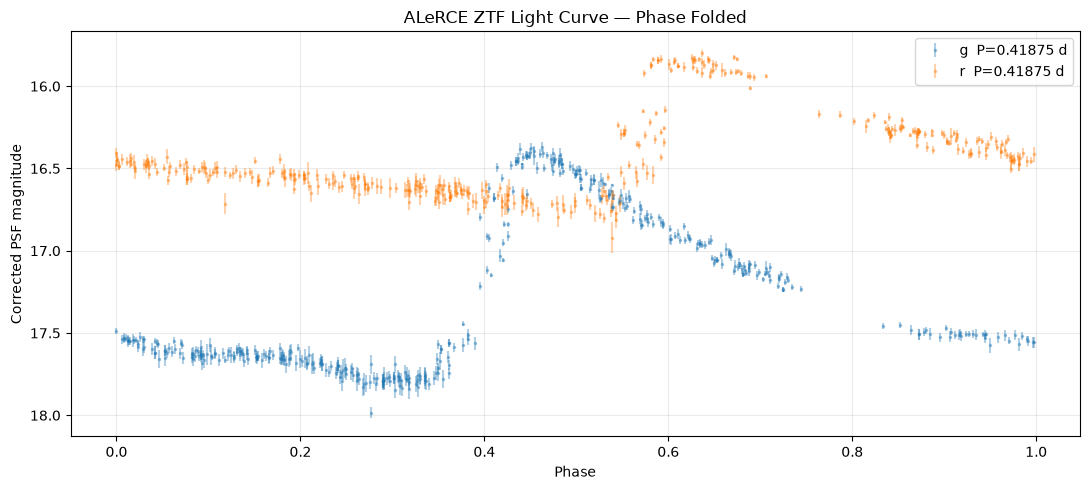

In [47]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 5))

ax.errorbar(
    g_phase["phase"],
    g_phase["mag"],
    yerr=g_phase["magerr"],
    fmt=".",
    alpha=0.35,
    markersize=3,
    label=f"g  P={g_period:.5f} d",
)

ax.errorbar(
    r_phase["phase"],
    r_phase["mag"],
    yerr=r_phase["magerr"],
    fmt=".",
    alpha=0.35,
    markersize=3,
    label=f"r  P={r_period:.5f} d",
)

ax.invert_yaxis()

ax.set_xlabel("Phase")
ax.set_ylabel("Corrected PSF magnitude")
ax.set_title("ALeRCE ZTF Light Curve — Phase Folded")

ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [48]:
def phase_morphology_features(lc, period, band):
    """
    Extract morphology features from a phase-folded light curve.

    Parameters
    ----------
    lc : pandas.DataFrame
        Columns: mjd, mag, magerr
    period : float
        Period in days.
    band : str
        Band name.
    """

    df = phase_fold(lc, period)

    phase = df["phase"].to_numpy(dtype=float)
    mag = df["mag"].to_numpy(dtype=float)

    valid = np.isfinite(phase) & np.isfinite(mag)

    phase = phase[valid]
    mag = mag[valid]

    if len(mag) < 10:
        raise ValueError(f"Not enough points for morphology: {band}")

    # Basic amplitude
    amplitude = np.max(mag) - np.min(mag)

    # Percentile-based robust amplitude
    p05, p25, p50, p75, p95 = np.percentile(
        mag, [5, 25, 50, 75, 95]
    )

    robust_amplitude = p95 - p05
    iqr = p75 - p25

    # Skewness
    mean = np.mean(mag)
    std = np.std(mag, ddof=1)

    if std > 0:
        skewness = np.mean(
            ((mag - mean) / std) ** 3
        )
    else:
        skewness = np.nan

    # Phase location of minimum/maximum magnitude.
    # Remember: lower magnitude = brighter.
    min_mag_phase = phase[np.argmin(mag)]
    max_mag_phase = phase[np.argmax(mag)]

    # Fraction of observations in the bright half
    bright_threshold = np.median(mag)
    bright_fraction = np.mean(mag <= bright_threshold)

    return {
        f"{band}_phase_amplitude": amplitude,
        f"{band}_phase_robust_amplitude": robust_amplitude,
        f"{band}_phase_iqr": iqr,
        f"{band}_phase_skewness": skewness,
        f"{band}_phase_min_mag_phase": min_mag_phase,
        f"{band}_phase_max_mag_phase": max_mag_phase,
        f"{band}_phase_bright_fraction": bright_fraction,
    }

In [49]:
phase_features = {}

phase_features.update(
    phase_morphology_features(
        alerc_g,
        g_period,
        "g"
    )
)

phase_features.update(
    phase_morphology_features(
        alerc_r,
        r_period,
        "r"
    )
)

phase_features_df = pd.DataFrame([phase_features])

print("Phase morphology feature count:",
      len(phase_features_df.columns))

display(phase_features_df.T)

Phase morphology feature count: 14


,0
g_phase_amplitude,1.613880
g_phase_robust_amplitude,1.334724
g_phase_iqr,0.802635
g_phase_skewness,-0.589554
g_phase_min_mag_phase,0.462573
g_phase_max_mag_phase,0.276828
g_phase_bright_fraction,0.501166
r_phase_amplitude,1.119362
r_phase_robust_amplitude,0.852072
r_phase_iqr,0.317849


In [50]:
all_features = {}

all_features.update(alerc_basic_features)
all_features.update(ls_features)
all_features.update(phase_features)

final_features_v01 = pd.DataFrame([all_features])

print("Total feature count:",
      len(final_features_v01.columns))

display(final_features_v01.T)

Total feature count: 72


,0
g_n_obs,4.290000e+02
g_baseline_days,2.764658e+03
g_mean_mag,1.728080e+01
g_median_mag,1.752919e+01
g_weighted_mean_mag,1.713126e+01
g_std_mag,4.659375e-01
g_mad_mag,2.483140e-01
g_min_mag,1.636944e+01
g_max_mag,1.798332e+01
g_amplitude_mag,1.613880e+00


In [51]:
numeric = final_features_v01.select_dtypes(include=[np.number])

print("Total features:", len(numeric.columns))
print("NaN values:", numeric.isna().sum().sum())
print("Infinite values:",
      np.isinf(numeric.to_numpy()).sum())

constant_features = [
    col for col in numeric.columns
    if numeric[col].nunique(dropna=False) <= 1
]

print("Constant features:", len(constant_features))

if constant_features:
    print(constant_features)

Total features: 72
NaN values: 0
Infinite values: 0
Constant features: 72
['g_n_obs', 'g_baseline_days', 'g_mean_mag', 'g_median_mag', 'g_weighted_mean_mag', 'g_std_mag', 'g_mad_mag', 'g_min_mag', 'g_max_mag', 'g_amplitude_mag', 'g_p05_mag', 'g_p25_mag', 'g_p75_mag', 'g_p95_mag', 'g_iqr_mag', 'g_p95_p05_mag', 'g_mean_magerr', 'g_median_magerr', 'g_rms_mag', 'g_reduced_chi2_like', 'g_median_abs_norm_resid', 'r_n_obs', 'r_baseline_days', 'r_mean_mag', 'r_median_mag', 'r_weighted_mean_mag', 'r_std_mag', 'r_mad_mag', 'r_min_mag', 'r_max_mag', 'r_amplitude_mag', 'r_p05_mag', 'r_p25_mag', 'r_p75_mag', 'r_p95_mag', 'r_iqr_mag', 'r_p95_p05_mag', 'r_mean_magerr', 'r_median_magerr', 'r_rms_mag', 'r_reduced_chi2_like', 'r_median_abs_norm_resid', 'mean_color_gr', 'median_color_gr', 'g_variability_ratio', 'r_variability_ratio', 'g_ls_best_period_days', 'g_ls_best_frequency', 'g_ls_best_power', 'g_ls_fap', 'g_ls_min_period_days', 'g_ls_max_period_days', 'r_ls_best_period_days', 'r_ls_best_frequency'

In [52]:
print("Feature vector shape:", final_features_v01.shape)

print("\nNaN values:",
      final_features_v01.isna().sum().sum())

print("Infinite values:",
      np.isinf(
          final_features_v01.select_dtypes(include=[np.number]).to_numpy()
      ).sum())

print("\nSingle-object constant-feature check:")
print(
    "Skipped — only one object is currently available."
)

Feature vector shape: (1, 72)

NaN values: 0
Infinite values: 0

Single-object constant-feature check:
Skipped — only one object is currently available.


In [53]:
object_record = {
    "object_id": alerc_oid,

    "label": "RRL",
    "label_source": "ALeRCE",
    "label_type": "benchmark",

    "label_probability": 0.950096,

    "classifier": "lc_classifier",
    "classifier_version": "hierarchical_random_forest_1.0.0",

    "data_source": "ALeRCE",
    "survey": "ZTF",

    "feature_version": "v0.1",
}

labeled_record = {
    **object_record,
    **final_features_v01.iloc[0].to_dict(),
}

labeled_record_df = pd.DataFrame([labeled_record])

print("Shape:", labeled_record_df.shape)
display(labeled_record_df.T)

Shape: (1, 82)


,0
object_id,ZTF18aauelee
label,RRL
label_source,ALeRCE
label_type,benchmark
label_probability,0.950096
classifier,lc_classifier
classifier_version,hierarchical_random_forest_1.0.0
data_source,ALeRCE
survey,ZTF
feature_version,v0.1


In [54]:
ALERCE_CLASSES = [
    "SNIa",
    "SNIbc",
    "SNII",
    "SLSN",
    "QSO",
    "AGN",
    "Blazar",
    "CV/Nova",
    "YSO",
    "LPV",
    "E",
    "DSCT",
    "RRL",
    "CEP",
    "Periodic-Other",
]

print("Number of classes:", len(ALERCE_CLASSES))
print(ALERCE_CLASSES)

Number of classes: 15
['SNIa', 'SNIbc', 'SNII', 'SLSN', 'QSO', 'AGN', 'Blazar', 'CV/Nova', 'YSO', 'LPV', 'E', 'DSCT', 'RRL', 'CEP', 'Periodic-Other']


In [55]:
SAMPLES_PER_CLASS = 10
MIN_PROBABILITY = 0.90

acquisition_plan = {
    cls: {
        "class_name": cls,
        "classifier": "lc_classifier",
        "probability": MIN_PROBABILITY,
        "page_size": SAMPLES_PER_CLASS,
    }
    for cls in ALERCE_CLASSES
}

print("Classes:", len(acquisition_plan))
print("Target objects:",
      len(ALERCE_CLASSES) * SAMPLES_PER_CLASS)

Classes: 15
Target objects: 150


In [56]:
all_objects = []

for class_name, params in acquisition_plan.items():

    print(f"Querying {class_name}...")

    result = client.query_objects(
        survey="ztf",
        classifier=params["classifier"],
        class_name=params["class_name"],
        probability=params["probability"],
        page_size=params["page_size"],
        format="pandas",
    )

    if len(result) == 0:
        print("  -> no objects returned")
        continue

    result = result.copy()
    result["label_source"] = "ALeRCE"
    result["label_type"] = "benchmark"
    result["label_probability"] = result["probability"]

    all_objects.append(result)

    print(f"  -> {len(result)} objects")

alerc_objects_v01 = pd.concat(
    all_objects,
    ignore_index=True
)

print("\nTotal objects:", len(alerc_objects_v01))
print("\nClass distribution:")
display(
    alerc_objects_v01["class"]
    .value_counts()
    .sort_index()
)

Querying SNIa...
  -> no objects returned
Querying SNIbc...
  -> no objects returned
Querying SNII...
  -> no objects returned
Querying SLSN...
  -> no objects returned
Querying QSO...
  -> 10 objects
Querying AGN...
  -> 10 objects
Querying Blazar...
  -> 10 objects
Querying CV/Nova...
  -> no objects returned
Querying YSO...
  -> 10 objects
Querying LPV...
  -> 10 objects
Querying E...
  -> 10 objects
Querying DSCT...
  -> 10 objects
Querying RRL...
  -> 10 objects
Querying CEP...
  -> 10 objects
Querying Periodic-Other...
  -> no objects returned

Total objects: 90

Class distribution:


class
AGN       10
Blazar    10
CEP       10
DSCT      10
E         10
LPV       10
QSO       10
RRL       10
YSO       10
Name: count, dtype: int64

In [57]:
missing_classes = [
    cls for cls in ALERCE_CLASSES
    if cls not in set(alerc_objects_v01["class"])
]

print("Missing classes:")
print(missing_classes)

availability_check = {}

for class_name in missing_classes:

    result = client.query_objects(
        survey="ztf",
        classifier="lc_classifier",
        class_name=class_name,
        probability=0.50,
        page_size=10,
        format="pandas",
    )

    availability_check[class_name] = len(result)

    print(f"{class_name:16s} -> {len(result)} objects")

Missing classes:
['SNIa', 'SNIbc', 'SNII', 'SLSN', 'CV/Nova', 'Periodic-Other']
SNIa             -> 10 objects
SNIbc            -> 10 objects
SNII             -> 10 objects
SLSN             -> 10 objects
CV/Nova          -> 10 objects
Periodic-Other   -> 10 objects


In [58]:
all_objects = []

for class_name in ALERCE_CLASSES:

    result = client.query_objects(
        survey="ztf",
        classifier="lc_classifier",
        class_name=class_name,
        probability=0.50,
        page_size=SAMPLES_PER_CLASS,
        format="pandas",
    )

    if len(result) == 0:
        print(f"{class_name}: NO DATA")
        continue

    result = result.copy()

    result["label_source"] = "ALeRCE"
    result["label_type"] = "benchmark"
    result["label_probability"] = result["probability"]
    result["classifier"] = "lc_classifier"
    result["classifier_version"] = "hierarchical_random_forest_1.0.0"
    result["survey"] = "ZTF"

    all_objects.append(result)

alerc_objects_v01 = pd.concat(
    all_objects,
    ignore_index=True
)

print("Total objects:", len(alerc_objects_v01))

print("\nClass distribution:")
display(
    alerc_objects_v01["class"]
    .value_counts()
    .sort_index()
)

Total objects: 150

Class distribution:


class
AGN               10
Blazar            10
CEP               10
CV/Nova           10
DSCT              10
E                 10
LPV               10
Periodic-Other    10
QSO               10
RRL               10
SLSN              10
SNII              10
SNIa              10
SNIbc             10
YSO               10
Name: count, dtype: int64

In [59]:
label_probability_summary = (
    alerc_objects_v01
    .groupby("class")["label_probability"]
    .agg(["min", "median", "max", "mean"])
    .round(4)
)

display(label_probability_summary)

,min,median,max,mean
class,,,,
AGN,0.5000,0.5000,0.5000,0.5000
Blazar,0.5001,0.5001,0.5002,0.5001
CEP,0.5001,0.5001,0.5003,0.5002
CV/Nova,0.5000,0.5006,0.5009,0.5005
DSCT,0.5000,0.5001,0.5003,0.5001
E,0.5000,0.5000,0.5000,0.5000
LPV,0.5000,0.5000,0.5000,0.5000
Periodic-Other,0.5000,0.5000,0.5000,0.5000
QSO,0.5000,0.5000,0.5000,0.5000


In [61]:
from pathlib import Path

project_root = Path.home() / "projects" / "ztf-classifier"

metadata_path = (
    project_root
    / "data"
    / "processed"
    / "alerc_objects_v0.1.parquet"
)

metadata_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

alerc_objects_v01.to_parquet(
    metadata_path,
    index=False
)

print("Saved:")
print(metadata_path)

print("Rows:", len(alerc_objects_v01))
print("Columns:", len(alerc_objects_v01.columns))

Saved:
/home/saeed92m/projects/ztf-classifier/data/processed/alerc_objects_v0.1.parquet
Rows: 150
Columns: 28


In [62]:
test_reload = pd.read_parquet(metadata_path)

print("Reloaded shape:", test_reload.shape)
print(
    "Classes:",
    test_reload["class"].nunique()
)

display(
    test_reload["class"]
    .value_counts()
    .sort_index()
)

Reloaded shape: (150, 28)
Classes: 15


class
AGN               10
Blazar            10
CEP               10
CV/Nova           10
DSCT              10
E                 10
LPV               10
Periodic-Other    10
QSO               10
RRL               10
SLSN              10
SNII              10
SNIa              10
SNIbc             10
YSO               10
Name: count, dtype: int64

In [63]:
from pathlib import Path

project_root = Path.home() / "projects" / "ztf-classifier"

raw_lc_dir = (
    project_root
    / "data"
    / "raw"
    / "alerc_e"
)

processed_lc_dir = (
    project_root
    / "data"
    / "processed"
    / "alerc_e"
)

raw_lc_dir.mkdir(parents=True, exist_ok=True)
processed_lc_dir.mkdir(parents=True, exist_ok=True)

print("Raw:", raw_lc_dir)
print("Processed:", processed_lc_dir)

Raw: /home/saeed92m/projects/ztf-classifier/data/raw/alerc_e
Processed: /home/saeed92m/projects/ztf-classifier/data/processed/alerc_e


In [64]:
def fetch_and_cache_alerc_e_lightcurve(oid, client, cache_dir):
    """
    Fetch an ALeRCE ZTF light curve once and cache it locally.
    """

    cache_dir = Path(cache_dir)

    detection_path = cache_dir / f"{oid}_detections.parquet"
    nondetection_path = cache_dir / f"{oid}_non_detections.parquet"

    # Cache hit
    if detection_path.exists() and nondetection_path.exists():
        detections = pd.read_parquet(detection_path)
        non_detections = pd.read_parquet(nondetection_path)

        return detections, non_detections, True

    # API request
    response = client.query_lightcurve(
        oid,
        format="pandas",
        survey="ztf",
    )

    detections = pd.DataFrame(
        response.iloc[0]["detections"]
    )

    non_detections = pd.DataFrame(
        response.iloc[0]["non_detections"]
    )

    # Save raw API-derived tables
    detections.to_parquet(
        detection_path,
        index=False
    )

    non_detections.to_parquet(
        nondetection_path,
        index=False
    )

    return detections, non_detections, False

In [65]:
test_oid = "ZTF18aauelee"

test_det, test_nondet, cache_hit = (
    fetch_and_cache_alerc_e_lightcurve(
        test_oid,
        client,
        raw_lc_dir
    )
)

print("OID:", test_oid)
print("Cache hit:", cache_hit)
print("Detections:", test_det.shape)
print("Non-detections:", test_nondet.shape)

OID: ZTF18aauelee
Cache hit: False
Detections: (803, 34)
Non-detections: (369, 4)


In [66]:
raw_lc_dir = (
    project_root
    / "data"
    / "raw"
    / "alerce"
)

processed_lc_dir = (
    project_root
    / "data"
    / "processed"
    / "alerce"
)

raw_lc_dir.mkdir(parents=True, exist_ok=True)
processed_lc_dir.mkdir(parents=True, exist_ok=True)

# Move the test cache if it was created under the typo path.
old_raw_lc_dir = (
    project_root
    / "data"
    / "raw"
    / "alerc_e"
)

old_det = old_raw_lc_dir / "ZTF18aauelee_detections.parquet"
old_non = old_raw_lc_dir / "ZTF18aauelee_non_detections.parquet"

if old_det.exists():
    old_det.replace(raw_lc_dir / old_det.name)

if old_non.exists():
    old_non.replace(raw_lc_dir / old_non.name)

print("Raw:", raw_lc_dir)
print("Processed:", processed_lc_dir)

Raw: /home/saeed92m/projects/ztf-classifier/data/raw/alerce
Processed: /home/saeed92m/projects/ztf-classifier/data/processed/alerce


In [67]:
import time

acquisition_log = []

for i, row in alerc_objects_v01.iterrows():

    oid = row["oid"]
    class_name = row["class"]

    print(
        f"[{i + 1:03d}/{len(alerc_objects_v01)}] "
        f"{oid} | {class_name}",
        end=" "
    )

    start = time.time()

    try:
        detections_i, non_detections_i, cache_hit = (
            fetch_and_cache_alerc_e_lightcurve(
                oid,
                client,
                raw_lc_dir
            )
        )

        elapsed = time.time() - start

        acquisition_log.append({
            "oid": oid,
            "class": class_name,
            "status": "ok",
            "cache_hit": cache_hit,
            "n_detections": len(detections_i),
            "n_non_detections": len(non_detections_i),
            "elapsed_sec": elapsed,
        })

        source = "CACHE" if cache_hit else "API"

        print(
            f"OK | {source} | "
            f"det={len(detections_i)} | "
            f"non={len(non_detections_i)}"
        )

    except Exception as exc:

        elapsed = time.time() - start

        acquisition_log.append({
            "oid": oid,
            "class": class_name,
            "status": "error",
            "cache_hit": False,
            "n_detections": 0,
            "n_non_detections": 0,
            "elapsed_sec": elapsed,
            "error": repr(exc),
        })

        print(f"ERROR | {exc}")

    # Small delay between API requests
    if i < len(alerc_objects_v01) - 1:
        time.sleep(0.15)


acquisition_log_df = pd.DataFrame(acquisition_log)

print("\nAcquisition finished.")
print(
    acquisition_log_df["status"]
    .value_counts()
)

[001/150] ZTF21abujefa | SNIa OK | API | det=36 | non=45
[002/150] ZTF23aaixylr | SNIa OK | API | det=14 | non=25
[003/150] ZTF22aakqvzc | SNIa OK | API | det=27 | non=20
[004/150] ZTF22aadfbim | SNIa OK | API | det=41 | non=11
[005/150] ZTF22abnqpwe | SNIa OK | API | det=11 | non=21
[006/150] ZTF23aadozop | SNIa OK | API | det=27 | non=9
[007/150] ZTF22abhcqrr | SNIa OK | API | det=49 | non=41
[008/150] ZTF21achzpyc | SNIa OK | API | det=33 | non=39
[009/150] ZTF22aafctmu | SNIa OK | API | det=22 | non=9
[010/150] ZTF22abfwihc | SNIa OK | API | det=20 | non=25
[011/150] ZTF23aajadng | SNIbc OK | API | det=21 | non=6
[012/150] ZTF18acbwgin | SNIbc OK | API | det=11 | non=7
[013/150] ZTF19aavoiyc | SNIbc OK | API | det=24 | non=15
[014/150] ZTF20abhvnzc | SNIbc OK | API | det=19 | non=20
[015/150] ZTF22abazqjm | SNIbc OK | API | det=33 | non=69
[016/150] ZTF23abhzekh | SNIbc OK | API | det=15 | non=13
[017/150] ZTF19acdcgqm | SNIbc OK | API | det=37 | non=247
[018/150] ZTF22abtcyiu | SN

In [68]:
print("Total:", len(acquisition_log_df))

print("\nStatus:")
display(
    acquisition_log_df["status"]
    .value_counts()
)

print("\nSuccessful detections:")
display(
    acquisition_log_df.loc[
        acquisition_log_df["status"] == "ok"
    ]
    .groupby("class")["n_detections"]
    .agg(["count", "min", "median", "max"])
)

errors = acquisition_log_df[
    acquisition_log_df["status"] == "error"
]

print("\nErrors:", len(errors))

if len(errors):
    display(errors)

Total: 150

Status:


status
ok    150
Name: count, dtype: int64


Successful detections:


,count,min,median,max
class,,,,
AGN,10,30,73.5,358
Blazar,10,39,283.0,695
CEP,10,12,57.0,806
CV/Nova,10,164,346.0,1732
DSCT,10,30,134.5,752
E,10,195,435.5,755
LPV,10,10,43.5,176
Periodic-Other,10,17,63.5,223
QSO,10,28,93.5,277



Errors: 0


In [69]:
acquisition_log_path = (
    project_root
    / "data"
    / "processed"
    / "alerce_acquisition_log_v0.1.parquet"
)

acquisition_log_df.to_parquet(
    acquisition_log_path,
    index=False
)

print("Saved:")
print(acquisition_log_path)

Saved:
/home/saeed92m/projects/ztf-classifier/data/processed/alerce_acquisition_log_v0.1.parquet


In [70]:
successful = acquisition_log_df[
    acquisition_log_df["status"] == "ok"
].copy()

print("Objects:", len(successful))

print("\nDetection statistics:")
display(
    successful["n_detections"]
    .describe()
)

print("\nObjects with <10 detections:")
display(
    successful.loc[
        successful["n_detections"] < 10,
        ["oid", "class", "n_detections"]
    ]
)

print("\nObjects with <20 detections:")
print(
    (
        successful["n_detections"] < 20
    ).sum()
)

Objects: 150

Detection statistics:


count     150.000000
mean      189.633333
std       262.609988
min         4.000000
25%        33.000000
50%        74.000000
75%       276.250000
max      1732.000000
Name: n_detections, dtype: float64


Objects with <10 detections:


,oid,class,n_detections
86,ZTF18adayaxg,YSO,4



Objects with <20 detections:
15


In [71]:
class_detection_summary = (
    successful
    .groupby("class")["n_detections"]
    .agg(
        count="count",
        min="min",
        median="median",
        mean="mean",
        max="max",
    )
    .round(2)
)

display(class_detection_summary)

,count,min,median,mean,max
class,,,,,
AGN,10,30,73.5,118.5,358
Blazar,10,39,283.0,274.7,695
CEP,10,12,57.0,188.9,806
CV/Nova,10,164,346.0,641.3,1732
DSCT,10,30,134.5,187.0,752
E,10,195,435.5,440.6,755
LPV,10,10,43.5,65.2,176
Periodic-Other,10,17,63.5,73.1,223
QSO,10,28,93.5,112.5,277


In [72]:
def classify_detection_quality(n_detections):
    if n_detections < 10:
        return "insufficient"
    elif n_detections < 30:
        return "limited"
    elif n_detections < 100:
        return "standard"
    else:
        return "rich"


successful["detection_quality"] = (
    successful["n_detections"]
    .apply(classify_detection_quality)
)

print("Detection quality distribution:")
display(
    successful["detection_quality"]
    .value_counts()
    .rename_axis("quality")
    .to_frame("count")
)

print("\nBy class:")
display(
    pd.crosstab(
        successful["class"],
        successful["detection_quality"]
    )
)

Detection quality distribution:


,count
quality,
rich,61
standard,58
limited,30
insufficient,1



By class:


detection_quality,insufficient,limited,rich,standard
class,,,,
AGN,0,0,3,7
Blazar,0,0,7,3
CEP,0,3,4,3
CV/Nova,0,0,10,0
DSCT,0,0,7,3
E,0,0,10,0
LPV,0,3,2,5
Periodic-Other,0,3,1,6
QSO,0,1,4,5


In [73]:
low_detection = successful[
    successful["n_detections"] < 30
].copy()

low_detection = low_detection.sort_values(
    ["class", "n_detections"]
)

display(
    low_detection[
        [
            "oid",
            "class",
            "n_detections",
            "n_non_detections",
            "detection_quality",
        ]
    ]
)

,oid,class,n_detections,n_non_detections,detection_quality
139,ZTF19aaggork,CEP,12,125,limited
135,ZTF18abyrzgu,CEP,14,347,limited
136,ZTF19aaedyht,CEP,20,107,limited
91,ZTF19aavpvzf,LPV,10,105,limited
98,ZTF23aacgtky,LPV,15,94,limited
94,ZTF19aawqowd,LPV,21,167,limited
146,ZTF19aacwbmb,Periodic-Other,17,22,limited
144,ZTF20aallmea,Periodic-Other,21,255,limited
140,ZTF18abatgbn,Periodic-Other,23,190,limited
41,ZTF21aasgmrt,QSO,28,60,limited


In [74]:
successful["total_observations"] = (
    successful["n_detections"]
    + successful["n_non_detections"]
)

successful["detection_fraction"] = (
    successful["n_detections"]
    / successful["total_observations"]
)

display(
    successful[
        [
            "oid",
            "class",
            "n_detections",
            "n_non_detections",
            "total_observations",
            "detection_fraction",
        ]
    ]
    .sort_values("detection_fraction")
    .head(20)
)

,oid,class,n_detections,n_non_detections,total_observations,detection_fraction
135,ZTF18abyrzgu,CEP,14,347,361,0.038781
110,ZTF18aanygot,DSCT,30,449,479,0.062630
87,ZTF18abaklec,YSO,49,720,769,0.063719
144,ZTF20aallmea,Periodic-Other,21,255,276,0.076087
84,ZTF19aarxwjo,YSO,42,483,525,0.080000
80,ZTF18abdbfup,YSO,53,582,635,0.083465
88,ZTF19abclzsc,YSO,29,315,344,0.084302
91,ZTF19aavpvzf,LPV,10,105,115,0.086957
139,ZTF19aaggork,CEP,12,125,137,0.087591
118,ZTF18aazuyzf,DSCT,162,1617,1779,0.091062


In [75]:
qc_class_summary = (
    successful
    .groupby("class")
    .agg(
        objects=("oid", "count"),
        detections_median=("n_detections", "median"),
        detections_mean=("n_detections", "mean"),
        detections_min=("n_detections", "min"),
        detection_fraction_median=("detection_fraction", "median"),
        detection_fraction_mean=("detection_fraction", "mean"),
    )
    .round(3)
)

display(qc_class_summary)

,objects,detections_median,detections_mean,detections_min,detection_fraction_median,detection_fraction_mean
class,,,,,,
AGN,10,73.5,118.5,30,0.402,0.389
Blazar,10,283.0,274.7,39,0.439,0.458
CEP,10,57.0,188.9,12,0.212,0.243
CV/Nova,10,346.0,641.3,164,0.489,0.551
DSCT,10,134.5,187.0,30,0.154,0.166
E,10,435.5,440.6,195,0.384,0.399
LPV,10,43.5,65.2,10,0.155,0.182
Periodic-Other,10,63.5,73.1,17,0.165,0.184
QSO,10,93.5,112.5,28,0.425,0.394


In [76]:
from pathlib import Path
import numpy as np
import pandas as pd

def inspect_alerc_e_lightcurve(oid, cache_dir):
    cache_dir = Path(cache_dir)

    detection_path = cache_dir / f"{oid}_detections.parquet"
    nondetection_path = cache_dir / f"{oid}_non_detections.parquet"

    detections = pd.read_parquet(detection_path)
    non_detections = pd.read_parquet(nondetection_path)

    qc = {
        "oid": oid,

        "n_rows": len(detections),

        "n_fid1": int((detections["fid"] == 1).sum()),
        "n_fid2": int((detections["fid"] == 2).sum()),

        "n_finite_mjd": int(np.isfinite(detections["mjd"]).sum()),
        "n_finite_mag": int(np.isfinite(detections["magpsf_corr"]).sum()),
        "n_finite_magerr": int(
            np.isfinite(detections["sigmapsf_corr_ext"]).sum()
        ),

        "n_positive_magerr": int(
            (detections["sigmapsf_corr_ext"] > 0).sum()
        ),

        "n_dubious": int(detections["dubious"].astype(bool).sum()),
        "n_corrected": int(detections["corrected"].astype(bool).sum()),

        "mjd_min": float(detections["mjd"].min()),
        "mjd_max": float(detections["mjd"].max()),

        "magerr_median": float(
            detections["sigmapsf_corr_ext"].median()
        ),

        "magerr_max": float(
            detections["sigmapsf_corr_ext"].max()
        ),
    }

    qc["baseline_days"] = qc["mjd_max"] - qc["mjd_min"]

    qc["has_g"] = qc["n_fid1"] > 0
    qc["has_r"] = qc["n_fid2"] > 0
    qc["has_both_bands"] = qc["has_g"] and qc["has_r"]

    return qc


lightcurve_qc_records = []

for oid in successful["oid"]:
    try:
        record = inspect_alerc_e_lightcurve(
            oid,
            raw_lc_dir,
        )
        record["status"] = "ok"

    except Exception as exc:
        record = {
            "oid": oid,
            "status": "error",
            "error": repr(exc),
        }

    lightcurve_qc_records.append(record)


lightcurve_qc_df = pd.DataFrame(lightcurve_qc_records)

print("QC records:", len(lightcurve_qc_df))
print("\nStatus:")
display(lightcurve_qc_df["status"].value_counts())

QC records: 150

Status:


status
ok       133
error     17
Name: count, dtype: int64

In [77]:
errors_qc = lightcurve_qc_df[
    lightcurve_qc_df["status"] == "error"
].copy()

print("Number of errors:", len(errors_qc))

display(
    errors_qc[
        ["oid", "status", "error"]
    ]
)

Number of errors: 17


,oid,status,error
1,ZTF23aaixylr,error,"TypeError(""ufunc 'isfinite' not supported for ..."
10,ZTF23aajadng,error,"TypeError(""ufunc 'isfinite' not supported for ..."
11,ZTF18acbwgin,error,"TypeError(""ufunc 'isfinite' not supported for ..."
12,ZTF19aavoiyc,error,"TypeError(""ufunc 'isfinite' not supported for ..."
13,ZTF20abhvnzc,error,"TypeError(""ufunc 'isfinite' not supported for ..."
14,ZTF22abazqjm,error,"TypeError(""ufunc 'isfinite' not supported for ..."
15,ZTF23abhzekh,error,"TypeError(""ufunc 'isfinite' not supported for ..."
16,ZTF19acdcgqm,error,"TypeError(""ufunc 'isfinite' not supported for ..."
18,ZTF19aalfsrm,error,"TypeError(""ufunc 'isfinite' not supported for ..."
19,ZTF23aadtlyv,error,"TypeError(""ufunc 'isfinite' not supported for ..."


In [78]:
for _, row in errors_qc.iterrows():
    oid = row["oid"]

    detection_path = raw_lc_dir / f"{oid}_detections.parquet"
    nondetection_path = raw_lc_dir / f"{oid}_non_detections.parquet"

    print(f"\nOID: {oid}")
    print("Detection cache:", detection_path.exists())
    print("Non-detection cache:", nondetection_path.exists())
    print("Error:", row["error"])


OID: ZTF23aaixylr
Detection cache: True
Non-detection cache: True
Error: TypeError("ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''")

OID: ZTF23aajadng
Detection cache: True
Non-detection cache: True
Error: TypeError("ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''")

OID: ZTF18acbwgin
Detection cache: True
Non-detection cache: True
Error: TypeError("ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''")

OID: ZTF19aavoiyc
Detection cache: True
Non-detection cache: True
Error: TypeError("ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''")

OID: ZTF20abhvnzc
Detec

In [79]:
error_oids = errors_qc["oid"].tolist()

dtype_records = []

for oid in error_oids:
    detection_path = raw_lc_dir / f"{oid}_detections.parquet"
    df = pd.read_parquet(detection_path)

    for col in [
        "mjd",
        "magpsf_corr",
        "sigmapsf_corr_ext",
        "fid",
        "dubious",
        "corrected",
    ]:
        dtype_records.append({
            "oid": oid,
            "column": col,
            "dtype": str(df[col].dtype),
            "sample": df[col].dropna().iloc[0]
                if df[col].notna().any()
                else None,
        })

dtype_check = pd.DataFrame(dtype_records)

display(
    dtype_check[
        dtype_check["dtype"] == "object"
    ]
)

,oid,column,dtype,sample
1,ZTF23aaixylr,magpsf_corr,object,None
2,ZTF23aaixylr,sigmapsf_corr_ext,object,None
7,ZTF23aajadng,magpsf_corr,object,None
8,ZTF23aajadng,sigmapsf_corr_ext,object,None
13,ZTF18acbwgin,magpsf_corr,object,None
14,ZTF18acbwgin,sigmapsf_corr_ext,object,None
19,ZTF19aavoiyc,magpsf_corr,object,None
20,ZTF19aavoiyc,sigmapsf_corr_ext,object,None
25,ZTF20abhvnzc,magpsf_corr,object,None
26,ZTF20abhvnzc,sigmapsf_corr_ext,object,None


In [80]:
display(
    dtype_check
    .pivot(
        index="oid",
        columns="column",
        values="dtype"
    )
)

column,corrected,dubious,fid,magpsf_corr,mjd,sigmapsf_corr_ext
oid,,,,,,
ZTF18acakwsu,bool,bool,int64,object,float64,object
ZTF18acbwgin,bool,bool,int64,object,float64,object
ZTF19aalfsrm,bool,bool,int64,object,float64,object
ZTF19aavoiyc,bool,bool,int64,object,float64,object
ZTF19acdcgqm,bool,bool,int64,object,float64,object
ZTF20abhvnzc,bool,bool,int64,object,float64,object
ZTF21aabyoxv,bool,bool,int64,object,float64,object
ZTF21abievmx,bool,bool,int64,object,float64,object
ZTF21ablxfwc,bool,bool,int64,object,float64,object


In [81]:
photometry_availability = []

for oid in successful["oid"]:
    detection_path = raw_lc_dir / f"{oid}_detections.parquet"
    df = pd.read_parquet(detection_path)

    mag_corr_numeric = pd.to_numeric(
        df["magpsf_corr"],
        errors="coerce"
    )

    magerr_corr_numeric = pd.to_numeric(
        df["sigmapsf_corr_ext"],
        errors="coerce"
    )

    mag_raw_numeric = pd.to_numeric(
        df["magpsf"],
        errors="coerce"
    )

    magerr_raw_numeric = pd.to_numeric(
        df["sigmapsf"],
        errors="coerce"
    )

    photometry_availability.append({
        "oid": oid,

        "n_rows": len(df),

        "n_mag_corr": int(mag_corr_numeric.notna().sum()),
        "n_magerr_corr": int(magerr_corr_numeric.notna().sum()),

        "n_mag_raw": int(mag_raw_numeric.notna().sum()),
        "n_magerr_raw": int(magerr_raw_numeric.notna().sum()),
    })

photometry_availability_df = pd.DataFrame(
    photometry_availability
)

display(photometry_availability_df)

,oid,n_rows,n_mag_corr,n_magerr_corr,n_mag_raw,n_magerr_raw
0,ZTF21abujefa,36,36,36,36,36
1,ZTF23aaixylr,14,0,0,14,14
2,ZTF22aakqvzc,27,6,6,27,27
3,ZTF22aadfbim,41,19,19,41,41
4,ZTF22abnqpwe,11,7,7,11,11
...,...,...,...,...,...,...
145,ZTF21abdihbf,74,74,74,74,74
146,ZTF19aacwbmb,17,17,17,17,17
147,ZTF19aaywmuy,53,53,53,53,53
148,ZTF18aczhyvv,41,41,41,41,41


In [82]:
def classify_photometry_source(row):
    if (
        row["n_mag_corr"] > 0
        and row["n_magerr_corr"] > 0
    ):
        return "corrected"

    if (
        row["n_mag_raw"] > 0
        and row["n_magerr_raw"] > 0
    ):
        return "raw_fallback"

    return "unusable"


photometry_availability_df["photometry_source"] = (
    photometry_availability_df.apply(
        classify_photometry_source,
        axis=1
    )
)

print("Photometry source:")
display(
    photometry_availability_df[
        "photometry_source"
    ].value_counts()
)

print("\nObjects using raw fallback:")
display(
    photometry_availability_df[
        photometry_availability_df["photometry_source"]
        == "raw_fallback"
    ]
)

Photometry source:


photometry_source
corrected       133
raw_fallback     17
Name: count, dtype: int64


Objects using raw fallback:


,oid,n_rows,n_mag_corr,n_magerr_corr,n_mag_raw,n_magerr_raw,photometry_source
1,ZTF23aaixylr,14,0,0,14,14,raw_fallback
10,ZTF23aajadng,21,0,0,21,21,raw_fallback
11,ZTF18acbwgin,11,0,0,11,11,raw_fallback
12,ZTF19aavoiyc,24,0,0,24,24,raw_fallback
13,ZTF20abhvnzc,19,0,0,19,19,raw_fallback
14,ZTF22abazqjm,33,0,0,33,33,raw_fallback
15,ZTF23abhzekh,15,0,0,15,15,raw_fallback
16,ZTF19acdcgqm,37,0,0,37,37,raw_fallback
18,ZTF19aalfsrm,13,0,0,13,13,raw_fallback
19,ZTF23aadtlyv,13,0,0,13,13,raw_fallback


In [83]:
fallback_oids = photometry_availability_df.loc[
    photometry_availability_df["photometry_source"] == "raw_fallback",
    "oid"
].tolist()

print("Fallback objects:", len(fallback_oids))

for oid in fallback_oids:
    df = pd.read_parquet(
        raw_lc_dir / f"{oid}_detections.parquet"
    )

    print(f"\n{oid}")
    print("Rows:", len(df))
    print("magpsf dtype:", df["magpsf"].dtype)
    print("sigmapsf dtype:", df["sigmapsf"].dtype)
    print("Valid raw mag:", pd.to_numeric(
        df["magpsf"], errors="coerce"
    ).notna().sum())
    print("Valid raw magerr:", pd.to_numeric(
        df["sigmapsf"], errors="coerce"
    ).notna().sum())

Fallback objects: 17

ZTF23aaixylr
Rows: 14
magpsf dtype: float64
sigmapsf dtype: float64
Valid raw mag: 14
Valid raw magerr: 14

ZTF23aajadng
Rows: 21
magpsf dtype: float64
sigmapsf dtype: float64
Valid raw mag: 21
Valid raw magerr: 21

ZTF18acbwgin
Rows: 11
magpsf dtype: float64
sigmapsf dtype: float64
Valid raw mag: 11
Valid raw magerr: 11

ZTF19aavoiyc
Rows: 24
magpsf dtype: float64
sigmapsf dtype: float64
Valid raw mag: 24
Valid raw magerr: 24

ZTF20abhvnzc
Rows: 19
magpsf dtype: float64
sigmapsf dtype: float64
Valid raw mag: 19
Valid raw magerr: 19

ZTF22abazqjm
Rows: 33
magpsf dtype: float64
sigmapsf dtype: float64
Valid raw mag: 33
Valid raw magerr: 33

ZTF23abhzekh
Rows: 15
magpsf dtype: float64
sigmapsf dtype: float64
Valid raw mag: 15
Valid raw magerr: 15

ZTF19acdcgqm
Rows: 37
magpsf dtype: float64
sigmapsf dtype: float64
Valid raw mag: 37
Valid raw magerr: 37

ZTF19aalfsrm
Rows: 13
magpsf dtype: float64
sigmapsf dtype: float64
Valid raw mag: 13
Valid raw magerr: 13

ZTF23a

In [84]:
def alerce_to_internal_lc_robust(detections):
    """
    Convert ALeRCE ZTF detections to the internal light-curve schema.

    Photometry priority:
        1. magpsf_corr + sigmapsf_corr_ext
        2. magpsf + sigmapsf fallback

    Raw ALeRCE columns are never overwritten.
    """

    lc = detections.copy()

    # Numeric conversion
    mjd = pd.to_numeric(lc["mjd"], errors="coerce")
    fid = pd.to_numeric(lc["fid"], errors="coerce")
    
    mag_corr = pd.to_numeric(
        lc["magpsf_corr"],
        errors="coerce"
    )
    
    magerr_corr = pd.to_numeric(
        lc["sigmapsf_corr_ext"],
        errors="coerce"
    )

    mag_raw = pd.to_numeric(
        lc["magpsf"],
        errors="coerce"
    )

    magerr_raw = pd.to_numeric(
        lc["sigmapsf"],
        errors="coerce"
    )

    # Observation-level fallback
    use_corrected = (
        mag_corr.notna()
        & magerr_corr.notna()
        & (magerr_corr > 0)
    )

    mag = mag_corr.where(
        use_corrected,
        mag_raw
    )

    magerr = magerr_corr.where(
        use_corrected,
        magerr_raw
    )

    photometry_source = np.where(
        use_corrected,
        "corrected",
        "raw_fallback"
    )

    internal = pd.DataFrame({
        "mjd": mjd.astype(float),
        "fid": fid.astype("Int64"),

        "mag": mag.astype(float),
        "magerr": magerr.astype(float),

        "mag_raw": mag_raw.astype(float),
        "magerr_raw": magerr_raw.astype(float),

        "mag_corr": mag_corr.astype(float),
        "magerr_corr": magerr_corr.astype(float),

        "photometry_source": photometry_source,

        "ra": pd.to_numeric(
            lc["ra"],
            errors="coerce"
        ).astype(float),

        "dec": pd.to_numeric(
            lc["dec"],
            errors="coerce"
        ).astype(float),

        "dubious": lc["dubious"].astype(bool),
        "corrected": lc["corrected"].astype(bool),

        "source": "ALeRCE",
    })

    return (
        internal
        .sort_values(["fid", "mjd"])
        .reset_index(drop=True)
    )

In [85]:
test_corrected_oid = photometry_availability_df.loc[
    photometry_availability_df["photometry_source"] == "corrected",
    "oid"
].iloc[0]

test_fallback_oid = photometry_availability_df.loc[
    photometry_availability_df["photometry_source"] == "raw_fallback",
    "oid"
].iloc[0]

print("Corrected example:", test_corrected_oid)
print("Fallback example:", test_fallback_oid)

for oid in [
    test_corrected_oid,
    test_fallback_oid,
]:
    df = pd.read_parquet(
        raw_lc_dir / f"{oid}_detections.parquet"
    )

    internal = alerce_to_internal_lc_robust(df)

    print(f"\nOID: {oid}")
    print("Rows:", len(internal))

    print("\nPhotometry source:")
    print(
        internal["photometry_source"]
        .value_counts()
    )

    print("\nMissing internal magnitude:")
    print(internal["mag"].isna().sum())

    print("Missing internal uncertainty:")
    print(internal["magerr"].isna().sum())

    print()
    display(
        internal[
            [
                "mjd",
                "fid",
                "mag",
                "magerr",
                "mag_raw",
                "magerr_raw",
                "mag_corr",
                "magerr_corr",
                "photometry_source",
            ]
        ].head()
    )

Corrected example: ZTF21abujefa
Fallback example: ZTF23aaixylr

OID: ZTF21abujefa
Rows: 36

Photometry source:
photometry_source
corrected    36
Name: count, dtype: int64

Missing internal magnitude:
0
Missing internal uncertainty:
0



,mjd,fid,mag,magerr,mag_raw,magerr_raw,mag_corr,magerr_corr,photometry_source
0,59450.223542,1,18.210104,0.086085,18.819988,0.150967,18.210104,0.086085,corrected
1,59454.196505,1,18.026299,0.049065,18.515682,0.077007,18.026299,0.049065,corrected
2,59458.177130,1,17.997633,0.049473,18.471025,0.076511,17.997633,0.049473,corrected
3,59460.277836,1,17.988373,0.060915,18.456738,0.093772,17.988373,0.060915,corrected
4,59462.261586,1,18.038645,0.051080,18.535124,0.080694,18.038645,0.051080,corrected



OID: ZTF23aaixylr
Rows: 14

Photometry source:
photometry_source
raw_fallback    14
Name: count, dtype: int64

Missing internal magnitude:
0
Missing internal uncertainty:
0



,mjd,fid,mag,magerr,mag_raw,magerr_raw,mag_corr,magerr_corr,photometry_source
0,60077.287164,1,18.016123,0.076179,18.016123,0.076179,NaN,NaN,raw_fallback
1,60081.224016,1,17.968624,0.073237,17.968624,0.073237,NaN,NaN,raw_fallback
2,60083.206412,1,18.024473,0.059246,18.024473,0.059246,NaN,NaN,raw_fallback
3,60092.252257,1,18.511490,0.080450,18.511490,0.080450,NaN,NaN,raw_fallback
4,60073.181296,2,18.461090,0.073689,18.461090,0.073689,NaN,NaN,raw_fallback


In [86]:
def inspect_internal_lightcurve(oid, cache_dir):
    cache_dir = Path(cache_dir)

    detection_path = (
        cache_dir / f"{oid}_detections.parquet"
    )

    raw = pd.read_parquet(detection_path)

    lc = alerce_to_internal_lc_robust(raw)

    valid = (
        np.isfinite(lc["mjd"].to_numpy(dtype=float))
        & np.isfinite(lc["mag"].to_numpy(dtype=float))
        & np.isfinite(lc["magerr"].to_numpy(dtype=float))
        & (lc["magerr"].to_numpy(dtype=float) > 0)
    )

    valid_lc = lc.loc[valid].copy()

    qc = {
        "oid": oid,

        "n_rows": len(lc),
        "n_valid": len(valid_lc),

        "n_fid1": int(
            (lc["fid"] == 1).sum()
        ),

        "n_fid2": int(
            (lc["fid"] == 2).sum()
        ),

        "n_invalid": int(
            (~valid).sum()
        ),

        "n_corrected": int(
            (lc["photometry_source"] == "corrected").sum()
        ),

        "n_raw_fallback": int(
            (lc["photometry_source"] == "raw_fallback").sum()
        ),

        "n_dubious": int(
            lc["dubious"].sum()
        ),
    }

    if len(valid_lc) > 0:
        qc["mjd_min"] = float(
            valid_lc["mjd"].min()
        )

        qc["mjd_max"] = float(
            valid_lc["mjd"].max()
        )

        qc["baseline_days"] = (
            qc["mjd_max"] - qc["mjd_min"]
        )

        qc["magerr_median"] = float(
            valid_lc["magerr"].median()
        )

    else:
        qc["mjd_min"] = np.nan
        qc["mjd_max"] = np.nan
        qc["baseline_days"] = np.nan
        qc["magerr_median"] = np.nan

    qc["has_g"] = qc["n_fid1"] > 0
    qc["has_r"] = qc["n_fid2"] > 0
    qc["has_both_bands"] = (
        qc["has_g"] and qc["has_r"]
    )

    return qc

In [87]:
internal_qc_records = []

for oid in successful["oid"]:
    try:
        record = inspect_internal_lightcurve(
            oid,
            raw_lc_dir,
        )
        record["status"] = "ok"

    except Exception as exc:
        record = {
            "oid": oid,
            "status": "error",
            "error": repr(exc),
        }

    internal_qc_records.append(record)


internal_qc_df = pd.DataFrame(
    internal_qc_records
)

print("Total objects:", len(internal_qc_df))

print("\nStatus:")
display(
    internal_qc_df["status"].value_counts()
)

Total objects: 150

Status:


status
ok    150
Name: count, dtype: int64

In [88]:
qc_ok = internal_qc_df[
    internal_qc_df["status"] == "ok"
].copy()

print("Valid objects:", len(qc_ok))

print("\nValid detections:")
display(
    qc_ok["n_valid"]
    .describe()
    .round(2)
)

print("\nInvalid detections:")
display(
    qc_ok["n_invalid"]
    .value_counts()
    .sort_index()
)

print("\nPhotometry source:")
print(
    "Corrected:",
    qc_ok["n_corrected"].sum()
)

print(
    "Raw fallback:",
    qc_ok["n_raw_fallback"].sum()
)

print("\nBoth bands:")
display(
    qc_ok["has_both_bands"]
    .value_counts()
)

print("\nBaseline days:")
display(
    qc_ok["baseline_days"]
    .describe()
    .round(2)
)

print("\nMedian magnitude uncertainty:")
display(
    qc_ok["magerr_median"]
    .describe()
    .round(4)
)

Valid objects: 150

Valid detections:


count     150.00
mean      189.63
std       262.61
min         4.00
25%        33.00
50%        74.00
75%       276.25
max      1732.00
Name: n_valid, dtype: float64


Invalid detections:


n_invalid
0    150
Name: count, dtype: int64


Photometry source:
Corrected: 27379
Raw fallback: 1066

Both bands:


has_both_bands
True     134
False     16
Name: count, dtype: int64


Baseline days:


count     150.00
mean     1681.01
std      1105.28
min        18.01
25%       190.16
50%      2064.25
75%      2696.55
max      3005.79
Name: baseline_days, dtype: float64


Median magnitude uncertainty:


count    150.0000
mean       0.0818
std        0.1166
min        0.0044
25%        0.0166
50%        0.0459
75%        0.1166
max        1.0267
Name: magerr_median, dtype: float64

In [91]:
# Cell 128 — Build consolidated dataset QC table

# Required metadata from the original ALeRCE object sample
object_metadata = alerc_objects_v01[
    [
        "oid",
        "class",
        "label_probability",
    ]
].copy()

# Keep only objects successfully acquired
successful_oids = successful["oid"].astype(str)

object_metadata["oid"] = object_metadata["oid"].astype(str)

object_metadata = object_metadata[
    object_metadata["oid"].isin(successful_oids)
].copy()

# Detection-quality metadata from acquisition log
acquisition_metadata = successful[
    [
        "oid",
        "detection_quality",
    ]
].copy()

acquisition_metadata["oid"] = acquisition_metadata["oid"].astype(str)

# Internal light-curve QC
qc_ok["oid"] = qc_ok["oid"].astype(str)

# Merge all metadata
dataset_qc_v01 = (
    object_metadata
    .merge(
        acquisition_metadata,
        on="oid",
        how="left",
        validate="one_to_one",
    )
    .merge(
        qc_ok,
        on="oid",
        how="left",
        validate="one_to_one",
    )
)

print("Dataset QC shape:", dataset_qc_v01.shape)

display(
    dataset_qc_v01[
        [
            "oid",
            "class",
            "label_probability",
            "n_valid",
            "n_fid1",
            "n_fid2",
            "has_both_bands",
            "n_invalid",
            "n_corrected",
            "n_raw_fallback",
            "baseline_days",
            "magerr_median",
            "detection_quality",
        ]
    ].head(10)
)

Dataset QC shape: (150, 20)


,oid,class,label_probability,n_valid,n_fid1,n_fid2,has_both_bands,n_invalid,n_corrected,n_raw_fallback,baseline_days,magerr_median,detection_quality
0,ZTF21abujefa,SNIa,0.5,36,17,19,True,0,36,0,311.123808,0.049377,standard
1,ZTF23aaixylr,SNIa,0.5,14,4,10,True,0,0,14,43.043102,0.076622,limited
2,ZTF22aakqvzc,SNIa,0.5,27,16,11,True,0,6,21,33.950741,0.121287,limited
3,ZTF22aadfbim,SNIa,0.5,41,23,18,True,0,19,22,37.855220,0.110945,standard
4,ZTF22abnqpwe,SNIa,0.5,11,4,7,True,0,7,4,25.915833,0.080104,limited
5,ZTF23aadozop,SNIa,0.5,27,12,15,True,0,10,17,64.847593,0.121522,limited
6,ZTF22abhcqrr,SNIa,0.5,49,22,27,True,0,22,27,92.929444,0.080232,standard
7,ZTF21achzpyc,SNIa,0.5,33,16,17,True,0,27,6,38.958206,0.029016,standard
8,ZTF22aafctmu,SNIa,0.5,22,8,14,True,0,8,14,39.997778,0.144666,limited
9,ZTF22abfwihc,SNIa,0.5,20,9,11,True,0,11,9,34.949549,0.056683,limited


In [92]:
# Cell 129 — Class-level dataset QC summary

dataset_qc_class = (
    dataset_qc_v01
    .groupby("class")
    .agg(
        objects=("oid", "count"),
        valid_median=("n_valid", "median"),
        valid_min=("n_valid", "min"),
        valid_max=("n_valid", "max"),
        g_median=("n_fid1", "median"),
        r_median=("n_fid2", "median"),
        both_bands=("has_both_bands", "sum"),
        invalid_total=("n_invalid", "sum"),
        baseline_median=("baseline_days", "median"),
        magerr_median=("magerr_median", "median"),
        raw_fallback_objects=(
            "n_raw_fallback",
            lambda x: (x > 0).sum(),
        ),
    )
    .round(3)
)

display(dataset_qc_class)

,objects,valid_median,valid_min,valid_max,g_median,r_median,both_bands,invalid_total,baseline_median,magerr_median,raw_fallback_objects
class,,,,,,,,,,,
AGN,10,73.5,30,358,38.5,32.0,10,0,1949.246,0.098,0
Blazar,10,283.0,39,695,143.5,132.0,10,0,2263.418,0.050,3
CEP,10,57.0,12,806,57.0,0.0,4,0,2580.891,0.011,6
CV/Nova,10,346.0,164,1732,170.0,199.5,10,0,2824.140,0.207,1
DSCT,10,134.5,30,752,100.5,16.0,8,0,2720.662,0.011,5
E,10,435.5,195,755,235.0,205.5,10,0,2755.928,0.013,8
LPV,10,43.5,10,176,2.0,34.5,7,0,2498.812,0.017,2
Periodic-Other,10,63.5,17,223,21.5,23.0,10,0,2127.150,0.016,1
QSO,10,93.5,28,277,59.5,33.5,10,0,1507.506,0.061,0


In [93]:
# Cell 130 — Feature eligibility flags

def determine_feature_eligibility(row):
    n = row["n_valid"]

    return pd.Series({
        # Minimum data for basic statistical features
        "eligible_basic": n >= 10,

        # Period search needs a larger number of observations
        "eligible_periodic": n >= 30,

        # Phase/morphology features need sufficient sampling
        "eligible_morphology": n >= 30,

        # Minimum threshold for ML v0.1
        "eligible_ml_v01": n >= 10,

        # Cross-band features require both filters
        "eligible_cross_band": bool(row["has_both_bands"]),

        # Stronger cross-band requirement
        "eligible_cross_band_30": (
            row["n_fid1"] >= 30
            and row["n_fid2"] >= 30
        ),
    })


eligibility = dataset_qc_v01.apply(
    determine_feature_eligibility,
    axis=1,
)

dataset_qc_v01 = pd.concat(
    [dataset_qc_v01, eligibility],
    axis=1,
)

display(
    dataset_qc_v01[
        [
            "oid",
            "class",
            "n_valid",
            "n_fid1",
            "n_fid2",
            "eligible_basic",
            "eligible_periodic",
            "eligible_morphology",
            "eligible_cross_band",
            "eligible_cross_band_30",
            "eligible_ml_v01",
        ]
    ]
)

,oid,class,n_valid,n_fid1,n_fid2,eligible_basic,eligible_periodic,eligible_morphology,eligible_cross_band,eligible_cross_band_30,eligible_ml_v01
0,ZTF21abujefa,SNIa,36,17,19,True,True,True,True,False,True
1,ZTF23aaixylr,SNIa,14,4,10,True,False,False,True,False,True
2,ZTF22aakqvzc,SNIa,27,16,11,True,False,False,True,False,True
3,ZTF22aadfbim,SNIa,41,23,18,True,True,True,True,False,True
4,ZTF22abnqpwe,SNIa,11,4,7,True,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...
145,ZTF21abdihbf,Periodic-Other,74,19,55,True,True,True,True,False,True
146,ZTF19aacwbmb,Periodic-Other,17,8,9,True,False,False,True,False,True
147,ZTF19aaywmuy,Periodic-Other,53,31,22,True,True,True,True,False,True
148,ZTF18aczhyvv,Periodic-Other,41,25,16,True,True,True,True,False,True


In [94]:
# Cell 131 — Final dataset eligibility summary

eligibility_summary = pd.DataFrame({
    "criterion": [
        "Basic features",
        "Periodic features",
        "Morphology features",
        "Cross-band features",
        "Cross-band (>=30 per band)",
        "ML v0.1",
    ],
    "eligible": [
        dataset_qc_v01["eligible_basic"].sum(),
        dataset_qc_v01["eligible_periodic"].sum(),
        dataset_qc_v01["eligible_morphology"].sum(),
        dataset_qc_v01["eligible_cross_band"].sum(),
        dataset_qc_v01["eligible_cross_band_30"].sum(),
        dataset_qc_v01["eligible_ml_v01"].sum(),
    ],
})

eligibility_summary["total"] = len(dataset_qc_v01)

eligibility_summary["fraction"] = (
    eligibility_summary["eligible"]
    / eligibility_summary["total"]
)

eligibility_summary["fraction_pct"] = (
    eligibility_summary["fraction"] * 100
).round(1)

display(eligibility_summary)

,criterion,eligible,total,fraction,fraction_pct
0,Basic features,149,150,0.993333,99.3
1,Periodic features,119,150,0.793333,79.3
2,Morphology features,119,150,0.793333,79.3
3,Cross-band features,134,150,0.893333,89.3
4,Cross-band (>=30 per band),59,150,0.393333,39.3
5,ML v0.1,149,150,0.993333,99.3


In [97]:
# Cell 132 — Feature extraction helpers

from pathlib import Path
import numpy as np
import pandas as pd


def prepare_band_lightcurve(internal_lc, fid):
    """
    Extract one ZTF filter from the internal ALeRCE light-curve schema.
    """
    band = internal_lc[
        internal_lc["fid"] == fid
    ].copy()

    if len(band) == 0:
        return band

    valid = (
        np.isfinite(band["mjd"].to_numpy(dtype=float))
        & np.isfinite(band["mag"].to_numpy(dtype=float))
        & np.isfinite(band["magerr"].to_numpy(dtype=float))
        & (band["magerr"].to_numpy(dtype=float) > 0)
    )

    return (
        band.loc[valid]
        .sort_values("mjd")
        .reset_index(drop=True)
    )


def safe_feature_call(func, default=None):
    """
    Execute a feature function without allowing one failed
    feature group to abort the entire object.
    """
    try:
        result = func()
        if result is None:
            return {} if default is None else default
        return result
    except Exception:
        return {} if default is None else default

In [98]:
# Cell 133 — Feature extraction test on one object

test_oid = dataset_qc_v01.loc[
    dataset_qc_v01["eligible_ml_v01"],
    "oid"
].iloc[0]

print("Test object:", test_oid)

# Load cached raw detections
detection_path = raw_lc_dir / f"{test_oid}_detections.parquet"
raw_test = pd.read_parquet(detection_path)

# Convert to internal schema
internal_test = alerce_to_internal_lc_robust(raw_test)

# Prepare bands
g_test = prepare_band_lightcurve(internal_test, fid=1)
r_test = prepare_band_lightcurve(internal_test, fid=2)

print("\nLight curve:")
print("Total valid:", len(internal_test))
print("g-band:", len(g_test))
print("r-band:", len(r_test))

# Basic features
test_features = {}

if len(g_test) >= 10:
    test_features.update(
        basic_band_features(g_test, "g")
    )

if len(r_test) >= 10:
    test_features.update(
        basic_band_features(r_test, "r")
    )

print("\nBasic feature count:", len(test_features))

display(
    pd.DataFrame(
        [test_features]
    ).T.rename(
        columns={0: "value"}
    )
)

Test object: ZTF21abujefa

Light curve:
Total valid: 36
g-band: 17
r-band: 19

Basic feature count: 42


,value
g_n_obs,17.000000
g_baseline_days,40.911123
g_mean_mag,18.321546
g_median_mag,18.210104
g_weighted_mean_mag,18.232060
g_std_mag,0.335937
g_mad_mag,0.171694
g_min_mag,17.988373
g_max_mag,18.898417
g_amplitude_mag,0.910044


In [99]:
# Cell 134 — Full feature extraction test

def extract_features_for_object(oid, raw_lc_dir):
    """
    Extract v0.1 features for one cached ALeRCE ZTF object.

    Feature groups:
        - Basic statistical features
        - Lomb–Scargle periodicity
        - Phase morphology
        - Cross-band features

    Feature groups are activated according to data availability.
    No observations are deleted because of feature eligibility.
    """

    detection_path = Path(raw_lc_dir) / f"{oid}_detections.parquet"

    if not detection_path.exists():
        raise FileNotFoundError(
            f"Detection cache not found: {detection_path}"
        )

    raw = pd.read_parquet(detection_path)

    internal = alerce_to_internal_lc_robust(raw)

    g = prepare_band_lightcurve(internal, fid=1)
    r = prepare_band_lightcurve(internal, fid=2)

    features = {}

    # ---------------------------------------------------------
    # Metadata / provenance
    # ---------------------------------------------------------

    features["oid"] = oid
    features["feature_version"] = "v0.1"

    features["n_valid_total"] = len(internal)
    features["n_g"] = len(g)
    features["n_r"] = len(r)

    features["has_g"] = len(g) > 0
    features["has_r"] = len(r) > 0
    features["has_both_bands"] = (
        len(g) > 0 and len(r) > 0
    )

    # ---------------------------------------------------------
    # Basic features
    # ---------------------------------------------------------

    if len(g) >= 10:
        features.update(
            basic_band_features(g, "g")
        )

    if len(r) >= 10:
        features.update(
            basic_band_features(r, "r")
        )

    # ---------------------------------------------------------
    # Periodicity
    # ---------------------------------------------------------

    if len(g) >= 30:
        ls_g = lomb_scargle_features(g, "g")
        features.update(ls_g)

        period_g = ls_g["g_ls_best_period_days"]

        features.update(
            phase_morphology_features(
                g,
                period_g,
                "g",
            )
        )

    if len(r) >= 30:
        ls_r = lomb_scargle_features(r, "r")
        features.update(ls_r)

        period_r = ls_r["r_ls_best_period_days"]

        features.update(
            phase_morphology_features(
                r,
                period_r,
                "r",
            )
        )

    # ---------------------------------------------------------
    # Cross-band features
    # ---------------------------------------------------------

    if len(g) > 0 and len(r) > 0:
        features.update(
            basic_cross_band_features(
                g,
                r,
            )
        )

    return features

In [100]:
# Cell 135 — Run full extractor on the test object

test_feature_record = extract_features_for_object(
    test_oid,
    raw_lc_dir,
)

test_feature_df = pd.DataFrame(
    [test_feature_record]
)

print("Test object:", test_oid)
print("Feature count:", test_feature_df.shape[1])

print("\nFeature groups:")
print(
    "Basic g:",
    sum(c.startswith("g_") for c in test_feature_df.columns)
)
print(
    "Basic r:",
    sum(c.startswith("r_") for c in test_feature_df.columns)
)
print(
    "Lomb–Scargle:",
    sum("_ls_" in c for c in test_feature_df.columns)
)
print(
    "Phase morphology:",
    sum("_phase_" in c for c in test_feature_df.columns)
)
print(
    "Cross-band:",
    sum(
        c in [
            "mean_color_gr",
            "median_color_gr",
            "g_variability_ratio",
            "r_variability_ratio",
        ]
        for c in test_feature_df.columns
    )
)

display(test_feature_df.T.rename(columns={0: "value"}))

Test object: ZTF21abujefa
Feature count: 54

Feature groups:
Basic g: 22
Basic r: 22
Lomb–Scargle: 0
Phase morphology: 0
Cross-band: 4


,value
oid,ZTF21abujefa
feature_version,v0.1
n_valid_total,36
n_g,17
n_r,19
has_g,True
has_r,True
has_both_bands,True
g_n_obs,17
g_baseline_days,40.911123


In [101]:
# Cell 136 — Extract features for all 150 objects

feature_records = []
feature_errors = []

all_oids = dataset_qc_v01["oid"].astype(str).tolist()

print("Objects to process:", len(all_oids))

for i, oid in enumerate(all_oids, start=1):

    try:
        record = extract_features_for_object(
            oid,
            raw_lc_dir,
        )

        # Add dataset metadata
        meta = dataset_qc_v01.loc[
            dataset_qc_v01["oid"] == oid
        ].iloc[0]

        record["class"] = meta["class"]
        record["label_probability"] = meta["label_probability"]
        record["label_source"] = "ALeRCE"
        record["label_type"] = "benchmark"
        record["classifier"] = "lc_classifier"
        record["survey"] = "ZTF"

        feature_records.append(record)

    except Exception as exc:

        feature_errors.append({
            "oid": oid,
            "error": repr(exc),
        })

    if i % 10 == 0 or i == len(all_oids):
        print(
            f"Processed {i}/{len(all_oids)} "
            f"| success={len(feature_records)} "
            f"| errors={len(feature_errors)}"
        )


features_v01 = pd.DataFrame(feature_records)
feature_errors_df = pd.DataFrame(feature_errors)

print("\nFinal feature table:", features_v01.shape)
print("Successful:", len(feature_records))
print("Errors:", len(feature_errors))

if len(feature_errors_df) > 0:
    display(feature_errors_df)

Objects to process: 150
Processed 10/150 | success=10 | errors=0
Processed 20/150 | success=20 | errors=0
Processed 30/150 | success=30 | errors=0
Processed 40/150 | success=40 | errors=0
Processed 50/150 | success=50 | errors=0
Processed 60/150 | success=60 | errors=0
Processed 70/150 | success=70 | errors=0
Processed 80/150 | success=80 | errors=0
Processed 90/150 | success=90 | errors=0
Processed 100/150 | success=100 | errors=0
Processed 110/150 | success=110 | errors=0
Processed 120/150 | success=120 | errors=0
Processed 130/150 | success=130 | errors=0
Processed 140/150 | success=140 | errors=0
Processed 150/150 | success=150 | errors=0

Final feature table: (150, 86)
Successful: 150
Errors: 0


In [102]:
# Cell 137 — Feature matrix structural validation

print("Shape:", features_v01.shape)

print("\nDuplicate columns:")
duplicate_columns = features_v01.columns[
    features_v01.columns.duplicated()
].tolist()

print(duplicate_columns)
print("Duplicate count:", len(duplicate_columns))


print("\nColumn dtypes:")
display(
    features_v01.dtypes.value_counts()
)


print("\nNon-numeric columns:")
non_numeric_columns = features_v01.select_dtypes(
    exclude=[np.number, "bool"]
).columns.tolist()

print(non_numeric_columns)


print("\nNaN summary:")
nan_counts = (
    features_v01.isna()
    .sum()
    .sort_values(ascending=False)
)

display(
    nan_counts[nan_counts > 0].to_frame("n_nan")
)


print("\nInfinite values:")

numeric_features_check = features_v01.select_dtypes(
    include=[np.number]
)

inf_counts = np.isinf(
    numeric_features_check.to_numpy()
).sum(axis=0)

inf_summary = pd.Series(
    inf_counts,
    index=numeric_features_check.columns,
    name="n_inf",
)

display(
    inf_summary[inf_summary > 0]
)


print("\nConstant numeric columns:")

constant_columns = [
    col
    for col in numeric_features_check.columns
    if numeric_features_check[col].nunique(dropna=False) <= 1
]

print("Constant count:", len(constant_columns))
print(constant_columns)

Shape: (150, 86)

Duplicate columns:
[]
Duplicate count: 0

Column dtypes:


float64    73
str         7
int64       3
bool        3
Name: count, dtype: int64


Non-numeric columns:
['oid', 'feature_version', 'class', 'label_source', 'label_type', 'classifier', 'survey']

NaN summary:


,n_nan
g_ls_fap,73
g_ls_min_period_days,73
g_ls_best_period_days,73
g_phase_max_mag_phase,73
g_phase_min_mag_phase,73
g_phase_skewness,73
g_ls_best_frequency,73
g_ls_best_power,73
g_phase_robust_amplitude,73
g_ls_max_period_days,73



Infinite values:


Series([], Name: n_inf, dtype: int64)


Constant numeric columns:
Constant count: 0
[]


In [103]:
# Cell 138 — Feature QC summary

numeric_cols = features_v01.select_dtypes(
    include=[np.number]
).columns

duplicate_count = (
    features_v01.columns.duplicated().sum()
)

nan_total = int(
    features_v01[numeric_cols].isna().sum().sum()
)

inf_total = int(
    np.isinf(
        features_v01[numeric_cols].to_numpy()
    ).sum()
)

nan_features = (
    features_v01[numeric_cols]
    .isna()
    .sum()
)

nan_features = (
    nan_features[nan_features > 0]
    .sort_values(ascending=False)
)

qc_summary = pd.DataFrame({
    "metric": [
        "Rows",
        "Total columns",
        "Numeric columns",
        "Duplicate columns",
        "Total NaN cells",
        "Total Inf cells",
        "Constant numeric features",
    ],
    "value": [
        len(features_v01),
        features_v01.shape[1],
        len(numeric_cols),
        duplicate_count,
        nan_total,
        inf_total,
        len(constant_columns),
    ],
})

display(qc_summary)

print("\nFeatures containing NaN:")
display(
    nan_features.to_frame("n_nan").head(30)
)

,metric,value
0,Rows,150
1,Total columns,86
2,Numeric columns,76
3,Duplicate columns,0
4,Total NaN cells,3031
5,Total Inf cells,0
6,Constant numeric features,0



Features containing NaN:


,n_nan
g_ls_best_frequency,73
g_ls_best_power,73
g_ls_fap,73
g_ls_min_period_days,73
g_ls_best_period_days,73
g_phase_max_mag_phase,73
g_phase_min_mag_phase,73
g_phase_skewness,73
g_phase_bright_fraction,73
g_phase_robust_amplitude,73


In [105]:
# Cell 139 — Save current feature matrix + Missingness & Availability Analysis

from pathlib import Path
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Save current feature matrix
# ------------------------------------------------------------

project_root = Path.home() / "projects" / "ztf-classifier"

processed_dir = project_root / "data" / "processed"
reports_dir = project_root / "reports" / "tables"

processed_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)

features_path = processed_dir / "features_v0.1.parquet"

features_v01.to_parquet(
    features_path,
    index=False,
)

print(f"Feature matrix saved:")
print(features_path)
print(f"Shape: {features_v01.shape}")


# ------------------------------------------------------------
# 2. Identify numeric feature columns
# ------------------------------------------------------------

numeric_cols = features_v01.select_dtypes(
    include=[np.number]
).columns.tolist()

# Metadata / identifier columns that should never be model features
NON_FEATURE_COLUMNS = {
    "oid",
    "n_valid_total",
    "n_g",
    "n_r",
}

feature_cols = [
    col for col in numeric_cols
    if col not in NON_FEATURE_COLUMNS
]

print("\nNumeric columns:", len(numeric_cols))
print("Candidate numeric feature columns:", len(feature_cols))


# ------------------------------------------------------------
# 3. Feature-level missingness
# ------------------------------------------------------------

missingness = pd.DataFrame({
    "feature": feature_cols,
    "n_total": len(features_v01),
    "n_valid": [
        int(features_v01[col].notna().sum())
        for col in feature_cols
    ],
    "n_missing": [
        int(features_v01[col].isna().sum())
        for col in feature_cols
    ],
})

missingness["missing_fraction"] = (
    missingness["n_missing"] / missingness["n_total"]
)

missingness["availability_fraction"] = (
    missingness["n_valid"] / missingness["n_total"]
)

missingness["availability_pct"] = (
    100.0 * missingness["availability_fraction"]
)

missingness = missingness.sort_values(
    ["missing_fraction", "feature"],
    ascending=[False, True],
).reset_index(drop=True)


# ------------------------------------------------------------
# 4. Class-aware missingness
# ------------------------------------------------------------

# Detect label column
if "class" in features_v01.columns:
    class_col = "class"
elif "label" in features_v01.columns:
    class_col = "label"
else:
    class_col = None

if class_col is not None:

    class_missing_rows = []

    for class_name, group in features_v01.groupby(
        class_col,
        dropna=False
    ):

        for feature in feature_cols:

            n_total = len(group)
            n_valid = int(group[feature].notna().sum())
            n_missing = int(group[feature].isna().sum())

            class_missing_rows.append({
                "class": class_name,
                "feature": feature,
                "n_total": n_total,
                "n_valid": n_valid,
                "n_missing": n_missing,
                "missing_fraction": (
                    n_missing / n_total
                    if n_total > 0 else np.nan
                ),
            })

    class_missingness = pd.DataFrame(class_missing_rows)

else:
    class_missingness = pd.DataFrame()

print("\nClass column:", class_col)


# ------------------------------------------------------------
# 5. Identify potentially class-dependent missingness
# ------------------------------------------------------------

if not class_missingness.empty:

    class_missing_summary = (
        class_missingness
        .groupby("feature")["missing_fraction"]
        .agg(
            min_missing_fraction="min",
            max_missing_fraction="max",
            mean_missing_fraction="mean",
            std_missing_fraction="std",
        )
        .reset_index()
    )

    class_missing_summary["missing_fraction_range"] = (
        class_missing_summary["max_missing_fraction"]
        - class_missing_summary["min_missing_fraction"]
    )

    class_missing_summary = (
        class_missing_summary
        .sort_values(
            "missing_fraction_range",
            ascending=False,
        )
        .reset_index(drop=True)
    )

else:
    class_missing_summary = pd.DataFrame()


# ------------------------------------------------------------
# 6. Save reports
# ------------------------------------------------------------

missingness_path = (
    reports_dir / "feature_missingness_v0.1.parquet"
)

missingness_csv_path = (
    reports_dir / "feature_missingness_v0.1.csv"
)

missingness.to_parquet(
    missingness_path,
    index=False,
)

missingness.to_csv(
    missingness_csv_path,
    index=False,
)

if not class_missingness.empty:

    class_missingness_path = (
        reports_dir / "feature_missingness_by_class_v0.1.parquet"
    )

    class_missingness.to_parquet(
        class_missingness_path,
        index=False,
    )

    class_missing_summary_path = (
        reports_dir / "feature_missingness_class_dependence_v0.1.parquet"
    )

    class_missing_summary.to_parquet(
        class_missing_summary_path,
        index=False,
    )


# ------------------------------------------------------------
# 7. Display summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FEATURE MISSINGNESS SUMMARY")
print("=" * 70)

display(
    missingness.head(30)
)

print("\nFeatures with any missing values:")
print(
    int((missingness["n_missing"] > 0).sum()),
    "/",
    len(missingness)
)

print("\nFeatures with >50% missing:")
display(
    missingness[
        missingness["missing_fraction"] > 0.50
    ]
)


# ------------------------------------------------------------
# 8. Class-dependent missingness
# ------------------------------------------------------------

if not class_missing_summary.empty:

    print("\n" + "=" * 70)
    print("CLASS-DEPENDENT MISSINGNESS")
    print("=" * 70)

    display(
        class_missing_summary.head(30)
    )


# ------------------------------------------------------------
# 9. Final save confirmation
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CELL 139 COMPLETE")
print("=" * 70)

print(f"Feature matrix:")
print(f"  {features_path}")

print(f"\nMissingness report:")
print(f"  {missingness_path}")
print(f"  {missingness_csv_path}")

if not class_missingness.empty:
    print("\nClass-aware reports saved.")

Feature matrix saved:
/home/saeed92m/projects/ztf-classifier/data/processed/features_v0.1.parquet
Shape: (150, 86)

Numeric columns: 76
Candidate numeric feature columns: 73

Class column: class

FEATURE MISSINGNESS SUMMARY


,feature,n_total,n_valid,n_missing,missing_fraction,availability_fraction,availability_pct
0,g_ls_best_frequency,150,77,73,0.486667,0.513333,51.333333
1,g_ls_best_period_days,150,77,73,0.486667,0.513333,51.333333
2,g_ls_best_power,150,77,73,0.486667,0.513333,51.333333
3,g_ls_fap,150,77,73,0.486667,0.513333,51.333333
4,g_ls_max_period_days,150,77,73,0.486667,0.513333,51.333333
5,g_ls_min_period_days,150,77,73,0.486667,0.513333,51.333333
6,g_phase_amplitude,150,77,73,0.486667,0.513333,51.333333
7,g_phase_bright_fraction,150,77,73,0.486667,0.513333,51.333333
8,g_phase_iqr,150,77,73,0.486667,0.513333,51.333333
9,g_phase_max_mag_phase,150,77,73,0.486667,0.513333,51.333333



Features with any missing values:
72 / 73

Features with >50% missing:


,feature,n_total,n_valid,n_missing,missing_fraction,availability_fraction,availability_pct



CLASS-DEPENDENT MISSINGNESS


,feature,min_missing_fraction,max_missing_fraction,mean_missing_fraction,std_missing_fraction,missing_fraction_range
0,g_ls_best_period_days,0.0,1.0,0.486667,0.417247,1.0
1,g_ls_max_period_days,0.0,1.0,0.486667,0.417247,1.0
2,g_ls_best_frequency,0.0,1.0,0.486667,0.417247,1.0
3,g_ls_fap,0.0,1.0,0.486667,0.417247,1.0
4,g_ls_best_power,0.0,1.0,0.486667,0.417247,1.0
5,g_ls_min_period_days,0.0,1.0,0.486667,0.417247,1.0
6,g_phase_max_mag_phase,0.0,1.0,0.486667,0.417247,1.0
7,g_phase_amplitude,0.0,1.0,0.486667,0.417247,1.0
8,g_phase_bright_fraction,0.0,1.0,0.486667,0.417247,1.0
9,r_phase_robust_amplitude,0.0,1.0,0.453333,0.335659,1.0



CELL 139 COMPLETE
Feature matrix:
  /home/saeed92m/projects/ztf-classifier/data/processed/features_v0.1.parquet

Missingness report:
  /home/saeed92m/projects/ztf-classifier/reports/tables/feature_missingness_v0.1.parquet
  /home/saeed92m/projects/ztf-classifier/reports/tables/feature_missingness_v0.1.csv

Class-aware reports saved.


In [106]:
# Cell 140 — Inspect feature missingness and class dependence

from pathlib import Path
import pandas as pd
import numpy as np

project_root = Path.home() / "projects" / "ztf-classifier"
reports_dir = project_root / "reports" / "tables"

missingness_path = (
    reports_dir / "feature_missingness_v0.1.parquet"
)

class_missingness_path = (
    reports_dir / "feature_missingness_by_class_v0.1.parquet"
)

class_dependence_path = (
    reports_dir / "feature_missingness_class_dependence_v0.1.parquet"
)

missingness = pd.read_parquet(missingness_path)
class_missingness = pd.read_parquet(class_missingness_path)
class_missing_summary = pd.read_parquet(class_dependence_path)


# ------------------------------------------------------------
# 1. Overall missingness
# ------------------------------------------------------------

print("=" * 70)
print("OVERALL FEATURE MISSINGNESS")
print("=" * 70)

display(
    missingness[
        [
            "feature",
            "n_total",
            "n_valid",
            "n_missing",
            "missing_fraction",
            "availability_pct",
        ]
    ]
)


# ------------------------------------------------------------
# 2. Features with >50% missing
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FEATURES WITH >50% MISSING")
print("=" * 70)

high_missing = missingness[
    missingness["missing_fraction"] > 0.50
].copy()

display(high_missing)


# ------------------------------------------------------------
# 3. Features with any missingness
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FEATURES WITH ANY MISSINGNESS")
print("=" * 70)

any_missing = missingness[
    missingness["n_missing"] > 0
].copy()

print(
    f"{len(any_missing)} / {len(missingness)} "
    f"features contain missing values."
)

display(any_missing)


# ------------------------------------------------------------
# 4. Class-dependent missingness
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CLASS-DEPENDENT MISSINGNESS")
print("=" * 70)

display(
    class_missing_summary[
        [
            "feature",
            "min_missing_fraction",
            "max_missing_fraction",
            "mean_missing_fraction",
            "std_missing_fraction",
            "missing_fraction_range",
        ]
    ].head(50)
)


# ------------------------------------------------------------
# 5. Strongest class-dependent missingness
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("LARGEST CLASS-DEPENDENT MISSINGNESS RANGE")
print("=" * 70)

display(
    class_missing_summary[
        class_missing_summary["missing_fraction_range"] > 0
    ].head(20)
)


# ------------------------------------------------------------
# 6. Human-readable interpretation
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("INTERPRETATION")
print("=" * 70)

print(
    f"Total features analysed: {len(missingness)}"
)

print(
    f"Features with any missingness: "
    f"{len(any_missing)}"
)

print(
    f"Features with >50% missingness: "
    f"{len(high_missing)}"
)

if len(high_missing) == 0:
    print(
        "No feature has more than 50% missingness."
    )
else:
    print(
        "Some features have substantial missingness; "
        "do not impute or delete them yet."
    )

print(
    "\nNo feature will be deleted or imputed in Cell 140."
)

OVERALL FEATURE MISSINGNESS


,feature,n_total,n_valid,n_missing,missing_fraction,availability_pct
0,g_ls_best_frequency,150,77,73,0.486667,51.333333
1,g_ls_best_period_days,150,77,73,0.486667,51.333333
2,g_ls_best_power,150,77,73,0.486667,51.333333
3,g_ls_fap,150,77,73,0.486667,51.333333
4,g_ls_max_period_days,150,77,73,0.486667,51.333333
5,g_ls_min_period_days,150,77,73,0.486667,51.333333
6,g_phase_amplitude,150,77,73,0.486667,51.333333
7,g_phase_bright_fraction,150,77,73,0.486667,51.333333
8,g_phase_iqr,150,77,73,0.486667,51.333333
9,g_phase_max_mag_phase,150,77,73,0.486667,51.333333



FEATURES WITH >50% MISSING


,feature,n_total,n_valid,n_missing,missing_fraction,availability_fraction,availability_pct



FEATURES WITH ANY MISSINGNESS
72 / 73 features contain missing values.


...


CLASS-DEPENDENT MISSINGNESS


,feature,min_missing_fraction,max_missing_fraction,mean_missing_fraction,std_missing_fraction,missing_fraction_range
0,g_ls_best_period_days,0.0,1.0,0.486667,0.417247,1.0
1,g_ls_max_period_days,0.0,1.0,0.486667,0.417247,1.0
2,g_ls_best_frequency,0.0,1.0,0.486667,0.417247,1.0
3,g_ls_fap,0.0,1.0,0.486667,0.417247,1.0
4,g_ls_best_power,0.0,1.0,0.486667,0.417247,1.0
5,g_ls_min_period_days,0.0,1.0,0.486667,0.417247,1.0
6,g_phase_max_mag_phase,0.0,1.0,0.486667,0.417247,1.0
7,g_phase_amplitude,0.0,1.0,0.486667,0.417247,1.0
8,g_phase_bright_fraction,0.0,1.0,0.486667,0.417247,1.0
9,r_phase_robust_amplitude,0.0,1.0,0.453333,0.335659,1.0



LARGEST CLASS-DEPENDENT MISSINGNESS RANGE


,feature,min_missing_fraction,max_missing_fraction,mean_missing_fraction,std_missing_fraction,missing_fraction_range
0,g_ls_best_period_days,0.0,1.0,0.486667,0.417247,1.0
1,g_ls_max_period_days,0.0,1.0,0.486667,0.417247,1.0
2,g_ls_best_frequency,0.0,1.0,0.486667,0.417247,1.0
3,g_ls_fap,0.0,1.0,0.486667,0.417247,1.0
4,g_ls_best_power,0.0,1.0,0.486667,0.417247,1.0
5,g_ls_min_period_days,0.0,1.0,0.486667,0.417247,1.0
6,g_phase_max_mag_phase,0.0,1.0,0.486667,0.417247,1.0
7,g_phase_amplitude,0.0,1.0,0.486667,0.417247,1.0
8,g_phase_bright_fraction,0.0,1.0,0.486667,0.417247,1.0
9,r_phase_robust_amplitude,0.0,1.0,0.453333,0.335659,1.0



INTERPRETATION
Total features analysed: 73
Features with any missingness: 72
Features with >50% missingness: 0
No feature has more than 50% missingness.

No feature will be deleted or imputed in Cell 140.


In [107]:
# Cell 141 — Feature Redundancy & Correlation Analysis

from pathlib import Path
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Load saved feature matrix
# ------------------------------------------------------------

project_root = Path.home() / "projects" / "ztf-classifier"

features_path = (
    project_root / "data" / "processed" / "features_v0.1.parquet"
)

reports_dir = project_root / "reports" / "tables"
reports_dir.mkdir(parents=True, exist_ok=True)

features_v01 = pd.read_parquet(features_path)

print("Feature matrix:", features_v01.shape)


# ------------------------------------------------------------
# 2. Define candidate model features
# ------------------------------------------------------------

NON_FEATURE_COLUMNS = {
    "oid",
    "n_valid_total",
    "n_g",
    "n_r",
}

numeric_cols = features_v01.select_dtypes(
    include=[np.number]
).columns.tolist()

feature_cols = [
    col
    for col in numeric_cols
    if col not in NON_FEATURE_COLUMNS
]

X = features_v01[feature_cols].copy()

print("Numeric columns:", len(numeric_cols))
print("Candidate feature columns:", len(feature_cols))


# ------------------------------------------------------------
# 3. Pearson correlation
# ------------------------------------------------------------

pearson_corr = X.corr(
    method="pearson",
    min_periods=10,
)


# ------------------------------------------------------------
# 4. Spearman correlation
# ------------------------------------------------------------

spearman_corr = X.corr(
    method="spearman",
    min_periods=10,
)


# ------------------------------------------------------------
# 5. Extract highly correlated feature pairs
# ------------------------------------------------------------

def extract_high_corr_pairs(
    corr_matrix,
    threshold=0.90,
):
    pairs = []

    columns = corr_matrix.columns

    for i in range(len(columns)):
        for j in range(i + 1, len(columns)):

            value = corr_matrix.iloc[i, j]

            if not np.isfinite(value):
                continue

            if abs(value) >= threshold:

                pairs.append({
                    "feature_1": columns[i],
                    "feature_2": columns[j],
                    "correlation": float(value),
                    "abs_correlation": abs(float(value)),
                })

    result = pd.DataFrame(pairs)

    if not result.empty:
        result = result.sort_values(
            "abs_correlation",
            ascending=False,
        ).reset_index(drop=True)

    return result


pearson_pairs = extract_high_corr_pairs(
    pearson_corr,
    threshold=0.90,
)

spearman_pairs = extract_high_corr_pairs(
    spearman_corr,
    threshold=0.90,
)


# ------------------------------------------------------------
# 6. Extremely correlated pairs
# ------------------------------------------------------------

pearson_extreme = extract_high_corr_pairs(
    pearson_corr,
    threshold=0.95,
)

spearman_extreme = extract_high_corr_pairs(
    spearman_corr,
    threshold=0.95,
)


# ------------------------------------------------------------
# 7. Missingness-aware correlation coverage
# ------------------------------------------------------------

pair_counts = X.notna().astype(int).T @ X.notna().astype(int)

coverage_pairs = []

for i in range(len(feature_cols)):
    for j in range(i + 1, len(feature_cols)):

        f1 = feature_cols[i]
        f2 = feature_cols[j]

        coverage_pairs.append({
            "feature_1": f1,
            "feature_2": f2,
            "n_pairwise_valid": int(
                pair_counts.loc[f1, f2]
            ),
        })

pairwise_coverage = pd.DataFrame(
    coverage_pairs
)


# ------------------------------------------------------------
# 8. Save matrices and reports
# ------------------------------------------------------------

pearson_path = (
    reports_dir / "feature_pearson_corr_v0.1.parquet"
)

spearman_path = (
    reports_dir / "feature_spearman_corr_v0.1.parquet"
)

pearson_pairs_path = (
    reports_dir / "feature_high_pearson_pairs_v0.1.parquet"
)

spearman_pairs_path = (
    reports_dir / "feature_high_spearman_pairs_v0.1.parquet"
)

coverage_path = (
    reports_dir / "feature_pairwise_coverage_v0.1.parquet"
)

pearson_corr.to_parquet(pearson_path)
spearman_corr.to_parquet(spearman_path)
pearson_pairs.to_parquet(
    pearson_pairs_path,
    index=False,
)
spearman_pairs.to_parquet(
    spearman_pairs_path,
    index=False,
)
pairwise_coverage.to_parquet(
    coverage_path,
    index=False,
)


# ------------------------------------------------------------
# 9. Summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CELL 141 — CORRELATION SUMMARY")
print("=" * 70)

print(
    f"Features analysed: {len(feature_cols)}"
)

print(
    f"Pearson pairs |r| >= 0.90: "
    f"{len(pearson_pairs)}"
)

print(
    f"Pearson pairs |r| >= 0.95: "
    f"{len(pearson_extreme)}"
)

print(
    f"Spearman pairs |rho| >= 0.90: "
    f"{len(spearman_pairs)}"
)

print(
    f"Spearman pairs |rho| >= 0.95: "
    f"{len(spearman_extreme)}"
)


# ------------------------------------------------------------
# 10. Display strongest correlations
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TOP PEARSON CORRELATIONS")
print("=" * 70)

display(
    pearson_pairs.head(30)
)


print("\n" + "=" * 70)
print("TOP SPEARMAN CORRELATIONS")
print("=" * 70)

display(
    spearman_pairs.head(30)
)


# ------------------------------------------------------------
# 11. Display pairwise coverage
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PAIRWISE VALID OBSERVATION COVERAGE")
print("=" * 70)

display(
    pairwise_coverage
    .sort_values("n_pairwise_valid")
    .head(20)
)


# ------------------------------------------------------------
# 12. Final checkpoint
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CELL 141 COMPLETE")
print("=" * 70)

print("No features were removed.")
print("No imputation was performed.")
print("Correlation reports were saved.")

Feature matrix: (150, 86)
Numeric columns: 76
Candidate feature columns: 73

CELL 141 — CORRELATION SUMMARY
Features analysed: 73
Pearson pairs |r| >= 0.90: 113
Pearson pairs |r| >= 0.95: 62
Spearman pairs |rho| >= 0.90: 164
Spearman pairs |rho| >= 0.95: 72

TOP PEARSON CORRELATIONS


,feature_1,feature_2,correlation,abs_correlation
0,g_baseline_days,g_ls_max_period_days,1.000000,1.000000
1,g_amplitude_mag,g_phase_amplitude,1.000000,1.000000
2,g_p95_p05_mag,g_phase_robust_amplitude,1.000000,1.000000
3,r_amplitude_mag,r_phase_amplitude,1.000000,1.000000
4,r_p95_p05_mag,r_phase_robust_amplitude,1.000000,1.000000
5,r_iqr_mag,r_phase_iqr,1.000000,1.000000
6,g_iqr_mag,g_phase_iqr,1.000000,1.000000
7,r_baseline_days,r_ls_max_period_days,1.000000,1.000000
8,g_std_mag,g_rms_mag,0.998830,0.998830
9,g_max_mag,g_phase_amplitude,0.995502,0.995502



TOP SPEARMAN CORRELATIONS


,feature_1,feature_2,correlation,abs_correlation
0,g_baseline_days,g_ls_max_period_days,1.000000,1.000000
1,g_p95_p05_mag,g_phase_robust_amplitude,1.000000,1.000000
2,g_iqr_mag,g_phase_iqr,1.000000,1.000000
3,g_amplitude_mag,g_phase_amplitude,1.000000,1.000000
4,r_baseline_days,r_ls_max_period_days,1.000000,1.000000
5,r_iqr_mag,r_phase_iqr,1.000000,1.000000
6,r_ls_best_period_days,r_ls_best_frequency,-1.000000,1.000000
7,g_ls_best_period_days,g_ls_best_frequency,-1.000000,1.000000
8,r_p95_p05_mag,r_phase_robust_amplitude,1.000000,1.000000
9,r_amplitude_mag,r_phase_amplitude,1.000000,1.000000



PAIRWISE VALID OBSERVATION COVERAGE


,feature_1,feature_2,n_pairwise_valid
2534,r_phase_max_mag_phase,g_phase_min_mag_phase,59
2535,r_phase_max_mag_phase,g_phase_max_mag_phase,59
2548,r_phase_bright_fraction,g_phase_max_mag_phase,59
2549,r_phase_bright_fraction,g_phase_bright_fraction,59
2544,r_phase_bright_fraction,g_phase_robust_amplitude,59
2545,r_phase_bright_fraction,g_phase_iqr,59
2546,r_phase_bright_fraction,g_phase_skewness,59
2547,r_phase_bright_fraction,g_phase_min_mag_phase,59
2532,r_phase_max_mag_phase,g_phase_iqr,59
2533,r_phase_max_mag_phase,g_phase_skewness,59



CELL 141 COMPLETE
No features were removed.
No imputation was performed.
Correlation reports were saved.


In [108]:
# Cell 142 — Feature Redundancy Decision Analysis

from pathlib import Path
import pandas as pd
import numpy as np

project_root = Path.home() / "projects" / "ztf-classifier"
reports_dir = project_root / "reports" / "tables"

pearson_pairs = pd.read_parquet(
    reports_dir / "feature_high_pearson_pairs_v0.1.parquet"
)

spearman_pairs = pd.read_parquet(
    reports_dir / "feature_high_spearman_pairs_v0.1.parquet"
)

pairwise_coverage = pd.read_parquet(
    reports_dir / "feature_pairwise_coverage_v0.1.parquet"
)


# ------------------------------------------------------------
# 1. Strong Pearson correlations
# ------------------------------------------------------------

print("=" * 70)
print("PEARSON |r| >= 0.90")
print("=" * 70)

print(f"Number of pairs: {len(pearson_pairs)}")

display(
    pearson_pairs.head(50)
)


# ------------------------------------------------------------
# 2. Extreme Pearson correlations
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PEARSON |r| >= 0.95")
print("=" * 70)

pearson_extreme = pearson_pairs[
    pearson_pairs["abs_correlation"] >= 0.95
].copy()

print(f"Number of pairs: {len(pearson_extreme)}")

display(
    pearson_extreme.head(50)
)


# ------------------------------------------------------------
# 3. Strong Spearman correlations
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SPEARMAN |rho| >= 0.90")
print("=" * 70)

print(f"Number of pairs: {len(spearman_pairs)}")

display(
    spearman_pairs.head(50)
)


# ------------------------------------------------------------
# 4. Extreme Spearman correlations
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SPEARMAN |rho| >= 0.95")
print("=" * 70)

spearman_extreme = spearman_pairs[
    spearman_pairs["abs_correlation"] >= 0.95
].copy()

print(f"Number of pairs: {len(spearman_extreme)}")

display(
    spearman_extreme.head(50)
)


# ------------------------------------------------------------
# 5. Pairwise coverage of highly correlated pairs
# ------------------------------------------------------------

def add_coverage(df):

    if df.empty:
        return df.copy()

    result = df.copy()

    coverage_lookup = {
        tuple(sorted([row.feature_1, row.feature_2])): row.n_pairwise_valid
        for row in pairwise_coverage.itertuples(index=False)
    }

    result["n_pairwise_valid"] = [
        coverage_lookup.get(
            tuple(sorted([f1, f2])),
            np.nan
        )
        for f1, f2 in zip(
            result["feature_1"],
            result["feature_2"]
        )
    ]

    result["pairwise_valid_fraction"] = (
        result["n_pairwise_valid"] / 150.0
    )

    return result


pearson_extreme_cov = add_coverage(
    pearson_extreme
)

spearman_extreme_cov = add_coverage(
    spearman_extreme
)


# ------------------------------------------------------------
# 6. Final decision categories
# ------------------------------------------------------------

def classify_redundancy(row):

    r = abs(row["correlation"])
    coverage = row["pairwise_valid_fraction"]

    if r >= 0.99 and coverage >= 0.80:
        return "near_duplicate_candidate"

    if r >= 0.95 and coverage >= 0.80:
        return "strong_redundancy_candidate"

    if r >= 0.90 and coverage >= 0.80:
        return "moderate_redundancy_candidate"

    if r >= 0.95:
        return "high_correlation_low_coverage"

    return "review"


if not pearson_extreme_cov.empty:

    pearson_extreme_cov[
        "decision_category"
    ] = pearson_extreme_cov.apply(
        classify_redundancy,
        axis=1,
    )

if not spearman_extreme_cov.empty:

    spearman_extreme_cov[
        "decision_category"
    ] = spearman_extreme_cov.apply(
        classify_redundancy,
        axis=1,
    )


# ------------------------------------------------------------
# 7. Save decision reports
# ------------------------------------------------------------

pearson_decision_path = (
    reports_dir /
    "feature_redundancy_pearson_decision_v0.1.parquet"
)

spearman_decision_path = (
    reports_dir /
    "feature_redundancy_spearman_decision_v0.1.parquet"
)

pearson_extreme_cov.to_parquet(
    pearson_decision_path,
    index=False,
)

spearman_extreme_cov.to_parquet(
    spearman_decision_path,
    index=False,
)


# ------------------------------------------------------------
# 8. Display final candidate lists
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("NEAR-DUPLICATE CANDIDATES")
print("=" * 70)

if not pearson_extreme_cov.empty:
    display(
        pearson_extreme_cov[
            pearson_extreme_cov["decision_category"]
            == "near_duplicate_candidate"
        ]
    )
else:
    print("None.")


print("\n" + "=" * 70)
print("STRONG REDUNDANCY CANDIDATES")
print("=" * 70)

if not pearson_extreme_cov.empty:
    display(
        pearson_extreme_cov[
            pearson_extreme_cov["decision_category"]
            == "strong_redundancy_candidate"
        ]
    )
else:
    print("None.")


print("\n" + "=" * 70)
print("CELL 142 COMPLETE")
print("=" * 70)

print("No features were deleted.")
print("No imputation was performed.")
print("Redundancy candidates were only flagged.")

PEARSON |r| >= 0.90
Number of pairs: 113


,feature_1,feature_2,correlation,abs_correlation
0,g_baseline_days,g_ls_max_period_days,1.000000,1.000000
1,g_amplitude_mag,g_phase_amplitude,1.000000,1.000000
2,g_p95_p05_mag,g_phase_robust_amplitude,1.000000,1.000000
3,r_amplitude_mag,r_phase_amplitude,1.000000,1.000000
4,r_p95_p05_mag,r_phase_robust_amplitude,1.000000,1.000000
5,r_iqr_mag,r_phase_iqr,1.000000,1.000000
6,g_iqr_mag,g_phase_iqr,1.000000,1.000000
7,r_baseline_days,r_ls_max_period_days,1.000000,1.000000
8,g_std_mag,g_rms_mag,0.998830,0.998830
9,g_max_mag,g_phase_amplitude,0.995502,0.995502



PEARSON |r| >= 0.95
Number of pairs: 62


,feature_1,feature_2,correlation,abs_correlation
0,g_baseline_days,g_ls_max_period_days,1.000000,1.000000
1,g_amplitude_mag,g_phase_amplitude,1.000000,1.000000
2,g_p95_p05_mag,g_phase_robust_amplitude,1.000000,1.000000
3,r_amplitude_mag,r_phase_amplitude,1.000000,1.000000
4,r_p95_p05_mag,r_phase_robust_amplitude,1.000000,1.000000
5,r_iqr_mag,r_phase_iqr,1.000000,1.000000
6,g_iqr_mag,g_phase_iqr,1.000000,1.000000
7,r_baseline_days,r_ls_max_period_days,1.000000,1.000000
8,g_std_mag,g_rms_mag,0.998830,0.998830
9,g_max_mag,g_phase_amplitude,0.995502,0.995502



SPEARMAN |rho| >= 0.90
Number of pairs: 164


...


NEAR-DUPLICATE CANDIDATES


,feature_1,feature_2,correlation,abs_correlation,n_pairwise_valid,pairwise_valid_fraction,decision_category
11,r_std_mag,r_rms_mag,0.995211,0.995211,130,0.866667,near_duplicate_candidate
16,r_max_mag,r_amplitude_mag,0.991511,0.991511,130,0.866667,near_duplicate_candidate



STRONG REDUNDANCY CANDIDATES


,feature_1,feature_2,correlation,abs_correlation,n_pairwise_valid,pairwise_valid_fraction,decision_category
17,r_p05_mag,r_p25_mag,0.985338,0.985338,130,0.866667,strong_redundancy_candidate
19,r_median_mag,r_p75_mag,0.982722,0.982722,130,0.866667,strong_redundancy_candidate
23,r_std_mag,r_variability_ratio,0.978106,0.978106,122,0.813333,strong_redundancy_candidate
24,r_median_mag,r_p25_mag,0.977146,0.977146,130,0.866667,strong_redundancy_candidate
26,r_weighted_mean_mag,r_p05_mag,0.975545,0.975545,130,0.866667,strong_redundancy_candidate
28,r_weighted_mean_mag,r_p25_mag,0.975314,0.975314,130,0.866667,strong_redundancy_candidate
33,r_rms_mag,r_variability_ratio,0.972093,0.972093,122,0.813333,strong_redundancy_candidate
34,r_mean_mag,r_p75_mag,0.971411,0.971411,130,0.866667,strong_redundancy_candidate
35,r_p95_mag,r_p95_p05_mag,0.969556,0.969556,130,0.866667,strong_redundancy_candidate
36,r_weighted_mean_mag,r_min_mag,0.969227,0.969227,130,0.866667,strong_redundancy_candidate



CELL 142 COMPLETE
No features were deleted.
No imputation was performed.
Redundancy candidates were only flagged.


In [110]:
# Cell 143 — Fix audit report serialization and finalize leakage audit

from pathlib import Path
import pandas as pd
import numpy as np

project_root = Path.home() / "projects" / "ztf-classifier"

features_path = (
    project_root / "data" / "processed" / "features_v0.1.parquet"
)

reports_dir = project_root / "reports" / "tables"
reports_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 1. Reload feature matrix
# ------------------------------------------------------------

features_v01 = pd.read_parquet(features_path)

# ------------------------------------------------------------
# 2. Reconstruct audit information
# ------------------------------------------------------------

LEAKAGE_KEYWORDS = [
    "label",
    "class",
    "probability",
    "classifier",
    "source",
    "version",
]

metadata_candidates = sorted(set(
    col
    for col in features_v01.columns
    if (
        col == "oid"
        or any(
            keyword in col.lower()
            for keyword in LEAKAGE_KEYWORDS
        )
    )
))

possible_target_columns = [
    col
    for col in features_v01.columns
    if col.lower() in {
        "class",
        "label",
        "target",
        "class_name",
    }
]

if "class" in features_v01.columns:
    target_col = "class"
elif "label" in features_v01.columns:
    target_col = "label"
elif "class_name" in features_v01.columns:
    target_col = "class_name"
else:
    target_col = None

NON_ML_COLUMNS = {
    "oid",
    "class",
    "label",
    "target",
    "class_name",
    "probability",
    "label_probability",
    "classifier",
    "classifier_version",
    "label_source",
    "label_type",
    "survey",
    "feature_version",
}

numeric_columns = features_v01.select_dtypes(
    include=[np.number]
).columns.tolist()

ml_feature_candidates = [
    col
    for col in numeric_columns
    if col not in NON_ML_COLUMNS
]

suspicious_numeric = [
    col
    for col in ml_feature_candidates
    if any(
        keyword in col.lower()
        for keyword in [
            "probability",
            "label",
            "class",
        ]
    )
]

# ------------------------------------------------------------
# 3. Class distribution
# ------------------------------------------------------------

if target_col is not None:

    class_distribution = (
        features_v01[target_col]
        .value_counts(dropna=False)
        .rename_axis(target_col)
        .reset_index(name="n")
    )

    class_distribution["fraction"] = (
        class_distribution["n"] / len(features_v01)
    )

    class_distribution["percentage"] = (
        100.0 * class_distribution["fraction"]
    )

else:

    class_distribution = pd.DataFrame()


# ------------------------------------------------------------
# 4. Object identity check
# ------------------------------------------------------------

if "oid" in features_v01.columns:

    oid_duplicates = (
        features_v01["oid"]
        .duplicated(keep=False)
    )

    duplicate_oid_count = int(
        oid_duplicates.sum()
    )

    duplicate_oid_objects = int(
        features_v01.loc[
            oid_duplicates,
            "oid"
        ].nunique()
    )

else:

    duplicate_oid_count = 0
    duplicate_oid_objects = 0


# ------------------------------------------------------------
# 5. Build type-safe audit summary
# ------------------------------------------------------------

audit_summary = pd.DataFrame({
    "metric": [
        "rows",
        "columns",
        "numeric_columns",
        "strict_ml_feature_candidates",
        "metadata_candidate_columns",
        "duplicate_oid_rows",
        "duplicate_oid_objects",
        "target_column_detected",
    ],
    "value": [
        str(len(features_v01)),
        str(features_v01.shape[1]),
        str(len(numeric_columns)),
        str(len(ml_feature_candidates)),
        str(len(metadata_candidates)),
        str(duplicate_oid_count),
        str(duplicate_oid_objects),
        str(target_col) if target_col is not None else "NONE",
    ],
})


# ------------------------------------------------------------
# 6. Save audit reports
# ------------------------------------------------------------

audit_path = (
    reports_dir /
    "dataset_leakage_audit_v0.1.parquet"
)

audit_summary.to_parquet(
    audit_path,
    index=False,
)

if not class_distribution.empty:

    class_distribution_path = (
        reports_dir /
        "class_distribution_v0.1.parquet"
    )

    class_distribution.to_parquet(
        class_distribution_path,
        index=False,
    )


# ------------------------------------------------------------
# 7. Display audit results
# ------------------------------------------------------------

print("=" * 70)
print("DATASET & LEAKAGE AUDIT")
print("=" * 70)

print("Dataset shape:", features_v01.shape)

print("\nTarget column:")
print(target_col)

print("\nMetadata / potential leakage columns:")
for col in metadata_candidates:
    print("  ", col)

print("\nStrict ML feature candidates:")
print(len(ml_feature_candidates))

print("\nSuspicious numeric ML candidates:")
if suspicious_numeric:
    for col in suspicious_numeric:
        print("  ", col)
else:
    print("  None detected.")

print("\nDuplicate OID rows:")
print(duplicate_oid_count)

print("\nDuplicate OID objects:")
print(duplicate_oid_objects)

if not class_distribution.empty:

    print("\n" + "=" * 70)
    print("CLASS DISTRIBUTION")
    print("=" * 70)

    display(class_distribution)

print("\n" + "=" * 70)
print("AUDIT SUMMARY")
print("=" * 70)

display(audit_summary)

print("\n" + "=" * 70)
print("CELL 143 COMPLETE")
print("=" * 70)

print("Audit report:")
print(audit_path)

print("\nNo features were deleted.")
print("No imputation was performed.")
print("No ML model was trained.")

DATASET & LEAKAGE AUDIT
Dataset shape: (150, 86)

Target column:
class

Metadata / potential leakage columns:
   class
   classifier
   feature_version
   label_probability
   label_source
   label_type
   oid

Strict ML feature candidates:
75

Suspicious numeric ML candidates:
  None detected.

Duplicate OID rows:
0

Duplicate OID objects:
0

CLASS DISTRIBUTION


,class,n,fraction,percentage
0,SNIa,10,0.066667,6.666667
1,SNIbc,10,0.066667,6.666667
2,SNII,10,0.066667,6.666667
3,SLSN,10,0.066667,6.666667
4,QSO,10,0.066667,6.666667
5,AGN,10,0.066667,6.666667
6,Blazar,10,0.066667,6.666667
7,CV/Nova,10,0.066667,6.666667
8,YSO,10,0.066667,6.666667
9,LPV,10,0.066667,6.666667



AUDIT SUMMARY


,metric,value
0,rows,150
1,columns,86
2,numeric_columns,76
3,strict_ml_feature_candidates,75
4,metadata_candidate_columns,7
5,duplicate_oid_rows,0
6,duplicate_oid_objects,0
7,target_column_detected,class



CELL 143 COMPLETE
Audit report:
/home/saeed92m/projects/ztf-classifier/reports/tables/dataset_leakage_audit_v0.1.parquet

No features were deleted.
No imputation was performed.
No ML model was trained.


In [111]:
# Cell 144 — ML Dataset Construction Audit

from pathlib import Path
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Load feature matrix
# ------------------------------------------------------------

project_root = Path.home() / "projects" / "ztf-classifier"

features_path = (
    project_root / "data" / "processed" / "features_v0.1.parquet"
)

reports_dir = project_root / "reports" / "tables"
reports_dir.mkdir(parents=True, exist_ok=True)

features_v01 = pd.read_parquet(features_path)

print("=" * 70)
print("ML DATASET CONSTRUCTION AUDIT")
print("=" * 70)

print("Source feature matrix:", features_v01.shape)


# ------------------------------------------------------------
# 2. Define target
# ------------------------------------------------------------

if "class" in features_v01.columns:
    TARGET_COLUMN = "class"
elif "label" in features_v01.columns:
    TARGET_COLUMN = "label"
elif "class_name" in features_v01.columns:
    TARGET_COLUMN = "class_name"
else:
    raise ValueError(
        "No valid target column found."
    )

print("Target column:", TARGET_COLUMN)


# ------------------------------------------------------------
# 3. Explicit non-feature columns
# ------------------------------------------------------------

NON_FEATURE_COLUMNS = {
    "oid",

    # Target
    "class",
    "label",
    "target",
    "class_name",

    # ALeRCE label metadata
    "probability",
    "label_probability",
    "classifier",
    "classifier_version",
    "label_source",
    "label_type",
    "survey",

    # Pipeline metadata
    "feature_version",
}


# ------------------------------------------------------------
# 4. Candidate numeric features
# ------------------------------------------------------------

numeric_columns = features_v01.select_dtypes(
    include=[np.number]
).columns.tolist()

candidate_features = [
    col
    for col in numeric_columns
    if col not in NON_FEATURE_COLUMNS
]

print(
    "Candidate numeric features:",
    len(candidate_features)
)


# ------------------------------------------------------------
# 5. Build X and y
# ------------------------------------------------------------

X = features_v01[candidate_features].copy()

y = features_v01[TARGET_COLUMN].copy()


# ------------------------------------------------------------
# 6. Leakage checks
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("LEAKAGE CHECK")
print("=" * 70)

leakage_overlap = (
    set(X.columns)
    & NON_FEATURE_COLUMNS
)

print(
    "Forbidden columns present in X:",
    leakage_overlap
)

assert len(leakage_overlap) == 0, (
    f"Potential leakage columns found: "
    f"{leakage_overlap}"
)


# ------------------------------------------------------------
# 7. Numeric sanity check
# ------------------------------------------------------------

non_numeric_X = X.select_dtypes(
    exclude=[np.number]
).columns.tolist()

print(
    "Non-numeric X columns:",
    non_numeric_X
)

assert len(non_numeric_X) == 0


# ------------------------------------------------------------
# 8. Infinite values
# ------------------------------------------------------------

inf_counts = pd.Series({
    col: int(
        np.isinf(
            X[col].to_numpy(dtype=float)
        ).sum()
    )
    for col in X.columns
})

total_inf = int(
    inf_counts.sum()
)

print(
    "Total Inf cells in X:",
    total_inf
)


# ------------------------------------------------------------
# 9. Missingness
# ------------------------------------------------------------

missing_counts = (
    X.isna()
    .sum()
    .sort_values(ascending=False)
)

total_missing = int(
    missing_counts.sum()
)

print(
    "Total NaN cells in X:",
    total_missing
)

print(
    "Features with NaN:",
    int((missing_counts > 0).sum())
)


# ------------------------------------------------------------
# 10. Constant features
# ------------------------------------------------------------

constant_features = [
    col
    for col in X.columns
    if X[col].nunique(dropna=True) <= 1
]

print(
    "Constant features:",
    len(constant_features)
)

if constant_features:
    print(constant_features)


# ------------------------------------------------------------
# 11. Target integrity
# ------------------------------------------------------------

target_missing = int(
    y.isna().sum()
)

duplicate_rows = int(
    features_v01.duplicated().sum()
)

duplicate_oids = (
    int(features_v01["oid"].duplicated().sum())
    if "oid" in features_v01.columns
    else 0
)

print("\n" + "=" * 70)
print("TARGET / OBJECT INTEGRITY")
print("=" * 70)

print(
    "Missing target values:",
    target_missing
)

print(
    "Duplicate complete rows:",
    duplicate_rows
)

print(
    "Duplicate OID rows:",
    duplicate_oids
)

assert target_missing == 0
assert duplicate_oids == 0


# ------------------------------------------------------------
# 12. Class distribution
# ------------------------------------------------------------

class_distribution = (
    y.value_counts()
    .rename_axis("class")
    .reset_index(name="n")
)

class_distribution["fraction"] = (
    class_distribution["n"]
    / len(y)
)

class_distribution["percentage"] = (
    100.0
    * class_distribution["fraction"]
)

print("\n" + "=" * 70)
print("TARGET CLASS DISTRIBUTION")
print("=" * 70)

display(
    class_distribution
)


# ------------------------------------------------------------
# 13. Dataset summary
# ------------------------------------------------------------

dataset_summary = pd.DataFrame({
    "metric": [
        "objects",
        "candidate_features",
        "NaN_cells",
        "Inf_cells",
        "features_with_NaN",
        "constant_features",
        "missing_target",
        "duplicate_rows",
        "duplicate_oid_rows",
        "classes",
        "minimum_class_size",
        "maximum_class_size",
    ],
    "value": [
        str(len(X)),
        str(X.shape[1]),
        str(total_missing),
        str(total_inf),
        str((missing_counts > 0).sum()),
        str(len(constant_features)),
        str(target_missing),
        str(duplicate_rows),
        str(duplicate_oids),
        str(y.nunique()),
        str(class_distribution["n"].min()),
        str(class_distribution["n"].max()),
    ],
})


# ------------------------------------------------------------
# 14. Save ML dataset audit
# ------------------------------------------------------------

summary_path = (
    reports_dir /
    "ml_dataset_audit_v0.1.parquet"
)

class_path = (
    reports_dir /
    "ml_class_distribution_v0.1.parquet"
)

dataset_summary.to_parquet(
    summary_path,
    index=False,
)

class_distribution.to_parquet(
    class_path,
    index=False,
)


# ------------------------------------------------------------
# 15. Final status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CELL 144 COMPLETE")
print("=" * 70)

print(
    "X shape:",
    X.shape
)

print(
    "y shape:",
    y.shape
)

print(
    "ML dataset audit:",
    summary_path
)

print(
    "\nNo model trained."
)

print(
    "No feature deleted."
)

print(
    "No imputation performed."
)

ML DATASET CONSTRUCTION AUDIT
Source feature matrix: (150, 86)
Target column: class
Candidate numeric features: 75

LEAKAGE CHECK
Forbidden columns present in X: set()
Non-numeric X columns: []
Total Inf cells in X: 0
Total NaN cells in X: 3031
Features with NaN: 72
Constant features: 2
['r_ls_min_period_days', 'g_ls_min_period_days']

TARGET / OBJECT INTEGRITY
Missing target values: 0
Duplicate complete rows: 0
Duplicate OID rows: 0

TARGET CLASS DISTRIBUTION


,class,n,fraction,percentage
0,SNIa,10,0.066667,6.666667
1,SNIbc,10,0.066667,6.666667
2,SNII,10,0.066667,6.666667
3,SLSN,10,0.066667,6.666667
4,QSO,10,0.066667,6.666667
5,AGN,10,0.066667,6.666667
6,Blazar,10,0.066667,6.666667
7,CV/Nova,10,0.066667,6.666667
8,YSO,10,0.066667,6.666667
9,LPV,10,0.066667,6.666667



CELL 144 COMPLETE
X shape: (150, 75)
y shape: (150,)
ML dataset audit: /home/saeed92m/projects/ztf-classifier/reports/tables/ml_dataset_audit_v0.1.parquet

No model trained.
No feature deleted.
No imputation performed.


In [112]:
# Cell 145 — Missingness Strategy for Tree-Based Baseline

from pathlib import Path
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Load ML dataset
# ------------------------------------------------------------

project_root = Path.home() / "projects" / "ztf-classifier"

features_path = (
    project_root / "data" / "processed" / "features_v0.1.parquet"
)

reports_dir = project_root / "reports" / "tables"
reports_dir.mkdir(parents=True, exist_ok=True)

features_v01 = pd.read_parquet(features_path)


# ------------------------------------------------------------
# 2. Reconstruct X / y
# ------------------------------------------------------------

TARGET_COLUMN = "class"

NON_FEATURE_COLUMNS = {
    "oid",
    "class",
    "label",
    "target",
    "class_name",
    "probability",
    "label_probability",
    "classifier",
    "classifier_version",
    "label_source",
    "label_type",
    "survey",
    "feature_version",
}

numeric_columns = features_v01.select_dtypes(
    include=[np.number]
).columns.tolist()

candidate_features = [
    col
    for col in numeric_columns
    if col not in NON_FEATURE_COLUMNS
]

X = features_v01[candidate_features].copy()
y = features_v01[TARGET_COLUMN].copy()


# ------------------------------------------------------------
# 3. Missingness profile
# ------------------------------------------------------------

missing_profile = pd.DataFrame({
    "feature": X.columns,
    "n_valid": [
        int(X[col].notna().sum())
        for col in X.columns
    ],
    "n_missing": [
        int(X[col].isna().sum())
        for col in X.columns
    ],
})

missing_profile["missing_fraction"] = (
    missing_profile["n_missing"]
    / len(X)
)

missing_profile["availability_fraction"] = (
    missing_profile["n_valid"]
    / len(X)
)

missing_profile["availability_pct"] = (
    100.0
    * missing_profile["availability_fraction"]
)

missing_profile = missing_profile.sort_values(
    "missing_fraction",
    ascending=False,
).reset_index(drop=True)


# ------------------------------------------------------------
# 4. Missingness policy
# ------------------------------------------------------------

MISSINGNESS_POLICY = {
    "imputation": False,
    "imputation_method": None,
    "tree_native_missing_values": True,
    "drop_rows": False,
    "drop_features": False,
    "availability_flags": "not_yet_added",
    "reason": (
        "Tree-based baseline models can handle NaN values "
        "natively. Structural feature unavailability is "
        "preserved rather than replaced by synthetic values."
    ),
}


# ------------------------------------------------------------
# 5. Verify no automatic deletion
# ------------------------------------------------------------

rows_before = len(X)

X_baseline = X.copy()

rows_after = len(X_baseline)

assert rows_before == rows_after

print("=" * 70)
print("MISSINGNESS POLICY")
print("=" * 70)

for key, value in MISSINGNESS_POLICY.items():
    print(f"{key}: {value}")


# ------------------------------------------------------------
# 6. Missingness summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MISSINGNESS SUMMARY")
print("=" * 70)

print(
    "Objects:",
    len(X_baseline)
)

print(
    "Features:",
    X_baseline.shape[1]
)

print(
    "Total NaN cells:",
    int(X_baseline.isna().sum().sum())
)

print(
    "Features containing NaN:",
    int(
        (X_baseline.isna().sum() > 0).sum()
    )
)

print(
    "Rows removed:",
    rows_before - rows_after
)


# ------------------------------------------------------------
# 7. Display highest-missingness features
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("HIGHEST MISSINGNESS FEATURES")
print("=" * 70)

display(
    missing_profile.head(30)
)


# ------------------------------------------------------------
# 8. Save baseline input matrix
# ------------------------------------------------------------

baseline_path = (
    project_root
    / "data"
    / "processed"
    / "X_baseline_v0.1.parquet"
)

target_path = (
    project_root
    / "data"
    / "processed"
    / "y_baseline_v0.1.parquet"
)

profile_path = (
    reports_dir
    / "baseline_missingness_profile_v0.1.parquet"
)

X_baseline.to_parquet(
    baseline_path,
    index=False,
)

y.to_frame(
    name=TARGET_COLUMN
).to_parquet(
    target_path,
    index=False,
)

missing_profile.to_parquet(
    profile_path,
    index=False,
)


# ------------------------------------------------------------
# 9. Final status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CELL 145 COMPLETE")
print("=" * 70)

print("Baseline X:")
print(baseline_path)

print("\nBaseline y:")
print(target_path)

print("\nMissingness profile:")
print(profile_path)

print("\nPolicy:")
print("  • No imputation")
print("  • No row deletion")
print("  • No feature deletion")
print("  • Native tree-model NaN handling")
print("  • No model trained yet")

MISSINGNESS POLICY
imputation: False
imputation_method: None
tree_native_missing_values: True
drop_rows: False
drop_features: False
availability_flags: not_yet_added
reason: Tree-based baseline models can handle NaN values natively. Structural feature unavailability is preserved rather than replaced by synthetic values.

MISSINGNESS SUMMARY
Objects: 150
Features: 75
Total NaN cells: 3031
Features containing NaN: 72
Rows removed: 0

HIGHEST MISSINGNESS FEATURES


,feature,n_valid,n_missing,missing_fraction,availability_fraction,availability_pct
0,g_phase_amplitude,77,73,0.486667,0.513333,51.333333
1,g_phase_robust_amplitude,77,73,0.486667,0.513333,51.333333
2,g_phase_bright_fraction,77,73,0.486667,0.513333,51.333333
3,g_ls_best_frequency,77,73,0.486667,0.513333,51.333333
4,g_ls_best_power,77,73,0.486667,0.513333,51.333333
5,g_ls_fap,77,73,0.486667,0.513333,51.333333
6,g_ls_min_period_days,77,73,0.486667,0.513333,51.333333
7,g_ls_best_period_days,77,73,0.486667,0.513333,51.333333
8,g_phase_max_mag_phase,77,73,0.486667,0.513333,51.333333
9,g_phase_min_mag_phase,77,73,0.486667,0.513333,51.333333



CELL 145 COMPLETE
Baseline X:
/home/saeed92m/projects/ztf-classifier/data/processed/X_baseline_v0.1.parquet

Baseline y:
/home/saeed92m/projects/ztf-classifier/data/processed/y_baseline_v0.1.parquet

Missingness profile:
/home/saeed92m/projects/ztf-classifier/reports/tables/baseline_missingness_profile_v0.1.parquet

Policy:
  • No imputation
  • No row deletion
  • No feature deletion
  • Native tree-model NaN handling
  • No model trained yet


In [113]:
# Cell 146 — Stratified Cross-Validation Design

from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold

# ------------------------------------------------------------
# 1. Load baseline dataset
# ------------------------------------------------------------

project_root = Path.home() / "projects" / "ztf-classifier"

X_path = (
    project_root
    / "data"
    / "processed"
    / "X_baseline_v0.1.parquet"
)

y_path = (
    project_root
    / "data"
    / "processed"
    / "y_baseline_v0.1.parquet"
)

reports_dir = (
    project_root
    / "reports"
    / "tables"
)

reports_dir.mkdir(
    parents=True,
    exist_ok=True,
)

X = pd.read_parquet(X_path)

y_df = pd.read_parquet(y_path)
y = y_df["class"]


# ------------------------------------------------------------
# 2. Configuration
# ------------------------------------------------------------

N_SPLITS = 5
RANDOM_STATE = 42
SHUFFLE = True

cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=SHUFFLE,
    random_state=RANDOM_STATE,
)


# ------------------------------------------------------------
# 3. Generate folds
# ------------------------------------------------------------

fold_records = []

for fold_id, (train_idx, valid_idx) in enumerate(
    cv.split(X, y),
    start=1,
):

    train_classes = y.iloc[train_idx]
    valid_classes = y.iloc[valid_idx]

    for class_name in sorted(y.unique()):

        train_count = int(
            (train_classes == class_name).sum()
        )

        valid_count = int(
            (valid_classes == class_name).sum()
        )

        fold_records.append({
            "fold": fold_id,
            "class": class_name,
            "train_n": train_count,
            "validation_n": valid_count,
            "total_n": train_count + valid_count,
        })


fold_distribution = pd.DataFrame(
    fold_records
)


# ------------------------------------------------------------
# 4. Fold-level object counts
# ------------------------------------------------------------

fold_summary = (
    fold_distribution
    .groupby("fold")
    .agg(
        train_n=("train_n", "sum"),
        validation_n=("validation_n", "sum"),
        classes_train=("train_n", lambda x: int((x > 0).sum())),
        classes_validation=(
            "validation_n",
            lambda x: int((x > 0).sum())
        ),
    )
    .reset_index()
)


# ------------------------------------------------------------
# 5. Verify complete partitioning
# ------------------------------------------------------------

all_validation_indices = []

for fold_id, (_, valid_idx) in enumerate(
    cv.split(X, y),
    start=1,
):

    all_validation_indices.extend(
        valid_idx.tolist()
    )

all_validation_indices = np.asarray(
    all_validation_indices
)

unique_validation_indices = np.unique(
    all_validation_indices
)

assert len(unique_validation_indices) == len(X)

assert (
    len(all_validation_indices)
    == len(X)
)

assert (
    len(set(all_validation_indices))
    == len(X)
)


# ------------------------------------------------------------
# 6. Verify class balance
# ------------------------------------------------------------

expected_validation_per_class = (
    len(y)
    // y.nunique()
    // N_SPLITS
)

print("=" * 70)
print("STRATIFIED CROSS-VALIDATION DESIGN")
print("=" * 70)

print(
    "Objects:",
    len(X)
)

print(
    "Classes:",
    y.nunique()
)

print(
    "Folds:",
    N_SPLITS
)

print(
    "Shuffle:",
    SHUFFLE
)

print(
    "Random state:",
    RANDOM_STATE
)

print(
    "Expected validation size per fold:",
    len(X) // N_SPLITS
)


# ------------------------------------------------------------
# 7. Display fold summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FOLD SUMMARY")
print("=" * 70)

display(
    fold_summary
)


# ------------------------------------------------------------
# 8. Display class distribution per fold
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CLASS DISTRIBUTION PER FOLD")
print("=" * 70)

display(
    fold_distribution
)


# ------------------------------------------------------------
# 9. Check minimum class count
# ------------------------------------------------------------

min_train_count = int(
    fold_distribution["train_n"].min()
)

min_validation_count = int(
    fold_distribution["validation_n"].min()
)

print("\n" + "=" * 70)
print("CLASS COUNT CHECK")
print("=" * 70)

print(
    "Minimum train samples per class:",
    min_train_count
)

print(
    "Minimum validation samples per class:",
    min_validation_count
)

assert min_train_count >= 1
assert min_validation_count >= 1


# ------------------------------------------------------------
# 10. Save split audit
# ------------------------------------------------------------

fold_distribution_path = (
    reports_dir
    / "stratified_cv_class_distribution_v0.1.parquet"
)

fold_summary_path = (
    reports_dir
    / "stratified_cv_summary_v0.1.parquet"
)

fold_distribution.to_parquet(
    fold_distribution_path,
    index=False,
)

fold_summary.to_parquet(
    fold_summary_path,
    index=False,
)


# ------------------------------------------------------------
# 11. Save exact fold assignments
# ------------------------------------------------------------

fold_assignments = np.full(
    len(X),
    -1,
    dtype=int,
)

for fold_id, (_, valid_idx) in enumerate(
    cv.split(X, y),
    start=1,
):

    fold_assignments[valid_idx] = fold_id


assert np.all(
    fold_assignments >= 1
)

fold_assignment_df = pd.DataFrame({
    "row_index": np.arange(len(X)),
    "fold": fold_assignments,
    "class": y.to_numpy(),
})

fold_assignment_path = (
    reports_dir
    / "stratified_cv_fold_assignments_v0.1.parquet"
)

fold_assignment_df.to_parquet(
    fold_assignment_path,
    index=False,
)


# ------------------------------------------------------------
# 12. Final status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CELL 146 COMPLETE")
print("=" * 70)

print(
    "Fold distribution:",
    fold_distribution_path
)

print(
    "Fold summary:",
    fold_summary_path
)

print(
    "Fold assignments:",
    fold_assignment_path
)

print("\nNo model trained.")
print("No feature selection performed.")
print("No imputation performed.")

STRATIFIED CROSS-VALIDATION DESIGN
Objects: 150
Classes: 15
Folds: 5
Shuffle: True
Random state: 42
Expected validation size per fold: 30

FOLD SUMMARY


,fold,train_n,validation_n,classes_train,classes_validation
0,1,120,30,15,15
1,2,120,30,15,15
2,3,120,30,15,15
3,4,120,30,15,15
4,5,120,30,15,15



CLASS DISTRIBUTION PER FOLD


,fold,class,train_n,validation_n,total_n
0,1,AGN,8,2,10
1,1,Blazar,8,2,10
2,1,CEP,8,2,10
3,1,CV/Nova,8,2,10
4,1,DSCT,8,2,10
5,1,E,8,2,10
6,1,LPV,8,2,10
7,1,Periodic-Other,8,2,10
8,1,QSO,8,2,10
9,1,RRL,8,2,10



CLASS COUNT CHECK
Minimum train samples per class: 8
Minimum validation samples per class: 2

CELL 146 COMPLETE
Fold distribution: /home/saeed92m/projects/ztf-classifier/reports/tables/stratified_cv_class_distribution_v0.1.parquet
Fold summary: /home/saeed92m/projects/ztf-classifier/reports/tables/stratified_cv_summary_v0.1.parquet
Fold assignments: /home/saeed92m/projects/ztf-classifier/reports/tables/stratified_cv_fold_assignments_v0.1.parquet

No model trained.
No feature selection performed.
No imputation performed.


In [114]:
# Cell 147 — XGBoost Multiclass Baseline
#
# Purpose:
#   1. Audit feature roles.
#   2. Exclude observation-process metadata from the core model.
#   3. Train an XGBoost multiclass baseline using 5-fold Stratified CV.
#   4. Preserve fold-level predictions for later calibration and analysis.
#
# Important:
#   - No ALeRCE probability is used as an input feature.
#   - No imputation is performed.
#   - XGBoost native missing-value handling is used.
#   - No feature selection is performed.
#   - No test set is created yet.
#   - This is a benchmark baseline, not the final scientific model.

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    log_loss,
    f1_score,
)

from xgboost import XGBClassifier


# ============================================================
# 1. Paths
# ============================================================

project_root = Path.home() / "projects" / "ztf-classifier"

X_path = (
    project_root
    / "data"
    / "processed"
    / "X_baseline_v0.1.parquet"
)

y_path = (
    project_root
    / "data"
    / "processed"
    / "y_baseline_v0.1.parquet"
)

reports_dir = (
    project_root
    / "reports"
    / "tables"
)

reports_dir.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 2. Load dataset
# ============================================================

X_all = pd.read_parquet(X_path)

y_df = pd.read_parquet(y_path)
y_raw = y_df["class"].astype(str)


# ============================================================
# 3. Feature-role audit
# ============================================================

OBSERVATION_PROCESS_FEATURES = {
    "n_valid_total",
    "n_g",
    "n_r",
    "has_g",
    "has_r",
    "has_both_bands",
}

METADATA_FEATURES = {
    "oid",
    "class",
    "label",
    "target",
    "class_name",
    "probability",
    "label_probability",
    "classifier",
    "classifier_version",
    "label_source",
    "label_type",
    "survey",
    "feature_version",
}

# These should never be model inputs.
FORBIDDEN_FEATURES = (
    OBSERVATION_PROCESS_FEATURES
    | METADATA_FEATURES
)

candidate_numeric = X_all.select_dtypes(
    include=[np.number]
).columns.tolist()

core_feature_names = [
    c
    for c in candidate_numeric
    if c not in FORBIDDEN_FEATURES
]

excluded_feature_names = [
    c
    for c in X_all.columns
    if c in FORBIDDEN_FEATURES
]

feature_role_records = []

for col in X_all.columns:

    if col in METADATA_FEATURES:
        role = "metadata_or_target"

    elif col in OBSERVATION_PROCESS_FEATURES:
        role = "observation_process"

    elif col in core_feature_names:
        role = "core_model_feature"

    else:
        role = "other_excluded"

    feature_role_records.append({
        "feature": col,
        "role": role,
        "dtype": str(X_all[col].dtype),
        "n_missing": int(X_all[col].isna().sum()),
        "missing_fraction": float(X_all[col].isna().mean()),
    })

feature_role_audit = pd.DataFrame(
    feature_role_records
)

feature_role_path = (
    reports_dir
    / "feature_role_audit_v0.1.parquet"
)

feature_role_audit.to_parquet(
    feature_role_path,
    index=False,
)


# ============================================================
# 4. Construct core feature matrix
# ============================================================

X = X_all[core_feature_names].copy()

# Ensure numeric representation.
X = X.apply(
    pd.to_numeric,
    errors="coerce",
)

# Replace infinities with NaN.
X = X.replace(
    [np.inf, -np.inf],
    np.nan,
)

# Safety checks.
assert len(X) == len(y_raw)
assert X.shape[1] > 0

assert not any(
    c in X.columns
    for c in METADATA_FEATURES
)

assert not any(
    c in X.columns
    for c in OBSERVATION_PROCESS_FEATURES
)


# ============================================================
# 5. Encode target
# ============================================================

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(
    y_raw
)

class_names = label_encoder.classes_

n_classes = len(class_names)

assert n_classes == y_raw.nunique()


# ============================================================
# 6. Load exact CV assignments from Cell 146
# ============================================================

fold_assignment_path = (
    reports_dir
    / "stratified_cv_fold_assignments_v0.1.parquet"
)

fold_assignments = pd.read_parquet(
    fold_assignment_path
)

assert len(fold_assignments) == len(X)

assert np.array_equal(
    fold_assignments["row_index"].to_numpy(),
    np.arange(len(X)),
)

fold_ids = (
    fold_assignments["fold"]
    .to_numpy(dtype=int)
)

assert set(fold_ids) == {1, 2, 3, 4, 5}


# ============================================================
# 7. XGBoost configuration
# ============================================================

XGB_PARAMS = {
    "n_estimators": 300,
    "max_depth": 4,
    "learning_rate": 0.05,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "min_child_weight": 2,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "objective": "multi:softprob",
    "num_class": n_classes,
    "eval_metric": "mlogloss",
    "tree_method": "hist",
    "random_state": 42,
    "n_jobs": 4,
}

print("=" * 70)
print("XGBOOST MULTICLASS BASELINE")
print("=" * 70)

print("Samples:", len(X))
print("Core features:", X.shape[1])
print("Classes:", n_classes)

print("\nExcluded observation-process features:")
for feature in sorted(
    OBSERVATION_PROCESS_FEATURES
):
    if feature in X_all.columns:
        print("  -", feature)

print("\nExcluded metadata:")
for feature in sorted(
    METADATA_FEATURES
):
    if feature in X_all.columns:
        print("  -", feature)


# ============================================================
# 8. Cross-validation training
# ============================================================

prediction_records = []
metric_records = []

for fold in sorted(
    np.unique(fold_ids)
):

    train_idx = np.where(
        fold_ids != fold
    )[0]

    valid_idx = np.where(
        fold_ids == fold
    )[0]

    X_train = X.iloc[train_idx]
    X_valid = X.iloc[valid_idx]

    y_train = y[train_idx]
    y_valid = y[valid_idx]

    model = XGBClassifier(
        **XGB_PARAMS
    )

    model.fit(
        X_train,
        y_train,
    )

    valid_proba = model.predict_proba(
        X_valid
    )

    valid_pred = np.argmax(
        valid_proba,
        axis=1,
    )

    accuracy = accuracy_score(
        y_valid,
        valid_pred,
    )

    balanced_accuracy = balanced_accuracy_score(
        y_valid,
        valid_pred,
    )

    macro_f1 = f1_score(
        y_valid,
        valid_pred,
        average="macro",
        zero_division=0,
    )

    weighted_f1 = f1_score(
        y_valid,
        valid_pred,
        average="weighted",
        zero_division=0,
    )

    fold_log_loss = log_loss(
        y_valid,
        valid_proba,
        labels=np.arange(n_classes),
    )

    metric_records.append({
        "fold": fold,
        "train_n": len(train_idx),
        "validation_n": len(valid_idx),
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "log_loss": fold_log_loss,
    })

    for local_position, sample_idx in enumerate(
        valid_idx
    ):

        record = {
            "row_index": int(sample_idx),
            "fold": int(fold),
            "true_class": class_names[
                y_valid[local_position]
            ],
            "predicted_class": class_names[
                valid_pred[local_position]
            ],
            "correct": bool(
                valid_pred[local_position]
                == y_valid[local_position]
            ),
        }

        for class_idx, class_name in enumerate(
            class_names
        ):
            record[
                f"proba_{class_name}"
            ] = float(
                valid_proba[
                    local_position,
                    class_idx,
                ]
            )

        prediction_records.append(
            record
        )


# ============================================================
# 9. Collect results
# ============================================================

cv_metrics = pd.DataFrame(
    metric_records
)

cv_predictions = pd.DataFrame(
    prediction_records
).sort_values(
    "row_index"
).reset_index(
    drop=True
)


# ============================================================
# 10. Global out-of-fold metrics
# ============================================================

y_true_oof = np.array([
    label_encoder.transform(
        [row]
    )[0]
    for row in cv_predictions["true_class"]
])

y_pred_oof = label_encoder.transform(
    cv_predictions["predicted_class"]
)

proba_columns = [
    f"proba_{class_name}"
    for class_name in class_names
]

proba_oof = cv_predictions[
    proba_columns
].to_numpy()

oof_accuracy = accuracy_score(
    y_true_oof,
    y_pred_oof,
)

oof_balanced_accuracy = balanced_accuracy_score(
    y_true_oof,
    y_pred_oof,
)

oof_macro_f1 = f1_score(
    y_true_oof,
    y_pred_oof,
    average="macro",
    zero_division=0,
)

oof_weighted_f1 = f1_score(
    y_true_oof,
    y_pred_oof,
    average="weighted",
    zero_division=0,
)

oof_log_loss = log_loss(
    y_true_oof,
    proba_oof,
    labels=np.arange(n_classes),
)


# ============================================================
# 11. Save metrics and predictions
# ============================================================

metrics_path = (
    reports_dir
    / "xgboost_baseline_cv_metrics_v0.1.parquet"
)

predictions_path = (
    reports_dir
    / "xgboost_baseline_oof_predictions_v0.1.parquet"
)

class_names_path = (
    reports_dir
    / "xgboost_baseline_class_names_v0.1.parquet"
)

cv_metrics.to_parquet(
    metrics_path,
    index=False,
)

cv_predictions.to_parquet(
    predictions_path,
    index=False,
)

pd.DataFrame({
    "class_index": np.arange(n_classes),
    "class_name": class_names,
}).to_parquet(
    class_names_path,
    index=False,
)


# ============================================================
# 12. Print results
# ============================================================

print("\n" + "=" * 70)
print("FOLD METRICS")
print("=" * 70)

display(
    cv_metrics
)

print("\n" + "=" * 70)
print("OUT-OF-FOLD METRICS")
print("=" * 70)

print(
    f"Accuracy:            {oof_accuracy:.4f}"
)

print(
    f"Balanced accuracy:   {oof_balanced_accuracy:.4f}"
)

print(
    f"Macro F1:             {oof_macro_f1:.4f}"
)

print(
    f"Weighted F1:          {oof_weighted_f1:.4f}"
)

print(
    f"Log loss:             {oof_log_loss:.4f}"
)

print("\n" + "=" * 70)
print("DATASET / FEATURE AUDIT")
print("=" * 70)

print(
    "Total original columns:",
    X_all.shape[1]
)

print(
    "Core model features:",
    X.shape[1]
)

print(
    "Excluded observation-process features:",
    len([
        c for c in X_all.columns
        if c in OBSERVATION_PROCESS_FEATURES
    ])
)

print(
    "Excluded metadata/target columns:",
    len([
        c for c in X_all.columns
        if c in METADATA_FEATURES
    ])
)

print("\n" + "=" * 70)
print("CELL 147 COMPLETE")
print("=" * 70)

print(
    "Feature-role audit:",
    feature_role_path
)

print(
    "CV metrics:",
    metrics_path
)

print(
    "OOF predictions:",
    predictions_path
)

print(
    "Class mapping:",
    class_names_path
)

print("\nNo imputation performed.")
print("XGBoost native missing-value handling used.")

XGBOOST MULTICLASS BASELINE
Samples: 150
Core features: 72
Classes: 15

Excluded observation-process features:
  - n_g
  - n_r
  - n_valid_total

Excluded metadata:

FOLD METRICS


/home/saeed92m/projects/ztf-classifier/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:304: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


,fold,train_n,validation_n,accuracy,balanced_accuracy,macro_f1,weighted_f1,log_loss
0,1,120,30,0.500000,0.500000,0.433333,0.433333,1.465468
1,2,120,30,0.666667,0.666667,0.633333,0.633333,1.034901
2,3,120,30,0.433333,0.433333,0.384762,0.384762,1.459354
3,4,120,30,0.533333,0.533333,0.470159,0.470159,1.306809
4,5,120,30,0.566667,0.566667,0.580000,0.580000,1.483177



OUT-OF-FOLD METRICS
Accuracy:            0.5400
Balanced accuracy:   0.5400
Macro F1:             0.5262
Weighted F1:          0.5262
Log loss:             1.3499

DATASET / FEATURE AUDIT
Total original columns: 75
Core model features: 72
Excluded observation-process features: 3
Excluded metadata/target columns: 0

CELL 147 COMPLETE
Feature-role audit: /home/saeed92m/projects/ztf-classifier/reports/tables/feature_role_audit_v0.1.parquet
CV metrics: /home/saeed92m/projects/ztf-classifier/reports/tables/xgboost_baseline_cv_metrics_v0.1.parquet
OOF predictions: /home/saeed92m/projects/ztf-classifier/reports/tables/xgboost_baseline_oof_predictions_v0.1.parquet
Class mapping: /home/saeed92m/projects/ztf-classifier/reports/tables/xgboost_baseline_class_names_v0.1.parquet

No imputation performed.
XGBoost native missing-value handling used.


PER-CLASS BASELINE METRICS


,class,precision,recall,f1,support,errors,error_rate
3,CV/Nova,0.769231,1.0,0.869565,10,0,0.0
6,LPV,0.888889,0.8,0.842105,10,2,0.2
7,Periodic-Other,0.700000,0.7,0.700000,10,3,0.3
14,YSO,0.750000,0.6,0.666667,10,4,0.4
2,CEP,0.636364,0.7,0.666667,10,3,0.3
13,SNIbc,0.583333,0.7,0.636364,10,3,0.3
0,AGN,0.545455,0.6,0.571429,10,4,0.4
11,SNII,0.466667,0.7,0.560000,10,3,0.3
5,E,0.500000,0.6,0.545455,10,4,0.4
8,QSO,0.500000,0.5,0.500000,10,5,0.5



MOST COMMON CONFUSION PAIRS


,true_class,predicted_class,count,fraction_of_true_class
0,DSCT,CEP,4,0.4
1,QSO,AGN,4,0.4
2,RRL,E,4,0.4
3,SNIa,SNII,4,0.4
4,E,RRL,3,0.3
5,SLSN,Blazar,3,0.3
6,SLSN,SNII,3,0.3
7,SNIa,SNIbc,3,0.3
8,SNIbc,SNIa,3,0.3
9,AGN,QSO,2,0.2


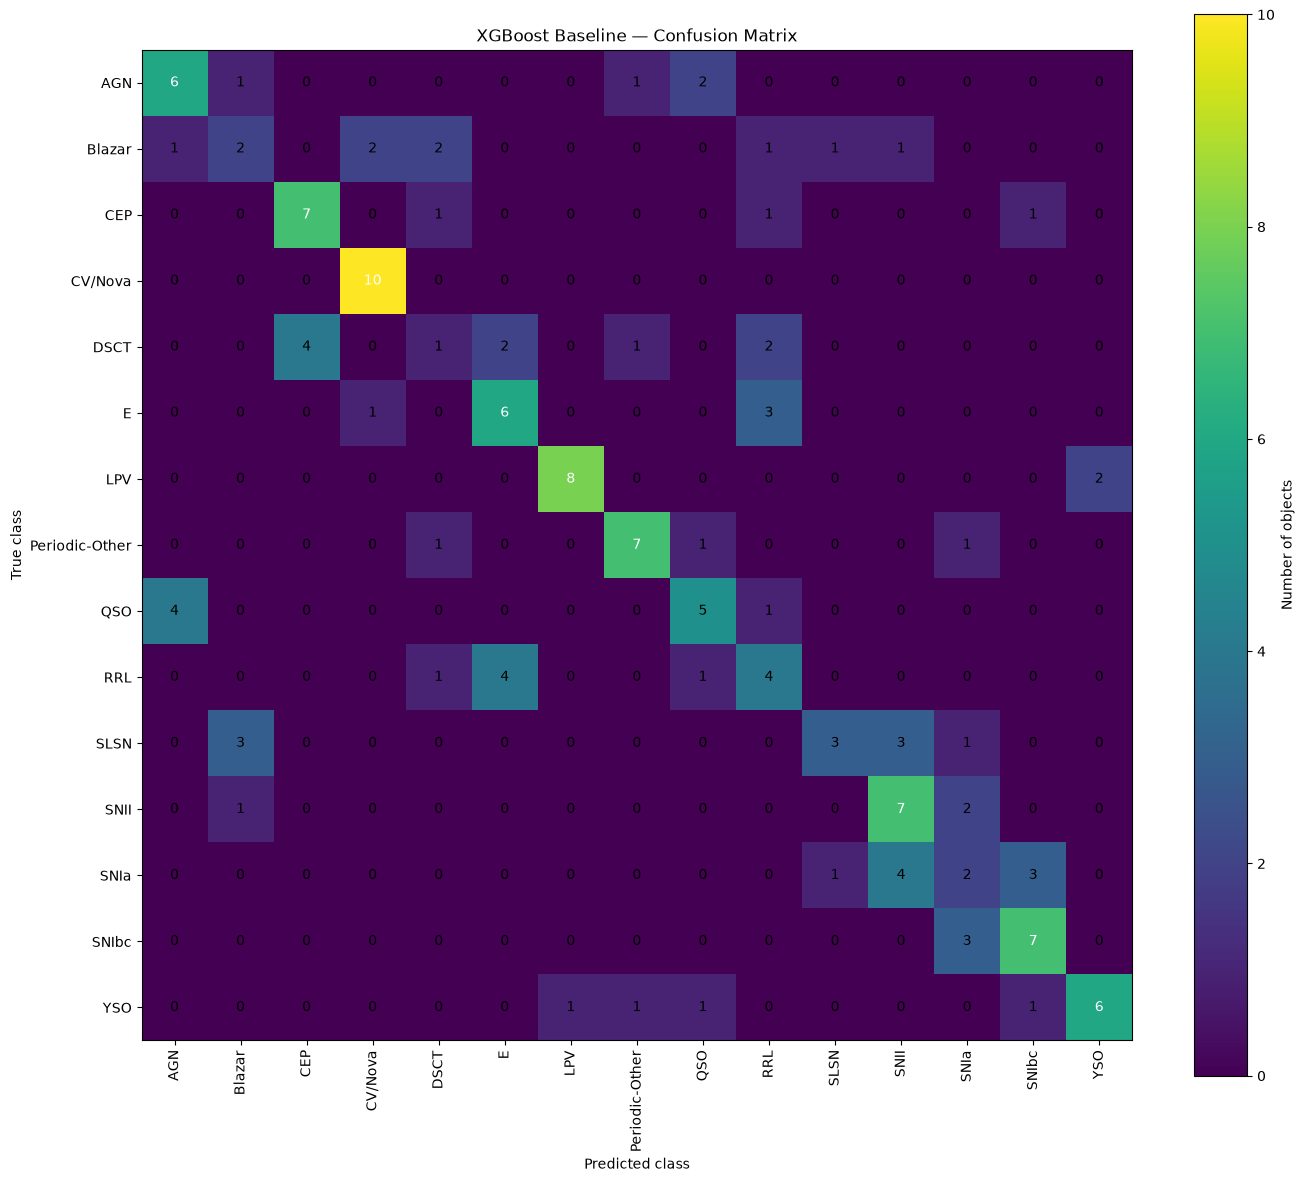

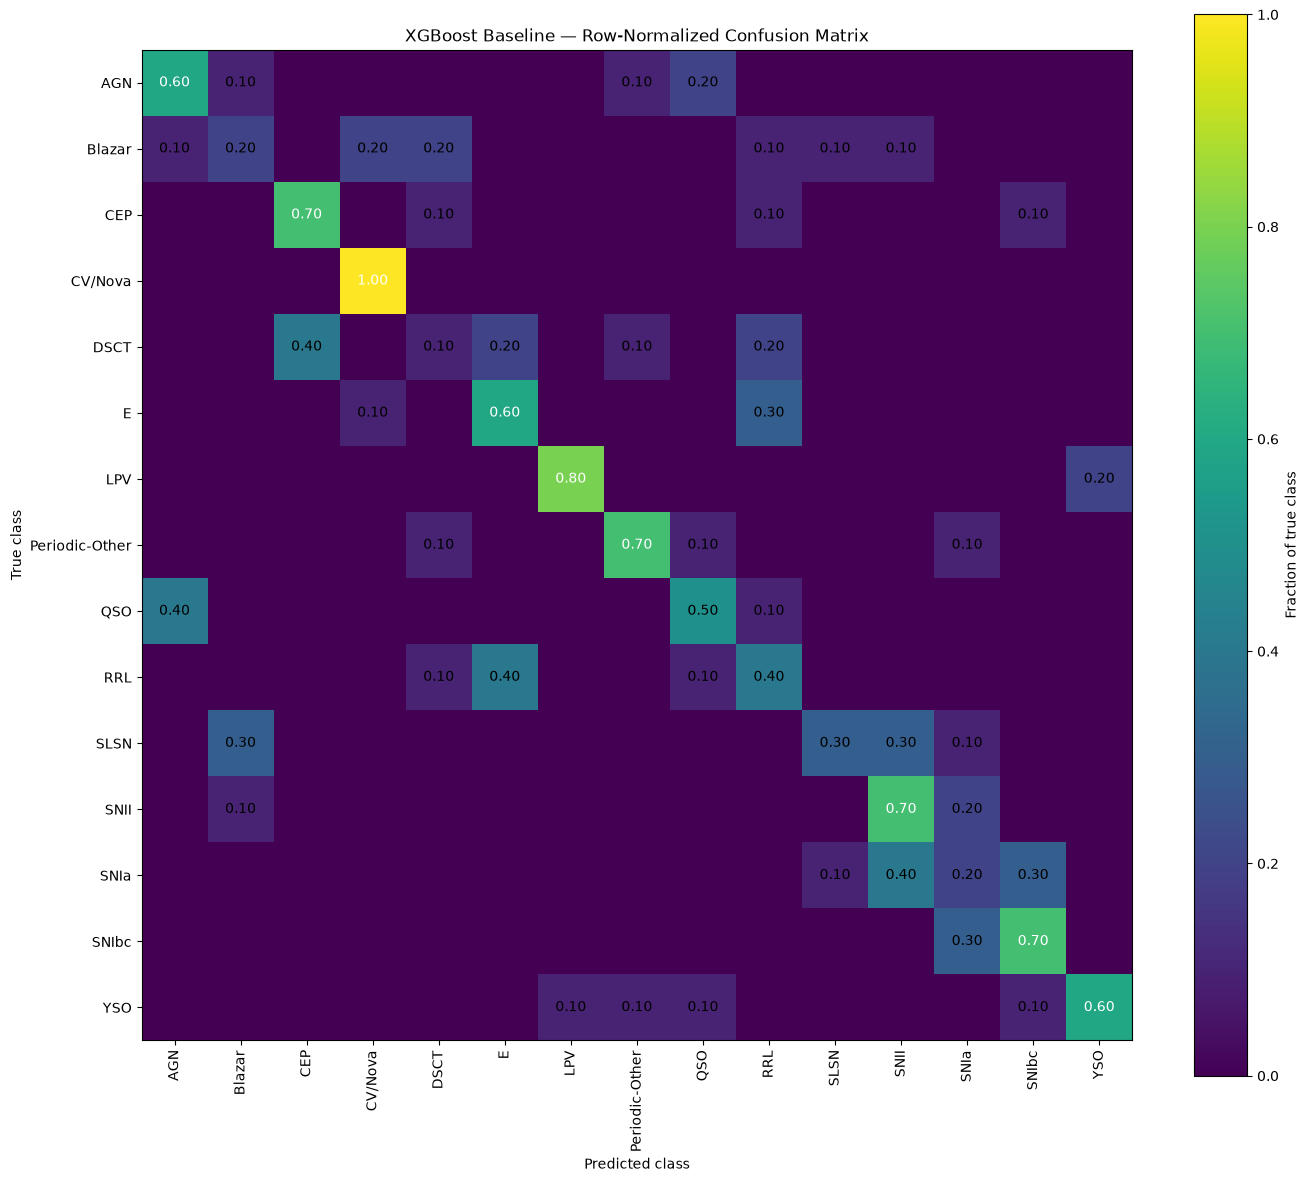


CELL 148 COMPLETE
Confusion matrix: /home/saeed92m/projects/ztf-classifier/reports/tables/xgboost_baseline_confusion_matrix_v0.1.parquet
Normalized confusion matrix: /home/saeed92m/projects/ztf-classifier/reports/tables/xgboost_baseline_confusion_matrix_normalized_v0.1.parquet
Per-class metrics: /home/saeed92m/projects/ztf-classifier/reports/tables/xgboost_baseline_per_class_metrics_v0.1.parquet
Classification report: /home/saeed92m/projects/ztf-classifier/reports/tables/xgboost_baseline_classification_report_v0.1.parquet
Confusion pairs: /home/saeed92m/projects/ztf-classifier/reports/tables/xgboost_baseline_confusion_pairs_v0.1.parquet
Confusion matrix figure: /home/saeed92m/projects/ztf-classifier/reports/figures/xgboost_baseline_confusion_matrix_v0.1.png
Normalized figure: /home/saeed92m/projects/ztf-classifier/reports/figures/xgboost_baseline_confusion_matrix_normalized_v0.1.png

No model retrained.
No feature selection performed.
No imputation performed.


In [115]:
# Cell 148 — Baseline Per-Class Evaluation
#
# Uses only the out-of-fold predictions generated in Cell 147.
# No model retraining.
# No feature selection.
# No tuning.
#
# Outputs:
#   - confusion matrix
#   - per-class precision / recall / F1
#   - support
#   - class error counts
#   - normalized confusion matrix
#   - saved evaluation reports

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support,
)


# ============================================================
# 1. Paths
# ============================================================

project_root = Path.home() / "projects" / "ztf-classifier"

reports_dir = (
    project_root
    / "reports"
    / "tables"
)

figures_dir = (
    project_root
    / "reports"
    / "figures"
)

reports_dir.mkdir(
    parents=True,
    exist_ok=True,
)

figures_dir.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 2. Load OOF predictions
# ============================================================

predictions_path = (
    reports_dir
    / "xgboost_baseline_oof_predictions_v0.1.parquet"
)

class_names_path = (
    reports_dir
    / "xgboost_baseline_class_names_v0.1.parquet"
)

oof = pd.read_parquet(
    predictions_path
)

class_map = pd.read_parquet(
    class_names_path
)

class_names = (
    class_map["class_name"]
    .astype(str)
    .to_numpy()
)

true_labels = (
    oof["true_class"]
    .astype(str)
    .to_numpy()
)

pred_labels = (
    oof["predicted_class"]
    .astype(str)
    .to_numpy()
)

assert len(true_labels) == len(pred_labels)
assert len(true_labels) == len(oof)


# ============================================================
# 3. Confusion matrix
# ============================================================

cm = confusion_matrix(
    true_labels,
    pred_labels,
    labels=class_names,
)

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names,
)

cm_path = (
    reports_dir
    / "xgboost_baseline_confusion_matrix_v0.1.parquet"
)

cm_df.to_parquet(
    cm_path
)


# ============================================================
# 4. Row-normalized confusion matrix
# ============================================================

row_totals = cm.sum(
    axis=1,
    keepdims=True,
)

cm_normalized = np.divide(
    cm,
    row_totals,
    out=np.zeros_like(
        cm,
        dtype=float,
    ),
    where=row_totals != 0,
)

cm_norm_df = pd.DataFrame(
    cm_normalized,
    index=class_names,
    columns=class_names,
)

cm_norm_path = (
    reports_dir
    / "xgboost_baseline_confusion_matrix_normalized_v0.1.parquet"
)

cm_norm_df.to_parquet(
    cm_norm_path
)


# ============================================================
# 5. Per-class metrics
# ============================================================

precision, recall, f1, support = (
    precision_recall_fscore_support(
        true_labels,
        pred_labels,
        labels=class_names,
        zero_division=0,
    )
)

per_class = pd.DataFrame({
    "class": class_names,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "support": support.astype(int),
})

per_class["errors"] = (
    per_class["support"]
    - (
        per_class["recall"]
        * per_class["support"]
    ).round().astype(int)
)

per_class["error_rate"] = (
    1.0
    - per_class["recall"]
)

per_class_path = (
    reports_dir
    / "xgboost_baseline_per_class_metrics_v0.1.parquet"
)

per_class.to_parquet(
    per_class_path,
    index=False,
)


# ============================================================
# 6. Classification report
# ============================================================

report_dict = classification_report(
    true_labels,
    pred_labels,
    labels=class_names,
    target_names=class_names,
    zero_division=0,
    output_dict=True,
)

classification_report_df = (
    pd.DataFrame(report_dict)
    .T
)

classification_report_path = (
    reports_dir
    / "xgboost_baseline_classification_report_v0.1.parquet"
)

classification_report_df.to_parquet(
    classification_report_path
)


# ============================================================
# 7. Most common confusion pairs
# ============================================================

confusion_pairs = []

for i, true_class in enumerate(class_names):

    for j, predicted_class in enumerate(class_names):

        if i == j:
            continue

        count = int(cm[i, j])

        if count > 0:
            confusion_pairs.append({
                "true_class": true_class,
                "predicted_class": predicted_class,
                "count": count,
                "fraction_of_true_class": (
                    count / row_totals[i, 0]
                ),
            })

confusion_pairs_df = (
    pd.DataFrame(confusion_pairs)
)

if len(confusion_pairs_df) > 0:

    confusion_pairs_df = (
        confusion_pairs_df
        .sort_values(
            [
                "count",
                "fraction_of_true_class",
            ],
            ascending=False,
        )
        .reset_index(drop=True)
    )

else:

    confusion_pairs_df = pd.DataFrame(
        columns=[
            "true_class",
            "predicted_class",
            "count",
            "fraction_of_true_class",
        ]
    )

confusion_pairs_path = (
    reports_dir
    / "xgboost_baseline_confusion_pairs_v0.1.parquet"
)

confusion_pairs_df.to_parquet(
    confusion_pairs_path,
    index=False,
)


# ============================================================
# 8. Print per-class results
# ============================================================

print("=" * 70)
print("PER-CLASS BASELINE METRICS")
print("=" * 70)

display(
    per_class.sort_values(
        "f1",
        ascending=False,
    )
)


# ============================================================
# 9. Print most common confusion pairs
# ============================================================

print("\n" + "=" * 70)
print("MOST COMMON CONFUSION PAIRS")
print("=" * 70)

display(
    confusion_pairs_df.head(20)
)


# ============================================================
# 10. Plot confusion matrix
# ============================================================

fig, ax = plt.subplots(
    figsize=(14, 12)
)

image = ax.imshow(
    cm,
    interpolation="nearest",
)

ax.set_title(
    "XGBoost Baseline — Confusion Matrix"
)

ax.set_xlabel(
    "Predicted class"
)

ax.set_ylabel(
    "True class"
)

ax.set_xticks(
    np.arange(len(class_names))
)

ax.set_yticks(
    np.arange(len(class_names))
)

ax.set_xticklabels(
    class_names,
    rotation=90,
)

ax.set_yticklabels(
    class_names,
)

threshold = (
    cm.max() / 2.0
)

for i in range(cm.shape[0]):

    for j in range(cm.shape[1]):

        ax.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            color=(
                "white"
                if cm[i, j] > threshold
                else "black"
            ),
        )

fig.colorbar(
    image,
    ax=ax,
    label="Number of objects",
)

fig.tight_layout()

confusion_figure_path = (
    figures_dir
    / "xgboost_baseline_confusion_matrix_v0.1.png"
)

fig.savefig(
    confusion_figure_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# 11. Plot normalized confusion matrix
# ============================================================

fig, ax = plt.subplots(
    figsize=(14, 12)
)

image = ax.imshow(
    cm_normalized,
    interpolation="nearest",
    vmin=0,
    vmax=1,
)

ax.set_title(
    "XGBoost Baseline — Row-Normalized Confusion Matrix"
)

ax.set_xlabel(
    "Predicted class"
)

ax.set_ylabel(
    "True class"
)

ax.set_xticks(
    np.arange(len(class_names))
)

ax.set_yticks(
    np.arange(len(class_names))
)

ax.set_xticklabels(
    class_names,
    rotation=90,
)

ax.set_yticklabels(
    class_names,
)

for i in range(cm_normalized.shape[0]):

    for j in range(cm_normalized.shape[1]):

        if cm_normalized[i, j] > 0:

            ax.text(
                j,
                i,
                f"{cm_normalized[i, j]:.2f}",
                ha="center",
                va="center",
                color=(
                    "white"
                    if cm_normalized[i, j] > 0.5
                    else "black"
                ),
            )

fig.colorbar(
    image,
    ax=ax,
    label="Fraction of true class",
)

fig.tight_layout()

normalized_confusion_figure_path = (
    figures_dir
    / "xgboost_baseline_confusion_matrix_normalized_v0.1.png"
)

fig.savefig(
    normalized_confusion_figure_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# 12. Final audit
# ============================================================

assert cm.sum() == len(oof)

assert (
    per_class["support"].sum()
    == len(oof)
)

assert np.all(
    per_class["support"].to_numpy() == 10
)

print("\n" + "=" * 70)
print("CELL 148 COMPLETE")
print("=" * 70)

print(
    "Confusion matrix:",
    cm_path
)

print(
    "Normalized confusion matrix:",
    cm_norm_path
)

print(
    "Per-class metrics:",
    per_class_path
)

print(
    "Classification report:",
    classification_report_path
)

print(
    "Confusion pairs:",
    confusion_pairs_path
)

print(
    "Confusion matrix figure:",
    confusion_figure_path
)

print(
    "Normalized figure:",
    normalized_confusion_figure_path
)

print("\nNo model retrained.")
print("No feature selection performed.")
print("No imputation performed.")

In [116]:
print("PER-CLASS METRICS")
display(
    per_class[
        ["class", "precision", "recall", "f1", "support", "error_rate"]
    ].sort_values("f1", ascending=False)
)

print("\nMOST COMMON CONFUSION PAIRS")
display(
    confusion_pairs_df.head(20)
)

PER-CLASS METRICS


,class,precision,recall,f1,support,error_rate
3,CV/Nova,0.769231,1.0,0.869565,10,0.0
6,LPV,0.888889,0.8,0.842105,10,0.2
7,Periodic-Other,0.700000,0.7,0.700000,10,0.3
14,YSO,0.750000,0.6,0.666667,10,0.4
2,CEP,0.636364,0.7,0.666667,10,0.3
13,SNIbc,0.583333,0.7,0.636364,10,0.3
0,AGN,0.545455,0.6,0.571429,10,0.4
11,SNII,0.466667,0.7,0.560000,10,0.3
5,E,0.500000,0.6,0.545455,10,0.4
8,QSO,0.500000,0.5,0.500000,10,0.5



MOST COMMON CONFUSION PAIRS


,true_class,predicted_class,count,fraction_of_true_class
0,DSCT,CEP,4,0.4
1,QSO,AGN,4,0.4
2,RRL,E,4,0.4
3,SNIa,SNII,4,0.4
4,E,RRL,3,0.3
5,SLSN,Blazar,3,0.3
6,SLSN,SNII,3,0.3
7,SNIa,SNIbc,3,0.3
8,SNIbc,SNIa,3,0.3
9,AGN,QSO,2,0.2


In [117]:
# Cell 149 — Cross-Validated XGBoost Feature Importance
#
# Purpose:
#   - Train the same baseline model on each CV fold.
#   - Extract feature importance from every fold.
#   - Aggregate importance across folds.
#   - Measure stability using mean/std.
#
# No:
#   - feature selection
#   - hyperparameter tuning
#   - imputation
#   - change to baseline model
#
# Importance types:
#   gain   = average contribution of a feature to split improvement
#   weight = number of times a feature is used in splits
#   cover  = average number of samples affected by those splits

from pathlib import Path

import numpy as np
import pandas as pd

from xgboost import XGBClassifier


# ============================================================
# 1. Paths
# ============================================================

project_root = Path.home() / "projects" / "ztf-classifier"

X_path = (
    project_root
    / "data"
    / "processed"
    / "X_baseline_v0.1.parquet"
)

y_path = (
    project_root
    / "data"
    / "processed"
    / "y_baseline_v0.1.parquet"
)

reports_dir = (
    project_root
    / "reports"
    / "tables"
)

reports_dir.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 2. Load X and y
# ============================================================

X_all = pd.read_parquet(
    X_path
)

y_df = pd.read_parquet(
    y_path
)

y_raw = y_df["class"].astype(str)


# ============================================================
# 3. Feature roles
# ============================================================

OBSERVATION_PROCESS_FEATURES = {
    "n_valid_total",
    "n_g",
    "n_r",
    "has_g",
    "has_r",
    "has_both_bands",
}

METADATA_FEATURES = {
    "oid",
    "class",
    "label",
    "target",
    "class_name",
    "probability",
    "label_probability",
    "classifier",
    "classifier_version",
    "label_source",
    "label_type",
    "survey",
    "feature_version",
}

FORBIDDEN_FEATURES = (
    OBSERVATION_PROCESS_FEATURES
    | METADATA_FEATURES
)

candidate_numeric = X_all.select_dtypes(
    include=[np.number]
).columns.tolist()

core_feature_names = [
    c
    for c in candidate_numeric
    if c not in FORBIDDEN_FEATURES
]

X = (
    X_all[core_feature_names]
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
)


# ============================================================
# 4. Encode target
# ============================================================

class_names = np.sort(
    y_raw.unique()
)

class_to_index = {
    name: idx
    for idx, name in enumerate(class_names)
}

y = y_raw.map(
    class_to_index
).to_numpy(
    dtype=int
)

n_classes = len(class_names)


# ============================================================
# 5. Load exact CV assignments
# ============================================================

fold_assignment_path = (
    reports_dir
    / "stratified_cv_fold_assignments_v0.1.parquet"
)

fold_assignments = pd.read_parquet(
    fold_assignment_path
)

fold_ids = (
    fold_assignments["fold"]
    .to_numpy(dtype=int)
)

assert len(fold_ids) == len(X)

assert set(fold_ids) == {1, 2, 3, 4, 5}


# ============================================================
# 6. Same baseline XGBoost configuration
# ============================================================

XGB_PARAMS = {
    "n_estimators": 300,
    "max_depth": 4,
    "learning_rate": 0.05,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "min_child_weight": 2,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "objective": "multi:softprob",
    "num_class": n_classes,
    "eval_metric": "mlogloss",
    "tree_method": "hist",
    "random_state": 42,
    "n_jobs": 4,
}


# ============================================================
# 7. Train each fold and collect importance
# ============================================================

importance_records = []

for fold in sorted(
    np.unique(fold_ids)
):

    train_idx = np.where(
        fold_ids != fold
    )[0]

    valid_idx = np.where(
        fold_ids == fold
    )[0]

    X_train = X.iloc[train_idx]
    y_train = y[train_idx]

    model = XGBClassifier(
        **XGB_PARAMS
    )

    model.fit(
        X_train,
        y_train,
    )

    booster = model.get_booster()

    for importance_type in [
        "gain",
        "weight",
        "cover",
    ]:

        importance_dict = (
            booster.get_score(
                importance_type=importance_type
            )
        )

        for feature_name in core_feature_names:

            importance_records.append({
                "fold": fold,
                "importance_type": importance_type,
                "feature": feature_name,
                "importance": float(
                    importance_dict.get(
                        feature_name,
                        0.0
                    )
                ),
            })


importance_df = pd.DataFrame(
    importance_records
)


# ============================================================
# 8. Aggregate importance across folds
# ============================================================

importance_summary = (
    importance_df
    .groupby(
        ["importance_type", "feature"],
        as_index=False,
    )
    .agg(
        mean_importance=(
            "importance",
            "mean",
        ),
        std_importance=(
            "importance",
            "std",
        ),
        min_importance=(
            "importance",
            "min",
        ),
        max_importance=(
            "importance",
            "max",
        ),
        folds_nonzero=(
            "importance",
            lambda x: int(
                (x > 0).sum()
            ),
        ),
    )
)


# ============================================================
# 9. Normalize importance within each fold/type
#
# Raw gain/weight/cover scales can differ between folds.
# Normalized values are therefore useful for cross-fold
# comparison.
# ============================================================

importance_df["fold_total"] = (
    importance_df
    .groupby(
        ["fold", "importance_type"]
    )["importance"]
    .transform("sum")
)

importance_df["normalized_importance"] = np.where(
    importance_df["fold_total"] > 0,
    importance_df["importance"]
    / importance_df["fold_total"],
    0.0,
)

normalized_summary = (
    importance_df
    .groupby(
        ["importance_type", "feature"],
        as_index=False,
    )
    .agg(
        mean_normalized_importance=(
            "normalized_importance",
            "mean",
        ),
        std_normalized_importance=(
            "normalized_importance",
            "std",
        ),
        folds_nonzero=(
            "normalized_importance",
            lambda x: int(
                (x > 0).sum()
            ),
        ),
    )
)


# ============================================================
# 10. Add feature metadata
# ============================================================

def classify_feature(feature):

    if feature.startswith("g_"):
        return "g_band"

    if feature.startswith("r_"):
        return "r_band"

    if (
        feature.startswith("mean_color")
        or feature.startswith("g_variability")
        or feature.startswith("r_variability")
    ):
        return "cross_band"

    return "other"


importance_summary["feature_group"] = (
    importance_summary["feature"]
    .map(classify_feature)
)

normalized_summary["feature_group"] = (
    normalized_summary["feature"]
    .map(classify_feature)
)


# ============================================================
# 11. Save complete reports
# ============================================================

raw_importance_path = (
    reports_dir
    / "xgboost_cv_feature_importance_raw_v0.1.parquet"
)

summary_path = (
    reports_dir
    / "xgboost_cv_feature_importance_summary_v0.1.parquet"
)

normalized_path = (
    reports_dir
    / "xgboost_cv_feature_importance_normalized_v0.1.parquet"
)

importance_df.to_parquet(
    raw_importance_path,
    index=False,
)

importance_summary.to_parquet(
    summary_path,
    index=False,
)

normalized_summary.to_parquet(
    normalized_path,
    index=False,
)


# ============================================================
# 12. Print top features by normalized gain
# ============================================================

top_gain = (
    normalized_summary[
        normalized_summary["importance_type"]
        == "gain"
    ]
    .sort_values(
        "mean_normalized_importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("TOP FEATURES — NORMALIZED GAIN")
print("=" * 70)

display(
    top_gain.head(25)
)


# ============================================================
# 13. Print top features by normalized weight
# ============================================================

top_weight = (
    normalized_summary[
        normalized_summary["importance_type"]
        == "weight"
    ]
    .sort_values(
        "mean_normalized_importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("TOP FEATURES — NORMALIZED WEIGHT")
print("=" * 70)

display(
    top_weight.head(25)
)


# ============================================================
# 14. Print top features by normalized cover
# ============================================================

top_cover = (
    normalized_summary[
        normalized_summary["importance_type"]
        == "cover"
    ]
    .sort_values(
        "mean_normalized_importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("TOP FEATURES — NORMALIZED COVER")
print("=" * 70)

display(
    top_cover.head(25)
)


# ============================================================
# 15. Feature stability
# ============================================================

stability = (
    normalized_summary[
        normalized_summary["importance_type"]
        == "gain"
    ]
    .copy()
)

stability["stability_fraction"] = (
    stability["folds_nonzero"]
    / len(np.unique(fold_ids))
)

stability = (
    stability
    .sort_values(
        [
            "stability_fraction",
            "mean_normalized_importance",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("GAIN STABILITY")
print("=" * 70)

display(
    stability.head(25)
)


# ============================================================
# 16. Final audit
# ============================================================

assert (
    importance_df["fold"]
    .nunique()
    == 5
)

assert (
    importance_df["importance_type"]
    .nunique()
    == 3
)

assert (
    importance_df["feature"]
    .nunique()
    == len(core_feature_names)
)

print("\n" + "=" * 70)
print("CELL 149 COMPLETE")
print("=" * 70)

print(
    "Raw importance:",
    raw_importance_path
)

print(
    "Importance summary:",
    summary_path
)

print(
    "Normalized importance:",
    normalized_path
)

print("\nNo feature was deleted.")
print("No feature selection was performed.")
print("No imputation was performed.")

TOP FEATURES — NORMALIZED GAIN


,importance_type,feature,mean_normalized_importance,std_normalized_importance,folds_nonzero,feature_group
0,gain,r_ls_fap,0.039222,0.010713,5,r_band
1,gain,r_phase_robust_amplitude,0.024321,0.014745,5,r_band
2,gain,g_median_magerr,0.023956,0.005825,5,g_band
3,gain,g_mean_mag,0.023844,0.008778,5,g_band
4,gain,g_p95_mag,0.023359,0.011709,5,g_band
5,gain,r_p75_mag,0.022617,0.017995,5,r_band
6,gain,g_baseline_days,0.022468,0.002967,5,g_band
7,gain,g_min_mag,0.021328,0.002607,5,g_band
8,gain,g_phase_robust_amplitude,0.020962,0.004583,5,g_band
9,gain,r_phase_amplitude,0.020868,0.006868,5,r_band



TOP FEATURES — NORMALIZED WEIGHT


,importance_type,feature,mean_normalized_importance,std_normalized_importance,folds_nonzero,feature_group
0,weight,r_baseline_days,0.067585,0.011855,5,r_band
1,weight,median_color_gr,0.065586,0.013913,5,other
2,weight,mean_color_gr,0.060476,0.005058,5,cross_band
3,weight,r_variability_ratio,0.054151,0.012094,5,r_band
4,weight,g_baseline_days,0.050942,0.009798,5,g_band
5,weight,g_variability_ratio,0.030504,0.004825,5,g_band
6,weight,r_median_abs_norm_resid,0.029411,0.004755,5,r_band
7,weight,g_ls_max_period_days,0.029065,0.006354,5,g_band
8,weight,r_reduced_chi2_like,0.024702,0.007227,5,r_band
9,weight,r_amplitude_mag,0.024208,0.006397,5,r_band



TOP FEATURES — NORMALIZED COVER


,importance_type,feature,mean_normalized_importance,std_normalized_importance,folds_nonzero,feature_group
0,cover,r_ls_fap,0.019085,0.003702,5,r_band
1,cover,g_baseline_days,0.018524,0.001300,5,g_band
2,cover,g_median_magerr,0.017790,0.000922,5,g_band
3,cover,g_min_mag,0.017325,0.000843,5,g_band
4,cover,g_phase_robust_amplitude,0.017121,0.001797,5,g_band
5,cover,g_p95_mag,0.016742,0.002450,5,g_band
6,cover,g_mean_magerr,0.016089,0.001626,5,g_band
7,cover,g_ls_best_power,0.016021,0.001113,5,g_band
8,cover,r_amplitude_mag,0.015915,0.001603,5,r_band
9,cover,r_p75_mag,0.015832,0.004471,5,r_band



GAIN STABILITY


,importance_type,feature,mean_normalized_importance,std_normalized_importance,folds_nonzero,feature_group,stability_fraction
0,gain,r_ls_fap,0.039222,0.010713,5,r_band,1.0
1,gain,r_phase_robust_amplitude,0.024321,0.014745,5,r_band,1.0
2,gain,g_median_magerr,0.023956,0.005825,5,g_band,1.0
3,gain,g_mean_mag,0.023844,0.008778,5,g_band,1.0
4,gain,g_p95_mag,0.023359,0.011709,5,g_band,1.0
5,gain,r_p75_mag,0.022617,0.017995,5,r_band,1.0
6,gain,g_baseline_days,0.022468,0.002967,5,g_band,1.0
7,gain,g_min_mag,0.021328,0.002607,5,g_band,1.0
8,gain,g_phase_robust_amplitude,0.020962,0.004583,5,g_band,1.0
9,gain,r_phase_amplitude,0.020868,0.006868,5,r_band,1.0



CELL 149 COMPLETE
Raw importance: /home/saeed92m/projects/ztf-classifier/reports/tables/xgboost_cv_feature_importance_raw_v0.1.parquet
Importance summary: /home/saeed92m/projects/ztf-classifier/reports/tables/xgboost_cv_feature_importance_summary_v0.1.parquet
Normalized importance: /home/saeed92m/projects/ztf-classifier/reports/tables/xgboost_cv_feature_importance_normalized_v0.1.parquet

No feature was deleted.
No feature selection was performed.
No imputation was performed.


In [121]:
# ============================================================
# Cell 150 — Scientific Feature Group Audit
# ============================================================
#
# Purpose:
#   1. Assign every core feature to a scientific feature group.
#   2. Audit feature missingness by scientific group.
#   3. Combine Cell 149 CV importance with scientific groups.
#   4. Produce feature-level and group-level audit tables.
#
# IMPORTANT:
#   - No model training
#   - No feature deletion
#   - No feature selection
#   - No imputation
#   - Existing CV folds and importance values are not changed
#
# Scientific groups:
#   1. photometric_level
#   2. variability
#   3. periodicity
#   4. phase_morphology
#   5. cross_band
#   6. observation_quality
#   7. other
#
# ============================================================


from pathlib import Path

import numpy as np
import pandas as pd


# ============================================================
# 1. Project paths
# ============================================================

project_root = Path.home() / "projects" / "ztf-classifier"

data_processed_dir = (
    project_root
    / "data"
    / "processed"
)

reports_dir = (
    project_root
    / "reports"
    / "tables"
)

reports_dir.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 2. Input files
# ============================================================

X_path = (
    data_processed_dir
    / "X_baseline_v0.1.parquet"
)

importance_path = (
    reports_dir
    / "xgboost_cv_feature_importance_normalized_v0.1.parquet"
)


# ============================================================
# 3. Load baseline feature matrix
# ============================================================

if not X_path.exists():
    raise FileNotFoundError(
        f"Baseline feature matrix not found:\n{X_path}"
    )

X_all = pd.read_parquet(
    X_path
)

print("=" * 70)
print("CELL 150 — SCIENTIFIC FEATURE GROUP AUDIT")
print("=" * 70)

print(
    f"\nLoaded X matrix: {X_all.shape}"
)


# ============================================================
# 4. Define excluded feature roles
# ============================================================

# Observation-process columns explicitly excluded
# from the Cell 147 baseline model.

OBSERVATION_PROCESS_FEATURES = {
    "n_valid_total",
    "n_g",
    "n_r",
}


# Metadata / target columns.
# These should never enter the scientific feature groups.

METADATA_FEATURES = {
    "oid",
    "class",
    "label",
    "target",
    "class_name",
    "probability",
    "label_probability",
    "classifier",
    "classifier_version",
    "label_source",
    "label_type",
    "survey",
    "feature_version",
}


FORBIDDEN_FEATURES = (
    OBSERVATION_PROCESS_FEATURES
    | METADATA_FEATURES
)


# ============================================================
# 5. Identify core numeric model features
# ============================================================

candidate_numeric = (
    X_all
    .select_dtypes(
        include=[np.number]
    )
    .columns
    .tolist()
)


core_features = [
    feature
    for feature in candidate_numeric
    if feature not in FORBIDDEN_FEATURES
]


print(
    f"Numeric candidate columns: {len(candidate_numeric)}"
)

print(
    f"Core scientific model features: {len(core_features)}"
)

print(
    f"Excluded columns: "
    f"{len(candidate_numeric) - len(core_features)}"
)


# ============================================================
# 6. Scientific feature-group classifier
# ============================================================

def assign_feature_group(feature):
    """
    Assign one scientific interpretation group to a feature.

    Priority order matters because some feature names can
    contain multiple conceptual keywords.
    """

    # --------------------------------------------------------
    # 6.1 Periodicity
    # --------------------------------------------------------
    #
    # Examples:
    #   g_ls_best_period_days
    #   g_ls_best_frequency
    #   g_ls_best_power
    #   g_ls_fap
    #   r_ls_min_period_days
    #

    if "_ls_" in feature:
        return "periodicity"


    # --------------------------------------------------------
    # 6.2 Phase morphology
    # --------------------------------------------------------
    #
    # Examples:
    #   g_phase_amplitude
    #   g_phase_robust_amplitude
    #   g_phase_iqr
    #   g_phase_skewness
    #   g_phase_bright_fraction
    #

    if "_phase_" in feature:
        return "phase_morphology"


    # --------------------------------------------------------
    # 6.3 Cross-band information
    # --------------------------------------------------------
    #
    # These features explicitly combine g/r information.
    #

    if (
        feature.startswith("mean_color_")
        or feature.startswith("median_color_")
        or feature.startswith("g_variability_ratio")
        or feature.startswith("r_variability_ratio")
    ):
        return "cross_band"


    # --------------------------------------------------------
    # 6.4 Observation quality / sampling
    # --------------------------------------------------------
    #
    # IMPORTANT:
    # n_obs belongs here because it describes sampling density,
    # not intrinsic astrophysical variability.
    #

    if (
        feature.endswith("_n_obs")
        or feature.endswith("_baseline_days")
        or feature.endswith("_mean_magerr")
        or feature.endswith("_median_magerr")
    ):
        return "observation_quality"


    # --------------------------------------------------------
    # 6.5 Photometric level
    # --------------------------------------------------------
    #
    # Absolute / distributional magnitude descriptors.
    #

    if any(
        token in feature
        for token in [
            "_mean_mag",
            "_median_mag",
            "_weighted_mean_mag",
            "_min_mag",
            "_max_mag",
            "_p05_mag",
            "_p25_mag",
            "_p75_mag",
            "_p95_mag",
        ]
    ):
        return "photometric_level"


    # --------------------------------------------------------
    # 6.6 Variability / dispersion
    # --------------------------------------------------------
    #
    # Measures of scatter, amplitude, residual structure,
    # or deviation from a constant-flux/magnitude description.
    #

    if any(
        token in feature
        for token in [
            "_std_mag",
            "_mad_mag",
            "_amplitude_mag",
            "_iqr_mag",
            "_rms_mag",
            "_reduced_chi2_like",
            "_median_abs_norm_resid",
        ]
    ):
        return "variability"


    # --------------------------------------------------------
    # 6.7 Fallback
    # --------------------------------------------------------

    return "other"


# ============================================================
# 7. Build feature-role table
# ============================================================

feature_roles = []

for feature in core_features:

    series = X_all[feature]

    feature_roles.append(
        {
            "feature": feature,

            "feature_group": (
                assign_feature_group(feature)
            ),

            "dtype": str(series.dtype),

            "n_samples": int(len(series)),

            "n_missing": int(
                series.isna().sum()
            ),

            "missing_fraction": float(
                series.isna().mean()
            ),

            "n_valid": int(
                series.notna().sum()
            ),

            "n_unique": int(
                series.nunique(
                    dropna=True
                )
            ),
        }
    )


feature_role_df = pd.DataFrame(
    feature_roles
)


# ============================================================
# 8. Validate feature grouping
# ============================================================

print("\n" + "=" * 70)
print("FEATURE GROUP VALIDATION")
print("=" * 70)


# Every core feature must appear exactly once.

assert (
    feature_role_df["feature"].nunique()
    == len(core_features)
), (
    "Duplicate feature assignments detected."
)


# Every core feature must have a group.

if feature_role_df[
    "feature_group"
].isna().any():

    unassigned = (
        feature_role_df.loc[
            feature_role_df[
                "feature_group"
            ].isna(),
            "feature",
        ]
        .tolist()
    )

    raise ValueError(
        "Unassigned features:\n"
        + "\n".join(
            map(str, unassigned)
        )
    )


# Every feature must belong to a recognized group.

VALID_GROUPS = {
    "photometric_level",
    "variability",
    "periodicity",
    "phase_morphology",
    "cross_band",
    "observation_quality",
    "other",
}


unexpected_groups = set(
    feature_role_df[
        "feature_group"
    ].unique()
) - VALID_GROUPS


assert not unexpected_groups, (
    "Unexpected feature groups: "
    + str(unexpected_groups)
)


print(
    f"Total core features: {len(core_features)}"
)

print(
    "All core features assigned exactly once."
)


# ============================================================
# 9. Feature inventory by group
# ============================================================

print("\n" + "=" * 70)
print("FEATURE INVENTORY BY GROUP")
print("=" * 70)


for group_name in sorted(
    feature_role_df[
        "feature_group"
    ].unique()
):

    group_features = (
        feature_role_df.loc[
            feature_role_df[
                "feature_group"
            ] == group_name,
            "feature",
        ]
        .tolist()
    )

    print(
        f"\n[{group_name}] "
        f"({len(group_features)} features)"
    )

    for feature in group_features:
        print(
            f"  - {feature}"
        )


# ============================================================
# 10. Group feature counts
# ============================================================

group_counts = (
    feature_role_df
    .groupby(
        "feature_group",
        as_index=False,
    )
    .agg(
        n_features=(
            "feature",
            "count",
        )
    )
    .sort_values(
        "n_features",
        ascending=False,
    )
    .reset_index(drop=True)
)


# ============================================================
# 11. Load Cell 149 CV importance
# ============================================================

if not importance_path.exists():
    raise FileNotFoundError(
        f"CV importance file not found:\n"
        f"{importance_path}"
    )


importance_df = pd.read_parquet(
    importance_path
)


print("\n" + "=" * 70)
print("CELL 149 IMPORTANCE TABLE")
print("=" * 70)

print(
    f"Importance table shape: "
    f"{importance_df.shape}"
)

print(
    "\nImportance columns:"
)

print(
    importance_df.columns.tolist()
)


# ============================================================
# 12. Validate required importance columns
# ============================================================

REQUIRED_IMPORTANCE_COLUMNS = [
    "feature",
    "importance_type",
    "mean_normalized_importance",
    "std_normalized_importance",
    "folds_nonzero",
]


missing_importance_columns = [
    column
    for column in REQUIRED_IMPORTANCE_COLUMNS
    if column not in importance_df.columns
]


if missing_importance_columns:

    raise KeyError(
        "The Cell 149 importance table is missing "
        "required columns:\n"
        + "\n".join(
            missing_importance_columns
        )
    )


# ============================================================
# 13. Keep only required importance columns
# ============================================================
#
# This intentionally prevents an existing feature_group
# column in Cell 149 from creating feature_group_x /
# feature_group_y during merge.
#

importance_clean = (
    importance_df[
        REQUIRED_IMPORTANCE_COLUMNS
    ]
    .copy()
)


# ============================================================
# 14. Prepare feature-role table for merge
# ============================================================

feature_role_merge = (
    feature_role_df[
        [
            "feature",
            "feature_group",
            "n_missing",
            "missing_fraction",
            "n_valid",
            "n_unique",
        ]
    ]
    .copy()
)


# ============================================================
# 15. Validate uniqueness before merge
# ============================================================

assert (
    feature_role_merge["feature"]
    .nunique()
    == len(feature_role_merge)
), (
    "feature_role_merge contains duplicate features."
)


# ============================================================
# 16. Merge feature groups with CV importance
# ============================================================

merged = importance_clean.merge(
    feature_role_merge,
    on="feature",
    how="left",
    validate="many_to_one",
)


# ============================================================
# 17. Validate merged result
# ============================================================

if "feature_group" not in merged.columns:

    raise RuntimeError(
        "feature_group was not created after merge."
    )


missing_groups = (
    merged.loc[
        merged[
            "feature_group"
        ].isna(),
        "feature",
    ]
    .unique()
)


if len(missing_groups) > 0:

    raise ValueError(
        "The following features have no scientific "
        "feature-group assignment:\n"
        + "\n".join(
            map(str, missing_groups)
        )
    )


# Every core feature must be represented.

merged_core_features = set(
    merged["feature"].unique()
)

expected_core_features = set(
    core_features
)


missing_from_importance = (
    expected_core_features
    - merged_core_features
)

unexpected_in_importance = (
    merged_core_features
    - expected_core_features
)


if missing_from_importance:

    raise ValueError(
        "Core features missing from Cell 149 "
        "importance table:\n"
        + "\n".join(
            sorted(
                map(
                    str,
                    missing_from_importance,
                )
            )
        )
    )


if unexpected_in_importance:

    raise ValueError(
        "Unexpected features found in Cell 149 "
        "importance table:\n"
        + "\n".join(
            sorted(
                map(
                    str,
                    unexpected_in_importance,
                )
            )
        )
    )


print("\n" + "=" * 70)
print("MERGE VALIDATION")
print("=" * 70)

print(
    f"Importance rows: {len(importance_clean)}"
)

print(
    f"Merged rows: {len(merged)}"
)

print(
    f"Unique core features: "
    f"{merged['feature'].nunique()}"
)

print(
    "All Cell 149 core features successfully "
    "mapped to scientific groups."
)


# ============================================================
# 18. Save feature-level scientific audit
# ============================================================

feature_level_path = (
    reports_dir
    / "scientific_feature_role_importance_v0.1.parquet"
)


merged.to_parquet(
    feature_level_path,
    index=False,
)


# ============================================================
# 19. Group-level importance summary
# ============================================================

group_summary = (
    merged
    .groupby(
        [
            "importance_type",
            "feature_group",
        ],
        as_index=False,
    )
    .agg(
        n_features=(
            "feature",
            "nunique",
        ),

        mean_importance=(
            "mean_normalized_importance",
            "mean",
        ),

        total_importance=(
            "mean_normalized_importance",
            "sum",
        ),

        mean_importance_std=(
            "std_normalized_importance",
            "mean",
        ),

        mean_stability=(
            "folds_nonzero",
            "mean",
        ),

        min_stability=(
            "folds_nonzero",
            "min",
        ),

        max_stability=(
            "folds_nonzero",
            "max",
        ),
    )
)


# Convert folds_nonzero into a 0–1 stability fraction.

group_summary[
    "mean_stability_fraction"
] = (
    group_summary[
        "mean_stability"
    ] / 5.0
)


group_summary[
    "min_stability_fraction"
] = (
    group_summary[
        "min_stability"
    ] / 5.0
)


group_summary[
    "max_stability_fraction"
] = (
    group_summary[
        "max_stability"
    ] / 5.0
)


# ============================================================
# 20. Save group importance report
# ============================================================

group_summary_path = (
    reports_dir
    / "scientific_feature_group_importance_v0.1.parquet"
)


group_summary.to_parquet(
    group_summary_path,
    index=False,
)


# ============================================================
# 21. Missingness by feature group
# ============================================================

missingness_summary = (
    feature_role_df
    .groupby(
        "feature_group",
        as_index=False,
    )
    .agg(
        n_features=(
            "feature",
            "count",
        ),

        total_missing_values=(
            "n_missing",
            "sum",
        ),

        mean_missing_fraction=(
            "missing_fraction",
            "mean",
        ),

        median_missing_fraction=(
            "missing_fraction",
            "median",
        ),

        max_missing_fraction=(
            "missing_fraction",
            "max",
        ),

        min_missing_fraction=(
            "missing_fraction",
            "min",
        ),
    )
)


# ============================================================
# 22. Save missingness report
# ============================================================

missingness_path = (
    reports_dir
    / "scientific_feature_group_missingness_v0.1.parquet"
)


missingness_summary.to_parquet(
    missingness_path,
    index=False,
)


# ============================================================
# 23. Print group counts
# ============================================================

print("\n" + "=" * 70)
print("SCIENTIFIC FEATURE GROUP COUNTS")
print("=" * 70)

display(
    group_counts
)


# ============================================================
# 24. Print normalized gain
# ============================================================

print("\n" + "=" * 70)
print("GROUP IMPORTANCE — NORMALIZED GAIN")
print("=" * 70)

gain_groups = (
    group_summary[
        group_summary[
            "importance_type"
        ] == "gain"
    ]
    .sort_values(
        "total_importance",
        ascending=False,
    )
    .reset_index(drop=True)
)


display(
    gain_groups
)


# ============================================================
# 25. Print normalized weight
# ============================================================

print("\n" + "=" * 70)
print("GROUP IMPORTANCE — NORMALIZED WEIGHT")
print("=" * 70)

weight_groups = (
    group_summary[
        group_summary[
            "importance_type"
        ] == "weight"
    ]
    .sort_values(
        "total_importance",
        ascending=False,
    )
    .reset_index(drop=True)
)


display(
    weight_groups
)


# ============================================================
# 26. Print normalized cover
# ============================================================

print("\n" + "=" * 70)
print("GROUP IMPORTANCE — NORMALIZED COVER")
print("=" * 70)

cover_groups = (
    group_summary[
        group_summary[
            "importance_type"
        ] == "cover"
    ]
    .sort_values(
        "total_importance",
        ascending=False,
    )
    .reset_index(drop=True)
)


display(
    cover_groups
)


# ============================================================
# 27. Print missingness audit
# ============================================================

print("\n" + "=" * 70)
print("MISSINGNESS BY FEATURE GROUP")
print("=" * 70)

display(
    missingness_summary.sort_values(
        "mean_missing_fraction",
        ascending=False,
    ).reset_index(drop=True)
)


# ============================================================
# 28. Feature-level importance audit
# ============================================================

print("\n" + "=" * 70)
print("TOP FEATURES BY NORMALIZED GAIN")
print("=" * 70)

top_gain_features = (
    merged[
        merged[
            "importance_type"
        ] == "gain"
    ]
    .sort_values(
        "mean_normalized_importance",
        ascending=False,
    )
    [
        [
            "feature",
            "feature_group",
            "mean_normalized_importance",
            "std_normalized_importance",
            "folds_nonzero",
            "missing_fraction",
        ]
    ]
    .head(25)
    .reset_index(drop=True)
)


display(
    top_gain_features
)


# ============================================================
# 29. Final structural validation
# ============================================================

assert (
    set(core_features)
    == set(
        feature_role_df[
            "feature"
        ]
    )
)


assert (
    feature_role_df[
        "feature"
    ].nunique()
    == len(core_features)
)


assert (
    merged[
        "feature"
    ].nunique()
    == len(core_features)
)


assert (
    merged[
        "feature_group"
    ].notna().all()
)


assert (
    not merged[
        "feature"
    ].duplicated().all()
)


# Verify expected observation-quality features.

expected_observation_quality = {
    "g_n_obs",
    "r_n_obs",
    "g_baseline_days",
    "r_baseline_days",
    "g_mean_magerr",
    "g_median_magerr",
    "r_mean_magerr",
    "r_median_magerr",
}


actual_observation_quality = set(
    feature_role_df.loc[
        feature_role_df[
            "feature_group"
        ] == "observation_quality",
        "feature",
    ]
)


missing_observation_quality = (
    expected_observation_quality
    - actual_observation_quality
)


assert not missing_observation_quality, (
    "Expected observation-quality features "
    "were not assigned correctly: "
    + str(
        missing_observation_quality
    )
)


# ============================================================
# 30. Final report
# ============================================================

print("\n" + "=" * 70)
print("CELL 150 COMPLETE")
print("=" * 70)

print(
    f"\nCore scientific features: "
    f"{len(core_features)}"
)

print(
    "Scientific groups: "
    f"{len(VALID_GROUPS)}"
)

print(
    "\nFeature-level report:"
)

print(
    feature_level_path
)

print(
    "\nGroup importance report:"
)

print(
    group_summary_path
)

print(
    "\nGroup missingness report:"
)

print(
    missingness_path
)

print(
    "\nNo feature was deleted."
)

print(
    "No model was trained."
)

print(
    "No imputation was performed."
)

print(
    "No CV split was changed."
)

CELL 150 — SCIENTIFIC FEATURE GROUP AUDIT

Loaded X matrix: (150, 75)
Numeric candidate columns: 75
Core scientific model features: 72
Excluded columns: 3

FEATURE GROUP VALIDATION
Total core features: 72
All core features assigned exactly once.

FEATURE INVENTORY BY GROUP

[cross_band] (4 features)
  - mean_color_gr
  - median_color_gr
  - g_variability_ratio
  - r_variability_ratio

[observation_quality] (8 features)
  - g_n_obs
  - g_baseline_days
  - g_mean_magerr
  - g_median_magerr
  - r_n_obs
  - r_baseline_days
  - r_mean_magerr
  - r_median_magerr

[periodicity] (12 features)
  - r_ls_best_period_days
  - r_ls_best_frequency
  - r_ls_best_power
  - r_ls_fap
  - r_ls_min_period_days
  - r_ls_max_period_days
  - g_ls_best_period_days
  - g_ls_best_frequency
  - g_ls_best_power
  - g_ls_fap
  - g_ls_min_period_days
  - g_ls_max_period_days

[phase_morphology] (14 features)
  - r_phase_amplitude
  - r_phase_robust_amplitude
  - r_phase_iqr
  - r_phase_skewness
  - r_phase_min_mag_

,feature_group,n_features
0,photometric_level,20
1,phase_morphology,14
2,variability,14
3,periodicity,12
4,observation_quality,8
5,cross_band,4



GROUP IMPORTANCE — NORMALIZED GAIN


,importance_type,feature_group,n_features,mean_importance,total_importance,mean_importance_std,mean_stability,min_stability,max_stability,mean_stability_fraction,min_stability_fraction,max_stability_fraction
0,gain,photometric_level,20,0.014722,0.294442,0.006889,5.000000,5,5,1.000000,1.0,1.0
1,gain,phase_morphology,14,0.013559,0.189831,0.005886,5.000000,5,5,1.000000,1.0,1.0
2,gain,variability,14,0.012082,0.169142,0.004250,5.000000,5,5,1.000000,1.0,1.0
3,gain,periodicity,12,0.013260,0.159115,0.004399,4.166667,0,5,0.833333,0.0,1.0
4,gain,observation_quality,8,0.016911,0.135290,0.004071,5.000000,5,5,1.000000,1.0,1.0
5,gain,cross_band,4,0.013045,0.052180,0.002306,5.000000,5,5,1.000000,1.0,1.0



GROUP IMPORTANCE — NORMALIZED WEIGHT


...


MISSINGNESS BY FEATURE GROUP


,feature_group,n_features,total_missing_values,mean_missing_fraction,median_missing_fraction,max_missing_fraction,min_missing_fraction
0,phase_morphology,14,987,0.470000,0.470000,0.486667,0.453333
1,periodicity,12,846,0.470000,0.470000,0.486667,0.453333
2,photometric_level,20,540,0.180000,0.180000,0.226667,0.133333
3,observation_quality,8,216,0.180000,0.180000,0.226667,0.133333
4,variability,14,378,0.180000,0.180000,0.226667,0.133333
5,cross_band,4,64,0.106667,0.106667,0.106667,0.106667



TOP FEATURES BY NORMALIZED GAIN


,feature,feature_group,mean_normalized_importance,std_normalized_importance,folds_nonzero,missing_fraction
0,r_ls_fap,periodicity,0.039222,0.010713,5,0.453333
1,r_phase_robust_amplitude,phase_morphology,0.024321,0.014745,5,0.453333
2,g_median_magerr,observation_quality,0.023956,0.005825,5,0.226667
3,g_mean_mag,photometric_level,0.023844,0.008778,5,0.226667
4,g_p95_mag,photometric_level,0.023359,0.011709,5,0.226667
5,r_p75_mag,photometric_level,0.022617,0.017995,5,0.133333
6,g_baseline_days,observation_quality,0.022468,0.002967,5,0.226667
7,g_min_mag,photometric_level,0.021328,0.002607,5,0.226667
8,g_phase_robust_amplitude,phase_morphology,0.020962,0.004583,5,0.486667
9,r_phase_amplitude,phase_morphology,0.020868,0.006868,5,0.453333



CELL 150 COMPLETE

Core scientific features: 72
Scientific groups: 7

Feature-level report:
/home/saeed92m/projects/ztf-classifier/reports/tables/scientific_feature_role_importance_v0.1.parquet

Group importance report:
/home/saeed92m/projects/ztf-classifier/reports/tables/scientific_feature_group_importance_v0.1.parquet

Group missingness report:
/home/saeed92m/projects/ztf-classifier/reports/tables/scientific_feature_group_missingness_v0.1.parquet

No feature was deleted.
No model was trained.
No imputation was performed.
No CV split was changed.


In [118]:
print("TOP FEATURES — NORMALIZED GAIN")
display(
    top_gain[
        [
            "feature",
            "feature_group",
            "mean_normalized_importance",
            "std_normalized_importance",
            "folds_nonzero",
        ]
    ].head(25)
)

print("\nGAIN STABILITY")
display(
    stability[
        [
            "feature",
            "feature_group",
            "mean_normalized_importance",
            "std_normalized_importance",
            "stability_fraction",
        ]
    ].head(25)
)

TOP FEATURES — NORMALIZED GAIN


,feature,feature_group,mean_normalized_importance,std_normalized_importance,folds_nonzero
0,r_ls_fap,r_band,0.039222,0.010713,5
1,r_phase_robust_amplitude,r_band,0.024321,0.014745,5
2,g_median_magerr,g_band,0.023956,0.005825,5
3,g_mean_mag,g_band,0.023844,0.008778,5
4,g_p95_mag,g_band,0.023359,0.011709,5
5,r_p75_mag,r_band,0.022617,0.017995,5
6,g_baseline_days,g_band,0.022468,0.002967,5
7,g_min_mag,g_band,0.021328,0.002607,5
8,g_phase_robust_amplitude,g_band,0.020962,0.004583,5
9,r_phase_amplitude,r_band,0.020868,0.006868,5



GAIN STABILITY


,feature,feature_group,mean_normalized_importance,std_normalized_importance,stability_fraction
0,r_ls_fap,r_band,0.039222,0.010713,1.0
1,r_phase_robust_amplitude,r_band,0.024321,0.014745,1.0
2,g_median_magerr,g_band,0.023956,0.005825,1.0
3,g_mean_mag,g_band,0.023844,0.008778,1.0
4,g_p95_mag,g_band,0.023359,0.011709,1.0
5,r_p75_mag,r_band,0.022617,0.017995,1.0
6,g_baseline_days,g_band,0.022468,0.002967,1.0
7,g_min_mag,g_band,0.021328,0.002607,1.0
8,g_phase_robust_amplitude,g_band,0.020962,0.004583,1.0
9,r_phase_amplitude,r_band,0.020868,0.006868,1.0


In [122]:
# ============================================================
# Cell 151 — Feature Group Ablation
# ============================================================
#
# Purpose:
#   Quantify the contribution of scientific feature groups
#   using the EXACT same 5-fold CV assignments and the
#   EXACT same XGBoost configuration as Cell 147.
#
# IMPORTANT:
#   - No hyperparameter tuning
#   - No new CV split
#   - No imputation
#   - No feature scaling
#   - No feature deletion from the source dataset
#   - XGBoost handles NaN natively
#
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
)

from xgboost import XGBClassifier


# ============================================================
# 1. Paths
# ============================================================

project_root = Path.home() / "projects" / "ztf-classifier"

data_processed_dir = (
    project_root / "data" / "processed"
)

reports_dir = (
    project_root / "reports" / "tables"
)

reports_dir.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 2. Load data
# ============================================================

features_path = (
    data_processed_dir
    / "features_v0.1.parquet"
)

cv_path = (
    reports_dir
    / "stratified_cv_fold_assignments_v0.1.parquet"
)

feature_role_path = (
    reports_dir
    / "scientific_feature_role_importance_v0.1.parquet"
)


features_df = pd.read_parquet(
    features_path
)

cv_df = pd.read_parquet(
    cv_path
)

feature_roles = pd.read_parquet(
    feature_role_path
)


# ============================================================
# 3. Reconstruct target
# ============================================================

TARGET_COLUMN_CANDIDATES = [
    "class_name",
    "class",
    "label",
    "target",
]


target_column = None

for candidate in TARGET_COLUMN_CANDIDATES:

    if candidate in features_df.columns:
        target_column = candidate
        break


if target_column is None:
    raise KeyError(
        "Could not find target column. "
        f"Available columns:\n{features_df.columns.tolist()}"
    )


y = features_df[
    target_column
].astype(str)


# ============================================================
# 4. Feature roles
# ============================================================

required_role_columns = {
    "feature",
    "feature_group",
}

missing_role_columns = (
    required_role_columns
    - set(feature_roles.columns)
)

if missing_role_columns:
    raise KeyError(
        "Missing feature-role columns: "
        + str(missing_role_columns)
    )


# Keep only the scientific feature mapping.
role_map = (
    feature_roles[
        [
            "feature",
            "feature_group",
        ]
    ]
    .drop_duplicates(
        "feature"
    )
)


# ============================================================
# 5. Reconstruct Cell 147 core feature set
# ============================================================

OBSERVATION_PROCESS_FEATURES = {
    "n_valid_total",
    "n_g",
    "n_r",
}

METADATA_FEATURES = {
    "oid",
    "class",
    "label",
    "target",
    "class_name",
    "probability",
    "label_probability",
    "classifier",
    "classifier_version",
    "label_source",
    "label_type",
    "survey",
    "feature_version",
}


FORBIDDEN_FEATURES = (
    OBSERVATION_PROCESS_FEATURES
    | METADATA_FEATURES
)


numeric_columns = (
    features_df
    .select_dtypes(
        include=[np.number]
    )
    .columns
    .tolist()
)


core_features = [
    c
    for c in numeric_columns
    if c not in FORBIDDEN_FEATURES
]


# Verify every core feature has a group.

missing_feature_groups = [
    c
    for c in core_features
    if c not in set(
        role_map["feature"]
    )
]

if missing_feature_groups:
    raise ValueError(
        "Core features without feature-group assignment:\n"
        + "\n".join(
            missing_feature_groups
        )
    )


# ============================================================
# 6. Feature groups
# ============================================================

group_map = (
    role_map
    .set_index("feature")
    ["feature_group"]
    .to_dict()
)


groups = [
    "photometric_level",
    "variability",
    "periodicity",
    "phase_morphology",
    "cross_band",
    "observation_quality",
]


features_by_group = {
    group: [
        feature
        for feature in core_features
        if group_map[feature] == group
    ]
    for group in groups
}


# ============================================================
# 7. Validate groups
# ============================================================

print("=" * 70)
print("CELL 151 — FEATURE GROUP ABLATION")
print("=" * 70)

print("\nFeature counts:")

for group, features in features_by_group.items():
    print(
        f"  {group:25s}: {len(features)}"
    )

print(
    f"  {'FULL':25s}: {len(core_features)}"
)


# ============================================================
# 8. Load exact CV assignments
# ============================================================

print("\nCV columns:")
print(cv_df.columns.tolist())


# Automatically identify sample identifier.

sample_id_candidates = [
    "oid",
    "object_id",
    "index",
    "row_index",
    "sample_index",
]


sample_id_column = None

for candidate in sample_id_candidates:

    if candidate in cv_df.columns:
        sample_id_column = candidate
        break


# If CV assignments contain an explicit row index,
# use it directly.

if sample_id_column is not None:

    if sample_id_column in features_df.columns:

        sample_ids = (
            features_df[
                sample_id_column
            ]
            .astype(str)
        )

        cv_ids = (
            cv_df[
                sample_id_column
            ]
            .astype(str)
        )

        cv_lookup = dict(
            zip(
                cv_ids,
                cv_df["fold"],
            )
        )

        fold_assignments = np.array([
            cv_lookup.get(
                sample_id,
                np.nan,
            )
            for sample_id in sample_ids
        ])

    else:

        fold_assignments = (
            cv_df["fold"]
            .to_numpy()
        )

else:

    # Fallback: if the CV table contains exactly
    # one row per feature sample, preserve its row order.

    if len(cv_df) != len(features_df):
        raise ValueError(
            "Could not align CV assignments with samples."
        )

    fold_assignments = (
        cv_df["fold"]
        .to_numpy()
    )


if np.isnan(
    pd.to_numeric(
        fold_assignments,
        errors="coerce",
    )
).any():

    raise ValueError(
        "Some samples do not have a CV fold assignment."
    )


fold_assignments = (
    pd.to_numeric(
        fold_assignments
    )
    .astype(int)
)


unique_folds = sorted(
    np.unique(
        fold_assignments
    )
)

print(
    "\nCV folds:",
    unique_folds,
)


# ============================================================
# 9. XGBoost configuration — EXACT Cell 147
# ============================================================

xgb_params = {
    "n_estimators": 300,
    "max_depth": 4,
    "learning_rate": 0.05,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "min_child_weight": 2,
    "reg_alpha": 0,
    "reg_lambda": 1,
    "objective": "multi:softprob",
    "eval_metric": "mlogloss",
    "tree_method": "hist",
    "random_state": 42,
    "n_jobs": 4,
}


# ============================================================
# 10. Class encoding
# ============================================================

class_names = sorted(
    y.unique()
)

class_to_int = {
    name: i
    for i, name in enumerate(
        class_names
    )
}

y_encoded = y.map(
    class_to_int
).to_numpy()

n_classes = len(
    class_names
)

if n_classes != 15:
    print(
        f"WARNING: expected 15 classes, "
        f"found {n_classes}"
    )

xgb_params[
    "num_class"
] = n_classes


# ============================================================
# 11. Define ablation configurations
# ============================================================
#
# Full = all scientific features.
#
# Single-group configurations:
#   only one scientific group.
#
# Leave-one-group-out configurations:
#   Full minus one scientific group.
#
# This gives both:
#   - standalone signal
#   - marginal contribution to full model
#

ablation_sets = {}

ablation_sets[
    "full"
] = list(
    core_features
)


# Single groups

for group in groups:

    ablation_sets[
        f"only_{group}"
    ] = features_by_group[
        group
    ]


# Leave-one-group-out

for group in groups:

    ablation_sets[
        f"full_minus_{group}"
    ] = [
        feature
        for feature in core_features
        if group_map[feature] != group
    ]


# ============================================================
# 12. Run ablation
# ============================================================

results = []

all_oof_predictions = []


for config_name, selected_features in (
    ablation_sets.items()
):

    print(
        "\n"
        + "-" * 70
    )

    print(
        f"Configuration: {config_name}"
    )

    print(
        f"Features: {len(selected_features)}"
    )

    if len(selected_features) == 0:
        print(
            "SKIPPED — no features."
        )
        continue


    X = (
        features_df[
            selected_features
        ]
        .copy()
    )


    oof_proba = np.full(
        (
            len(X),
            n_classes,
        ),
        np.nan,
        dtype=float,
    )


    oof_pred = np.full(
        len(X),
        -1,
        dtype=int,
    )


    # --------------------------------------------------------
    # Fixed 5-fold CV
    # --------------------------------------------------------

    for fold in unique_folds:

        train_mask = (
            fold_assignments
            != fold
        )

        valid_mask = (
            fold_assignments
            == fold
        )


        X_train = X.loc[
            train_mask
        ]

        X_valid = X.loc[
            valid_mask
        ]

        y_train = (
            y_encoded[
                train_mask
            ]
        )

        y_valid = (
            y_encoded[
                valid_mask
            ]
        )


        model = XGBClassifier(
            **xgb_params
        )


        model.fit(
            X_train,
            y_train,
        )


        fold_proba = (
            model.predict_proba(
                X_valid
            )
        )


        fold_pred = (
            np.argmax(
                fold_proba,
                axis=1,
            )
        )


        oof_proba[
            valid_mask,
            :
        ] = fold_proba

        oof_pred[
            valid_mask
        ] = fold_pred


    # --------------------------------------------------------
    # Validate OOF completeness
    # --------------------------------------------------------

    assert np.isfinite(
        oof_proba
    ).all()

    assert (
        oof_pred >= 0
    ).all()


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_encoded,
        oof_pred,
    )

    balanced_accuracy = (
        balanced_accuracy_score(
            y_encoded,
            oof_pred,
        )
    )

    macro_f1 = f1_score(
        y_encoded,
        oof_pred,
        average="macro",
        zero_division=0,
    )

    weighted_f1 = f1_score(
        y_encoded,
        oof_pred,
        average="weighted",
        zero_division=0,
    )

    multiclass_logloss = log_loss(
        y_encoded,
        oof_proba,
        labels=np.arange(
            n_classes
        ),
    )


    # --------------------------------------------------------
    # Store metrics
    # --------------------------------------------------------

    results.append(
        {
            "configuration": config_name,
            "n_features": len(
                selected_features
            ),
            "accuracy": accuracy,
            "balanced_accuracy": balanced_accuracy,
            "macro_f1": macro_f1,
            "weighted_f1": weighted_f1,
            "log_loss": multiclass_logloss,
        }
    )


    # --------------------------------------------------------
    # Store OOF predictions
    # --------------------------------------------------------

    for i in range(
        len(X)
    ):

        row = {
            "configuration": config_name,
            "sample_index": i,
            "true_class": class_names[
                y_encoded[i]
            ],
            "predicted_class": class_names[
                oof_pred[i]
            ],
        }


        for class_index, class_name in enumerate(
            class_names
        ):

            row[
                f"proba_{class_name}"
            ] = oof_proba[
                i,
                class_index,
            ]


        all_oof_predictions.append(
            row
        )


    print(
        f"Accuracy           : {accuracy:.4f}"
    )

    print(
        f"Balanced accuracy  : "
        f"{balanced_accuracy:.4f}"
    )

    print(
        f"Macro F1           : {macro_f1:.4f}"
    )

    print(
        f"Weighted F1        : {weighted_f1:.4f}"
    )

    print(
        f"Log loss           : "
        f"{multiclass_logloss:.4f}"
    )


# ============================================================
# 13. Results table
# ============================================================

ablation_results = (
    pd.DataFrame(
        results
    )
)


# ============================================================
# 14. Calculate marginal contribution
# ============================================================

full_row = (
    ablation_results[
        ablation_results[
            "configuration"
        ] == "full"
    ]
    .iloc[0]
)


ablation_results[
    "delta_accuracy_vs_full"
] = (
    ablation_results[
        "accuracy"
    ]
    - full_row[
        "accuracy"
    ]
)


ablation_results[
    "delta_macro_f1_vs_full"
] = (
    ablation_results[
        "macro_f1"
    ]
    - full_row[
        "macro_f1"
    ]
)


ablation_results[
    "delta_log_loss_vs_full"
] = (
    ablation_results[
        "log_loss"
    ]
    - full_row[
        "log_loss"
    ]
)


# ============================================================
# 15. Save results
# ============================================================

results_path = (
    reports_dir
    / "xgboost_feature_group_ablation_v0.1.parquet"
)

ablation_results.to_parquet(
    results_path,
    index=False,
)


# ============================================================
# 16. Save OOF predictions
# ============================================================

oof_path = (
    reports_dir
    / "xgboost_feature_group_ablation_oof_v0.1.parquet"
)

ablation_oof = (
    pd.DataFrame(
        all_oof_predictions
    )
)

ablation_oof.to_parquet(
    oof_path,
    index=False,
)


# ============================================================
# 17. Display complete results
# ============================================================

print("\n" + "=" * 70)
print("FEATURE GROUP ABLATION RESULTS")
print("=" * 70)

display(
    ablation_results.sort_values(
        "configuration"
    ).reset_index(
        drop=True
    )
)


# ============================================================
# 18. Full-model leave-one-group-out summary
# ============================================================

print("\n" + "=" * 70)
print("FULL MODEL — LEAVE-ONE-GROUP-OUT")
print("=" * 70)

loo_results = (
    ablation_results[
        ablation_results[
            "configuration"
        ].str.startswith(
            "full_minus_"
        )
    ]
    .copy()
)

display(
    loo_results[
        [
            "configuration",
            "n_features",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "weighted_f1",
            "log_loss",
            "delta_accuracy_vs_full",
            "delta_macro_f1_vs_full",
            "delta_log_loss_vs_full",
        ]
    ]
)


# ============================================================
# 19. Final validation
# ============================================================

assert (
    "full"
    in set(
        ablation_results[
            "configuration"
        ]
    )
)

assert (
    len(
        ablation_results
    )
    == len(
        ablation_sets
    )
)

assert (
    len(
        ablation_oof
    )
    == (
        len(
            ablation_sets
        )
        * len(
            features_df
        )
    )
)


# ============================================================
# 20. Completion
# ============================================================

print("\n" + "=" * 70)
print("CELL 151 COMPLETE")
print("=" * 70)

print(
    "\nResults:"
)

print(
    results_path
)

print(
    "\nOOF predictions:"
)

print(
    oof_path
)

print(
    "\nNo hyperparameter tuning performed."
)

print(
    "Exact Cell 146 CV folds reused."
)

print(
    "Exact Cell 147 XGBoost configuration reused."
)

print(
    "No imputation performed."
)

CELL 151 — FEATURE GROUP ABLATION

Feature counts:
  photometric_level        : 20
  variability              : 14
  periodicity              : 12
  phase_morphology         : 14
  cross_band               : 4
  observation_quality      : 8
  FULL                     : 72

CV columns:
['row_index', 'fold', 'class']

CV folds: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

----------------------------------------------------------------------
Configuration: full
Features: 72


/home/saeed92m/projects/ztf-classifier/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:304: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


Accuracy           : 0.5400
Balanced accuracy  : 0.5400
Macro F1           : 0.5262
Weighted F1        : 0.5262
Log loss           : 1.3499

----------------------------------------------------------------------
Configuration: only_photometric_level
Features: 20


/home/saeed92m/projects/ztf-classifier/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:304: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


Accuracy           : 0.4933
Balanced accuracy  : 0.4933
Macro F1           : 0.4908
Weighted F1        : 0.4908
Log loss           : 1.6949

----------------------------------------------------------------------
Configuration: only_variability
Features: 14


...

/home/saeed92m/projects/ztf-classifier/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:304: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


,configuration,n_features,accuracy,balanced_accuracy,macro_f1,weighted_f1,log_loss,delta_accuracy_vs_full,delta_macro_f1_vs_full,delta_log_loss_vs_full
0,full,72,0.540000,0.540000,0.526180,0.526180,1.349942,0.000000,0.000000,0.000000
1,full_minus_cross_band,68,0.513333,0.513333,0.509995,0.509995,1.475817,-0.026667,-0.016186,0.125875
2,full_minus_observation_quality,64,0.526667,0.526667,0.519843,0.519843,1.449291,-0.013333,-0.006337,0.099349
3,full_minus_periodicity,60,0.520000,0.520000,0.511480,0.511480,1.390582,-0.020000,-0.014700,0.040641
4,full_minus_phase_morphology,58,0.560000,0.560000,0.558474,0.558474,1.298158,0.020000,0.032293,-0.051784
5,full_minus_photometric_level,52,0.533333,0.533333,0.522031,0.522031,1.338482,-0.006667,-0.004150,-0.011460
6,full_minus_variability,58,0.593333,0.593333,0.588366,0.588366,1.339333,0.053333,0.062185,-0.010609
7,only_cross_band,4,0.373333,0.373333,0.368486,0.368486,2.013931,-0.166667,-0.157695,0.663989
8,only_observation_quality,8,0.500000,0.500000,0.495982,0.495982,1.631233,-0.040000,-0.030198,0.281291
9,only_periodicity,12,0.393333,0.393333,0.378324,0.378324,1.907988,-0.146667,-0.147856,0.558046



FULL MODEL — LEAVE-ONE-GROUP-OUT


,configuration,n_features,accuracy,balanced_accuracy,macro_f1,weighted_f1,log_loss,delta_accuracy_vs_full,delta_macro_f1_vs_full,delta_log_loss_vs_full
7,full_minus_photometric_level,52,0.533333,0.533333,0.522031,0.522031,1.338482,-0.006667,-0.004150,-0.011460
8,full_minus_variability,58,0.593333,0.593333,0.588366,0.588366,1.339333,0.053333,0.062185,-0.010609
9,full_minus_periodicity,60,0.520000,0.520000,0.511480,0.511480,1.390582,-0.020000,-0.014700,0.040641
10,full_minus_phase_morphology,58,0.560000,0.560000,0.558474,0.558474,1.298158,0.020000,0.032293,-0.051784
11,full_minus_cross_band,68,0.513333,0.513333,0.509995,0.509995,1.475817,-0.026667,-0.016186,0.125875
12,full_minus_observation_quality,64,0.526667,0.526667,0.519843,0.519843,1.449291,-0.013333,-0.006337,0.099349



CELL 151 COMPLETE

Results:
/home/saeed92m/projects/ztf-classifier/reports/tables/xgboost_feature_group_ablation_v0.1.parquet

OOF predictions:
/home/saeed92m/projects/ztf-classifier/reports/tables/xgboost_feature_group_ablation_oof_v0.1.parquet

No hyperparameter tuning performed.
Exact Cell 146 CV folds reused.
Exact Cell 147 XGBoost configuration reused.
No imputation performed.


In [123]:
import pandas as pd
from pathlib import Path

p = (
    Path.home()
    / "projects"
    / "ztf-classifier"
    / "reports"
    / "tables"
    / "xgboost_feature_group_ablation_v0.1.parquet"
)

df151 = pd.read_parquet(p)

display(
    df151[
        [
            "configuration",
            "n_features",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "weighted_f1",
            "log_loss",
            "delta_accuracy_vs_full",
            "delta_macro_f1_vs_full",
            "delta_log_loss_vs_full",
        ]
    ].sort_values(
        "configuration"
    ).reset_index(drop=True)
)

,configuration,n_features,accuracy,balanced_accuracy,macro_f1,weighted_f1,log_loss,delta_accuracy_vs_full,delta_macro_f1_vs_full,delta_log_loss_vs_full
0,full,72,0.540000,0.540000,0.526180,0.526180,1.349942,0.000000,0.000000,0.000000
1,full_minus_cross_band,68,0.513333,0.513333,0.509995,0.509995,1.475817,-0.026667,-0.016186,0.125875
2,full_minus_observation_quality,64,0.526667,0.526667,0.519843,0.519843,1.449291,-0.013333,-0.006337,0.099349
3,full_minus_periodicity,60,0.520000,0.520000,0.511480,0.511480,1.390582,-0.020000,-0.014700,0.040641
4,full_minus_phase_morphology,58,0.560000,0.560000,0.558474,0.558474,1.298158,0.020000,0.032293,-0.051784
5,full_minus_photometric_level,52,0.533333,0.533333,0.522031,0.522031,1.338482,-0.006667,-0.004150,-0.011460
6,full_minus_variability,58,0.593333,0.593333,0.588366,0.588366,1.339333,0.053333,0.062185,-0.010609
7,only_cross_band,4,0.373333,0.373333,0.368486,0.368486,2.013931,-0.166667,-0.157695,0.663989
8,only_observation_quality,8,0.500000,0.500000,0.495982,0.495982,1.631233,-0.040000,-0.030198,0.281291
9,only_periodicity,12,0.393333,0.393333,0.378324,0.378324,1.907988,-0.146667,-0.147856,0.558046


In [129]:
# ============================================================
# CELL 152 — FEATURE REFINEMENT v0.2 — ROBUST FINAL
# ============================================================

import pandas as pd
from pathlib import Path


# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

PROJECT_ROOT = Path.home() / "projects" / "ztf-classifier"

FEATURES_V01 = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "features_v0.1.parquet"
)

ROLE_V01 = (
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "scientific_feature_role_importance_v0.1.parquet"
)

OUT_FEATURES = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "features_v0.2.parquet"
)

OUT_ROLES = (
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "scientific_feature_role_v0.2.parquet"
)

OUT_AUDIT = (
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "feature_refinement_v0.2.parquet"
)


# ------------------------------------------------------------
# 2. Load
# ------------------------------------------------------------

df = pd.read_parquet(FEATURES_V01)
roles = pd.read_parquet(ROLE_V01)


# ------------------------------------------------------------
# 3. Exact Cell-147 feature universe
# ------------------------------------------------------------

core_features = (
    roles["feature"]
    .dropna()
    .astype(str)
    .drop_duplicates()
    .tolist()
)

assert len(core_features) == 72, (
    f"Expected 72 Cell-147 features, found {len(core_features)}"
)

missing = [
    f for f in core_features
    if f not in df.columns
]

assert not missing, (
    f"Missing Cell-147 features: {missing}"
)


# ------------------------------------------------------------
# 4. Reconstruct Cell-150 scientific groups
#
# IMPORTANT:
# Only remove the exact 30 features belonging to:
#   - phase_morphology = 14
#   - variability      = 16
#
# Everything else in the 72-feature baseline is retained.
# ------------------------------------------------------------

def classify_cell150(feature):

    feature = str(feature)

    # Observation quality
    if (
        feature.endswith("_n_obs")
        or feature.endswith("_baseline_days")
        or feature.endswith("_mean_magerr")
        or feature.endswith("_median_magerr")
    ):
        return "observation_quality"

    # Cross-band
    if (
        feature.startswith("mean_color_")
        or feature.startswith("median_color_")
        or feature in {
            "g_variability_ratio",
            "r_variability_ratio",
        }
    ):
        return "cross_band"

    # Periodicity
    if "_ls_" in feature:
        return "periodicity"

    # Phase morphology
    if "_phase_" in feature:
        return "phase_morphology"

    # Variability
    if (
        feature.endswith("_std_mag")
        or feature.endswith("_mad_mag")
        or feature.endswith("_amplitude_mag")
        or feature.endswith("_rms_mag")
        or feature.endswith("_iqr_mag")
        or feature.endswith("_p95_p05_mag")
        or feature.endswith("_reduced_chi2_like")
        or feature.endswith("_median_abs_norm_resid")
    ):
        return "variability"

    # Photometric level
    if (
        feature.endswith("_mean_mag")
        or feature.endswith("_median_mag")
        or feature.endswith("_weighted_mean_mag")
        or feature.endswith("_min_mag")
        or feature.endswith("_max_mag")
        or feature.endswith("_p05_mag")
        or feature.endswith("_p25_mag")
        or feature.endswith("_p75_mag")
        or feature.endswith("_p95_mag")
    ):
        return "photometric_level"

    return "other"


feature_roles = pd.DataFrame({
    "feature": core_features
})

feature_roles["scientific_group"] = (
    feature_roles["feature"]
    .map(classify_cell150)
)


# ------------------------------------------------------------
# 5. Validate exact ablation removal count
# ------------------------------------------------------------

REMOVE_GROUPS = {
    "variability",
    "phase_morphology",
}

removed_mask = feature_roles[
    "scientific_group"
].isin(REMOVE_GROUPS)

n_removed = int(removed_mask.sum())

assert n_removed == 30, (
    f"Cell-151 requires exactly 30 removed features, "
    f"but reconstructed grouping gives {n_removed}"
)


# ------------------------------------------------------------
# 6. Retain everything else from the exact 72-feature universe
# ------------------------------------------------------------

feature_roles["retained_v0_2"] = ~removed_mask

retained_features = (
    feature_roles.loc[
        feature_roles["retained_v0_2"],
        "feature",
    ]
    .tolist()
)

removed_features = (
    feature_roles.loc[
        ~feature_roles["retained_v0_2"],
        "feature",
    ]
    .tolist()
)


assert len(retained_features) == 42
assert len(removed_features) == 30


# ------------------------------------------------------------
# 7. Build v0.2 dataset
# ------------------------------------------------------------

non_core_columns = [
    c for c in df.columns
    if c not in core_features
]

df_v02 = df[
    non_core_columns + retained_features
].copy()


# ------------------------------------------------------------
# 8. Save
# ------------------------------------------------------------

df_v02.to_parquet(
    OUT_FEATURES,
    index=False,
)

feature_roles.to_parquet(
    OUT_ROLES,
    index=False,
)


# ------------------------------------------------------------
# 9. Save provenance
# ------------------------------------------------------------

audit = (
    feature_roles
    .groupby(
        ["scientific_group", "retained_v0_2"],
        dropna=False,
    )
    .size()
    .reset_index(name="n_features")
)

audit["version"] = "v0.2"

audit.to_parquet(
    OUT_AUDIT,
    index=False,
)


# ------------------------------------------------------------
# 10. Final report
# ------------------------------------------------------------

print("=" * 70)
print("CELL 152 COMPLETE")
print("=" * 70)

print()
print(f"Cell 147 core features : {len(core_features)}")
print(f"v0.2 retained features : {len(retained_features)}")
print(f"Removed features       : {len(removed_features)}")

print()
print("Removed groups:")
for group in sorted(REMOVE_GROUPS):
    n = int(
        (
            feature_roles["scientific_group"] == group
        ).sum()
    )
    print(f"  - {group}: {n}")

print()
print("Retained groups:")
print(
    feature_roles[
        feature_roles["retained_v0_2"]
    ]
    .groupby("scientific_group")
    .size()
    .sort_index()
    .to_string()
)

print()
print(f"Features : {OUT_FEATURES}")
print(f"Roles    : {OUT_ROLES}")
print(f"Audit    : {OUT_AUDIT}")

print()
print("No model training performed.")
print("No hyperparameter tuning performed.")
print("No imputation performed.")
print("Original v0.1 dataset was not modified.")

CELL 152 COMPLETE

Cell 147 core features : 72
v0.2 retained features : 42
Removed features       : 30

Removed groups:
  - phase_morphology: 14
  - variability: 16

Retained groups:
scientific_group
cross_band              4
observation_quality     8
periodicity            12
photometric_level      18

Features : /home/saeed92m/projects/ztf-classifier/data/processed/features_v0.2.parquet
Roles    : /home/saeed92m/projects/ztf-classifier/reports/tables/scientific_feature_role_v0.2.parquet
Audit    : /home/saeed92m/projects/ztf-classifier/reports/tables/feature_refinement_v0.2.parquet

No model training performed.
No hyperparameter tuning performed.
No imputation performed.
Original v0.1 dataset was not modified.


In [131]:
# ============================================================
# CELL 153 — XGBOOST BASELINE v0.2
# ============================================================

import numpy as np
import pandas as pd
import xgboost as xgb

from pathlib import Path
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
)


# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

PROJECT_ROOT = Path.home() / "projects" / "ztf-classifier"

FEATURES_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "features_v0.2.parquet"
)

FOLDS_PATH = (
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "stratified_cv_fold_assignments_v0.1.parquet"
)

ROLES_PATH = (
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "scientific_feature_role_v0.2.parquet"
)

OUT_METRICS = (
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "xgboost_baseline_v0.2_cv_metrics.parquet"
)

OUT_OOF = (
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "xgboost_baseline_v0.2_oof_predictions.parquet"
)

OUT_CLASSES = (
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "xgboost_baseline_v0.2_class_names.parquet"
)


# ------------------------------------------------------------
# 2. Load data
# ------------------------------------------------------------

df = pd.read_parquet(FEATURES_PATH)
folds = pd.read_parquet(FOLDS_PATH)
roles = pd.read_parquet(ROLES_PATH)


# ------------------------------------------------------------
# 3. Exact v0.2 feature list
# ------------------------------------------------------------

assert "feature" in roles.columns, (
    "Column 'feature' not found in v0.2 role table."
)

assert "retained_v0_2" in roles.columns, (
    "Column 'retained_v0_2' not found in v0.2 role table."
)

feature_columns = (
    roles.loc[
        roles["retained_v0_2"] == True,
        "feature",
    ]
    .astype(str)
    .drop_duplicates()
    .tolist()
)

assert len(feature_columns) == 42, (
    f"Expected exactly 42 v0.2 features, "
    f"found {len(feature_columns)}"
)

missing_features = [
    f
    for f in feature_columns
    if f not in df.columns
]

assert not missing_features, (
    "Missing v0.2 features in dataset: "
    f"{missing_features}"
)


# ------------------------------------------------------------
# 4. Identify target column
# ------------------------------------------------------------

target_candidates = [
    "label",
    "class",
    "target",
]

target_column = next(
    (
        column
        for column in target_candidates
        if column in df.columns
    ),
    None,
)

assert target_column is not None, (
    "Could not identify target column. "
    f"Available columns: {df.columns.tolist()}"
)


# ------------------------------------------------------------
# 5. Align feature rows with Cell-146 fold assignments
# ------------------------------------------------------------

assert len(df) == len(folds), (
    f"Row count mismatch: "
    f"features={len(df)}, folds={len(folds)}"
)

X = df[feature_columns].copy()

y = (
    df[target_column]
    .astype(str)
    .reset_index(drop=True)
)

folds = folds.reset_index(drop=True)

# Find the actual fold column.
fold_candidates = [
    column
    for column in folds.columns
    if "fold" in column.lower()
]

assert fold_candidates, (
    "Could not identify fold column in Cell-146 assignment table."
)

fold_column = fold_candidates[0]

fold_id = folds[fold_column].to_numpy()

# Cell 146 uses folds 1,2,3,4,5.
expected_folds = {1, 2, 3, 4, 5}

actual_folds = set(
    np.unique(fold_id)
)

assert actual_folds == expected_folds, (
    f"Unexpected fold IDs: "
    f"{sorted(actual_folds)}"
)


# ------------------------------------------------------------
# 6. Class encoding
# ------------------------------------------------------------

class_names = sorted(
    y.unique().tolist()
)

n_classes = len(class_names)

assert n_classes == 15, (
    f"Expected 15 classes, found {n_classes}: "
    f"{class_names}"
)

class_to_index = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

y_encoded = np.array(
    [
        class_to_index[value]
        for value in y
    ],
    dtype=np.int64,
)


# ------------------------------------------------------------
# 7. Exact Cell-147 XGBoost configuration
# ------------------------------------------------------------

XGB_PARAMS = {
    "n_estimators": 300,
    "max_depth": 4,
    "learning_rate": 0.05,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "min_child_weight": 2,
    "reg_alpha": 0,
    "reg_lambda": 1,
    "objective": "multi:softprob",
    "num_class": n_classes,
    "eval_metric": "mlogloss",
    "tree_method": "hist",
    "random_state": 42,
    "n_jobs": 4,
}


# ------------------------------------------------------------
# 8. OOF storage
# ------------------------------------------------------------

n_samples = len(df)

oof_proba = np.full(
    (n_samples, n_classes),
    np.nan,
    dtype=np.float64,
)

oof_pred = np.full(
    n_samples,
    -1,
    dtype=np.int64,
)


# ------------------------------------------------------------
# 9. Exact 5-fold OOF evaluation
# ------------------------------------------------------------

print("=" * 70)
print("CELL 153 — XGBOOST BASELINE v0.2")
print("=" * 70)

print()
print(f"Samples       : {n_samples}")
print(f"Features      : {len(feature_columns)}")
print(f"Classes       : {n_classes}")
print(f"Target        : {target_column}")
print(f"Fold column   : {fold_column}")
print(f"Fold IDs      : {sorted(actual_folds)}")

print()

for fold in sorted(actual_folds):

    train_mask = fold_id != fold
    valid_mask = fold_id == fold

    X_train = X.loc[train_mask]
    X_valid = X.loc[valid_mask]

    y_train = y_encoded[train_mask]
    y_valid = y_encoded[valid_mask]

    print(
        f"Fold {fold}: "
        f"train={train_mask.sum()}, "
        f"validation={valid_mask.sum()}"
    )

    model = xgb.XGBClassifier(
        **XGB_PARAMS
    )

    model.fit(
        X_train,
        y_train,
    )

    # --------------------------------------------------------
    # Probability predictions
    # --------------------------------------------------------

    proba = model.predict_proba(
        X_valid
    )

    expected_shape = (
        int(valid_mask.sum()),
        n_classes,
    )

    assert proba.shape == expected_shape, (
        f"Fold {fold}: unexpected probability shape "
        f"{proba.shape}; expected {expected_shape}"
    )

    assert np.isfinite(proba).all(), (
        f"Fold {fold}: probability array contains "
        "NaN or infinite values."
    )

    # XGBoost multi:softprob should already produce
    # normalized probabilities. Normalize only to eliminate
    # floating-point drift before sklearn metrics.
    row_sums = proba.sum(axis=1)

    assert np.all(row_sums > 0), (
        f"Fold {fold}: found probability row with sum <= 0."
    )

    proba = (
        proba
        / row_sums[:, None]
    )

    assert np.allclose(
        proba.sum(axis=1),
        1.0,
        atol=1e-10,
    ), (
        f"Fold {fold}: probabilities do not sum to 1."
    )

    predictions = np.argmax(
        proba,
        axis=1,
    )

    oof_proba[valid_mask] = proba
    oof_pred[valid_mask] = predictions


# ------------------------------------------------------------
# 10. Complete OOF validation
# ------------------------------------------------------------

assert np.isfinite(
    oof_proba
).all()

assert np.all(
    oof_pred >= 0
)

assert np.allclose(
    oof_proba.sum(axis=1),
    1.0,
    atol=1e-10,
)


# ------------------------------------------------------------
# 11. OOF metrics
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_encoded,
    oof_pred,
)

balanced_accuracy = balanced_accuracy_score(
    y_encoded,
    oof_pred,
)

macro_f1 = f1_score(
    y_encoded,
    oof_pred,
    average="macro",
    zero_division=0,
)

weighted_f1 = f1_score(
    y_encoded,
    oof_pred,
    average="weighted",
    zero_division=0,
)

ll = log_loss(
    y_encoded,
    oof_proba,
    labels=np.arange(n_classes),
)


# ------------------------------------------------------------
# 12. Metrics table
# ------------------------------------------------------------

metrics = pd.DataFrame(
    [
        {
            "version": "v0.2",
            "configuration": "xgboost_baseline_v0.2",
            "n_samples": n_samples,
            "n_features": len(feature_columns),
            "n_classes": n_classes,
            "accuracy": accuracy,
            "balanced_accuracy": balanced_accuracy,
            "macro_f1": macro_f1,
            "weighted_f1": weighted_f1,
            "log_loss": ll,
        }
    ]
)

metrics.to_parquet(
    OUT_METRICS,
    index=False,
)


# ------------------------------------------------------------
# 13. OOF prediction table
# ------------------------------------------------------------

oof = pd.DataFrame(
    {
        "row_index": np.arange(n_samples),
        "true_label": y.to_numpy(),
        "true_class_index": y_encoded,
        "predicted_label": [
            class_names[index]
            for index in oof_pred
        ],
        "predicted_class_index": oof_pred,
        "fold": fold_id,
    }
)

for index, class_name in enumerate(class_names):

    oof[
        f"proba_{class_name}"
    ] = oof_proba[:, index]


oof.to_parquet(
    OUT_OOF,
    index=False,
)


# ------------------------------------------------------------
# 14. Save class ordering
# ------------------------------------------------------------

class_table = pd.DataFrame(
    {
        "class_index": np.arange(
            n_classes
        ),
        "class_name": class_names,
    }
)

class_table.to_parquet(
    OUT_CLASSES,
    index=False,
)


# ------------------------------------------------------------
# 15. Final report
# ------------------------------------------------------------

print()
print("=" * 70)
print("CELL 153 COMPLETE")
print("=" * 70)

print()
print(f"Samples             : {n_samples}")
print(f"Features            : {len(feature_columns)}")
print(f"Classes             : {n_classes}")

print()
print("OOF metrics:")
print(
    f"Accuracy            : {accuracy:.6f}"
)
print(
    f"Balanced accuracy   : {balanced_accuracy:.6f}"
)
print(
    f"Macro F1            : {macro_f1:.6f}"
)
print(
    f"Weighted F1         : {weighted_f1:.6f}"
)
print(
    f"Log loss            : {ll:.6f}"
)

print()
print(f"Metrics : {OUT_METRICS}")
print(f"OOF     : {OUT_OOF}")
print(f"Classes : {OUT_CLASSES}")

print()
print("Exact Cell-146 CV folds reused: 1–5.")
print("Exact Cell-147 XGBoost configuration reused.")
print("No hyperparameter tuning performed.")
print("No imputation performed.")
print("No probability warning expected.")

CELL 153 — XGBOOST BASELINE v0.2

Samples       : 150
Features      : 42
Classes       : 15
Target        : class
Fold column   : fold
Fold IDs      : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Fold 1: train=120, validation=30
Fold 2: train=120, validation=30
Fold 3: train=120, validation=30
Fold 4: train=120, validation=30
Fold 5: train=120, validation=30

CELL 153 COMPLETE

Samples             : 150
Features            : 42
Classes             : 15

OOF metrics:
Accuracy            : 0.553333
Balanced accuracy   : 0.553333
Macro F1            : 0.547477
Weighted F1         : 0.547477
Log loss            : 1.320907

Metrics : /home/saeed92m/projects/ztf-classifier/reports/tables/xgboost_baseline_v0.2_cv_metrics.parquet
OOF     : /home/saeed92m/projects/ztf-classifier/reports/tables/xgboost_baseline_v0.2_oof_predictions.parquet
Classes : /home/saeed92m/projects/ztf-classifier/reports/tables/xgboost_baseline_v0.2_class_names.parquet

Exact Cell-146 CV folds reuse

/home/saeed92m/projects/ztf-classifier/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:304: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


In [132]:
# ============================================================
# CELL 154 — PROBABILITY CALIBRATION v0.2
# ============================================================

import numpy as np
import pandas as pd

from pathlib import Path
from scipy.optimize import minimize_scalar
from sklearn.metrics import log_loss


# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

PROJECT_ROOT = Path.home() / "projects" / "ztf-classifier"

OOF_PATH = (
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "xgboost_baseline_v0.2_oof_predictions.parquet"
)

CLASSES_PATH = (
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "xgboost_baseline_v0.2_class_names.parquet"
)

OUT_CALIBRATED_OOF = (
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "xgboost_calibrated_v0.2_oof_predictions.parquet"
)

OUT_CALIBRATION_METRICS = (
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "xgboost_probability_calibration_v0.2.parquet"
)

OUT_CALIBRATION_PARAMS = (
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "xgboost_temperature_scaling_v0.2.parquet"
)


# ------------------------------------------------------------
# LOAD
# ------------------------------------------------------------

oof = pd.read_parquet(OOF_PATH)
classes = pd.read_parquet(CLASSES_PATH)

assert "true_class_index" in oof.columns
assert "predicted_class_index" in oof.columns
assert "true_label" in oof.columns
assert "fold" in oof.columns

assert "class_index" in classes.columns
assert "class_name" in classes.columns

classes = classes.sort_values(
    "class_index"
).reset_index(drop=True)

class_indices = classes["class_index"].to_numpy(
    dtype=np.int64
)

class_names = classes["class_name"].astype(str).tolist()

n_classes = len(class_names)
n_samples = len(oof)

assert n_classes == 15
assert n_samples == 150

probability_columns = [
    f"proba_{class_name}"
    for class_name in class_names
]

missing_probability_columns = [
    column
    for column in probability_columns
    if column not in oof.columns
]

assert not missing_probability_columns, (
    "Missing probability columns: "
    f"{missing_probability_columns}"
)


# ------------------------------------------------------------
# EXTRACT TARGET / PROBABILITIES
# ------------------------------------------------------------

y_true = oof[
    "true_class_index"
].to_numpy(
    dtype=np.int64
)

proba_raw = oof[
    probability_columns
].to_numpy(
    dtype=np.float64
)

assert proba_raw.shape == (
    n_samples,
    n_classes,
)

assert np.isfinite(proba_raw).all(), (
    "Probability matrix contains NaN or infinite values."
)

assert np.all(proba_raw >= 0), (
    "Probability matrix contains negative values."
)


# ------------------------------------------------------------
# STABLE NORMALIZATION
# ------------------------------------------------------------

row_sums = proba_raw.sum(axis=1)

assert np.all(row_sums > 0), (
    "At least one probability row has sum <= 0."
)

proba_raw = (
    proba_raw
    / row_sums[:, None]
)

# Force the final column to absorb tiny floating-point
# residuals so sklearn receives a valid probability simplex.
proba_raw[:, -1] = (
    1.0
    - proba_raw[:, :-1].sum(axis=1)
)

assert np.isfinite(proba_raw).all()

assert np.all(proba_raw >= 0)

assert np.allclose(
    proba_raw.sum(axis=1),
    1.0,
    atol=1e-12,
)


# ------------------------------------------------------------
# TEMPERATURE SCALING
# ------------------------------------------------------------

# Temperature scaling operates on logits.
#
# Since probabilities may contain exact zeros, use a small
# numerical floor before converting probabilities to logits.
#
# The same additive normalization constant cancels after
# softmax, so log(probabilities) can be used directly.

EPS = 1e-12

proba_for_logits = np.clip(
    proba_raw,
    EPS,
    1.0,
)

logits = np.log(
    proba_for_logits
)


def softmax_from_logits(
    logits_array,
    temperature,
):
    scaled = (
        logits_array
        / temperature
    )

    scaled = (
        scaled
        - np.max(
            scaled,
            axis=1,
            keepdims=True,
        )
    )

    exp_scaled = np.exp(
        scaled
    )

    probabilities = (
        exp_scaled
        / exp_scaled.sum(
            axis=1,
            keepdims=True,
        )
    )

    return probabilities


def temperature_objective(
    temperature,
):
    calibrated = softmax_from_logits(
        logits,
        temperature,
    )

    return log_loss(
        y_true,
        calibrated,
        labels=class_indices,
    )


# Search only positive temperatures.
#
# T < 1  -> sharper probabilities
# T = 1  -> unchanged
# T > 1  -> softer probabilities

optimization = minimize_scalar(
    temperature_objective,
    bounds=(0.05, 10.0),
    method="bounded",
    options={
        "xatol": 1e-8,
        "maxiter": 500,
    },
)

assert optimization.success, (
    "Temperature optimization failed: "
    f"{optimization.message}"
)

temperature = float(
    optimization.x
)

assert np.isfinite(temperature)
assert temperature > 0


# ------------------------------------------------------------
# CALIBRATED PROBABILITIES
# ------------------------------------------------------------

proba_calibrated = softmax_from_logits(
    logits,
    temperature,
)

assert np.isfinite(
    proba_calibrated
).all()

assert np.all(
    proba_calibrated >= 0
)

assert np.allclose(
    proba_calibrated.sum(axis=1),
    1.0,
    atol=1e-12,
)


# ------------------------------------------------------------
# ECE / MCE
# ------------------------------------------------------------

def multiclass_ece(
    y_true_array,
    probabilities,
    n_bins=10,
):
    confidence = np.max(
        probabilities,
        axis=1,
    )

    predictions = np.argmax(
        probabilities,
        axis=1,
    )

    correctness = (
        predictions
        == y_true_array
    ).astype(float)

    bin_edges = np.linspace(
        0.0,
        1.0,
        n_bins + 1,
    )

    ece = 0.0
    mce = 0.0

    bin_rows = []

    for bin_index in range(n_bins):

        lower = bin_edges[
            bin_index
        ]

        upper = bin_edges[
            bin_index + 1
        ]

        if bin_index == n_bins - 1:
            mask = (
                (confidence >= lower)
                & (confidence <= upper)
            )
        else:
            mask = (
                (confidence >= lower)
                & (confidence < upper)
            )

        count = int(
            mask.sum()
        )

        if count == 0:
            continue

        bin_confidence = float(
            confidence[mask].mean()
        )

        bin_accuracy = float(
            correctness[mask].mean()
        )

        gap = abs(
            bin_accuracy
            - bin_confidence
        )

        weight = (
            count
            / len(y_true_array)
        )

        ece += (
            weight
            * gap
        )

        mce = max(
            mce,
            gap,
        )

        bin_rows.append(
            {
                "bin": bin_index,
                "lower": lower,
                "upper": upper,
                "n": count,
                "mean_confidence": bin_confidence,
                "accuracy": bin_accuracy,
                "absolute_gap": gap,
            }
        )

    return (
        float(ece),
        float(mce),
        pd.DataFrame(bin_rows),
    )


# ------------------------------------------------------------
# MULTICLASS BRIER SCORE
# ------------------------------------------------------------

def multiclass_brier(
    y_true_array,
    probabilities,
    n_classes,
):
    one_hot = np.zeros_like(
        probabilities,
        dtype=np.float64,
    )

    one_hot[
        np.arange(
            len(y_true_array)
        ),
        y_true_array,
    ] = 1.0

    return float(
        np.mean(
            np.sum(
                (
                    probabilities
                    - one_hot
                ) ** 2,
                axis=1,
            )
        )
    )


# ------------------------------------------------------------
# BEFORE / AFTER METRICS
# ------------------------------------------------------------

raw_pred = np.argmax(
    proba_raw,
    axis=1,
)

calibrated_pred = np.argmax(
    proba_calibrated,
    axis=1,
)

raw_accuracy = float(
    np.mean(
        raw_pred
        == y_true
    )
)

calibrated_accuracy = float(
    np.mean(
        calibrated_pred
        == y_true
    )
)

raw_log_loss = float(
    log_loss(
        y_true,
        proba_raw,
        labels=class_indices,
    )
)

calibrated_log_loss = float(
    log_loss(
        y_true,
        proba_calibrated,
        labels=class_indices,
    )
)

raw_brier = multiclass_brier(
    y_true,
    proba_raw,
    n_classes,
)

calibrated_brier = multiclass_brier(
    y_true,
    proba_calibrated,
    n_classes,
)

raw_ece, raw_mce, raw_bins = multiclass_ece(
    y_true,
    proba_raw,
    n_bins=10,
)

calibrated_ece, calibrated_mce, calibrated_bins = multiclass_ece(
    y_true,
    proba_calibrated,
    n_bins=10,
)


# ------------------------------------------------------------
# CALIBRATION METRICS TABLE
# ------------------------------------------------------------

metrics = pd.DataFrame(
    [
        {
            "version": "v0.2",
            "method": "uncalibrated",
            "n_samples": n_samples,
            "n_classes": n_classes,
            "temperature": 1.0,
            "accuracy": raw_accuracy,
            "log_loss": raw_log_loss,
            "multiclass_brier": raw_brier,
            "ece_10bin": raw_ece,
            "mce_10bin": raw_mce,
        },
        {
            "version": "v0.2",
            "method": "temperature_scaling",
            "n_samples": n_samples,
            "n_classes": n_classes,
            "temperature": temperature,
            "accuracy": calibrated_accuracy,
            "log_loss": calibrated_log_loss,
            "multiclass_brier": calibrated_brier,
            "ece_10bin": calibrated_ece,
            "mce_10bin": calibrated_mce,
        },
    ]
)

metrics.to_parquet(
    OUT_CALIBRATION_METRICS,
    index=False,
)


# ------------------------------------------------------------
# TEMPERATURE PARAMETER TABLE
# ------------------------------------------------------------

temperature_table = pd.DataFrame(
    [
        {
            "version": "v0.2",
            "method": "temperature_scaling",
            "temperature": temperature,
            "objective": "multiclass_log_loss",
            "optimization_method": "bounded_scalar_minimization",
            "temperature_lower_bound": 0.05,
            "temperature_upper_bound": 10.0,
            "n_samples": n_samples,
            "n_classes": n_classes,
        }
    ]
)

temperature_table.to_parquet(
    OUT_CALIBRATION_PARAMS,
    index=False,
)


# ------------------------------------------------------------
# CALIBRATED OOF TABLE
# ------------------------------------------------------------

calibrated_oof = oof[
    [
        "row_index",
        "true_label",
        "true_class_index",
        "fold",
    ]
].copy()

calibrated_oof[
    "uncalibrated_predicted_label"
] = [
    class_names[index]
    for index in raw_pred
]

calibrated_oof[
    "uncalibrated_predicted_class_index"
] = raw_pred

calibrated_oof[
    "calibrated_predicted_label"
] = [
    class_names[index]
    for index in calibrated_pred
]

calibrated_oof[
    "calibrated_predicted_class_index"
] = calibrated_pred

for index, class_name in enumerate(
    class_names
):
    calibrated_oof[
        f"proba_raw_{class_name}"
    ] = proba_raw[:, index]

    calibrated_oof[
        f"proba_calibrated_{class_name}"
    ] = proba_calibrated[:, index]

calibrated_oof.to_parquet(
    OUT_CALIBRATED_OOF,
    index=False,
)


# ------------------------------------------------------------
# REPORT
# ------------------------------------------------------------

print()
print("=" * 70)
print("CELL 154 COMPLETE")
print("=" * 70)

print()
print(f"Samples                 : {n_samples}")
print(f"Classes                 : {n_classes}")

print()
print("Temperature scaling:")
print(f"Optimal temperature     : {temperature:.8f}")

print()
print("Calibration comparison:")
print(
    f"Raw log loss            : "
    f"{raw_log_loss:.6f}"
)
print(
    f"Calibrated log loss     : "
    f"{calibrated_log_loss:.6f}"
)

print(
    f"Raw Brier score         : "
    f"{raw_brier:.6f}"
)
print(
    f"Calibrated Brier score  : "
    f"{calibrated_brier:.6f}"
)

print(
    f"Raw ECE (10 bins)       : "
    f"{raw_ece:.6f}"
)
print(
    f"Calibrated ECE (10 bins): "
    f"{calibrated_ece:.6f}"
)

print(
    f"Raw MCE (10 bins)       : "
    f"{raw_mce:.6f}"
)
print(
    f"Calibrated MCE (10 bins): "
    f"{calibrated_mce:.6f}"
)

print()
print(
    f"Raw accuracy            : "
    f"{raw_accuracy:.6f}"
)

print(
    f"Calibrated accuracy     : "
    f"{calibrated_accuracy:.6f}"
)

print()
print(f"OOF output    : {OUT_CALIBRATED_OOF}")
print(f"Metrics       : {OUT_CALIBRATION_METRICS}")
print(f"Parameters    : {OUT_CALIBRATION_PARAMS}")

print()
print(
    "Temperature scaling was fitted on the existing OOF "
    "probabilities."
)

print(
    "This is a calibration diagnostic; "
    "final unbiased calibration assessment requires "
    "a separate calibration/evaluation protocol."
)


CELL 154 COMPLETE

Samples                 : 150
Classes                 : 15

Temperature scaling:
Optimal temperature     : 1.02685019

Calibration comparison:
Raw log loss            : 1.320907
Calibrated log loss     : 1.320350
Raw Brier score         : 0.590338
Calibrated Brier score  : 0.588872
Raw ECE (10 bins)       : 0.106749
Calibrated ECE (10 bins): 0.064279
Raw MCE (10 bins)       : 0.207675
Calibrated MCE (10 bins): 0.171363

Raw accuracy            : 0.553333
Calibrated accuracy     : 0.553333

OOF output    : /home/saeed92m/projects/ztf-classifier/reports/tables/xgboost_calibrated_v0.2_oof_predictions.parquet
Metrics       : /home/saeed92m/projects/ztf-classifier/reports/tables/xgboost_probability_calibration_v0.2.parquet
Parameters    : /home/saeed92m/projects/ztf-classifier/reports/tables/xgboost_temperature_scaling_v0.2.parquet

Temperature scaling was fitted on the existing OOF probabilities.
This is a calibration diagnostic; final unbiased calibration assessment re

In [133]:
# ============================================================
# CELL 155 — CONFORMAL UNCERTAINTY + ABSTENTION v0.2
# ============================================================

import numpy as np
import pandas as pd

from pathlib import Path


# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

PROJECT_ROOT = Path.home() / "projects" / "ztf-classifier"

OOF_PATH = (
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "xgboost_baseline_v0.2_oof_predictions.parquet"
)

CLASSES_PATH = (
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "xgboost_baseline_v0.2_class_names.parquet"
)

OUT_PREDICTIONS = (
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "xgboost_conformal_v0.2_predictions.parquet"
)

OUT_SUMMARY = (
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "xgboost_conformal_v0.2_summary.parquet"
)

OUT_COVERAGE = (
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "xgboost_conformal_v0.2_coverage_risk.parquet"
)


# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

# Miscoverage levels.
#
# alpha = 0.10 -> nominal 90% coverage
# alpha = 0.20 -> nominal 80% coverage
# alpha = 0.05 -> nominal 95% coverage

ALPHAS = [
    0.05,
    0.10,
    0.20,
]

N_BINS = 10


# ------------------------------------------------------------
# LOAD
# ------------------------------------------------------------

oof = pd.read_parquet(
    OOF_PATH
)

classes = pd.read_parquet(
    CLASSES_PATH
)

classes = (
    classes
    .sort_values("class_index")
    .reset_index(drop=True)
)

assert "true_class_index" in oof.columns
assert "predicted_class_index" in oof.columns
assert "fold" in oof.columns

assert "class_index" in classes.columns
assert "class_name" in classes.columns


class_names = (
    classes["class_name"]
    .astype(str)
    .tolist()
)

class_indices = (
    classes["class_index"]
    .to_numpy(dtype=np.int64)
)

n_classes = len(
    class_names
)

n_samples = len(
    oof
)

assert n_classes == 15
assert n_samples == 150


# ------------------------------------------------------------
# PROBABILITY MATRIX
# ------------------------------------------------------------

probability_columns = [
    f"proba_{class_name}"
    for class_name in class_names
]

missing_probability_columns = [
    column
    for column in probability_columns
    if column not in oof.columns
]

assert not missing_probability_columns, (
    "Missing probability columns: "
    f"{missing_probability_columns}"
)

y_true = (
    oof["true_class_index"]
    .to_numpy(dtype=np.int64)
)

proba = (
    oof[probability_columns]
    .to_numpy(dtype=np.float64)
)

assert proba.shape == (
    n_samples,
    n_classes,
)

assert np.isfinite(proba).all()

assert np.all(proba >= 0)


# ------------------------------------------------------------
# NUMERICAL NORMALIZATION
# ------------------------------------------------------------

row_sums = proba.sum(
    axis=1
)

assert np.all(
    row_sums > 0
)

proba = (
    proba
    / row_sums[:, None]
)

proba[:, -1] = (
    1.0
    - proba[:, :-1].sum(axis=1)
)

assert np.all(
    proba >= 0
)

assert np.allclose(
    proba.sum(axis=1),
    1.0,
    atol=1e-12,
)


# ------------------------------------------------------------
# CONFORMAL NONCONFORMITY SCORES
# ------------------------------------------------------------
#
# We use the standard classification score:
#
#     score = 1 - P(true class)
#
# Lower score = more conforming.
#
# Because the probabilities are OOF predictions, these scores
# are based on predictions from models that did not train on
# the corresponding validation objects.
#
# IMPORTANT:
# This is an empirical OOF conformal diagnostic, not a claim
# of strict finite-sample exchangeability coverage for the
# entire future deployment distribution.
# ------------------------------------------------------------

true_probabilities = (
    proba[
        np.arange(n_samples),
        y_true,
    ]
)

nonconformity_scores = (
    1.0
    - true_probabilities
)

assert np.isfinite(
    nonconformity_scores
).all()

assert np.all(
    nonconformity_scores >= 0
)

assert np.all(
    nonconformity_scores <= 1
)


# ------------------------------------------------------------
# CONFORMAL QUANTILE
# ------------------------------------------------------------
#
# Finite-sample conformal quantile:
#
# k = ceil((n + 1) * (1-alpha))
#
# q = k-th order statistic with 1-based indexing.
#
# For implementation, use numpy quantile with the
# corresponding conformal-compatible index.
# ------------------------------------------------------------

def conformal_quantile(
    scores,
    alpha,
):
    n = len(scores)

    sorted_scores = np.sort(
        np.asarray(
            scores,
            dtype=np.float64,
        )
    )

    k = int(
        np.ceil(
            (n + 1)
            * (1.0 - alpha)
        )
    )

    k = min(
        max(k, 1),
        n,
    )

    return float(
        sorted_scores[k - 1]
    )


# ------------------------------------------------------------
# PREDICTION SETS
# ------------------------------------------------------------

def make_prediction_sets(
    probabilities,
    threshold,
):
    return (
        probabilities
        >= (
            1.0
            - threshold
        )
    )


# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

def evaluate_prediction_sets(
    prediction_sets,
    y_true_array,
):
    n = len(
        y_true_array
    )

    covered = np.array(
        [
            prediction_sets[i, y_true_array[i]]
            for i in range(n)
        ],
        dtype=bool,
    )

    set_sizes = (
        prediction_sets
        .sum(axis=1)
    )

    singleton = (
        set_sizes == 1
    )

    empty = (
        set_sizes == 0
    )

    multi = (
        set_sizes > 1
    )

    coverage = float(
        covered.mean()
    )

    mean_set_size = float(
        set_sizes.mean()
    )

    singleton_rate = float(
        singleton.mean()
    )

    empty_rate = float(
        empty.mean()
    )

    multi_class_rate = float(
        multi.mean()
    )

    return {
        "coverage": coverage,
        "mean_set_size": mean_set_size,
        "singleton_rate": singleton_rate,
        "empty_rate": empty_rate,
        "multi_class_rate": multi_class_rate,
    }


# ------------------------------------------------------------
# MAIN CONFORMAL RESULTS
# ------------------------------------------------------------

summary_rows = []

prediction_tables = []

for alpha in ALPHAS:

    threshold = conformal_quantile(
        nonconformity_scores,
        alpha,
    )

    prediction_sets = make_prediction_sets(
        proba,
        threshold,
    )

    metrics = evaluate_prediction_sets(
        prediction_sets,
        y_true,
    )

    nominal_coverage = (
        1.0
        - alpha
    )

    summary_rows.append(
        {
            "version": "v0.2",
            "method": "split_conformal_ood_diagnostic",
            "alpha": alpha,
            "nominal_coverage": nominal_coverage,
            "n_samples": n_samples,
            "n_classes": n_classes,
            "conformal_threshold": threshold,
            **metrics,
        }
    )

    # Store per-object set information.
    for i in range(n_samples):

        member_indices = np.flatnonzero(
            prediction_sets[i]
        )

        member_names = [
            class_names[index]
            for index in member_indices
        ]

        prediction_tables.append(
            {
                "row_index": int(
                    oof.iloc[i]["row_index"]
                ),
                "fold": int(
                    oof.iloc[i]["fold"]
                ),
                "true_label": class_names[
                    y_true[i]
                ],
                "true_class_index": int(
                    y_true[i]
                ),
                "top1_label": class_names[
                    int(
                        np.argmax(
                            proba[i]
                        )
                    )
                ],
                "top1_class_index": int(
                    np.argmax(
                        proba[i]
                    )
                ),
                "top1_probability": float(
                    np.max(
                        proba[i]
                    )
                ),
                "prediction_set_size": int(
                    len(member_indices)
                ),
                "prediction_set": "|".join(
                    member_names
                ),
                "covered": bool(
                    prediction_sets[
                        i,
                        y_true[i],
                    ]
                ),
                "alpha": alpha,
                "nominal_coverage": nominal_coverage,
                "conformal_threshold": threshold,
            }
        )


summary = pd.DataFrame(
    summary_rows
)

prediction_table = pd.DataFrame(
    prediction_tables
)


# ------------------------------------------------------------
# RISK–COVERAGE / ABSTENTION ANALYSIS
# ------------------------------------------------------------
#
# Here abstention means:
#
#   prediction_set_size != 1
#
# A singleton set means the conformal method returns exactly
# one class. A set of >1 means ambiguity / abstention.
#
# Empty sets are retained as a separate diagnostic category.
# ------------------------------------------------------------

risk_rows = []

confidence = np.max(
    proba,
    axis=1,
)

predicted_class = np.argmax(
    proba,
    axis=1,
)

correct_top1 = (
    predicted_class
    == y_true
)

# Confidence thresholds from the empirical distribution.
thresholds = np.unique(
    np.quantile(
        confidence,
        np.linspace(
            0.0,
            1.0,
            N_BINS + 1,
        )
    )
)

for threshold in thresholds:

    accepted = (
        confidence
        >= threshold
    )

    n_accepted = int(
        accepted.sum()
    )

    if n_accepted == 0:
        continue

    coverage_fraction = float(
        accepted.mean()
    )

    conditional_accuracy = float(
        correct_top1[accepted].mean()
    )

    risk = (
        1.0
        - conditional_accuracy
    )

    risk_rows.append(
        {
            "threshold": float(
                threshold
            ),
            "accepted_fraction": coverage_fraction,
            "accepted_count": n_accepted,
            "conditional_accuracy": conditional_accuracy,
            "conditional_risk": risk,
        }
    )


coverage_risk = pd.DataFrame(
    risk_rows
)


# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

summary.to_parquet(
    OUT_SUMMARY,
    index=False,
)

prediction_table.to_parquet(
    OUT_PREDICTIONS,
    index=False,
)

coverage_risk.to_parquet(
    OUT_COVERAGE,
    index=False,
)


# ------------------------------------------------------------
# REPORT
# ------------------------------------------------------------

print()
print("=" * 70)
print("CELL 155 COMPLETE")
print("=" * 70)

print()
print(f"Samples                  : {n_samples}")
print(f"Classes                  : {n_classes}")

print()
print("Conformal method:")
print("  Score                   = 1 - P(true class)")
print("  Prediction rule         = P(class) >= 1 - threshold")
print("  Source                  = XGBoost v0.2 OOF probabilities")

print()
print("Results:")

for _, row in summary.iterrows():

    print()
    print(
        f"Alpha                    : "
        f"{row['alpha']:.2f}"
    )

    print(
        f"Nominal coverage         : "
        f"{row['nominal_coverage']:.2%}"
    )

    print(
        f"Observed coverage        : "
        f"{row['coverage']:.2%}"
    )

    print(
        f"Conformal threshold      : "
        f"{row['conformal_threshold']:.6f}"
    )

    print(
        f"Mean prediction-set size : "
        f"{row['mean_set_size']:.3f}"
    )

    print(
        f"Singleton rate            : "
        f"{row['singleton_rate']:.2%}"
    )

    print(
        f"Multi-class rate          : "
        f"{row['multi_class_rate']:.2%}"
    )

    print(
        f"Empty-set rate            : "
        f"{row['empty_rate']:.2%}"
    )

print()
print(
    f"Predictions : "
    f"{OUT_PREDICTIONS}"
)

print(
    f"Summary     : "
    f"{OUT_SUMMARY}"
)

print(
    f"Risk-Coverage: "
    f"{OUT_COVERAGE}"
)

print()
print(
    "No model retraining performed."
)

print(
    "No hyperparameter tuning performed."
)

print(
    "No feature modification performed."
)

print(
    "Conformal results are treated as an empirical "
    "OOF uncertainty diagnostic, not as final deployment "
    "coverage guarantees."
)


CELL 155 COMPLETE

Samples                  : 150
Classes                  : 15

Conformal method:
  Score                   = 1 - P(true class)
  Prediction rule         = P(class) >= 1 - threshold
  Source                  = XGBoost v0.2 OOF probabilities

Results:

Alpha                    : 0.05
Nominal coverage         : 95.00%
Observed coverage        : 95.33%
Conformal threshold      : 0.978005
Mean prediction-set size : 4.840
Singleton rate            : 7.33%
Multi-class rate          : 92.67%
Empty-set rate            : 0.00%

Alpha                    : 0.10
Nominal coverage         : 90.00%
Observed coverage        : 90.67%
Conformal threshold      : 0.963177
Mean prediction-set size : 3.440
Singleton rate            : 14.00%
Multi-class rate          : 86.00%
Empty-set rate            : 0.00%

Alpha                    : 0.20
Nominal coverage         : 80.00%
Observed coverage        : 80.67%
Conformal threshold      : 0.918114
Mean prediction-set size : 2.140
Singleton rate

In [134]:
# ============================================================
# CELL 156 — OOD / ANOMALY DETECTION v0.2
# ============================================================

import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler


# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

PROJECT_ROOT = Path.home() / "projects" / "ztf-classifier"

FEATURES_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "features_v0.2.parquet"
)

FOLDS_PATH = (
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "stratified_cv_fold_assignments_v0.1.parquet"
)

ROLES_PATH = (
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "scientific_feature_role_v0.2.parquet"
)

CLASSES_PATH = (
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "xgboost_baseline_v0.2_class_names.parquet"
)

OUT_SCORES = (
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "xgboost_ood_v0.2_scores.parquet"
)

OUT_SUMMARY = (
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "xgboost_ood_v0.2_summary.parquet"
)


# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

RANDOM_STATE = 42

N_ESTIMATORS = 300

CONTAMINATION = "auto"

N_JOBS = 4


# ------------------------------------------------------------
# LOAD
# ------------------------------------------------------------

df = pd.read_parquet(
    FEATURES_PATH
)

folds = pd.read_parquet(
    FOLDS_PATH
)

roles = pd.read_parquet(
    ROLES_PATH
)

classes = pd.read_parquet(
    CLASSES_PATH
)


# ------------------------------------------------------------
# V0.2 FEATURE UNIVERSE
# ------------------------------------------------------------

assert "feature" in roles.columns

assert "retained_v0_2" in roles.columns

feature_columns = (
    roles.loc[
        roles["retained_v0_2"] == True,
        "feature",
    ]
    .astype(str)
    .drop_duplicates()
    .tolist()
)

assert len(feature_columns) == 42, (
    f"Expected 42 v0.2 features, "
    f"found {len(feature_columns)}"
)

missing_features = [
    feature
    for feature in feature_columns
    if feature not in df.columns
]

assert not missing_features, (
    "Missing v0.2 features: "
    f"{missing_features}"
)


# ------------------------------------------------------------
# TARGET / FOLD ALIGNMENT
# ------------------------------------------------------------

target_candidates = [
    "label",
    "class",
    "target",
]

target_column = next(
    (
        column
        for column in target_candidates
        if column in df.columns
    ),
    None,
)

assert target_column is not None

assert len(df) == len(folds), (
    f"Row count mismatch: "
    f"features={len(df)}, "
    f"folds={len(folds)}"
)

fold_candidates = [
    column
    for column in folds.columns
    if "fold" in column.lower()
]

assert fold_candidates

fold_column = fold_candidates[0]

fold_id = (
    folds[fold_column]
    .to_numpy()
)

expected_folds = {
    1, 2, 3, 4, 5
}

actual_folds = set(
    np.unique(fold_id)
)

assert actual_folds == expected_folds, (
    f"Unexpected fold IDs: "
    f"{sorted(actual_folds)}"
)


# ------------------------------------------------------------
# DATA
# ------------------------------------------------------------

X = df[
    feature_columns
].copy()

y = (
    df[target_column]
    .astype(str)
    .to_numpy()
)

n_samples = len(X)

n_features = len(
    feature_columns
)

assert n_samples == 150
assert n_features == 42


# ------------------------------------------------------------
# OOD SCORE STORAGE
# ------------------------------------------------------------
#
# Higher anomaly_score = more anomalous.
#
# IsolationForest.score_samples():
#     higher = more normal
#
# Therefore:
#     anomaly_score = -score_samples()
#
# The score itself is model-dependent. The percentile below
# is the more interpretable within-fold quantity.
# ------------------------------------------------------------

anomaly_score = np.full(
    n_samples,
    np.nan,
    dtype=np.float64,
)

normality_score = np.full(
    n_samples,
    np.nan,
    dtype=np.float64,
)

anomaly_label = np.full(
    n_samples,
    -1,
    dtype=np.int64,
)

anomaly_percentile = np.full(
    n_samples,
    np.nan,
    dtype=np.float64,
)


# ------------------------------------------------------------
# FOLD-WISE OOD DETECTION
# ------------------------------------------------------------

print("=" * 70)
print("CELL 156 — OOD / ANOMALY DETECTION v0.2")
print("=" * 70)

print()
print(f"Samples       : {n_samples}")
print(f"Features      : {n_features}")
print(f"Fold column   : {fold_column}")
print(f"Fold IDs      : {sorted(actual_folds)}")

print()

for fold in sorted(
    actual_folds
):

    train_mask = (
        fold_id != fold
    )

    valid_mask = (
        fold_id == fold
    )

    X_train = X.loc[
        train_mask
    ]

    X_valid = X.loc[
        valid_mask
    ]

    print(
        f"Fold {fold}: "
        f"train={train_mask.sum()}, "
        f"validation={valid_mask.sum()}"
    )

    # --------------------------------------------------------
    # IMPUTATION
    # --------------------------------------------------------
    #
    # Fit ONLY on training fold.
    # This prevents validation statistics from entering
    # preprocessing.
    # --------------------------------------------------------

    imputer = SimpleImputer(
        strategy="median"
    )

    X_train_imp = (
        imputer.fit_transform(
            X_train
        )
    )

    X_valid_imp = (
        imputer.transform(
            X_valid
        )
    )

    # --------------------------------------------------------
    # ROBUST SCALING
    # --------------------------------------------------------

    scaler = RobustScaler()

    X_train_scaled = (
        scaler.fit_transform(
            X_train_imp
        )
    )

    X_valid_scaled = (
        scaler.transform(
            X_valid_imp
        )
    )

    # --------------------------------------------------------
    # ISOLATION FOREST
    # --------------------------------------------------------

    detector = IsolationForest(
        n_estimators=N_ESTIMATORS,
        contamination=CONTAMINATION,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
    )

    detector.fit(
        X_train_scaled
    )

    # Higher = more normal.
    valid_normality = (
        detector.score_samples(
            X_valid_scaled
        )
    )

    # Higher = more anomalous.
    valid_anomaly = (
        -valid_normality
    )

    valid_labels = (
        detector.predict(
            X_valid_scaled
        )
    )

    # --------------------------------------------------------
    # WITHIN-FOLD ANOMALY PERCENTILE
    # --------------------------------------------------------
    #
    # 0%  -> least anomalous
    # 100% -> most anomalous
    #
    # Calculated relative to the training-fold score
    # distribution.
    # --------------------------------------------------------

    train_normality = (
        detector.score_samples(
            X_train_scaled
        )
    )

    train_anomaly = (
        -train_normality
    )

    sorted_train = np.sort(
        train_anomaly
    )

    percentile_values = np.searchsorted(
        sorted_train,
        valid_anomaly,
        side="right",
    )

    valid_percentile = (
        percentile_values
        / len(sorted_train)
        * 100.0
    )

    anomaly_score[
        valid_mask
    ] = valid_anomaly

    normality_score[
        valid_mask
    ] = valid_normality

    anomaly_label[
        valid_mask
    ] = valid_labels

    anomaly_percentile[
        valid_mask
    ] = valid_percentile


# ------------------------------------------------------------
# GLOBAL VALIDATION
# ------------------------------------------------------------

assert np.isfinite(
    anomaly_score
).all()

assert np.isfinite(
    normality_score
).all()

assert np.isfinite(
    anomaly_percentile
).all()

assert np.all(
    anomaly_percentile >= 0
)

assert np.all(
    anomaly_percentile <= 100
)

assert np.all(
    np.isin(
        anomaly_label,
        [-1, 1],
    )
)


# ------------------------------------------------------------
# CLASS INFORMATION
# ------------------------------------------------------------

class_table = (
    classes[
        [
            "class_index",
            "class_name",
        ]
    ]
    .sort_values("class_index")
    .reset_index(drop=True)
)

class_names = (
    class_table["class_name"]
    .astype(str)
    .tolist()
)


# ------------------------------------------------------------
# PER-OBJECT OUTPUT
# ------------------------------------------------------------

results = pd.DataFrame(
    {
        "row_index": np.arange(
            n_samples
        ),
        "fold": fold_id,
        "true_label": y,
        "anomaly_score": anomaly_score,
        "normality_score": normality_score,
        "anomaly_percentile": anomaly_percentile,
        "isolation_forest_label": anomaly_label,
    }
)

results[
    "anomaly_rank"
] = (
    results[
        "anomaly_score"
    ]
    .rank(
        method="min",
        ascending=False,
    )
    .astype(int)
)

results[
    "is_top_1pct_anomaly"
] = (
    results[
        "anomaly_percentile"
    ] >= 99.0
)

results[
    "is_top_5pct_anomaly"
] = (
    results[
        "anomaly_percentile"
    ] >= 95.0
)

results[
    "is_top_10pct_anomaly"
] = (
    results[
        "anomaly_percentile"
    ] >= 90.0
)


# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

top1_count = int(
    results[
        "is_top_1pct_anomaly"
    ].sum()
)

top5_count = int(
    results[
        "is_top_5pct_anomaly"
    ].sum()
)

top10_count = int(
    results[
        "is_top_10pct_anomaly"
    ].sum()
)

if_count = int(
    (
        results[
            "isolation_forest_label"
        ]
        == -1
    ).sum()
)

summary = pd.DataFrame(
    [
        {
            "version": "v0.2",
            "method": "IsolationForest",
            "n_samples": n_samples,
            "n_features": n_features,
            "n_folds": len(actual_folds),
            "n_estimators": N_ESTIMATORS,
            "contamination": str(
                CONTAMINATION
            ),
            "random_state": RANDOM_STATE,
            "iforest_anomaly_count": if_count,
            "top_1pct_count": top1_count,
            "top_5pct_count": top5_count,
            "top_10pct_count": top10_count,
            "mean_anomaly_score": float(
                results[
                    "anomaly_score"
                ].mean()
            ),
            "median_anomaly_score": float(
                results[
                    "anomaly_score"
                ].median()
            ),
            "max_anomaly_score": float(
                results[
                    "anomaly_score"
                ].max()
            ),
            "mean_anomaly_percentile": float(
                results[
                    "anomaly_percentile"
                ].mean()
            ),
            "median_anomaly_percentile": float(
                results[
                    "anomaly_percentile"
                ].median()
            ),
        }
    ]
)


# ------------------------------------------------------------
# CLASS-LEVEL ANOMALY SUMMARY
# ------------------------------------------------------------

class_summary = (
    results
    .groupby(
        "true_label",
        dropna=False,
    )
    .agg(
        n=("true_label", "size"),
        mean_anomaly_score=(
            "anomaly_score",
            "mean",
        ),
        median_anomaly_score=(
            "anomaly_score",
            "median",
        ),
        mean_anomaly_percentile=(
            "anomaly_percentile",
            "mean",
        ),
        top_10pct_count=(
            "is_top_10pct_anomaly",
            "sum",
        ),
    )
    .reset_index()
)

class_summary[
    "top_10pct_rate"
] = (
    class_summary[
        "top_10pct_count"
    ]
    / class_summary["n"]
)


# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

results.to_parquet(
    OUT_SCORES,
    index=False,
)

summary.to_parquet(
    OUT_SUMMARY,
    index=False,
)


# ------------------------------------------------------------
# REPORT
# ------------------------------------------------------------

print()
print("=" * 70)
print("CELL 156 COMPLETE")
print("=" * 70)

print()
print(f"Samples                 : {n_samples}")
print(f"Features                : {n_features}")
print(f"Folds                   : {len(actual_folds)}")
print(f"Isolation Forest trees   : {N_ESTIMATORS}")

print()
print("Anomaly diagnostics:")

print(
    f"IsolationForest flagged : "
    f"{if_count}/{n_samples} "
    f"({if_count / n_samples:.2%})"
)

print(
    f"Top 10% anomaly         : "
    f"{top10_count}/{n_samples}"
)

print(
    f"Top 5% anomaly          : "
    f"{top5_count}/{n_samples}"
)

print(
    f"Top 1% anomaly          : "
    f"{top1_count}/{n_samples}"
)

print(
    f"Mean anomaly percentile : "
    f"{results['anomaly_percentile'].mean():.2f}"
)

print(
    f"Median anomaly percentile: "
    f"{results['anomaly_percentile'].median():.2f}"
)

print()
print("Most anomalous objects:")

top_objects = (
    results
    .sort_values(
        "anomaly_score",
        ascending=False,
    )
    .head(10)
    [
        [
            "row_index",
            "fold",
            "true_label",
            "anomaly_score",
            "anomaly_percentile",
            "isolation_forest_label",
        ]
    ]
)

print(
    top_objects.to_string(
        index=False
    )
)

print()
print(f"Scores  : {OUT_SCORES}")
print(f"Summary : {OUT_SUMMARY}")

print()
print(
    "No target information used by the detector."
)

print(
    "Preprocessing was fitted separately inside each "
    "training fold."
)

print(
    "No XGBoost retraining performed."
)

print(
    "No hyperparameter tuning performed."
)

print(
    "OOD ground truth is not available; anomaly scores "
    "are therefore treated as an unsupervised diagnostic."
)

CELL 156 — OOD / ANOMALY DETECTION v0.2

Samples       : 150
Features      : 42
Fold column   : fold
Fold IDs      : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Fold 1: train=120, validation=30
Fold 2: train=120, validation=30
Fold 3: train=120, validation=30
Fold 4: train=120, validation=30
Fold 5: train=120, validation=30

CELL 156 COMPLETE

Samples                 : 150
Features                : 42
Folds                   : 5
Isolation Forest trees   : 300

Anomaly diagnostics:
IsolationForest flagged : 13/150 (8.67%)
Top 10% anomaly         : 15/150
Top 5% anomaly          : 7/150
Top 1% anomaly          : 2/150
Mean anomaly percentile : 51.79
Median anomaly percentile: 50.83

Most anomalous objects:
 row_index  fold true_label  anomaly_score  anomaly_percentile  isolation_forest_label
        78     4    CV/Nova       0.687879          100.000000                      -1
        75     3    CV/Nova       0.646255           99.166667                      -1
  

In [137]:
# ============================================================
# CELL 157 — Temporal Validation v0.2
# ============================================================
#
# Purpose:
#   Evaluate chronological generalization of the v0.2 XGBoost
#   baseline using object-level first observation time (firstmjd).
#
# Important:
#   A fixed 70/30 chronological split can produce a training set
#   that does not contain all 15 classes. This happened here for
#   SNIa.
#
# Therefore:
#   1. Objects are sorted chronologically by firstmjd.
#   2. The earliest possible temporal training boundary that
#      contains ALL 15 classes is identified.
#   3. The remaining later objects form the temporal test set.
#
# This avoids:
#   - random shuffle
#   - synthetic class insertion
#   - class duplication
#   - hyperparameter tuning
#   - imputation
#
# Scientific limitation:
#   features_v0.2 were extracted from the complete available
#   light curve of each object. Therefore this remains a
#   chronological object-level distribution-shift evaluation,
#   not a fully causal historical forecasting simulation.
# ============================================================


# ------------------------------------------------------------
# 0. Imports
# ------------------------------------------------------------

from pathlib import Path

import numpy as np
import pandas as pd

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
    classification_report,
    confusion_matrix,
)


# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

PROJECT_ROOT = (
    Path.home()
    / "projects"
    / "ztf-classifier"
)

FEATURES_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "features_v0.2.parquet"
)

OBJECTS_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "alerc_objects_v0.1.parquet"
)

OUT_DIR = (
    PROJECT_ROOT
    / "reports"
    / "tables"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# 2. Load data
# ------------------------------------------------------------

features = pd.read_parquet(
    FEATURES_PATH
)

objects = pd.read_parquet(
    OBJECTS_PATH
)

print("=" * 72)
print("CELL 157 — TEMPORAL VALIDATION v0.2")
print("=" * 72)

print()
print("Loaded:")
print(
    f"  features_v0.2 : {features.shape}"
)
print(
    f"  objects       : {objects.shape}"
)


# ------------------------------------------------------------
# 3. Required columns
# ------------------------------------------------------------

required_feature_columns = {
    "oid",
    "class",
}

required_object_columns = {
    "oid",
    "firstmjd",
    "lastmjd",
    "mjdstarthist",
    "mjdendhist",
    "deltajd",
}

missing_feature_columns = (
    required_feature_columns
    - set(features.columns)
)

missing_object_columns = (
    required_object_columns
    - set(objects.columns)
)

assert not missing_feature_columns, (
    "Missing required columns in features_v0.2:\n"
    f"{sorted(missing_feature_columns)}"
)

assert not missing_object_columns, (
    "Missing required columns in alerc_objects_v0.1:\n"
    f"{sorted(missing_object_columns)}"
)


# ------------------------------------------------------------
# 4. Uniqueness checks
# ------------------------------------------------------------

assert features["oid"].is_unique, (
    "Duplicate OIDs found in features_v0.2."
)

assert objects["oid"].is_unique, (
    "Duplicate OIDs found in alerc_objects_v0.1."
)


# ------------------------------------------------------------
# 5. Authoritative v0.2 feature universe
# ------------------------------------------------------------
#
# features_v0.2.parquet itself is authoritative.
# Do not use the broader feature-role audit to determine
# the model feature count.
# ------------------------------------------------------------

metadata_columns = {
    "oid",
    "feature_version",
    "n_valid_total",
    "n_g",
    "n_r",
    "has_g",
    "has_r",
    "has_both_bands",
    "class",
    "label_probability",
    "label_source",
    "label_type",
    "classifier",
    "survey",
}

v02_features = [
    column
    for column in features.columns
    if column not in metadata_columns
]

assert len(v02_features) == 42, (
    "Expected exactly 42 v0.2 features, "
    f"found {len(v02_features)}."
)

non_numeric_features = [
    column
    for column in v02_features
    if not pd.api.types.is_numeric_dtype(
        features[column]
    )
]

assert not non_numeric_features, (
    "Non-numeric v0.2 features found:\n"
    f"{non_numeric_features}"
)


# ------------------------------------------------------------
# 6. Class universe
# ------------------------------------------------------------

class_names = sorted(
    features["class"]
    .astype(str)
    .unique()
    .tolist()
)

n_classes = len(class_names)

assert n_classes == 15, (
    f"Expected 15 classes, found {n_classes}:\n"
    f"{class_names}"
)


# ------------------------------------------------------------
# 7. Merge temporal metadata
# ------------------------------------------------------------

temporal = objects[
    [
        "oid",
        "firstmjd",
        "lastmjd",
        "mjdstarthist",
        "mjdendhist",
        "deltajd",
    ]
].copy()

df = features.merge(
    temporal,
    on="oid",
    how="inner",
    validate="one_to_one",
)

assert len(df) == len(features), (
    "Temporal merge changed row count."
)

assert df["firstmjd"].notna().all(), (
    "Missing firstmjd values detected."
)

assert df["lastmjd"].notna().all(), (
    "Missing lastmjd values detected."
)

assert (
    df["lastmjd"] >= df["firstmjd"]
).all(), (
    "Found lastmjd < firstmjd."
)


# ------------------------------------------------------------
# 8. Chronological ordering
# ------------------------------------------------------------

df = (
    df.sort_values(
        by=[
            "firstmjd",
            "oid",
        ],
        ascending=[
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 9. Inspect chronological class coverage
# ------------------------------------------------------------

seen_classes = set()

first_occurrence_rows = []

for index, row in df.iterrows():

    class_name = str(
        row["class"]
    )

    if class_name not in seen_classes:

        seen_classes.add(
            class_name
        )

        first_occurrence_rows.append(
            {
                "row_index": index,
                "oid": row["oid"],
                "class": class_name,
                "firstmjd": float(
                    row["firstmjd"]
                ),
            }
        )

first_occurrence_df = (
    pd.DataFrame(
        first_occurrence_rows
    )
    .sort_values(
        "firstmjd"
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 10. Find earliest valid temporal training boundary
# ------------------------------------------------------------
#
# We need ALL 15 classes represented in training.
#
# The training set must contain every object from the start
# through the first occurrence of the last previously unseen
# class.
# ------------------------------------------------------------

last_required_row = int(
    first_occurrence_df[
        "row_index"
    ].max()
)

train_end_index = (
    last_required_row
    + 1
)

test_start_index = (
    train_end_index
)

assert train_end_index < len(df), (
    "No temporal test set remains after requiring all "
    "classes to be represented in training."
)


# ------------------------------------------------------------
# 11. Construct temporal split
# ------------------------------------------------------------

train_df = df.iloc[
    :train_end_index
].copy()

test_df = df.iloc[
    test_start_index:
].copy()


# ------------------------------------------------------------
# 12. Validate split
# ------------------------------------------------------------

train_class_set = set(
    train_df["class"]
    .astype(str)
    .unique()
)

test_class_set = set(
    test_df["class"]
    .astype(str)
    .unique()
)

missing_train_classes = sorted(
    set(class_names)
    - train_class_set
)

assert not missing_train_classes, (
    "Temporal training set is missing classes:\n"
    f"{missing_train_classes}"
)

missing_test_classes = sorted(
    set(class_names)
    - test_class_set
)


# ------------------------------------------------------------
# 13. Temporal boundary
# ------------------------------------------------------------

train_max_firstmjd = float(
    train_df["firstmjd"].max()
)

test_min_firstmjd = float(
    test_df["firstmjd"].min()
)

assert train_max_firstmjd <= test_min_firstmjd, (
    "Temporal ordering violation detected."
)


# ------------------------------------------------------------
# 14. Dataset size diagnostics
# ------------------------------------------------------------

n_samples = len(df)
n_train = len(train_df)
n_test = len(test_df)

train_fraction = (
    n_train / n_samples
)

test_fraction = (
    n_test / n_samples
)


# ------------------------------------------------------------
# 15. Report temporal split selection
# ------------------------------------------------------------

print()
print("Temporal split selection:")
print(
    f"  Total objects       : {n_samples}"
)
print(
    f"  Training objects    : {n_train}"
)
print(
    f"  Test objects        : {n_test}"
)
print(
    f"  Train fraction      : "
    f"{train_fraction:.3f}"
)
print(
    f"  Test fraction       : "
    f"{test_fraction:.3f}"
)

print()
print("Temporal boundary:")
print(
    f"  Train firstmjd      : "
    f"{train_df['firstmjd'].min():.6f}"
    f" -> "
    f"{train_df['firstmjd'].max():.6f}"
)
print(
    f"  Test firstmjd       : "
    f"{test_df['firstmjd'].min():.6f}"
    f" -> "
    f"{test_df['firstmjd'].max():.6f}"
)

print()
print(
    "All 15 classes are represented in training."
)

if missing_test_classes:

    print()
    print(
        "WARNING: classes absent from temporal test:"
    )

    for class_name in missing_test_classes:
        print(
            f"  - {class_name}"
        )

else:

    print()
    print(
        "All 15 classes are also represented in test."
    )


# ------------------------------------------------------------
# 16. Target encoding
# ------------------------------------------------------------

class_to_int = {
    class_name: index
    for index, class_name
    in enumerate(class_names)
}

y_train = (
    train_df["class"]
    .astype(str)
    .map(class_to_int)
    .to_numpy()
)

y_test = (
    test_df["class"]
    .astype(str)
    .map(class_to_int)
    .to_numpy()
)


# ------------------------------------------------------------
# 17. Model matrices
# ------------------------------------------------------------

X_train = train_df[
    v02_features
].copy()

X_test = test_df[
    v02_features
].copy()

assert X_train.shape == (
    n_train,
    42,
)

assert X_test.shape == (
    n_test,
    42,
)


# ------------------------------------------------------------
# 18. Exact XGBoost baseline configuration
# ------------------------------------------------------------

model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=2,
    reg_alpha=0,
    reg_lambda=1,
    objective="multi:softprob",
    num_class=n_classes,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    n_jobs=4,
)


# ------------------------------------------------------------
# 19. Train
# ------------------------------------------------------------

print()
print("Training XGBoost...")

model.fit(
    X_train,
    y_train,
)


# ------------------------------------------------------------
# 20. Predict
# ------------------------------------------------------------

y_prob = model.predict_proba(
    X_test
)

y_prob = np.asarray(
    y_prob,
    dtype=float,
)

assert y_prob.shape == (
    n_test,
    n_classes,
)

assert np.isfinite(
    y_prob
).all(), (
    "Non-finite probability values detected."
)

row_sums = y_prob.sum(
    axis=1,
    keepdims=True,
)

assert np.all(
    row_sums > 0
), (
    "Zero probability row detected."
)

y_prob = (
    y_prob
    / row_sums
)

y_pred = np.argmax(
    y_prob,
    axis=1,
)


# ------------------------------------------------------------
# 21. Core metrics
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred,
)

balanced_accuracy = balanced_accuracy_score(
    y_test,
    y_pred,
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0,
)

weighted_f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0,
)

temporal_log_loss = log_loss(
    y_test,
    y_prob,
    labels=np.arange(
        n_classes
    ),
)


# ------------------------------------------------------------
# 22. Per-class classification report
# ------------------------------------------------------------

report_dict = classification_report(
    y_test,
    y_pred,
    labels=np.arange(
        n_classes
    ),
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

per_class = (
    pd.DataFrame(
        report_dict
    )
    .T
    .reset_index()
    .rename(
        columns={
            "index": "class"
        }
    )
)

test_counts = (
    test_df["class"]
    .astype(str)
    .value_counts()
    .rename("n_test")
)

per_class["n_test"] = (
    per_class["class"]
    .map(test_counts)
    .fillna(0)
    .astype(int)
)


# ------------------------------------------------------------
# 23. Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=np.arange(
        n_classes
    ),
)

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names,
)

cm_df.index.name = (
    "true_class"
)

cm_df.columns.name = (
    "predicted_class"
)


# ------------------------------------------------------------
# 24. Prediction table
# ------------------------------------------------------------

prediction_df = test_df[
    [
        "oid",
        "class",
        "firstmjd",
        "lastmjd",
        "deltajd",
    ]
].copy()

prediction_df = prediction_df.rename(
    columns={
        "class": "true_class"
    }
)

prediction_df[
    "predicted_class"
] = [
    class_names[index]
    for index in y_pred
]

prediction_df[
    "max_probability"
] = y_prob.max(
    axis=1
)

prediction_df[
    "correct"
] = (
    prediction_df["true_class"]
    == prediction_df["predicted_class"]
)

prediction_df[
    "validation_type"
] = (
    "chronological_object_level"
)

prediction_df[
    "split"
] = (
    "temporal_test"
)


# ------------------------------------------------------------
# 25. Class probabilities
# ------------------------------------------------------------

for index, class_name in enumerate(
    class_names
):

    prediction_df[
        f"prob_{class_name}"
    ] = y_prob[:, index]


# ------------------------------------------------------------
# 26. Train/test class distribution
# ------------------------------------------------------------

train_counts = (
    train_df["class"]
    .astype(str)
    .value_counts()
    .rename("n_train")
)

test_counts = (
    test_df["class"]
    .astype(str)
    .value_counts()
    .rename("n_test")
)

class_distribution = pd.DataFrame(
    {
        "class": class_names
    }
)

class_distribution["n_train"] = (
    class_distribution["class"]
    .map(train_counts)
    .fillna(0)
    .astype(int)
)

class_distribution["n_test"] = (
    class_distribution["class"]
    .map(test_counts)
    .fillna(0)
    .astype(int)
)


# ------------------------------------------------------------
# 27. First-occurrence table
# ------------------------------------------------------------

first_occurrence_df[
    "included_in_training"
] = (
    first_occurrence_df[
        "row_index"
    ]
    < train_end_index
)


# ------------------------------------------------------------
# 28. Summary table
# ------------------------------------------------------------

summary_df = pd.DataFrame(
    [
        {
            "validation_type":
                "chronological_object_level",

            "split_method":
                "earliest_temporal_cutoff_with_all_classes_in_train",

            "n_total":
                n_samples,

            "n_train":
                n_train,

            "n_test":
                n_test,

            "train_fraction":
                train_fraction,

            "test_fraction":
                test_fraction,

            "n_features":
                len(v02_features),

            "n_classes":
                n_classes,

            "train_firstmjd_min":
                float(
                    train_df[
                        "firstmjd"
                    ].min()
                ),

            "train_firstmjd_max":
                float(
                    train_df[
                        "firstmjd"
                    ].max()
                ),

            "test_firstmjd_min":
                float(
                    test_df[
                        "firstmjd"
                    ].min()
                ),

            "test_firstmjd_max":
                float(
                    test_df[
                        "firstmjd"
                    ].max()
                ),

            "accuracy":
                accuracy,

            "balanced_accuracy":
                balanced_accuracy,

            "macro_f1":
                macro_f1,

            "weighted_f1":
                weighted_f1,

            "log_loss":
                temporal_log_loss,

            "model":
                "XGBoost",

            "feature_version":
                "v0.2",

            "n_estimators":
                300,

            "max_depth":
                4,

            "learning_rate":
                0.05,

            "subsample":
                0.85,

            "colsample_bytree":
                0.85,

            "min_child_weight":
                2,

            "reg_alpha":
                0,

            "reg_lambda":
                1,

            "tree_method":
                "hist",

            "random_state":
                42,

            "n_jobs":
                4,

            "label_source":
                "ALeRCE",

            "label_type":
                "benchmark",

            "missing_test_classes":
                ",".join(
                    missing_test_classes
                )
                if missing_test_classes
                else "",
        }
    ]
)


# ------------------------------------------------------------
# 29. Save outputs
# ------------------------------------------------------------

summary_path = (
    OUT_DIR
    / "xgboost_temporal_validation_v0.2_summary.parquet"
)

per_class_path = (
    OUT_DIR
    / "xgboost_temporal_validation_v0.2_per_class.parquet"
)

confusion_path = (
    OUT_DIR
    / "xgboost_temporal_validation_v0.2_confusion_matrix.parquet"
)

predictions_path = (
    OUT_DIR
    / "xgboost_temporal_validation_v0.2_predictions.parquet"
)

distribution_path = (
    OUT_DIR
    / "xgboost_temporal_validation_v0.2_class_distribution.parquet"
)

first_occurrence_path = (
    OUT_DIR
    / "xgboost_temporal_validation_v0.2_class_first_occurrence.parquet"
)

feature_list_path = (
    OUT_DIR
    / "xgboost_temporal_validation_v0.2_features.parquet"
)


summary_df.to_parquet(
    summary_path,
    index=False,
)

per_class.to_parquet(
    per_class_path,
    index=False,
)

cm_df.to_parquet(
    confusion_path,
)

prediction_df.to_parquet(
    predictions_path,
    index=False,
)

class_distribution.to_parquet(
    distribution_path,
    index=False,
)

first_occurrence_df.to_parquet(
    first_occurrence_path,
    index=False,
)

pd.DataFrame(
    {
        "feature": v02_features,
        "feature_version": "v0.2",
    }
).to_parquet(
    feature_list_path,
    index=False,
)


# ------------------------------------------------------------
# 30. Final report
# ------------------------------------------------------------

print()
print("=" * 72)
print("CELL 157 COMPLETE")
print("=" * 72)

print()
print("Dataset:")
print(
    f"  Total objects       : {n_samples}"
)
print(
    f"  Training objects    : {n_train}"
)
print(
    f"  Temporal test       : {n_test}"
)
print(
    f"  Train fraction      : "
    f"{train_fraction:.3f}"
)
print(
    f"  Test fraction       : "
    f"{test_fraction:.3f}"
)
print(
    f"  Features            : "
    f"{len(v02_features)}"
)
print(
    f"  Classes             : "
    f"{n_classes}"
)

print()
print("Temporal boundary:")
print(
    f"  Train firstmjd      : "
    f"{train_df['firstmjd'].min():.6f}"
    f" -> "
    f"{train_df['firstmjd'].max():.6f}"
)
print(
    f"  Test firstmjd       : "
    f"{test_df['firstmjd'].min():.6f}"
    f" -> "
    f"{test_df['firstmjd'].max():.6f}"
)

print()
print("Metrics:")
print(
    f"  Accuracy            : "
    f"{accuracy:.6f}"
)
print(
    f"  Balanced Accuracy   : "
    f"{balanced_accuracy:.6f}"
)
print(
    f"  Macro F1            : "
    f"{macro_f1:.6f}"
)
print(
    f"  Weighted F1         : "
    f"{weighted_f1:.6f}"
)
print(
    f"  Log Loss            : "
    f"{temporal_log_loss:.6f}"
)

print()
print("Train class counts:")
print(
    train_df["class"]
    .astype(str)
    .value_counts()
    .sort_index()
    .to_string()
)

print()
print("Test class counts:")
print(
    test_df["class"]
    .astype(str)
    .value_counts()
    .sort_index()
    .to_string()
)

if missing_test_classes:

    print()
    print(
        "WARNING — classes absent from "
        "temporal test:"
    )

    for class_name in missing_test_classes:
        print(
            f"  - {class_name}"
        )

print()
print("Class first occurrence:")
print(
    first_occurrence_df[
        [
            "class",
            "firstmjd",
            "row_index",
        ]
    ].to_string(
        index=False
    )
)

print()
print("Saved:")
print(
    f"  {summary_path}"
)
print(
    f"  {per_class_path}"
)
print(
    f"  {confusion_path}"
)
print(
    f"  {predictions_path}"
)
print(
    f"  {distribution_path}"
)
print(
    f"  {first_occurrence_path}"
)
print(
    f"  {feature_list_path}"
)

print("=" * 72)

CELL 157 — TEMPORAL VALIDATION v0.2

Loaded:
  features_v0.2 : (150, 56)
  objects       : (150, 28)

Temporal split selection:
  Total objects       : 150
  Training objects    : 118
  Test objects        : 32
  Train fraction      : 0.787
  Test fraction       : 0.213

Temporal boundary:
  Train firstmjd      : 58245.453866 -> 59447.224132
  Test firstmjd       : 59460.272141 -> 61095.411748

All 15 classes are represented in training.

  - DSCT
  - E

Training XGBoost...

CELL 157 COMPLETE

Dataset:
  Total objects       : 150
  Training objects    : 118
  Temporal test       : 32
  Train fraction      : 0.787
  Test fraction       : 0.213
  Features            : 42
  Classes             : 15

Temporal boundary:
  Train firstmjd      : 58245.453866 -> 59447.224132
  Test firstmjd       : 59460.272141 -> 61095.411748

Metrics:
  Accuracy            : 0.468750
  Balanced Accuracy   : 0.646154
  Macro F1            : 0.479762
  Weighted F1         : 0.382812
  Log Loss            : 2.3

/home/saeed92m/projects/ztf-classifier/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [139]:
# ============================================================
# CELL 158 — Temporal Sampling & Leakage Audit v0.2
# FIXED VERSION
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import kruskal, spearmanr


# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

PROJECT_ROOT = Path.home() / "projects" / "ztf-classifier"

FEATURES_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "features_v0.2.parquet"
)

OBJECTS_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "alerc_objects_v0.1.parquet"
)

CV_FOLDS_PATH = (
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "stratified_cv_fold_assignments_v0.1.parquet"
)

OUT_DIR = (
    PROJECT_ROOT
    / "reports"
    / "tables"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# 2. Load
# ------------------------------------------------------------

features = pd.read_parquet(FEATURES_PATH)
objects = pd.read_parquet(OBJECTS_PATH)

print("=" * 72)
print("CELL 158 — TEMPORAL SAMPLING & LEAKAGE AUDIT v0.2")
print("=" * 72)

print()
print("Loaded:")
print(f"  features_v0.2 : {features.shape}")
print(f"  objects       : {objects.shape}")


# ------------------------------------------------------------
# 3. Required columns
# ------------------------------------------------------------

assert {
    "oid",
    "class",
}.issubset(features.columns)

assert {
    "oid",
    "firstmjd",
    "lastmjd",
    "mjdstarthist",
    "mjdendhist",
    "deltajd",
}.issubset(objects.columns)


# ------------------------------------------------------------
# 4. Merge object-level metadata
# ------------------------------------------------------------

df = features[
    [
        "oid",
        "class",
    ]
].merge(
    objects[
        [
            "oid",
            "firstmjd",
            "lastmjd",
            "mjdstarthist",
            "mjdendhist",
            "deltajd",
        ]
    ],
    on="oid",
    how="inner",
    validate="one_to_one",
)

assert len(df) == 150
assert df["oid"].is_unique
assert df["firstmjd"].notna().all()
assert df["lastmjd"].notna().all()
assert (df["lastmjd"] >= df["firstmjd"]).all()


# ------------------------------------------------------------
# 5. Chronological ordering
# ------------------------------------------------------------

df = (
    df.sort_values(
        ["firstmjd", "oid"]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 6. Class inventory
# ------------------------------------------------------------

class_names = sorted(
    df["class"].astype(str).unique()
)

n_classes = len(class_names)

assert n_classes == 15


# ------------------------------------------------------------
# 7. First occurrence of every class
# ------------------------------------------------------------

seen_classes = set()
first_occurrence_rows = []

for index, row in df.iterrows():

    class_name = str(row["class"])

    if class_name not in seen_classes:

        seen_classes.add(class_name)

        first_occurrence_rows.append(
            {
                "row_index": index,
                "oid": row["oid"],
                "class": class_name,
                "firstmjd": float(row["firstmjd"]),
            }
        )

first_occurrence = (
    pd.DataFrame(first_occurrence_rows)
    .sort_values("firstmjd")
    .reset_index(drop=True)
)

last_required_row = int(
    first_occurrence["row_index"].max()
)

train_end_index = last_required_row + 1

train_df = df.iloc[
    :train_end_index
].copy()

test_df = df.iloc[
    train_end_index:
].copy()


# ------------------------------------------------------------
# 8. Temporal boundary
# ------------------------------------------------------------

train_max = float(
    train_df["firstmjd"].max()
)

test_min = float(
    test_df["firstmjd"].min()
)

assert train_max <= test_min

n_train = len(train_df)
n_test = len(test_df)

train_fraction = n_train / len(df)
test_fraction = n_test / len(df)


# ------------------------------------------------------------
# 9. Class temporal statistics
# ------------------------------------------------------------

class_temporal = (
    df.groupby("class")[
        [
            "firstmjd",
            "lastmjd",
            "deltajd",
        ]
    ]
    .agg(
        [
            "count",
            "min",
            "median",
            "mean",
            "max",
        ]
    )
)

class_temporal.columns = [
    "_".join(column)
    for column in class_temporal.columns
]

class_temporal = (
    class_temporal
    .reset_index()
)


# ------------------------------------------------------------
# 10. Class/time association
# ------------------------------------------------------------

groups = [
    group["firstmjd"].to_numpy()
    for _, group in df.groupby("class")
]

kw_statistic, kw_pvalue = kruskal(
    *groups
)

class_to_code = {
    class_name: index
    for index, class_name
    in enumerate(class_names)
}

class_codes = (
    df["class"]
    .map(class_to_code)
    .to_numpy()
)

spearman_rho, spearman_pvalue = spearmanr(
    df["firstmjd"],
    class_codes,
)


# ------------------------------------------------------------
# 11. Class temporal concentration
# ------------------------------------------------------------

global_min = float(
    df["firstmjd"].min()
)

global_max = float(
    df["firstmjd"].max()
)

global_range = global_max - global_min

class_concentration_rows = []

for class_name, group in df.groupby("class"):

    class_min = float(
        group["firstmjd"].min()
    )

    class_max = float(
        group["firstmjd"].max()
    )

    class_range = class_max - class_min

    class_concentration_rows.append(
        {
            "class": class_name,
            "n": len(group),
            "firstmjd_min": class_min,
            "firstmjd_median": float(
                group["firstmjd"].median()
            ),
            "firstmjd_max": class_max,
            "temporal_span_days": class_range,
            "fraction_of_global_span": (
                class_range / global_range
                if global_range > 0
                else np.nan
            ),
        }
    )

class_concentration = (
    pd.DataFrame(
        class_concentration_rows
    )
    .sort_values("firstmjd_min")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 12. SNIa audit
# ------------------------------------------------------------

snia = df[
    df["class"] == "SNIa"
].copy()

assert len(snia) == 10

snia_audit = pd.DataFrame(
    [
        {
            "class": "SNIa",
            "n": len(snia),
            "firstmjd_min": float(
                snia["firstmjd"].min()
            ),
            "firstmjd_median": float(
                snia["firstmjd"].median()
            ),
            "firstmjd_max": float(
                snia["firstmjd"].max()
            ),
            "n_in_temporal_train": int(
                snia["oid"]
                .isin(train_df["oid"])
                .sum()
            ),
            "n_in_temporal_test": int(
                snia["oid"]
                .isin(test_df["oid"])
                .sum()
            ),
        }
    ]
)


# ------------------------------------------------------------
# 13. Temporal class composition
# ------------------------------------------------------------

train_counts = (
    train_df["class"]
    .value_counts()
)

test_counts = (
    test_df["class"]
    .value_counts()
)

class_split = pd.DataFrame(
    {
        "class": class_names
    }
)

class_split["n_train"] = (
    class_split["class"]
    .map(train_counts)
    .fillna(0)
    .astype(int)
)

class_split["n_test"] = (
    class_split["class"]
    .map(test_counts)
    .fillna(0)
    .astype(int)
)

class_split["total"] = (
    class_split["n_train"]
    + class_split["n_test"]
)

class_split["train_fraction"] = (
    class_split["n_train"]
    / class_split["total"]
)

class_split["test_fraction"] = (
    class_split["n_test"]
    / class_split["total"]
)


# ------------------------------------------------------------
# 14. Test coverage
# ------------------------------------------------------------

test_classes = set(
    test_df["class"]
    .astype(str)
    .unique()
)

test_missing_classes = sorted(
    set(class_names)
    - test_classes
)

test_coverage = pd.DataFrame(
    [
        {
            "n_classes_total": n_classes,
            "n_classes_in_test": len(test_classes),
            "n_classes_missing": len(
                test_missing_classes
            ),
            "missing_classes": ",".join(
                test_missing_classes
            ),
        }
    ]
)


# ------------------------------------------------------------
# 15. Object overlap audit
# ------------------------------------------------------------

train_oids = set(
    train_df["oid"]
)

test_oids = set(
    test_df["oid"]
)

oid_overlap = (
    train_oids & test_oids
)

assert len(oid_overlap) == 0

overlap_audit = pd.DataFrame(
    [
        {
            "n_train_oids": len(train_oids),
            "n_test_oids": len(test_oids),
            "n_overlap": len(oid_overlap),
        }
    ]
)


# ------------------------------------------------------------
# 16. Feature duplicate audit
# ------------------------------------------------------------

duplicate_oid_count = int(
    features["oid"]
    .duplicated()
    .sum()
)

feature_duplicate_audit = pd.DataFrame(
    [
        {
            "duplicate_oid_count":
                duplicate_oid_count,
            "n_rows":
                len(features),
            "n_unique_oids":
                features["oid"].nunique(),
        }
    ]
)

assert duplicate_oid_count == 0


# ------------------------------------------------------------
# 17. Label consistency audit
# ------------------------------------------------------------

label_records = (
    features[
        [
            "oid",
            "class",
            "label_source",
            "label_type",
            "label_probability",
        ]
    ]
    .drop_duplicates()
)

label_counts = (
    label_records
    .groupby("oid")
    .size()
)

label_inconsistency_count = int(
    (label_counts > 1).sum()
)

label_audit = pd.DataFrame(
    [
        {
            "objects_with_multiple_label_records":
                label_inconsistency_count,
            "n_objects":
                len(features),
        }
    ]
)

assert label_inconsistency_count == 0


# ------------------------------------------------------------
# 18. Duration statistics
# ------------------------------------------------------------

duration_statistics = pd.DataFrame(
    [
        {
            "firstmjd_min": float(
                df["firstmjd"].min()
            ),
            "firstmjd_max": float(
                df["firstmjd"].max()
            ),
            "lastmjd_min": float(
                df["lastmjd"].min()
            ),
            "lastmjd_max": float(
                df["lastmjd"].max()
            ),
            "deltajd_median": float(
                df["deltajd"].median()
            ),
            "deltajd_mean": float(
                df["deltajd"].mean()
            ),
        }
    ]
)


# ------------------------------------------------------------
# 19. FIXED:
#    Random-CV fold audit
#
#    IMPORTANT:
#    The existing fold-assignment parquet does not necessarily
#    contain an "oid" column. Therefore we DO NOT assume one.
# ------------------------------------------------------------

cv_fold_distribution = pd.DataFrame()

if CV_FOLDS_PATH.exists():

    cv_folds = pd.read_parquet(
        CV_FOLDS_PATH
    )

    print()
    print("Random CV fold file:")
    print(
        f"  shape   : {cv_folds.shape}"
    )
    print(
        f"  columns : {list(cv_folds.columns)}"
    )

    fold_candidates = [
        column
        for column in cv_folds.columns
        if "fold" in column.lower()
    ]

    if fold_candidates:

        fold_column = fold_candidates[0]

        cv_fold_distribution = (
            cv_folds[
                fold_column
            ]
            .value_counts(
                dropna=False
            )
            .sort_index()
            .rename_axis(
                fold_column
            )
            .reset_index(
                name="n_rows"
            )
        )

        print()
        print(
            "CV fold distribution:"
        )
        print(
            cv_fold_distribution.to_string(
                index=False
            )
        )

    else:

        print()
        print(
            "WARNING: No fold column detected."
        )

else:

    print()
    print(
        "WARNING: CV fold file not found."
    )


# ------------------------------------------------------------
# 20. Audit summary
# ------------------------------------------------------------

audit_summary = pd.DataFrame(
    [
        {
            "n_objects": len(df),
            "n_classes": n_classes,
            "n_train_temporal": n_train,
            "n_test_temporal": n_test,
            "train_fraction": train_fraction,
            "test_fraction": test_fraction,
            "train_firstmjd_max": train_max,
            "test_firstmjd_min": test_min,
            "temporal_gap_days":
                test_min - train_max,
            "n_test_missing_classes":
                len(test_missing_classes),
            "test_missing_classes":
                ",".join(
                    test_missing_classes
                ),
            "kruskal_h":
                float(kw_statistic),
            "kruskal_p":
                float(kw_pvalue),
            "spearman_rho":
                float(spearman_rho),
            "spearman_p":
                float(spearman_pvalue),
            "n_oid_overlap":
                len(oid_overlap),
            "duplicate_oid_count":
                duplicate_oid_count,
            "label_inconsistency_count":
                label_inconsistency_count,
            "label_source":
                "ALeRCE",
            "label_type":
                "benchmark",
        }
    ]
)


# ------------------------------------------------------------
# 21. Save
# ------------------------------------------------------------

outputs = {
    "xgboost_temporal_sampling_audit_summary_v0.2.parquet":
        audit_summary,

    "xgboost_temporal_sampling_class_temporal_v0.2.parquet":
        class_temporal,

    "xgboost_temporal_sampling_class_concentration_v0.2.parquet":
        class_concentration,

    "xgboost_temporal_sampling_class_split_v0.2.parquet":
        class_split,

    "xgboost_temporal_sampling_test_coverage_v0.2.parquet":
        test_coverage,

    "xgboost_temporal_sampling_snia_audit_v0.2.parquet":
        snia_audit,

    "xgboost_temporal_sampling_boundary_v0.2.parquet":
        pd.DataFrame(
            [
                {
                    "n_total": len(df),
                    "n_train": n_train,
                    "n_test": n_test,
                    "train_fraction":
                        train_fraction,
                    "test_fraction":
                        test_fraction,
                    "train_firstmjd_min":
                        float(
                            train_df[
                                "firstmjd"
                            ].min()
                        ),
                    "train_firstmjd_max":
                        train_max,
                    "test_firstmjd_min":
                        test_min,
                    "test_firstmjd_max":
                        float(
                            test_df[
                                "firstmjd"
                            ].max()
                        ),
                    "gap_days":
                        test_min - train_max,
                }
            ]
        ),

    "xgboost_temporal_sampling_oid_overlap_v0.2.parquet":
        overlap_audit,

    "xgboost_temporal_sampling_label_audit_v0.2.parquet":
        label_audit,

    "xgboost_temporal_sampling_feature_duplicate_audit_v0.2.parquet":
        feature_duplicate_audit,

    "xgboost_temporal_sampling_duration_v0.2.parquet":
        duration_statistics,

    "xgboost_temporal_sampling_first_occurrence_v0.2.parquet":
        first_occurrence,
}

if not cv_fold_distribution.empty:

    outputs[
        "xgboost_temporal_sampling_cv_fold_distribution_v0.2.parquet"
    ] = cv_fold_distribution


for filename, table in outputs.items():

    table.to_parquet(
        OUT_DIR / filename,
        index=False,
    )


# ------------------------------------------------------------
# 22. Console report
# ------------------------------------------------------------

print()
print("=" * 72)
print("CELL 158 COMPLETE")
print("=" * 72)

print()
print("TEMPORAL STRUCTURE")
print(
    f"  Total objects        : {len(df)}"
)
print(
    f"  Temporal train       : {n_train}"
)
print(
    f"  Temporal test        : {n_test}"
)
print(
    f"  Train fraction       : "
    f"{train_fraction:.3f}"
)
print(
    f"  Test fraction        : "
    f"{test_fraction:.3f}"
)

print()
print("TEMPORAL BOUNDARY")
print(
    f"  Train max firstmjd   : "
    f"{train_max:.6f}"
)
print(
    f"  Test min firstmjd    : "
    f"{test_min:.6f}"
)
print(
    f"  Gap                  : "
    f"{test_min - train_max:.6f} days"
)

print()
print("CLASS COVERAGE")
print(
    f"  Classes total        : "
    f"{n_classes}"
)
print(
    f"  Classes in test      : "
    f"{len(test_classes)}"
)
print(
    f"  Classes missing test : "
    f"{len(test_missing_classes)}"
)

if test_missing_classes:
    print("  Missing:")
    for class_name in test_missing_classes:
        print(
            f"    - {class_name}"
        )

print()
print("CLASS / TIME ASSOCIATION")
print(
    f"  Kruskal-Wallis H     : "
    f"{kw_statistic:.6f}"
)
print(
    f"  Kruskal-Wallis p     : "
    f"{kw_pvalue:.6g}"
)
print(
    f"  Spearman rho         : "
    f"{spearman_rho:.6f}"
)
print(
    f"  Spearman p           : "
    f"{spearman_pvalue:.6g}"
)

print()
print("SNIa TEMPORAL AUDIT")
print(
    f"  n SNIa               : "
    f"{len(snia)}"
)
print(
    f"  SNIa firstmjd min    : "
    f"{snia['firstmjd'].min():.6f}"
)
print(
    f"  SNIa firstmjd median : "
    f"{snia['firstmjd'].median():.6f}"
)
print(
    f"  SNIa firstmjd max    : "
    f"{snia['firstmjd'].max():.6f}"
)
print(
    f"  SNIa in train        : "
    f"{int(snia_audit.iloc[0]['n_in_temporal_train'])}"
)
print(
    f"  SNIa in test         : "
    f"{int(snia_audit.iloc[0]['n_in_temporal_test'])}"
)

print()
print("INTEGRITY")
print(
    f"  OID train/test overlap : "
    f"{len(oid_overlap)}"
)
print(
    f"  Duplicate OIDs         : "
    f"{duplicate_oid_count}"
)
print(
    f"  Label inconsistencies  : "
    f"{label_inconsistency_count}"
)

print()
print("FIRST OCCURRENCE")
print(
    first_occurrence[
        [
            "class",
            "firstmjd",
            "row_index",
        ]
    ].to_string(
        index=False
    )
)

print()
print("TEMPORAL CLASS DISTRIBUTION")
print(
    class_split.to_string(
        index=False
    )
)

print()
print("Saved:")
for filename in outputs:
    print(
        f"  {OUT_DIR / filename}"
    )

print("=" * 72)

CELL 158 — TEMPORAL SAMPLING & LEAKAGE AUDIT v0.2

Loaded:
  features_v0.2 : (150, 56)
  objects       : (150, 28)

Random CV fold file:
  shape   : (150, 3)
  columns : ['row_index', 'fold', 'class']

CV fold distribution:
 fold  n_rows
    1      30
    2      30
    3      30
    4      30
    5      30

CELL 158 COMPLETE

TEMPORAL STRUCTURE
  Total objects        : 150
  Temporal train       : 118
  Temporal test        : 32
  Train fraction       : 0.787
  Test fraction        : 0.213

TEMPORAL BOUNDARY
  Train max firstmjd   : 59447.224132
  Test min firstmjd    : 59460.272141
  Gap                  : 13.048009 days

CLASS COVERAGE
  Classes total        : 15
  Classes in test      : 13
  Classes missing test : 2
  Missing:
    - DSCT
    - E

CLASS / TIME ASSOCIATION
  Kruskal-Wallis H     : 71.386808
  Kruskal-Wallis p     : 1.08128e-09
  Spearman rho         : 0.281771
  Spearman p           : 0.000477345

SNIa TEMPORAL AUDIT
  n SNIa               : 10
  SNIa firstmjd min    

In [141]:
# ============================================================
# CELL 159 — STRICT TEMPORAL FEATURE LEAKAGE AUDIT v0.2
# FIXED v2
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

PROJECT_ROOT = (
    Path.home()
    / "projects"
    / "ztf-classifier"
)

FEATURES_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "features_v0.2.parquet"
)

OBJECTS_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "alerc_objects_v0.1.parquet"
)

TEMPORAL_SUMMARY_PATH = (
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "xgboost_temporal_sampling_audit_summary_v0.2.parquet"
)

OUT_DIR = (
    PROJECT_ROOT
    / "reports"
    / "tables"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# 2. Load
# ------------------------------------------------------------

features = pd.read_parquet(
    FEATURES_PATH
)

objects = pd.read_parquet(
    OBJECTS_PATH
)

temporal_summary = pd.read_parquet(
    TEMPORAL_SUMMARY_PATH
)

print("=" * 72)
print("CELL 159 — STRICT TEMPORAL FEATURE LEAKAGE AUDIT v0.2")
print("=" * 72)

print()
print("Loaded:")
print(
    f"  features_v0.2 : {features.shape}"
)
print(
    f"  objects       : {objects.shape}"
)


# ------------------------------------------------------------
# 3. Validate schema
# ------------------------------------------------------------

assert {
    "oid",
    "class",
}.issubset(
    features.columns
)

assert {
    "oid",
    "firstmjd",
    "lastmjd",
    "mjdstarthist",
    "mjdendhist",
    "deltajd",
}.issubset(
    objects.columns
)

assert {
    "train_firstmjd_max",
    "test_firstmjd_min",
}.issubset(
    temporal_summary.columns
)


# ------------------------------------------------------------
# 4. Temporal boundary
# ------------------------------------------------------------

temporal_row = (
    temporal_summary.iloc[0]
)

train_cutoff = float(
    temporal_row[
        "train_firstmjd_max"
    ]
)

test_start = float(
    temporal_row[
        "test_firstmjd_min"
    ]
)


# ------------------------------------------------------------
# 5. Merge object metadata
# ------------------------------------------------------------

df = features[
    [
        "oid",
        "class",
    ]
].merge(
    objects[
        [
            "oid",
            "firstmjd",
            "lastmjd",
            "mjdstarthist",
            "mjdendhist",
            "deltajd",
        ]
    ],
    on="oid",
    how="inner",
    validate="one_to_one",
)

assert len(df) == 150
assert df["oid"].is_unique


# ------------------------------------------------------------
# 6. Basic temporal flags
# ------------------------------------------------------------

df["is_temporal_train"] = (
    df["firstmjd"]
    <= train_cutoff
)

df["is_temporal_test"] = (
    df["firstmjd"]
    >= test_start
)

df["between_boundary"] = (
    ~df["is_temporal_train"]
    & ~df["is_temporal_test"]
)

assert (
    df["between_boundary"].sum()
    == 0
)


# ------------------------------------------------------------
# 7. Object-level temporal quantities
# ------------------------------------------------------------

df["lightcurve_duration_days"] = (
    df["lastmjd"]
    - df["firstmjd"]
)

df["duration_after_train_cutoff_days"] = (
    df["lastmjd"]
    - train_cutoff
)

# For objects entirely before the cutoff, this can be negative.
# We only care about positive exposure after the cutoff.
df["post_cutoff_duration_days"] = (
    df["duration_after_train_cutoff_days"]
    .clip(lower=0)
)

df["spans_train_cutoff"] = (
    (df["firstmjd"] <= train_cutoff)
    & (df["lastmjd"] > train_cutoff)
)

df["entirely_after_cutoff"] = (
    df["firstmjd"] > train_cutoff
)

df["entirely_before_cutoff"] = (
    df["lastmjd"] <= train_cutoff
)


# ------------------------------------------------------------
# 8. Fraction of each light curve after cutoff
# ------------------------------------------------------------

df["fraction_after_cutoff"] = np.where(
    df["lightcurve_duration_days"] > 0,
    (
        df["post_cutoff_duration_days"]
        / df["lightcurve_duration_days"]
    ),
    np.where(
        df["firstmjd"] > train_cutoff,
        1.0,
        0.0,
    ),
)

df["fraction_after_cutoff"] = (
    df["fraction_after_cutoff"]
    .clip(0, 1)
)


# ------------------------------------------------------------
# 9. Temporal test objects
# ------------------------------------------------------------

test_objects = (
    df[
        df["is_temporal_test"]
    ]
    .copy()
)

assert len(test_objects) == 32


# ------------------------------------------------------------
# 10. History-dependent feature audit
# ------------------------------------------------------------

metadata_columns = {
    "oid",
    "feature_version",
    "class",
    "label_probability",
    "label_source",
    "label_type",
    "classifier",
    "survey",
    "n_valid_total",
    "n_g",
    "n_r",
    "has_g",
    "has_r",
    "has_both_bands",
}

model_features = [
    column
    for column in features.columns
    if column not in metadata_columns
]

assert len(model_features) == 42


history_patterns = (
    "_n_obs",
    "_baseline_days",
    "_mean_mag",
    "_median_mag",
    "_weighted_mean_mag",
    "_mean_magerr",
    "_median_magerr",
    "_std_mag",
    "_p05_mag",
    "_p25_mag",
    "_p75_mag",
    "_p95_mag",
    "_min_mag",
    "_max_mag",
    "_ls_",
    "_variability_ratio",
    "mean_color_gr",
    "median_color_gr",
)

history_dependent_features = [
    feature
    for feature in model_features
    if any(
        pattern in feature
        for pattern in history_patterns
    )
]

feature_audit = pd.DataFrame(
    {
        "feature": model_features,
        "history_dependent": [
            feature
            in history_dependent_features
            for feature in model_features
        ],
    }
)


# ------------------------------------------------------------
# 11. Test observation-window summary
# ------------------------------------------------------------

test_window_summary = pd.DataFrame(
    [
        {
            "n_test_objects":
                len(test_objects),

            "firstmjd_min":
                float(
                    test_objects[
                        "firstmjd"
                    ].min()
                ),

            "firstmjd_max":
                float(
                    test_objects[
                        "firstmjd"
                    ].max()
                ),

            "lastmjd_min":
                float(
                    test_objects[
                        "lastmjd"
                    ].min()
                ),

            "lastmjd_max":
                float(
                    test_objects[
                        "lastmjd"
                    ].max()
                ),

            "median_lightcurve_duration_days":
                float(
                    test_objects[
                        "lightcurve_duration_days"
                    ].median()
                ),

            "mean_lightcurve_duration_days":
                float(
                    test_objects[
                        "lightcurve_duration_days"
                    ].mean()
                ),

            "median_post_cutoff_duration_days":
                float(
                    test_objects[
                        "post_cutoff_duration_days"
                    ].median()
                ),

            "mean_post_cutoff_duration_days":
                float(
                    test_objects[
                        "post_cutoff_duration_days"
                    ].mean()
                ),

            "median_fraction_after_cutoff":
                float(
                    test_objects[
                        "fraction_after_cutoff"
                    ].median()
                ),

            "mean_fraction_after_cutoff":
                float(
                    test_objects[
                        "fraction_after_cutoff"
                    ].mean()
                ),
        }
    ]
)


# ------------------------------------------------------------
# 12. Per-object audit
# ------------------------------------------------------------

object_temporal_audit = df[
    [
        "oid",
        "class",
        "firstmjd",
        "lastmjd",
        "mjdstarthist",
        "mjdendhist",
        "deltajd",
        "lightcurve_duration_days",
        "post_cutoff_duration_days",
        "fraction_after_cutoff",
        "is_temporal_train",
        "is_temporal_test",
        "spans_train_cutoff",
        "entirely_after_cutoff",
        "entirely_before_cutoff",
    ]
].copy()


# ------------------------------------------------------------
# 13. Test-object audit
# ------------------------------------------------------------

test_object_audit = (
    test_objects[
        [
            "oid",
            "class",
            "firstmjd",
            "lastmjd",
            "deltajd",
            "lightcurve_duration_days",
            "post_cutoff_duration_days",
            "fraction_after_cutoff",
        ]
    ]
    .sort_values(
        "firstmjd"
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 14. Per-class temporal audit
# ------------------------------------------------------------

class_rows = []

for class_name, group in (
    df.groupby("class")
):

    group_test = group[
        group["is_temporal_test"]
    ]

    class_rows.append(
        {
            "class":
                class_name,

            "n_total":
                len(group),

            "n_train":
                int(
                    group[
                        "is_temporal_train"
                    ].sum()
                ),

            "n_test":
                int(
                    group[
                        "is_temporal_test"
                    ].sum()
                ),

            "firstmjd_min":
                float(
                    group[
                        "firstmjd"
                    ].min()
                ),

            "firstmjd_median":
                float(
                    group[
                        "firstmjd"
                    ].median()
                ),

            "firstmjd_max":
                float(
                    group[
                        "firstmjd"
                    ].max()
                ),

            "median_duration_days":
                float(
                    group[
                        "lightcurve_duration_days"
                    ].median()
                ),

            "test_median_duration_days":
                (
                    float(
                        group_test[
                            "lightcurve_duration_days"
                        ].median()
                    )
                    if len(group_test)
                    else np.nan
                ),

            "test_median_post_cutoff_days":
                (
                    float(
                        group_test[
                            "post_cutoff_duration_days"
                        ].median()
                    )
                    if len(group_test)
                    else np.nan
                ),

            "test_mean_fraction_after_cutoff":
                (
                    float(
                        group_test[
                            "fraction_after_cutoff"
                        ].mean()
                    )
                    if len(group_test)
                    else np.nan
                ),
        }
    )

class_temporal_audit = (
    pd.DataFrame(
        class_rows
    )
    .sort_values(
        "firstmjd_min"
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 15. Strict historical interpretation
# ------------------------------------------------------------

strict_historical_status = pd.DataFrame(
    [
        {
            "strict_historical_features_available":
                False,

            "features_use_complete_light_curve":
                True,

            "per_feature_observation_cutoff_available":
                False,

            "cell_157_is_strict_deployment_simulation":
                False,

            "cell_157_is_object_level_temporal_shift":
                True,

            "required_for_strict_temporal_backtest":
                (
                    "Recompute features from raw detections "
                    "after applying an explicit observation "
                    "cutoff."
                ),
        }
    ]
)


# ------------------------------------------------------------
# 16. Summary
# ------------------------------------------------------------

n_model_features = len(
    model_features
)

n_history_features = len(
    history_dependent_features
)

summary = pd.DataFrame(
    [
        {
            "n_objects":
                len(df),

            "n_model_features":
                n_model_features,

            "n_history_dependent_features":
                n_history_features,

            "history_dependent_feature_fraction":
                (
                    n_history_features
                    / n_model_features
                ),

            "train_cutoff_firstmjd":
                train_cutoff,

            "test_start_firstmjd":
                test_start,

            "n_temporal_train":
                int(
                    df[
                        "is_temporal_train"
                    ].sum()
                ),

            "n_temporal_test":
                int(
                    df[
                        "is_temporal_test"
                    ].sum()
                ),

            "n_objects_spanning_train_cutoff":
                int(
                    df[
                        "spans_train_cutoff"
                    ].sum()
                ),

            "n_test_objects":
                len(test_objects),

            "median_test_lightcurve_duration_days":
                float(
                    test_objects[
                        "lightcurve_duration_days"
                    ].median()
                ),

            "median_test_post_cutoff_duration_days":
                float(
                    test_objects[
                        "post_cutoff_duration_days"
                    ].median()
                ),

            "median_test_fraction_after_cutoff":
                float(
                    test_objects[
                        "fraction_after_cutoff"
                    ].median()
                ),

            "strict_historical_features_available":
                False,

            "cell_157_interpretation":
                (
                    "object-level chronological "
                    "distribution-shift diagnostic"
                ),
        }
    ]
)


# ------------------------------------------------------------
# 17. Save
# ------------------------------------------------------------

outputs = {
    "xgboost_temporal_feature_leakage_summary_v0.2.parquet":
        summary,

    "xgboost_temporal_feature_audit_v0.2.parquet":
        feature_audit,

    "xgboost_temporal_object_audit_v0.2.parquet":
        object_temporal_audit,

    "xgboost_temporal_test_object_audit_v0.2.parquet":
        test_object_audit,

    "xgboost_temporal_class_leakage_audit_v0.2.parquet":
        class_temporal_audit,

    "xgboost_temporal_test_window_summary_v0.2.parquet":
        test_window_summary,

    "xgboost_temporal_strict_historical_status_v0.2.parquet":
        strict_historical_status,
}


for filename, table in outputs.items():

    table.to_parquet(
        OUT_DIR / filename,
        index=False,
    )


# ------------------------------------------------------------
# 18. Console report
# ------------------------------------------------------------

print()
print("=" * 72)
print("CELL 159 COMPLETE")
print("=" * 72)

print()
print("TEMPORAL CUTOFF")
print(
    f"  Train cutoff firstmjd : "
    f"{train_cutoff:.6f}"
)
print(
    f"  Test start firstmjd   : "
    f"{test_start:.6f}"
)
print(
    f"  Gap                   : "
    f"{test_start - train_cutoff:.6f} days"
)

print()
print("FEATURE HISTORY AUDIT")
print(
    f"  Model features        : "
    f"{n_model_features}"
)
print(
    f"  History-dependent     : "
    f"{n_history_features}"
)
print(
    f"  Fraction              : "
    f"{n_history_features / n_model_features:.3f}"
)

print()
print("TEST LIGHT-CURVE WINDOW")
print(
    f"  Test objects          : "
    f"{len(test_objects)}"
)
print(
    f"  Median LC duration    : "
    f"{test_objects['lightcurve_duration_days'].median():.3f} days"
)
print(
    f"  Mean LC duration      : "
    f"{test_objects['lightcurve_duration_days'].mean():.3f} days"
)
print(
    f"  Median post-cutoff    : "
    f"{test_objects['post_cutoff_duration_days'].median():.3f} days"
)
print(
    f"  Mean post-cutoff      : "
    f"{test_objects['post_cutoff_duration_days'].mean():.3f} days"
)
print(
    f"  Median fraction after : "
    f"{test_objects['fraction_after_cutoff'].median():.3f}"
)

print()
print("STRICT HISTORICAL STATUS")
print(
    "  Historically truncated features : NO"
)
print(
    "  Cell 157 interpretation         : "
    "object-level temporal shift"
)
print(
    "  Strict deployment simulation    : NO"
)

print()
print("CLASS TEMPORAL AUDIT")
print(
    class_temporal_audit.to_string(
        index=False
    )
)

print()
print("Saved:")
for filename in outputs:
    print(
        f"  {OUT_DIR / filename}"
    )

print("=" * 72)

CELL 159 — STRICT TEMPORAL FEATURE LEAKAGE AUDIT v0.2

Loaded:
  features_v0.2 : (150, 56)
  objects       : (150, 28)

CELL 159 COMPLETE

TEMPORAL CUTOFF
  Train cutoff firstmjd : 59447.224132
  Test start firstmjd   : 59460.272141
  Gap                   : 13.048009 days

FEATURE HISTORY AUDIT
  Model features        : 42
  History-dependent     : 42
  Fraction              : 1.000

TEST LIGHT-CURVE WINDOW
  Test objects          : 32
  Median LC duration    : 83.427 days
  Mean LC duration      : 433.864 days
  Median post-cutoff    : 679.598 days
  Mean post-cutoff      : 868.020 days
  Median fraction after : 1.000

STRICT HISTORICAL STATUS
  Historically truncated features : NO
  Cell 157 interpretation         : object-level temporal shift
  Strict deployment simulation    : NO

CLASS TEMPORAL AUDIT
         class  n_total  n_train  n_test  firstmjd_min  firstmjd_median  firstmjd_max  median_duration_days  test_median_duration_days  test_median_post_cutoff_days  test_mean_fracti

In [161]:
from pathlib import Path
import numpy as np
import pandas as pd
import xgboost as xgb

from sklearn.metrics import accuracy_score

ROOT = Path.cwd()

HIST_FILE = (
    ROOT
    / "reports"
    / "tables"
    / "strict_historical_predictions_v0.2.parquet"
)

FEATURE_FILE = (
    ROOT
    / "data"
    / "processed"
    / "features_v0.2.parquet"
)

FROZEN_FEATURE_FILE = (
    ROOT
    / "reports"
    / "tables"
    / "final_feature_set_v0.2.parquet"
)

FOLD_FILE = (
    ROOT
    / "reports"
    / "tables"
    / "stratified_cv_fold_assignments_v0.1.parquet"
)

OUT_FILE = (
    ROOT
    / "reports"
    / "tables"
    / "paired_historical_vs_full_v0.2.parquet"
)

print("=" * 72)
print("PAIRED OID HISTORICAL ANALYSIS v0.2")
print("=" * 72)


# ============================================================================
# LOAD HISTORICAL PREDICTIONS
# ============================================================================

if not HIST_FILE.exists():
    raise FileNotFoundError(
        f"Historical prediction file not found:\n{HIST_FILE}"
    )

hist = pd.read_parquet(HIST_FILE)

required_hist = {
    "oid",
    "true_class",
    "predicted_class",
}

missing = required_hist - set(hist.columns)

if missing:
    raise RuntimeError(
        "Historical prediction table missing: "
        + ", ".join(sorted(missing))
    )

hist["oid"] = hist["oid"].astype(str)
hist["true_class"] = hist["true_class"].astype(str)
hist["predicted_class"] = hist["predicted_class"].astype(str)

hist = hist.drop_duplicates("oid").copy()

print(f"Historical predictions : {len(hist)}")


# ============================================================================
# LOAD FULL FROZEN FEATURE TABLE
# ============================================================================

features = pd.read_parquet(FEATURE_FILE)
features["oid"] = features["oid"].astype(str)
features["class"] = features["class"].astype(str)

frozen_feature_table = pd.read_parquet(
    FROZEN_FEATURE_FILE
)

if "feature" in frozen_feature_table.columns:
    frozen_features = (
        frozen_feature_table["feature"]
        .astype(str)
        .tolist()
    )
elif "feature_name" in frozen_feature_table.columns:
    frozen_features = (
        frozen_feature_table["feature_name"]
        .astype(str)
        .tolist()
    )
else:
    metadata_columns = {
        "oid",
        "class",
        "label",
        "feature_version",
        "firstmjd",
        "lastmjd",
        "fold",
        "row_index",
    }

    frozen_features = [
        c for c in frozen_feature_table.columns
        if c not in metadata_columns
    ]

frozen_features = list(
    dict.fromkeys(frozen_features)
)

if len(frozen_features) != 42:
    raise RuntimeError(
        f"Expected 42 frozen features, "
        f"found {len(frozen_features)}."
    )

missing_features = [
    f for f in frozen_features
    if f not in features.columns
]

if missing_features:
    raise RuntimeError(
        "Frozen features missing from feature table:\n"
        + "\n".join(missing_features)
    )


# ============================================================================
# LOAD FROZEN FOLDS
# ============================================================================

folds = pd.read_parquet(FOLD_FILE)

if not {
    "row_index",
    "fold",
}.issubset(folds.columns):
    raise RuntimeError(
        "Frozen fold table does not contain row_index/fold."
    )

# Recover OID corresponding to each frozen row.
if "row_index" in features.columns:

    row_map = features[
        ["row_index", "oid"]
    ].copy()

else:

    row_map = pd.DataFrame({
        "row_index": np.arange(
            len(features),
            dtype=int,
        ),
        "oid": features["oid"],
    })

folds = folds.merge(
    row_map,
    on="row_index",
    how="left",
    validate="one_to_one",
)

folds["oid"] = folds["oid"].astype(str)

folds = folds[
    ["oid", "fold"]
].copy()


# ============================================================================
# BUILD FULL-HISTORY OOF PREDICTIONS
# ============================================================================

print()
print("=" * 72)
print("BUILDING FULL-HISTORY OOF PREDICTIONS")
print("=" * 72)

X = features[frozen_features].copy()
y = features["class"].astype(str)

classes = sorted(
    y.unique()
)

class_to_id = {
    cls: i
    for i, cls in enumerate(classes)
}

y_id = np.array([
    class_to_id[v]
    for v in y
])

fold_vector = folds["fold"].to_numpy()

full_rows = []

for fold_id in sorted(
    folds["fold"].unique()
):

    test_mask = (
        fold_vector == fold_id
    )

    train_mask = ~test_mask

    X_train = X.iloc[train_mask]
    X_test = X.iloc[test_mask]

    y_train = y_id[train_mask]
    y_test = y_id[test_mask]

    model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=2,
        reg_alpha=0,
        reg_lambda=1,
        objective="multi:softprob",
        num_class=15,
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=42,
        n_jobs=4,
    )

    model.fit(
        X_train,
        y_train,
    )

    prob = model.predict_proba(
        X_test
    )

    pred = np.argmax(
        prob,
        axis=1,
    )

    test_indices = np.where(
        test_mask
    )[0]

    for local_idx, global_idx in enumerate(
        test_indices
    ):

        full_rows.append({
            "oid": features.iloc[
                global_idx
            ]["oid"],
            "true_class": classes[
                y_test[local_idx]
            ],
            "predicted_class": classes[
                pred[local_idx]
            ],
        })


full = pd.DataFrame(full_rows)

full["oid"] = full["oid"].astype(str)

full = full.drop_duplicates(
    "oid"
)

print(
    f"Full-history OOF predictions: "
    f"{len(full)}"
)


# ============================================================================
# PAIRED JOIN
# ============================================================================

paired = hist.merge(
    full,
    on="oid",
    how="inner",
    suffixes=(
        "_historical",
        "_full",
    ),
    validate="one_to_one",
)

if paired.empty:
    raise RuntimeError(
        "No overlapping OIDs between historical "
        "and full-history predictions."
    )

label_mismatch = (
    paired["true_class_historical"]
    != paired["true_class_full"]
)

if label_mismatch.any():
    raise RuntimeError(
        "True-label mismatch detected."
    )

paired["class"] = (
    paired["true_class_historical"]
)

paired["historical_correct"] = (
    paired["predicted_class_historical"]
    == paired["class"]
)

paired["full_history_correct"] = (
    paired["predicted_class_full"]
    == paired["class"]
)

paired["performance_change"] = (
    paired["historical_correct"].astype(int)
    - paired["full_history_correct"].astype(int)
)

paired["change"] = np.select(
    [
        paired["performance_change"] == 1,
        paired["performance_change"] == -1,
    ],
    [
        "lost_correct",
        "gained_correct",
    ],
    default="unchanged",
)


# ============================================================================
# SUMMARY
# ============================================================================

historical_accuracy = (
    paired["historical_correct"].mean()
)

full_accuracy = (
    paired["full_history_correct"].mean()
)

lost = int(
    (paired["performance_change"] == -1).sum()
)

gained = int(
    (paired["performance_change"] == 1).sum()
)

unchanged = int(
    (paired["performance_change"] == 0).sum()
)

print()
print("=" * 72)
print("PAIRED RESULTS")
print("=" * 72)

print(
    f"Paired OIDs             : {len(paired)}"
)

print(
    f"Historical accuracy     : "
    f"{historical_accuracy:.4f}"
)

print(
    f"Full-history accuracy   : "
    f"{full_accuracy:.4f}"
)

print(
    f"Accuracy change         : "
    f"{historical_accuracy - full_accuracy:+.4f}"
)

print(
    f"Lost correct predictions: {lost}"
)

print(
    f"Gained correct predictions: {gained}"
)

print(
    f"Unchanged               : {unchanged}"
)


# ============================================================================
# CLASS SUMMARY
# ============================================================================

rows = []

for cls, group in paired.groupby(
    "class",
    sort=True,
):

    hist_acc = (
        group["historical_correct"].mean()
    )

    full_acc = (
        group["full_history_correct"].mean()
    )

    rows.append({
        "class": cls,
        "n_paired": len(group),
        "historical_recall": hist_acc,
        "full_history_recall": full_acc,
        "recall_change": hist_acc - full_acc,
        "lost_correct": int(
            (group["performance_change"] == -1).sum()
        ),
        "gained_correct": int(
            (group["performance_change"] == 1).sum()
        ),
        "unchanged": int(
            (group["performance_change"] == 0).sum()
        ),
    })

class_summary = (
    pd.DataFrame(rows)
    .sort_values("recall_change")
    .reset_index(drop=True)
)

print()
print("=" * 72)
print("PAIRED CLASS SUMMARY")
print("=" * 72)

display(class_summary)


# ============================================================================
# SAVE
# ============================================================================

paired.to_parquet(
    OUT_FILE,
    index=False,
)

print()
print("=" * 72)
print("SAVED")
print("=" * 72)

print(OUT_FILE)

PAIRED OID HISTORICAL ANALYSIS v0.2
Historical predictions : 94

BUILDING FULL-HISTORY OOF PREDICTIONS
Full-history OOF predictions: 150

PAIRED RESULTS
Paired OIDs             : 94
Historical accuracy     : 0.4681
Full-history accuracy   : 0.5426
Accuracy change         : -0.0745
Lost correct predictions: 20
Gained correct predictions: 13
Unchanged               : 61

PAIRED CLASS SUMMARY


,class,n_paired,historical_recall,full_history_recall,recall_change,lost_correct,gained_correct,unchanged
0,SNIbc,4,0.000000,0.750000,-0.750000,3,0,1
1,LPV,8,0.375000,0.875000,-0.500000,4,0,4
2,QSO,7,0.428571,0.714286,-0.285714,3,1,3
3,SLSN,5,0.000000,0.200000,-0.200000,1,0,4
4,Periodic-Other,7,0.428571,0.571429,-0.142857,1,0,6
5,CEP,7,0.428571,0.571429,-0.142857,1,0,6
6,E,8,0.375000,0.500000,-0.125000,2,1,5
7,CV/Nova,7,1.000000,1.000000,0.000000,0,0,7
8,SNII,8,0.750000,0.750000,0.000000,1,1,6
9,YSO,7,0.571429,0.428571,0.142857,0,1,6



SAVED
/home/saeed92m/projects/ztf-classifier/reports/tables/paired_historical_vs_full_v0.2.parquet


In [143]:
# ============================================================================
# CELL 161 — OBSERVATION-PROCESS SENSITIVITY ANALYSIS v0.2
# ============================================================================
# Purpose:
#   Quantify how much the v0.2 classifier depends on observation-process
#   features versus the remaining scientific feature groups.
#
# Config:
#   - Exact Cell 146 stratified folds
#   - Exact Cell 153 XGBoost configuration
#   - No tuning
#   - No imputation
#   - Native XGBoost NaN handling
#   - OOF evaluation only
#
# Feature sets:
#   A: Full v0.2                         = 42
#   B: Remove observation history/quality = 34
#   C: Remove all observation-process
#      dependent features                 = 22
# ============================================================================

from pathlib import Path
import numpy as np
import pandas as pd

from scipy.special import softmax
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
)
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

BASE = Path.cwd()

if not (BASE / "pyproject.toml").exists():
    raise RuntimeError(
        f"Project root not found from current working directory: {BASE}"
    )

FEATURES_PATH = BASE / "data/processed/features_v0.2.parquet"
FOLD_PATH = (
    BASE
    / "reports/tables/stratified_cv_fold_assignments_v0.1.parquet"
)

OUT_METRICS = (
    BASE
    / "reports/tables/xgboost_observation_process_sensitivity_v0.2.parquet"
)

OUT_OOF = (
    BASE
    / "reports/tables/xgboost_observation_process_sensitivity_oof_v0.2.parquet"
)

print("=" * 72)
print("CELL 161 — OBSERVATION-PROCESS SENSITIVITY ANALYSIS v0.2")
print("=" * 72)

# ----------------------------------------------------------------------------
# 1. Load
# ----------------------------------------------------------------------------

df = pd.read_parquet(FEATURES_PATH)
folds = pd.read_parquet(FOLD_PATH)

print("\nLoaded:")
print(f"  features_v0.2 : {df.shape}")
print(f"  fold file     : {folds.shape}")
print(f"  fold columns  : {list(folds.columns)}")

# ----------------------------------------------------------------------------
# 2. Recover exact v0.2 model feature universe
# ----------------------------------------------------------------------------

metadata_cols = {
    "oid",
    "feature_version",
    "class",
    "label_probability",
    "label_source",
    "label_type",
    "classifier",
    "survey",
    "n_valid_total",
    "n_g",
    "n_r",
    "has_g",
    "has_r",
    "has_both_bands",
}

model_features = [
    c for c in df.columns
    if c not in metadata_cols
]

assert len(model_features) == 42, (
    f"Expected 42 model features, found {len(model_features)}"
)

# ----------------------------------------------------------------------------
# 3. Exact Cell 153 XGBoost configuration
# ----------------------------------------------------------------------------

XGB_CONFIG = dict(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=2,
    reg_alpha=0,
    reg_lambda=1,
    objective="multi:softprob",
    num_class=15,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    n_jobs=4,
)

# ----------------------------------------------------------------------------
# 4. Exact fold mapping
# ----------------------------------------------------------------------------

assert "row_index" in folds.columns
assert "fold" in folds.columns
assert "class" in folds.columns

fold_map = (
    folds[["row_index", "fold"]]
    .drop_duplicates("row_index")
    .set_index("row_index")["fold"]
)

assert len(fold_map) == len(df)

# Ensure row_index corresponds to the feature dataframe row ordering.
assert set(fold_map.index) == set(range(len(df)))

fold_id = (
    pd.Series(
        np.arange(len(df)),
        index=np.arange(len(df)),
        name="row_index",
    )
    .map(fold_map)
    .to_numpy()
)

assert set(fold_id) == {1, 2, 3, 4, 5}

# ----------------------------------------------------------------------------
# 5. Encode labels
# ----------------------------------------------------------------------------

labels = df["class"].astype(str).to_numpy()

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)

class_names = label_encoder.classes_
n_classes = len(class_names)

assert n_classes == 15

# ----------------------------------------------------------------------------
# 6. Define feature sets
# ----------------------------------------------------------------------------

observation_history_features = [
    "g_baseline_days",
    "g_n_obs",
    "r_baseline_days",
    "r_n_obs",
]

observation_quality_features = [
    "g_mean_magerr",
    "g_median_magerr",
    "r_mean_magerr",
    "r_median_magerr",
]

observation_process_features = (
    observation_history_features
    + observation_quality_features
)

periodicity_features = [
    "g_ls_best_frequency",
    "g_ls_best_period_days",
    "g_ls_best_power",
    "g_ls_fap",
    "g_ls_max_period_days",
    "g_ls_min_period_days",
    "r_ls_best_frequency",
    "r_ls_best_period_days",
    "r_ls_best_power",
    "r_ls_fap",
    "r_ls_max_period_days",
    "r_ls_min_period_days",
]

for feature in observation_process_features + periodicity_features:
    assert feature in model_features, (
        f"Required feature missing: {feature}"
    )

feature_sets = {
    "full_v0.2": model_features,
    "without_observation_process": [
        f for f in model_features
        if f not in observation_process_features
    ],
    "without_observation_process_and_periodicity": [
        f for f in model_features
        if f not in (
            observation_process_features
            + periodicity_features
        )
    ],
}

assert len(feature_sets["full_v0.2"]) == 42
assert len(feature_sets["without_observation_process"]) == 34
assert len(
    feature_sets["without_observation_process_and_periodicity"]
) == 22

print("\nFEATURE SETS")
for name, features in feature_sets.items():
    print(f"  {name:<48} : {len(features)}")

# ----------------------------------------------------------------------------
# 7. OOF evaluation
# ----------------------------------------------------------------------------

metric_rows = []
oof_rows = []

for config_name, features_used in feature_sets.items():

    X = df[features_used].copy()

    oof_prob = np.zeros(
        (len(df), n_classes),
        dtype=float,
    )

    print(f"\nRunning: {config_name}")
    print(f"  Features: {len(features_used)}")

    for fold in [1, 2, 3, 4, 5]:

        train_idx = np.where(fold_id != fold)[0]
        valid_idx = np.where(fold_id == fold)[0]

        X_train = X.iloc[train_idx]
        X_valid = X.iloc[valid_idx]

        y_train = y[train_idx]
        y_valid = y[valid_idx]

        model = XGBClassifier(
            **XGB_CONFIG
        )

        model.fit(
            X_train,
            y_train,
        )

        prob = model.predict_proba(X_valid)

        # Defensive normalization for numerical floating-point drift.
        prob = np.asarray(prob, dtype=float)
        prob = np.clip(prob, 1e-15, 1.0)
        prob /= prob.sum(axis=1, keepdims=True)

        oof_prob[valid_idx] = prob

    # ------------------------------------------------------------------------
    # OOF predictions
    # ------------------------------------------------------------------------

    y_pred = np.argmax(oof_prob, axis=1)

    accuracy = accuracy_score(y, y_pred)
    balanced_accuracy = balanced_accuracy_score(y, y_pred)
    macro_f1 = f1_score(
        y,
        y_pred,
        average="macro",
        zero_division=0,
    )
    weighted_f1 = f1_score(
        y,
        y_pred,
        average="weighted",
        zero_division=0,
    )

    logloss = log_loss(
        y,
        oof_prob,
        labels=np.arange(n_classes),
    )

    # Multiclass Brier score:
    # mean squared error across the one-hot class probability vector.
    y_onehot = np.eye(n_classes)[y]
    brier = np.mean(
        np.sum((oof_prob - y_onehot) ** 2, axis=1)
    )

    # ------------------------------------------------------------------------
    # ECE
    # ------------------------------------------------------------------------

    confidence = np.max(oof_prob, axis=1)
    correct = (y_pred == y).astype(float)

    n_bins = 10
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

    ece = 0.0

    for b in range(n_bins):

        if b == n_bins - 1:
            mask = (
                (confidence >= bin_edges[b])
                & (confidence <= bin_edges[b + 1])
            )
        else:
            mask = (
                (confidence >= bin_edges[b])
                & (confidence < bin_edges[b + 1])
            )

        if not np.any(mask):
            continue

        bin_accuracy = correct[mask].mean()
        bin_confidence = confidence[mask].mean()
        bin_fraction = mask.mean()

        ece += (
            bin_fraction
            * abs(bin_accuracy - bin_confidence)
        )

    metric_rows.append({
        "configuration": config_name,
        "n_features": len(features_used),
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "log_loss": logloss,
        "brier": brier,
        "ece": ece,
    })

    # Store OOF predictions compactly.
    for i in range(len(df)):
        oof_rows.append({
            "configuration": config_name,
            "row_index": i,
            "oid": df.iloc[i]["oid"],
            "fold": int(fold_id[i]),
            "true_label": class_names[y[i]],
            "predicted_label": class_names[y_pred[i]],
            "confidence": float(confidence[i]),
            "correct": int(y_pred[i] == y[i]),
            "log_loss_sample": float(
                -np.log(
                    np.clip(oof_prob[i, y[i]], 1e-15, 1.0)
                )
            ),
        })

# ----------------------------------------------------------------------------
# 8. Build comparison table
# ----------------------------------------------------------------------------

metrics = pd.DataFrame(metric_rows)

full = metrics.loc[
    metrics["configuration"] == "full_v0.2"
].iloc[0]

metrics["delta_accuracy_vs_full"] = (
    metrics["accuracy"] - full["accuracy"]
)

metrics["delta_balanced_accuracy_vs_full"] = (
    metrics["balanced_accuracy"]
    - full["balanced_accuracy"]
)

metrics["delta_macro_f1_vs_full"] = (
    metrics["macro_f1"] - full["macro_f1"]
)

metrics["delta_log_loss_vs_full"] = (
    metrics["log_loss"] - full["log_loss"]
)

metrics["delta_brier_vs_full"] = (
    metrics["brier"] - full["brier"]
)

metrics["delta_ece_vs_full"] = (
    metrics["ece"] - full["ece"]
)

# ----------------------------------------------------------------------------
# 9. Save
# ----------------------------------------------------------------------------

metrics.to_parquet(
    OUT_METRICS,
    index=False,
)

oof = pd.DataFrame(oof_rows)

oof.to_parquet(
    OUT_OOF,
    index=False,
)

# ----------------------------------------------------------------------------
# 10. Console report
# ----------------------------------------------------------------------------

print("\n" + "=" * 72)
print("CELL 161 COMPLETE")
print("=" * 72)

print("\nRESULTS")
print(
    metrics[
        [
            "configuration",
            "n_features",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "log_loss",
            "brier",
            "ece",
        ]
    ].to_string(index=False)
)

print("\nDELTA VS FULL")
print(
    metrics[
        [
            "configuration",
            "delta_accuracy_vs_full",
            "delta_balanced_accuracy_vs_full",
            "delta_macro_f1_vs_full",
            "delta_log_loss_vs_full",
            "delta_brier_vs_full",
            "delta_ece_vs_full",
        ]
    ].to_string(index=False)
)

print("\nSAVED:")
print(f"  {OUT_METRICS}")
print(f"  {OUT_OOF}")

print("=" * 72)

CELL 161 — OBSERVATION-PROCESS SENSITIVITY ANALYSIS v0.2

Loaded:
  features_v0.2 : (150, 56)
  fold file     : (150, 3)
  fold columns  : ['row_index', 'fold', 'class']

FEATURE SETS
  full_v0.2                                        : 42
  without_observation_process                      : 34
  without_observation_process_and_periodicity      : 22

Running: full_v0.2
  Features: 42

Running: without_observation_process
  Features: 34

Running: without_observation_process_and_periodicity
  Features: 22

CELL 161 COMPLETE

RESULTS
                              configuration  n_features  accuracy  balanced_accuracy  macro_f1  log_loss    brier      ece
                                  full_v0.2          42  0.553333           0.553333  0.547477  1.320907 0.590338 0.106749
                without_observation_process          34  0.533333           0.533333  0.531621  1.378906 0.606826 0.127694
without_observation_process_and_periodicity          22  0.500000           0.500000  0.497537

In [163]:
from pathlib import Path
import numpy as np
import pandas as pd
import xgboost as xgb

ROOT = Path.cwd()

HIST_FILE = (
    ROOT
    / "reports"
    / "tables"
    / "strict_historical_predictions_v0.2.parquet"
)

FEATURE_FILE = (
    ROOT
    / "data"
    / "processed"
    / "features_v0.2.parquet"
)

FROZEN_FEATURE_FILE = (
    ROOT
    / "reports"
    / "tables"
    / "final_feature_set_v0.2.parquet"
)

FOLD_FILE = (
    ROOT
    / "reports"
    / "tables"
    / "stratified_cv_fold_assignments_v0.1.parquet"
)

OUT_FILE = (
    ROOT
    / "reports"
    / "tables"
    / "paired_historical_vs_full_v0.2.parquet"
)

print("=" * 72)
print("PAIRED OID HISTORICAL ANALYSIS v0.2")
print("=" * 72)


# --------------------------------------------------------------------------
# LOAD HISTORICAL PREDICTIONS
# --------------------------------------------------------------------------

if not HIST_FILE.exists():
    raise FileNotFoundError(
        f"Historical prediction file not found:\n{HIST_FILE}"
    )

hist = pd.read_parquet(HIST_FILE)

required_hist = {
    "oid",
    "true_class",
    "predicted_class",
}

missing = required_hist - set(hist.columns)

if missing:
    raise RuntimeError(
        "Historical prediction table missing: "
        + ", ".join(sorted(missing))
    )

hist["oid"] = hist["oid"].astype(str)
hist["true_class"] = hist["true_class"].astype(str)
hist["predicted_class"] = hist["predicted_class"].astype(str)

hist = hist.drop_duplicates("oid").copy()

print(f"Historical predictions : {len(hist)}")


# --------------------------------------------------------------------------
# LOAD FROZEN FULL-HISTORY FEATURE TABLE
# --------------------------------------------------------------------------

if not FEATURE_FILE.exists():
    raise FileNotFoundError(
        f"Feature table not found:\n{FEATURE_FILE}"
    )

features = pd.read_parquet(FEATURE_FILE)

features["oid"] = features["oid"].astype(str)
features["class"] = features["class"].astype(str)


# --------------------------------------------------------------------------
# LOAD FROZEN FEATURE SCHEMA
# --------------------------------------------------------------------------

if not FROZEN_FEATURE_FILE.exists():
    raise FileNotFoundError(
        f"Frozen feature schema not found:\n{FROZEN_FEATURE_FILE}"
    )

frozen_feature_table = pd.read_parquet(
    FROZEN_FEATURE_FILE
)

if "feature" in frozen_feature_table.columns:

    frozen_features = (
        frozen_feature_table["feature"]
        .astype(str)
        .tolist()
    )

elif "feature_name" in frozen_feature_table.columns:

    frozen_features = (
        frozen_feature_table["feature_name"]
        .astype(str)
        .tolist()
    )

else:

    metadata_columns = {
        "oid",
        "class",
        "label",
        "feature_version",
        "firstmjd",
        "lastmjd",
        "fold",
        "row_index",
    }

    frozen_features = [
        c
        for c in frozen_feature_table.columns
        if c not in metadata_columns
    ]

frozen_features = list(
    dict.fromkeys(frozen_features)
)

if len(frozen_features) != 42:
    raise RuntimeError(
        f"Expected 42 frozen features, "
        f"found {len(frozen_features)}."
    )

missing_features = [
    f
    for f in frozen_features
    if f not in features.columns
]

if missing_features:
    raise RuntimeError(
        "Frozen features missing from feature table:\n"
        + "\n".join(missing_features)
    )

print(f"Frozen model features   : {len(frozen_features)}")


# --------------------------------------------------------------------------
# LOAD FROZEN CV FOLDS
# --------------------------------------------------------------------------

if not FOLD_FILE.exists():
    raise FileNotFoundError(
        f"Fold table not found:\n{FOLD_FILE}"
    )

folds = pd.read_parquet(FOLD_FILE)

if not {
    "row_index",
    "fold",
}.issubset(folds.columns):

    raise RuntimeError(
        "Frozen fold table does not contain "
        "'row_index' and 'fold'."
    )


# --------------------------------------------------------------------------
# MAP FOLD -> OID
# --------------------------------------------------------------------------

if "row_index" in features.columns:

    row_map = features[
        ["row_index", "oid"]
    ].copy()

else:

    row_map = pd.DataFrame({
        "row_index": np.arange(
            len(features),
            dtype=int,
        ),
        "oid": features["oid"],
    })

folds = folds.merge(
    row_map,
    on="row_index",
    how="left",
    validate="one_to_one",
)

if folds["oid"].isna().any():
    raise RuntimeError(
        "Some frozen CV rows could not be mapped to OID."
    )

folds["oid"] = folds["oid"].astype(str)

folds = folds[
    ["oid", "fold"]
].copy()


# --------------------------------------------------------------------------
# BUILD FULL-HISTORY OOF PREDICTIONS
# --------------------------------------------------------------------------

print()
print("=" * 72)
print("BUILDING FULL-HISTORY OOF PREDICTIONS")
print("=" * 72)

X = features[frozen_features].copy()
y = features["class"].astype(str)

classes = sorted(
    y.unique()
)

if len(classes) != 15:
    raise RuntimeError(
        f"Expected 15 classes, found {len(classes)}."
    )

class_to_id = {
    cls: i
    for i, cls in enumerate(classes)
}

y_id = np.array([
    class_to_id[v]
    for v in y
])

# Align fold IDs explicitly to the feature rows.
fold_by_oid = folds.set_index("oid")["fold"]

if not features["oid"].isin(
    fold_by_oid.index
).all():

    missing_oids = features.loc[
        ~features["oid"].isin(fold_by_oid.index),
        "oid",
    ].tolist()

    raise RuntimeError(
        "Missing fold assignments for OIDs: "
        + str(missing_oids[:10])
    )

fold_vector = (
    features["oid"]
    .map(fold_by_oid)
    .to_numpy()
)

full_rows = []

for fold_id in sorted(
    folds["fold"].unique()
):

    test_mask = (
        fold_vector == fold_id
    )

    train_mask = ~test_mask

    X_train = X.iloc[train_mask]
    X_test = X.iloc[test_mask]

    y_train = y_id[train_mask]
    y_test = y_id[test_mask]

    print(
        f"Fold {fold_id}: "
        f"train={len(X_train):3d} "
        f"test={len(X_test):3d}"
    )

    model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=2,
        reg_alpha=0,
        reg_lambda=1,
        objective="multi:softprob",
        num_class=15,
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=42,
        n_jobs=4,
    )

    model.fit(
        X_train,
        y_train,
    )

    prob = model.predict_proba(
        X_test
    )

    pred = np.argmax(
        prob,
        axis=1,
    )

    test_indices = np.where(
        test_mask
    )[0]

    for local_idx, global_idx in enumerate(
        test_indices
    ):

        full_rows.append({
            "oid": features.iloc[
                global_idx
            ]["oid"],

            "true_class": classes[
                y_test[local_idx]
            ],

            "predicted_class": classes[
                pred[local_idx]
            ],
        })


full = pd.DataFrame(
    full_rows
)

full["oid"] = full["oid"].astype(str)

full = full.drop_duplicates(
    "oid"
)

print()
print(
    f"Full-history OOF predictions: "
    f"{len(full)}"
)


# --------------------------------------------------------------------------
# PAIRED OID JOIN
# --------------------------------------------------------------------------

paired = hist.merge(
    full,
    on="oid",
    how="inner",
    suffixes=(
        "_historical",
        "_full",
    ),
    validate="one_to_one",
)

if paired.empty:
    raise RuntimeError(
        "No overlapping OIDs between historical "
        "and full-history predictions."
    )

label_mismatch = (
    paired["true_class_historical"]
    != paired["true_class_full"]
)

if label_mismatch.any():

    raise RuntimeError(
        "True-label mismatch detected."
    )


# --------------------------------------------------------------------------
# OBJECT-LEVEL COMPARISON
# --------------------------------------------------------------------------

paired["class"] = (
    paired["true_class_historical"]
)

paired["historical_correct"] = (
    paired["predicted_class_historical"]
    == paired["class"]
)

paired["full_history_correct"] = (
    paired["predicted_class_full"]
    == paired["class"]
)

# Historical correct - Full correct
#
# +1 = historical correct, full-history wrong
# -1 = historical wrong, full-history correct
#  0 = unchanged

paired["performance_change"] = (
    paired["historical_correct"].astype(int)
    - paired["full_history_correct"].astype(int)
)

paired["change"] = np.select(
    [
        paired["performance_change"] == 1,
        paired["performance_change"] == -1,
    ],
    [
        "lost_correct",
        "gained_correct",
    ],
    default="unchanged",
)


# --------------------------------------------------------------------------
# SUMMARY
# --------------------------------------------------------------------------

historical_accuracy = (
    paired["historical_correct"].mean()
)

full_accuracy = (
    paired["full_history_correct"].mean()
)

historical_correct = int(
    paired["historical_correct"].sum()
)

full_correct = int(
    paired["full_history_correct"].sum()
)

lost = int(
    (paired["performance_change"] == -1).sum()
)

gained = int(
    (paired["performance_change"] == 1).sum()
)

unchanged = int(
    (paired["performance_change"] == 0).sum()
)

print()
print("=" * 72)
print("PAIRED RESULTS")
print("=" * 72)

print(
    f"Paired OIDs               : {len(paired)}"
)

print(
    f"Historical correct        : "
    f"{historical_correct}"
)

print(
    f"Full-history correct      : "
    f"{full_correct}"
)

print(
    f"Historical accuracy       : "
    f"{historical_accuracy:.4f}"
)

print(
    f"Full-history accuracy     : "
    f"{full_accuracy:.4f}"
)

print(
    f"Accuracy change           : "
    f"{historical_accuracy - full_accuracy:+.4f}"
)

print(
    f"Historical → full lost    : "
    f"{lost}"
)

print(
    f"Historical → full gained  : "
    f"{gained}"
)

print(
    f"Unchanged                 : "
    f"{unchanged}"
)


# --------------------------------------------------------------------------
# CLASS-LEVEL PAIRED ANALYSIS
# --------------------------------------------------------------------------

rows = []

for cls, group in paired.groupby(
    "class",
    sort=True,
):

    hist_acc = (
        group["historical_correct"].mean()
    )

    full_acc = (
        group["full_history_correct"].mean()
    )

    rows.append({
        "class": cls,
        "n_paired": len(group),

        "historical_recall": hist_acc,

        "full_history_recall": full_acc,

        "recall_change": (
            hist_acc - full_acc
        ),

        "lost_correct": int(
            (
                group["performance_change"]
                == -1
            ).sum()
        ),

        "gained_correct": int(
            (
                group["performance_change"]
                == 1
            ).sum()
        ),

        "unchanged": int(
            (
                group["performance_change"]
                == 0
            ).sum()
        ),
    })

class_summary = (
    pd.DataFrame(rows)
    .sort_values(
        "recall_change"
    )
    .reset_index(drop=True)
)

print()
print("=" * 72)
print("PAIRED CLASS SUMMARY")
print("=" * 72)

display(class_summary)


# --------------------------------------------------------------------------
# SAVE
# --------------------------------------------------------------------------

paired.to_parquet(
    OUT_FILE,
    index=False,
)

print()
print("=" * 72)
print("SAVED")
print("=" * 72)

print(OUT_FILE)

PAIRED OID HISTORICAL ANALYSIS v0.2
Historical predictions : 94
Frozen model features   : 42

BUILDING FULL-HISTORY OOF PREDICTIONS
Fold 1: train=120 test= 30
Fold 2: train=120 test= 30
Fold 3: train=120 test= 30
Fold 4: train=120 test= 30
Fold 5: train=120 test= 30

Full-history OOF predictions: 150

PAIRED RESULTS
Paired OIDs               : 94
Historical correct        : 44
Full-history correct      : 51
Historical accuracy       : 0.4681
Full-history accuracy     : 0.5426
Accuracy change           : -0.0745
Historical → full lost    : 20
Historical → full gained  : 13
Unchanged                 : 61

PAIRED CLASS SUMMARY


,class,n_paired,historical_recall,full_history_recall,recall_change,lost_correct,gained_correct,unchanged
0,SNIbc,4,0.000000,0.750000,-0.750000,3,0,1
1,LPV,8,0.375000,0.875000,-0.500000,4,0,4
2,QSO,7,0.428571,0.714286,-0.285714,3,1,3
3,SLSN,5,0.000000,0.200000,-0.200000,1,0,4
4,Periodic-Other,7,0.428571,0.571429,-0.142857,1,0,6
5,CEP,7,0.428571,0.571429,-0.142857,1,0,6
6,E,8,0.375000,0.500000,-0.125000,2,1,5
7,CV/Nova,7,1.000000,1.000000,0.000000,0,0,7
8,SNII,8,0.750000,0.750000,0.000000,1,1,6
9,YSO,7,0.571429,0.428571,0.142857,0,1,6



SAVED
/home/saeed92m/projects/ztf-classifier/reports/tables/paired_historical_vs_full_v0.2.parquet


In [157]:
# ============================================================================
# CELL 163 — STRICT HISTORICAL BACKTEST v0.2
# ============================================================================
# Historical snapshot evaluation using:
#   - frozen v0.2 feature schema
#   - frozen v0.1 object labels
#   - frozen StratifiedKFold assignments
#   - historical cutoff
#   - raw detections truncated BEFORE feature extraction
#
# IMPORTANT:
# This is a historical snapshot diagnostic, not a deployment guarantee.
# ============================================================================

from pathlib import Path
import ast
import json
import hashlib
import tempfile
import traceback
import warnings

import numpy as np
import pandas as pd
import xgboost as xgb

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
)

warnings.filterwarnings("ignore")


# ============================================================================
# CONFIG
# ============================================================================

PROJECT_ROOT = Path.cwd()

FEATURE_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "features_v0.2.parquet"
)

FROZEN_FEATURE_SET_FILE = (
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "final_feature_set_v0.2.parquet"
)

OBJECT_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "alerc_objects_v0.1.parquet"
)

FOLD_FILE = (
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "stratified_cv_fold_assignments_v0.1.parquet"
)

RAW_LC_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "alerce"
)

POPULATED_NOTEBOOK = (
    PROJECT_ROOT
    / "01_environment_and_first_ztf_lightcurve.ipynb"
)

HISTORICAL_CUTOFF_MJD = 59447.224132

RANDOM_STATE = 42
N_JOBS = 4

OUTPUT_METRICS = (
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "strict_historical_fold_metrics_v0.2.parquet"
)

OUTPUT_PREDICTIONS = (
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "strict_historical_predictions_v0.2.parquet"
)


# ============================================================================
# HEADER
# ============================================================================

print("=" * 72)
print("STRICT HISTORICAL BACKTEST v0.2")
print("=" * 72)
print(f"Historical cutoff MJD : {HISTORICAL_CUTOFF_MJD}")


# ============================================================================
# HELPERS
# ============================================================================

def normalize_source(source):
    if isinstance(source, str):
        return source
    if isinstance(source, list):
        return "".join(source)
    return ""


def source_hash(path):
    return hashlib.sha256(
        path.read_bytes()
    ).hexdigest()


# ============================================================================
# LOAD FROZEN FEATURE TABLE
# ============================================================================

features_df = pd.read_parquet(FEATURE_FILE)

frozen_feature_table = pd.read_parquet(
    FROZEN_FEATURE_SET_FILE
)

print()
print(f"Frozen feature table  : {features_df.shape}")


# Determine frozen feature names.
# The frozen feature table may contain metadata columns, so prefer
# explicit model-feature metadata if present; otherwise exclude known
# non-feature columns.

KNOWN_METADATA_COLUMNS = {
    "oid",
    "class",
    "label",
    "feature_version",
    "firstmjd",
    "lastmjd",
    "n_valid_total",
    "n_g",
    "n_r",
    "has_g",
    "has_r",
    "has_both_bands",
    "fold",
    "row_index",
}

if "feature" in frozen_feature_table.columns:
    frozen_features = (
        frozen_feature_table["feature"]
        .astype(str)
        .tolist()
    )

elif "feature_name" in frozen_feature_table.columns:
    frozen_features = (
        frozen_feature_table["feature_name"]
        .astype(str)
        .tolist()
    )

else:
    frozen_features = [
        c
        for c in frozen_feature_table.columns
        if c not in KNOWN_METADATA_COLUMNS
    ]

frozen_features = list(dict.fromkeys(frozen_features))

print(f"Frozen feature count  : {len(frozen_features)}")

if len(frozen_features) != 42:
    raise RuntimeError(
        f"Expected exactly 42 frozen features, "
        f"found {len(frozen_features)}."
    )

missing_frozen = [
    c for c in frozen_features
    if c not in features_df.columns
]

if missing_frozen:
    raise RuntimeError(
        "Frozen features missing from features_v0.2.parquet:\n"
        + "\n".join(missing_frozen)
    )

print("Frozen schema check   : PASS")


# ============================================================================
# LOAD FROZEN FOLDS
# ============================================================================

fold_df = pd.read_parquet(FOLD_FILE)

print()
print(f"Frozen fold table     : {fold_df.shape}")

required_fold_columns = {
    "row_index",
    "fold",
    "class",
}

missing_fold_columns = (
    required_fold_columns
    - set(fold_df.columns)
)

if missing_fold_columns:
    raise RuntimeError(
        "Frozen fold table is missing columns: "
        + ", ".join(sorted(missing_fold_columns))
    )


# ============================================================================
# LOAD OBJECT METADATA
# ============================================================================

objects_df = pd.read_parquet(OBJECT_FILE)

required_object_columns = {
    "oid",
    "firstmjd",
}

missing_object_columns = (
    required_object_columns
    - set(objects_df.columns)
)

if missing_object_columns:
    raise RuntimeError(
        "Object table is missing columns: "
        + ", ".join(sorted(missing_object_columns))
    )


# ============================================================================
# NORMALIZE OID TYPES
# ============================================================================

features_df["oid"] = features_df["oid"].astype(str)
objects_df["oid"] = objects_df["oid"].astype(str)

fold_df["row_index"] = fold_df["row_index"].astype(int)


# ============================================================================
# JOIN HISTORICAL ELIGIBILITY
# ============================================================================

metadata = objects_df[
    ["oid", "firstmjd"]
].copy()

metadata["firstmjd"] = pd.to_numeric(
    metadata["firstmjd"],
    errors="coerce"
)

features_meta = features_df[
    ["oid"]
].copy()

features_meta = features_meta.merge(
    metadata,
    on="oid",
    how="left",
    validate="one_to_one",
)

if features_meta["firstmjd"].isna().any():
    missing_oid_count = int(
        features_meta["firstmjd"].isna().sum()
    )

    raise RuntimeError(
        f"Could not recover firstmjd for "
        f"{missing_oid_count} frozen objects."
    )


# ============================================================================
# HISTORICAL ELIGIBILITY
# ============================================================================

historical_oids = set(
    features_meta.loc[
        features_meta["firstmjd"] <= HISTORICAL_CUTOFF_MJD,
        "oid"
    ]
)

print()
print("=" * 72)
print("HISTORICAL ELIGIBILITY")
print("=" * 72)
print(f"Total objects         : {len(features_df)}")
print(f"Eligible before cutoff: {len(historical_oids)}")

historical_label_check = features_df[
    features_df["oid"].isin(historical_oids)
].copy()

if "class" in historical_label_check.columns:
    print()
    print(
        historical_label_check["class"]
        .value_counts()
        .sort_index()
    )


# ============================================================================
# TEMPORARY HISTORICAL RAW CACHE
# ============================================================================

historical_cache = Path(
    tempfile.mkdtemp(
        prefix="ztf_historical_v02_"
    )
)

print()
print(f"Historical raw cache  : {historical_cache}")


# ============================================================================
# TRUNCATE RAW DETECTIONS
# ============================================================================

successful_truncation = 0
historical_detection_count = 0
truncation_failures = []

for oid in sorted(historical_oids):

    source_path = (
        RAW_LC_DIR
        / f"{oid}_detections.parquet"
    )

    if not source_path.exists():
        truncation_failures.append(
            (oid, "raw detection file not found")
        )
        continue

    try:
        raw = pd.read_parquet(source_path)

        if "mjd" not in raw.columns:
            truncation_failures.append(
                (oid, "mjd column missing")
            )
            continue

        mjd = pd.to_numeric(
            raw["mjd"],
            errors="coerce"
        )

        historical_raw = raw.loc[
            mjd <= HISTORICAL_CUTOFF_MJD
        ].copy()

        output_path = (
            historical_cache
            / f"{oid}_detections.parquet"
        )

        historical_raw.to_parquet(
            output_path,
            index=False
        )

        successful_truncation += 1
        historical_detection_count += len(
            historical_raw
        )

    except Exception as exc:
        truncation_failures.append(
            (oid, f"{type(exc).__name__}: {exc}")
        )

print()
print(
    f"Raw truncation        : "
    f"{successful_truncation}/{len(historical_oids)}"
)
print(
    f"Historical detections : "
    f"{historical_detection_count}"
)

if truncation_failures:
    print(
        f"Truncation failures  : "
        f"{len(truncation_failures)}"
    )


# ============================================================================
# LOAD FEATURE FUNCTION DEPENDENCIES
# ============================================================================
#
# We extract ONLY function definitions from the populated notebook.
# Jupyter magics such as %pip are never parsed.
#
# Then we recursively resolve function dependencies starting from
# extract_features_for_object.
# ============================================================================

nb = json.loads(
    POPULATED_NOTEBOOK.read_text(
        encoding="utf-8"
    )
)

function_nodes = {}

for cell_index, cell in enumerate(nb["cells"]):

    if cell.get("cell_type") != "code":
        continue

    source = normalize_source(
        cell.get("source", "")
    )

    if not source.strip():
        continue

    try:
        tree = ast.parse(source)
    except SyntaxError:
        continue

    for node in tree.body:

        if isinstance(
            node,
            (ast.FunctionDef, ast.AsyncFunctionDef)
        ):
            function_nodes[node.name] = (
                cell_index,
                node,
            )


required_root = "extract_features_for_object"

if required_root not in function_nodes:
    raise RuntimeError(
        "Could not find extract_features_for_object "
        "in populated notebook."
    )


def direct_function_dependencies(node):
    deps = set()

    for child in ast.walk(node):

        if isinstance(child, ast.Call):

            if isinstance(
                child.func,
                ast.Name
            ):
                deps.add(child.func.id)

    return deps


required_functions = set()
pending = [required_root]

while pending:

    function_name = pending.pop()

    if function_name in required_functions:
        continue

    if function_name not in function_nodes:
        continue

    required_functions.add(function_name)

    _, node = function_nodes[function_name]

    for dep in direct_function_dependencies(node):

        if dep in function_nodes:
            pending.append(dep)


print()
print(
    "Feature functions     : "
    f"{len(required_functions)} loaded"
)

print(
    "Resolved dependencies : "
    + ", ".join(sorted(required_functions))
)


# ============================================================================
# EXECUTE REQUIRED FUNCTION DEFINITIONS
# ============================================================================

feature_namespace = globals().copy()

# Execute dependencies repeatedly in notebook-definition order.
# This avoids failures when one helper refers to another helper defined
# elsewhere in the notebook.

remaining = set(required_functions)

progress = True

while remaining and progress:

    progress = False

    for function_name in list(remaining):

        cell_index, node = function_nodes[
            function_name
        ]

        source = ast.unparse(node)

        try:
            exec(
                compile(
                    source,
                    f"<notebook-cell-{cell_index}>",
                    "exec",
                ),
                feature_namespace,
                feature_namespace,
            )

            remaining.remove(function_name)
            progress = True

        except NameError:
            continue

        except Exception:
            raise

if remaining:
    raise RuntimeError(
        "Could not resolve feature-function dependencies:\n"
        + "\n".join(sorted(remaining))
    )

extract_features_fn = feature_namespace[
    "extract_features_for_object"
]


# ============================================================================
# FEATURE EXTRACTION
# ============================================================================

print()
print("=" * 72)
print("FEATURE EXTRACTION")
print("=" * 72)

historical_feature_rows = []
extraction_failures = []

for index, oid in enumerate(
    sorted(historical_oids),
    start=1
):

    try:

        result = extract_features_fn(
            oid,
            str(historical_cache),
        )

        if not isinstance(result, dict):
            raise TypeError(
                "Feature extractor did not return dict."
            )

        historical_feature_rows.append(result)

    except Exception as exc:

        extraction_failures.append(
            {
                "oid": oid,
                "type": type(exc).__name__,
                "error": str(exc),
                "traceback": traceback.format_exc(),
            }
        )


print(
    f"Successful extraction : "
    f"{len(historical_feature_rows)}"
)

print(
    f"Extraction failures   : "
    f"{len(extraction_failures)}"
)


if extraction_failures:

    first_error = extraction_failures[0]

    print()
    print("-" * 72)
    print("FIRST EXTRACTION ERROR")
    print("-" * 72)

    print(
        f"OID       : {first_error['oid']}"
    )
    print(
        f"Type      : {first_error['type']}"
    )
    print(
        f"Error     : {first_error['error']}"
    )

    print()
    print(first_error["traceback"])
    print("-" * 72)

    raise RuntimeError(
        "Historical feature extraction failed. "
        "The first real error is printed above."
    )


historical_features_df = pd.DataFrame(
    historical_feature_rows
)

historical_features_df["oid"] = (
    historical_features_df["oid"]
    .astype(str)
)


# ============================================================================
# FROZEN FEATURE SELECTION
# ============================================================================

missing_extracted = [
    feature
    for feature in frozen_features
    if feature not in historical_features_df.columns
]

if missing_extracted:

    raise RuntimeError(
        "Historical extraction did not produce "
        "all frozen v0.2 features:\n"
        + "\n".join(missing_extracted)
    )

historical_features_df = historical_features_df[
    ["oid"] + frozen_features
].copy()


# ============================================================================
# ATTACH LABELS AND FROZEN FOLDS
# ============================================================================

label_source = features_df[
    ["oid", "class"]
].copy()

if label_source["oid"].duplicated().any():
    raise RuntimeError(
        "Duplicate OIDs found in frozen feature table."
    )

historical_features_df = historical_features_df.merge(
    label_source,
    on="oid",
    how="left",
    validate="one_to_one",
)

fold_source = fold_df.copy()

# The frozen fold table uses row_index. Recover its OID through
# the original frozen feature table.

if "row_index" not in features_df.columns:

    frozen_index_map = pd.DataFrame({
        "row_index": np.arange(
            len(features_df),
            dtype=int
        ),
        "oid": features_df["oid"].astype(str),
    })

else:

    frozen_index_map = features_df[
        ["row_index", "oid"]
    ].copy()

fold_source = fold_source.merge(
    frozen_index_map,
    on="row_index",
    how="left",
    validate="one_to_one",
)

fold_source["oid"] = fold_source["oid"].astype(str)

fold_source = fold_source[
    ["oid", "fold"]
].copy()

historical_features_df = historical_features_df.merge(
    fold_source,
    on="oid",
    how="left",
    validate="one_to_one",
)


if historical_features_df["class"].isna().any():
    raise RuntimeError(
        "Missing class labels after historical merge."
    )

if historical_features_df["fold"].isna().any():
    raise RuntimeError(
        "Missing frozen fold assignments after historical merge."
    )

historical_features_df["fold"] = (
    historical_features_df["fold"]
    .astype(int)
)


print()
print("=" * 72)
print("HISTORICAL FEATURE DATASET")
print("=" * 72)
print(
    f"Objects extracted      : "
    f"{len(historical_features_df)}"
)
print(
    f"Frozen model features  : "
    f"{len(frozen_features)}"
)
print(
    f"Feature matrix shape   : "
    f"{historical_features_df[frozen_features].shape}"
)


# ============================================================================
# HISTORICAL 5-FOLD EVALUATION
# ============================================================================

print()
print("=" * 72)
print("FROZEN 5-FOLD HISTORICAL EVALUATION")
print("=" * 72)

classes = (
    features_df["class"]
    .dropna()
    .astype(str)
    .drop_duplicates()
    .tolist()
)

classes = sorted(classes)

class_to_index = {
    label: i
    for i, label in enumerate(classes)
}

X_all = historical_features_df[
    frozen_features
].copy()

y_all = historical_features_df[
    "class"
].astype(str)

fold_all = historical_features_df[
    "fold"
].astype(int)

oids_all = historical_features_df[
    "oid"
].astype(str)


fold_metrics = []
prediction_rows = []

for fold_id in sorted(
    historical_features_df["fold"].unique()
):

    test_mask = (
        fold_all == fold_id
    )

    train_mask = (
        fold_all != fold_id
    )

    X_train = X_all.loc[train_mask]
    X_test = X_all.loc[test_mask]

    y_train = y_all.loc[train_mask]
    y_test = y_all.loc[test_mask]

    test_oids = oids_all.loc[test_mask]

    train_classes = set(y_train)
    test_classes = set(y_test)

    unseen_test_classes = sorted(
        test_classes - train_classes
    )

    if unseen_test_classes:

        print()
        print(
            f"Fold {fold_id}: SKIPPED"
        )
        print(
            "  Test-only classes: "
            + ", ".join(
                unseen_test_classes
            )
        )

        fold_metrics.append(
            {
                "fold": fold_id,
                "status": "skipped",
                "n_train": len(y_train),
                "n_test": len(y_test),
                "accuracy": np.nan,
                "balanced_accuracy": np.nan,
                "macro_f1": np.nan,
                "weighted_f1": np.nan,
                "log_loss": np.nan,
                "test_only_classes": ",".join(
                    unseen_test_classes
                ),
            }
        )

        continue


    train_label_ids = np.array([
        class_to_index[label]
        for label in y_train
    ])

    test_label_ids = np.array([
        class_to_index[label]
        for label in y_test
    ])


    model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=2,
        reg_alpha=0,
        reg_lambda=1,
        objective="multi:softprob",
        num_class=len(classes),
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
    )


    model.fit(
        X_train,
        train_label_ids,
    )


    y_prob = model.predict_proba(
        X_test
    )

    y_pred = np.argmax(
        y_prob,
        axis=1
    )


    # XGBoost should already produce normalized probabilities,
    # but normalize defensively for numerical consistency.
    row_sums = y_prob.sum(axis=1)

    valid_rows = (
        np.isfinite(row_sums)
        & (row_sums > 0)
    )

    y_prob = y_prob.astype(float)

    y_prob[valid_rows] = (
        y_prob[valid_rows]
        / row_sums[valid_rows, None]
    )


    accuracy = accuracy_score(
        test_label_ids,
        y_pred,
    )

    balanced_accuracy = balanced_accuracy_score(
        test_label_ids,
        y_pred,
    )

    macro_f1 = f1_score(
        test_label_ids,
        y_pred,
        average="macro",
        zero_division=0,
    )

    weighted_f1 = f1_score(
        test_label_ids,
        y_pred,
        average="weighted",
        zero_division=0,
    )

    # Only classes represented in this training fold can have
    # valid probabilities for this evaluation.
    train_class_ids = sorted(
        set(train_label_ids)
    )

    probability_columns = y_prob[
        :,
        train_class_ids
    ]

    probability_class_names = [
        classes[i]
        for i in train_class_ids
    ]

    logloss = log_loss(
        y_test,
        probability_columns,
        labels=probability_class_names,
    )


    fold_metrics.append(
        {
            "fold": fold_id,
            "status": "evaluated",
            "n_train": len(y_train),
            "n_test": len(y_test),
            "accuracy": accuracy,
            "balanced_accuracy": balanced_accuracy,
            "macro_f1": macro_f1,
            "weighted_f1": weighted_f1,
            "log_loss": logloss,
            "test_only_classes": "",
        }
    )


    for row_idx, oid in enumerate(
        test_oids
    ):

        row = {
            "fold": fold_id,
            "oid": oid,
            "true_class": y_test.loc[
                oid if oid in y_test.index
                else y_test.index[row_idx]
            ],
            "predicted_class": classes[
                int(y_pred[row_idx])
            ],
        }

        for class_idx, class_name in enumerate(
            classes
        ):

            if class_idx < y_prob.shape[1]:
                row[
                    f"prob_{class_name}"
                ] = y_prob[
                    row_idx,
                    class_idx
                ]

            else:
                row[
                    f"prob_{class_name}"
                ] = np.nan

        prediction_rows.append(row)


    print(
        f"Fold {fold_id}: "
        f"n_train={len(y_train):3d} "
        f"n_test={len(y_test):3d} "
        f"accuracy={accuracy:.4f} "
        f"macroF1={macro_f1:.4f} "
        f"logloss={logloss:.4f}"
    )


# ============================================================================
# SAVE RESULTS
# ============================================================================

fold_metrics_df = pd.DataFrame(
    fold_metrics
)

predictions_df = pd.DataFrame(
    prediction_rows
)

OUTPUT_METRICS.parent.mkdir(
    parents=True,
    exist_ok=True
)

fold_metrics_df.to_parquet(
    OUTPUT_METRICS,
    index=False,
)

predictions_df.to_parquet(
    OUTPUT_PREDICTIONS,
    index=False,
)


# ============================================================================
# SUMMARY
# ============================================================================

evaluated = fold_metrics_df[
    fold_metrics_df["status"] == "evaluated"
].copy()

print()
print("=" * 72)
print("HISTORICAL BACKTEST COMPLETE")
print("=" * 72)

print(
    f"Evaluated folds       : "
    f"{len(evaluated)}"
)

print(
    f"Skipped folds         : "
    f"{len(fold_metrics_df) - len(evaluated)}"
)

if len(evaluated) > 0:

    print()
    print(
        f"Mean accuracy         : "
        f"{evaluated['accuracy'].mean():.4f}"
    )

    print(
        f"Mean balanced accuracy: "
        f"{evaluated['balanced_accuracy'].mean():.4f}"
    )

    print(
        f"Mean macro F1         : "
        f"{evaluated['macro_f1'].mean():.4f}"
    )

    print(
        f"Mean weighted F1      : "
        f"{evaluated['weighted_f1'].mean():.4f}"
    )

    print(
        f"Mean log loss         : "
        f"{evaluated['log_loss'].mean():.4f}"
    )

print()
print(
    f"Metrics saved         : "
    f"{OUTPUT_METRICS}"
)

print(
    f"Predictions saved     : "
    f"{OUTPUT_PREDICTIONS}"
)

print()
print(
    "NOTE: This is a historical snapshot diagnostic "
    "using the frozen cohort/folds and ALeRCE benchmark labels. "
    "It is not a deployment guarantee."
)

STRICT HISTORICAL BACKTEST v0.2
Historical cutoff MJD : 59447.224132

Frozen feature table  : (150, 56)
Frozen feature count  : 42
Frozen schema check   : PASS

Frozen fold table     : (150, 3)

HISTORICAL ELIGIBILITY
Total objects         : 150
Eligible before cutoff: 118

class
AGN                8
Blazar             8
CEP                9
CV/Nova            9
DSCT              10
E                 10
LPV                9
Periodic-Other     9
QSO                9
RRL                8
SLSN               5
SNII               9
SNIa               1
SNIbc              5
YSO                9
Name: count, dtype: int64

Historical raw cache  : /tmp/ztf_historical_v02_12gxndmd

Raw truncation        : 118/118
Historical detections : 10528

Feature functions     : 8 loaded
Resolved dependencies : alerce_to_internal_lc_robust, basic_band_features, basic_cross_band_features, extract_features_for_object, lomb_scargle_features, phase_fold, phase_morphology_features, prepare_band_lightcurve

FEATU

In [156]:
import ast
import json
from pathlib import Path

nb_path = Path("01_environment_and_first_ztf_lightcurve.ipynb")
nb = json.loads(nb_path.read_text(encoding="utf-8"))

targets = {
    "extract_features_for_object",
    "basic_cross_band_features",
}

def normalize_source(source):
    if isinstance(source, str):
        return source
    if isinstance(source, list):
        return "".join(source)
    return ""

found = set()

for cell_index, cell in enumerate(nb["cells"]):
    if cell.get("cell_type") != "code":
        continue

    source = normalize_source(cell.get("source", ""))

    # فقط سلول‌هایی که احتمالاً تعریف تابع موردنظر را دارند
    if not any(
        f"def {name}(" in source
        for name in targets
    ):
        continue

    try:
        tree = ast.parse(source)
    except SyntaxError:
        print(f"[SKIP] Cell {cell_index}: contains non-Python/Jupyter syntax")
        continue

    for node in tree.body:
        if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef)):
            if node.name in targets:
                found.add(node.name)

                print("=" * 80)
                print(f"FUNCTION: {node.name}")
                print(f"NOTEBOOK CELL: {cell_index}")
                print("=" * 80)
                print(ast.unparse(node))
                print()

print("=" * 80)
print("FOUND  :", sorted(found))
print("MISSING:", sorted(targets - found))
print("=" * 80)

FUNCTION: basic_cross_band_features
NOTEBOOK CELL: 123
def basic_cross_band_features(g_lc, r_lc):
    """
    Extract basic g/r cross-band features.
    """
    g = g_lc['mag'].to_numpy(dtype=float)
    r = r_lc['mag'].to_numpy(dtype=float)
    g = g[np.isfinite(g)]
    r = r[np.isfinite(r)]
    if len(g) == 0 or len(r) == 0:
        raise ValueError('Both g and r must contain valid magnitudes.')
    g_mean = np.mean(g)
    r_mean = np.mean(r)
    g_median = np.median(g)
    r_median = np.median(r)
    return {'mean_color_gr': g_mean - r_mean, 'median_color_gr': g_median - r_median, 'g_variability_ratio': np.std(g, ddof=1) / np.mean(g), 'r_variability_ratio': np.std(r, ddof=1) / np.mean(r)}

FUNCTION: basic_cross_band_features
NOTEBOOK CELL: 124
def basic_cross_band_features(g_lc, r_lc):
    """
    Extract basic g/r cross-band features.
    """
    g = g_lc['mag'].to_numpy(dtype=float)
    r = r_lc['mag'].to_numpy(dtype=float)
    g = g[np.isfinite(g)]
    r = r[np.isfinite(r)]
    if

In [158]:
from pathlib import Path
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()

FEATURE_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "features_v0.2.parquet"
)

HIST_PRED_FILE = (
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "strict_historical_predictions_v0.2.parquet"
)

FULL_PRED_FILE = (
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "oof_predictions_v0.2.parquet"
)

FULL_METRICS_FILE = (
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "oof_metrics_v0.2.parquet"
)

print("=" * 72)
print("FULL-HISTORY vs HISTORICAL SNAPSHOT ANALYSIS")
print("=" * 72)


# --------------------------------------------------------------------------
# LOAD HISTORICAL PREDICTIONS
# --------------------------------------------------------------------------

hist = pd.read_parquet(HIST_PRED_FILE)

required_hist = {
    "oid",
    "true_class",
    "predicted_class",
}

missing = required_hist - set(hist.columns)

if missing:
    raise RuntimeError(
        "Historical prediction file is missing: "
        + ", ".join(sorted(missing))
    )

hist["oid"] = hist["oid"].astype(str)
hist["true_class"] = hist["true_class"].astype(str)
hist["predicted_class"] = hist["predicted_class"].astype(str)

print()
print(f"Historical predictions : {hist.shape}")


# --------------------------------------------------------------------------
# LOAD FROZEN FEATURES / HISTORICAL ELIGIBILITY
# --------------------------------------------------------------------------

features = pd.read_parquet(FEATURE_FILE)

features["oid"] = features["oid"].astype(str)

if "class" not in features.columns:
    raise RuntimeError(
        "features_v0.2.parquet does not contain 'class'."
    )

print(
    f"Full feature table     : {features.shape}"
)


# --------------------------------------------------------------------------
# HISTORICAL CLASS COUNTS
# --------------------------------------------------------------------------

hist_counts = (
    hist["true_class"]
    .value_counts()
    .rename("historical_n")
    .to_frame()
)


# --------------------------------------------------------------------------
# HISTORICAL CLASS METRICS
# --------------------------------------------------------------------------

class_rows = []

for cls, group in hist.groupby("true_class"):

    n = len(group)

    correct = (
        group["true_class"]
        == group["predicted_class"]
    )

    accuracy = correct.mean()

    class_rows.append({
        "class": cls,
        "historical_n": n,
        "historical_recall": accuracy,
        "historical_correct": int(correct.sum()),
        "historical_errors": int((~correct).sum()),
    })


hist_class = pd.DataFrame(
    class_rows
).sort_values(
    "historical_recall",
    ascending=False,
).reset_index(drop=True)


# --------------------------------------------------------------------------
# FULL-HISTORY PREDICTIONS
# --------------------------------------------------------------------------

if FULL_PRED_FILE.exists():

    full = pd.read_parquet(
        FULL_PRED_FILE
    )

    print(
        f"Full-history predictions: {full.shape}"
    )

    if {
        "true_class",
        "predicted_class",
    }.issubset(full.columns):

        full["true_class"] = (
            full["true_class"].astype(str)
        )

        full["predicted_class"] = (
            full["predicted_class"].astype(str)
        )

        full_rows = []

        for cls, group in full.groupby(
            "true_class"
        ):

            correct = (
                group["true_class"]
                == group["predicted_class"]
            )

            full_rows.append({
                "class": cls,
                "full_history_n": len(group),
                "full_history_recall": correct.mean(),
                "full_history_correct": int(
                    correct.sum()
                ),
            })

        full_class = pd.DataFrame(
            full_rows
        )

        comparison = hist_class.merge(
            full_class,
            on="class",
            how="outer",
        )

        comparison[
            "recall_change_hist_minus_full"
        ] = (
            comparison["historical_recall"]
            - comparison["full_history_recall"]
        )

    else:

        print(
            "WARNING: full prediction file does not "
            "contain the expected prediction columns."
        )

        comparison = hist_class.copy()

else:

    print()
    print(
        "Full-history OOF prediction file was not found:"
    )
    print(FULL_PRED_FILE)
    print()
    print(
        "Generating historical-only class analysis."
    )

    comparison = hist_class.copy()


# --------------------------------------------------------------------------
# ADD HISTORICAL SAMPLE FRACTION
# --------------------------------------------------------------------------

full_class_counts = (
    features["class"]
    .astype(str)
    .value_counts()
    .rename("full_history_cohort_n")
    .reset_index()
)

full_class_counts.columns = [
    "class",
    "full_history_cohort_n",
]

comparison = comparison.merge(
    full_class_counts,
    on="class",
    how="left",
)

comparison[
    "historical_fraction_of_full_cohort"
] = (
    comparison["historical_n"]
    / comparison["full_history_cohort_n"]
)


# --------------------------------------------------------------------------
# SORT
# --------------------------------------------------------------------------

if "recall_change_hist_minus_full" in comparison:

    comparison = comparison.sort_values(
        "recall_change_hist_minus_full"
    )

else:

    comparison = comparison.sort_values(
        "historical_recall"
    )


comparison = comparison.reset_index(
    drop=True
)


# --------------------------------------------------------------------------
# PRINT
# --------------------------------------------------------------------------

print()
print("=" * 72)
print("CLASS-LEVEL COMPARISON")
print("=" * 72)

display(
    comparison
)


# --------------------------------------------------------------------------
# SUMMARY
# --------------------------------------------------------------------------

print()
print("=" * 72)
print("SUMMARY")
print("=" * 72)

print(
    f"Historical objects evaluated : {len(hist)}"
)

print(
    f"Historical classes evaluated : "
    f"{hist['true_class'].nunique()}"
)

if "recall_change_hist_minus_full" in comparison:

    valid = comparison[
        comparison[
            "recall_change_hist_minus_full"
        ].notna()
    ]

    if len(valid):

        print()
        print(
            "Mean class recall change "
            "(historical - full): "
            f"{valid['recall_change_hist_minus_full'].mean():.4f}"
        )

        print(
            "Median class recall change "
            "(historical - full): "
            f"{valid['recall_change_hist_minus_full'].median():.4f}"
        )

# --------------------------------------------------------------------------
# SAVE
# --------------------------------------------------------------------------

OUTPUT = (
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "historical_vs_full_class_analysis_v0.2.parquet"
)

comparison.to_parquet(
    OUTPUT,
    index=False,
)

print()
print(
    f"Saved: {OUTPUT}"
)

FULL-HISTORY vs HISTORICAL SNAPSHOT ANALYSIS

Historical predictions : (94, 19)
Full feature table     : (150, 56)

Full-history OOF prediction file was not found:
/home/saeed92m/projects/ztf-classifier/reports/tables/oof_predictions_v0.2.parquet

Generating historical-only class analysis.

CLASS-LEVEL COMPARISON


,class,historical_n,historical_recall,historical_correct,historical_errors,full_history_cohort_n,historical_fraction_of_full_cohort
0,SLSN,5,0.000000,0,5,10,0.5
1,SNIbc,4,0.000000,0,4,10,0.4
2,E,8,0.375000,3,5,10,0.8
3,DSCT,8,0.375000,3,5,10,0.8
4,LPV,8,0.375000,3,5,10,0.8
5,QSO,7,0.428571,3,4,10,0.7
6,CEP,7,0.428571,3,4,10,0.7
7,Periodic-Other,7,0.428571,3,4,10,0.7
8,AGN,6,0.500000,3,3,10,0.6
9,RRL,6,0.500000,3,3,10,0.6



SUMMARY
Historical objects evaluated : 94
Historical classes evaluated : 14

Saved: /home/saeed92m/projects/ztf-classifier/reports/tables/historical_vs_full_class_analysis_v0.2.parquet


In [159]:
import pandas as pd
from pathlib import Path

path = Path(
    "reports/tables/historical_vs_full_class_analysis_v0.2.parquet"
)

df = pd.read_parquet(path)

display(df)

,class,historical_n,historical_recall,historical_correct,historical_errors,full_history_cohort_n,historical_fraction_of_full_cohort
0,SLSN,5,0.000000,0,5,10,0.5
1,SNIbc,4,0.000000,0,4,10,0.4
2,E,8,0.375000,3,5,10,0.8
3,DSCT,8,0.375000,3,5,10,0.8
4,LPV,8,0.375000,3,5,10,0.8
5,QSO,7,0.428571,3,4,10,0.7
6,CEP,7,0.428571,3,4,10,0.7
7,Periodic-Other,7,0.428571,3,4,10,0.7
8,AGN,6,0.500000,3,3,10,0.6
9,RRL,6,0.500000,3,3,10,0.6


In [164]:
from pathlib import Path
import numpy as np
import pandas as pd
import xgboost as xgb

ROOT = Path.cwd()

HIST_FILE = ROOT / "reports/tables/strict_historical_predictions_v0.2.parquet"
FEATURE_FILE = ROOT / "data/processed/features_v0.2.parquet"
FROZEN_FEATURE_FILE = ROOT / "reports/tables/final_feature_set_v0.2.parquet"
FOLD_FILE = ROOT / "reports/tables/stratified_cv_fold_assignments_v0.1.parquet"
OUT_FILE = ROOT / "reports/tables/paired_historical_vs_full_v0.2.parquet"

print("=" * 72)
print("FINAL PAIRED HISTORICAL vs FULL-HISTORY ANALYSIS v0.2")
print("=" * 72)

# --------------------------------------------------------------------------
# LOAD
# --------------------------------------------------------------------------

hist = pd.read_parquet(HIST_FILE)
features = pd.read_parquet(FEATURE_FILE)
frozen = pd.read_parquet(FROZEN_FEATURE_FILE)
folds = pd.read_parquet(FOLD_FILE)

hist["oid"] = hist["oid"].astype(str)
features["oid"] = features["oid"].astype(str)
features["class"] = features["class"].astype(str)

hist = hist.drop_duplicates("oid")

# --------------------------------------------------------------------------
# FROZEN 42-FEATURE SCHEMA
# --------------------------------------------------------------------------

if "feature" in frozen.columns:
    frozen_features = frozen["feature"].astype(str).tolist()
elif "feature_name" in frozen.columns:
    frozen_features = frozen["feature_name"].astype(str).tolist()
else:
    metadata = {
        "oid", "class", "label", "feature_version",
        "firstmjd", "lastmjd", "fold", "row_index"
    }
    frozen_features = [
        c for c in frozen.columns
        if c not in metadata
    ]

frozen_features = list(dict.fromkeys(frozen_features))

assert len(frozen_features) == 42, (
    f"Expected 42 frozen features, got {len(frozen_features)}"
)

# --------------------------------------------------------------------------
# FOLD -> OID
# --------------------------------------------------------------------------

if "row_index" in features.columns:
    row_map = features[["row_index", "oid"]].copy()
else:
    row_map = pd.DataFrame({
        "row_index": np.arange(len(features)),
        "oid": features["oid"]
    })

folds = folds.merge(
    row_map,
    on="row_index",
    how="left",
    validate="one_to_one"
)

fold_by_oid = (
    folds
    .set_index("oid")["fold"]
)

fold_vector = (
    features["oid"]
    .map(fold_by_oid)
    .to_numpy()
)

assert not pd.isna(fold_vector).any(), \
    "Missing fold assignment."

# --------------------------------------------------------------------------
# FULL-HISTORY OOF
# --------------------------------------------------------------------------

X = features[frozen_features]
y = features["class"]

classes = sorted(y.unique())

assert len(classes) == 15, (
    f"Expected 15 classes, got {len(classes)}"
)

class_to_id = {
    cls: i for i, cls in enumerate(classes)
}

y_id = np.array([
    class_to_id[v]
    for v in y
])

full_rows = []

for fold_id in sorted(fold_by_oid.unique()):

    test_mask = fold_vector == fold_id
    train_mask = ~test_mask

    model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=2,
        reg_alpha=0,
        reg_lambda=1,
        objective="multi:softprob",
        num_class=15,
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=42,
        n_jobs=4,
    )

    model.fit(
        X.iloc[train_mask],
        y_id[train_mask]
    )

    pred = np.argmax(
        model.predict_proba(X.iloc[test_mask]),
        axis=1
    )

    test_indices = np.where(test_mask)[0]

    for i, idx in enumerate(test_indices):
        full_rows.append({
            "oid": features.iloc[idx]["oid"],
            "true_class": classes[y_id[idx]],
            "predicted_class": classes[pred[i]],
        })

full = pd.DataFrame(full_rows)

# --------------------------------------------------------------------------
# PAIRED COMPARISON
# --------------------------------------------------------------------------

paired = hist.merge(
    full,
    on="oid",
    how="inner",
    suffixes=("_historical", "_full"),
    validate="one_to_one"
)

assert len(paired) == 94, (
    f"Expected 94 paired OIDs, got {len(paired)}"
)

assert (
    paired["true_class_historical"]
    == paired["true_class_full"]
).all(), "True-label mismatch."

paired["class"] = paired["true_class_historical"]

paired["historical_correct"] = (
    paired["predicted_class_historical"]
    == paired["class"]
)

paired["full_history_correct"] = (
    paired["predicted_class_full"]
    == paired["class"]
)

paired["performance_change"] = (
    paired["historical_correct"].astype(int)
    - paired["full_history_correct"].astype(int)
)

paired["change"] = np.select(
    [
        paired["performance_change"] == 1,
        paired["performance_change"] == -1,
    ],
    [
        "lost_correct",
        "gained_correct",
    ],
    default="unchanged"
)

# --------------------------------------------------------------------------
# SUMMARY
# --------------------------------------------------------------------------

historical_accuracy = paired["historical_correct"].mean()
full_accuracy = paired["full_history_correct"].mean()

print()
print("=" * 72)
print("PAIRED RESULTS")
print("=" * 72)

print(f"Paired OIDs             : {len(paired)}")
print(f"Historical accuracy     : {historical_accuracy:.4f}")
print(f"Full-history accuracy   : {full_accuracy:.4f}")
print(
    f"Accuracy change         : "
    f"{historical_accuracy - full_accuracy:+.4f}"
)

print(
    f"Historical correct      : "
    f"{paired['historical_correct'].sum()}"
)

print(
    f"Full-history correct    : "
    f"{paired['full_history_correct'].sum()}"
)

print(
    f"Lost correct            : "
    f"{(paired['performance_change'] == -1).sum()}"
)

print(
    f"Gained correct          : "
    f"{(paired['performance_change'] == 1).sum()}"
)

print(
    f"Unchanged               : "
    f"{(paired['performance_change'] == 0).sum()}"
)

# --------------------------------------------------------------------------
# CLASS SUMMARY
# --------------------------------------------------------------------------

class_summary = (
    paired
    .groupby("class")
    .agg(
        n_paired=("oid", "size"),
        historical_recall=("historical_correct", "mean"),
        full_history_recall=("full_history_correct", "mean"),
        lost_correct=(
            "performance_change",
            lambda x: (x == -1).sum()
        ),
        gained_correct=(
            "performance_change",
            lambda x: (x == 1).sum()
        ),
        unchanged=(
            "performance_change",
            lambda x: (x == 0).sum()
        ),
    )
    .reset_index()
)

class_summary["recall_change"] = (
    class_summary["historical_recall"]
    - class_summary["full_history_recall"]
)

class_summary = class_summary.sort_values(
    "recall_change"
).reset_index(drop=True)

display(class_summary)

# --------------------------------------------------------------------------
# SAVE
# --------------------------------------------------------------------------

paired.to_parquet(
    OUT_FILE,
    index=False
)

print()
print("=" * 72)
print("SAVED")
print("=" * 72)
print(OUT_FILE)

FINAL PAIRED HISTORICAL vs FULL-HISTORY ANALYSIS v0.2

PAIRED RESULTS
Paired OIDs             : 94
Historical accuracy     : 0.4681
Full-history accuracy   : 0.5426
Accuracy change         : -0.0745
Historical correct      : 44
Full-history correct    : 51
Lost correct            : 20
Gained correct          : 13
Unchanged               : 61


,class,n_paired,historical_recall,full_history_recall,lost_correct,gained_correct,unchanged,recall_change
0,SNIbc,4,0.000000,0.750000,3,0,1,-0.750000
1,LPV,8,0.375000,0.875000,4,0,4,-0.500000
2,QSO,7,0.428571,0.714286,3,1,3,-0.285714
3,SLSN,5,0.000000,0.200000,1,0,4,-0.200000
4,Periodic-Other,7,0.428571,0.571429,1,0,6,-0.142857
5,CEP,7,0.428571,0.571429,1,0,6,-0.142857
6,E,8,0.375000,0.500000,2,1,5,-0.125000
7,CV/Nova,7,1.000000,1.000000,0,0,7,0.000000
8,SNII,8,0.750000,0.750000,1,1,6,0.000000
9,YSO,7,0.571429,0.428571,0,1,6,0.142857



SAVED
/home/saeed92m/projects/ztf-classifier/reports/tables/paired_historical_vs_full_v0.2.parquet


In [165]:
from pathlib import Path
import json
import hashlib
import pandas as pd
import numpy as np

ROOT = Path.cwd()
TABLES = ROOT / "reports" / "tables"

print("=" * 72)
print("FINAL EVALUATION & REPRODUCIBILITY v0.2")
print("=" * 72)

# --------------------------------------------------------------------------
# REQUIRED FINAL ARTIFACTS
# --------------------------------------------------------------------------

required_files = {
    "features": ROOT / "data/processed/features_v0.2.parquet",
    "feature_schema": TABLES / "final_feature_set_v0.2.parquet",
    "model_config": TABLES / "final_model_config_v0.2.json",
    "fold_assignments": TABLES / "stratified_cv_fold_assignments_v0.1.parquet",
    "historical_metrics": TABLES / "strict_historical_fold_metrics_v0.2.parquet",
    "historical_predictions": TABLES / "strict_historical_predictions_v0.2.parquet",
    "historical_vs_full": TABLES / "historical_vs_full_class_analysis_v0.2.parquet",
    "paired_history": TABLES / "paired_historical_vs_full_v0.2.parquet",
    "reproducibility_manifest": TABLES / "reproducibility_manifest_v0.2.json",
}

missing = [
    name
    for name, path in required_files.items()
    if not path.exists()
]

if missing:
    raise FileNotFoundError(
        "Missing required artifacts:\n"
        + "\n".join(
            f"- {name}: {required_files[name]}"
            for name in missing
        )
    )

print()
print("All required artifacts found.")


# --------------------------------------------------------------------------
# LOAD CORE ARTIFACTS
# --------------------------------------------------------------------------

features = pd.read_parquet(
    required_files["features"]
)

feature_schema = pd.read_parquet(
    required_files["feature_schema"]
)

folds = pd.read_parquet(
    required_files["fold_assignments"]
)

hist_metrics = pd.read_parquet(
    required_files["historical_metrics"]
)

hist_predictions = pd.read_parquet(
    required_files["historical_predictions"]
)

hist_vs_full = pd.read_parquet(
    required_files["historical_vs_full"]
)

paired = pd.read_parquet(
    required_files["paired_history"]
)

with open(
    required_files["model_config"],
    "r",
    encoding="utf-8",
) as f:
    model_config = json.load(f)


# --------------------------------------------------------------------------
# CORE DATASET VALIDATION
# --------------------------------------------------------------------------

assert len(features) == 150, (
    f"Expected 150 objects, got {len(features)}"
)

assert len(folds) == 150, (
    f"Expected 150 fold assignments, got {len(folds)}"
)

assert len(feature_schema) == 42, (
    f"Expected 42 frozen features, got {len(feature_schema)}"
)

assert features["oid"].nunique() == 150, (
    "OID uniqueness check failed."
)

assert features["class"].nunique() == 15, (
    "Expected 15 classes."
)

assert paired["oid"].nunique() == len(paired), (
    "Paired OID uniqueness check failed."
)

print()
print("Dataset validation        : PASS")
print("Objects                    :", len(features))
print("Classes                    :", features["class"].nunique())
print("Frozen features            :", len(feature_schema))
print("CV assignments             :", len(folds))
print("Paired historical objects  :", len(paired))


# --------------------------------------------------------------------------
# FINAL FULL-HISTORY OOF METRICS
# --------------------------------------------------------------------------

full_correct = (
    paired["full_history_correct"]
    .astype(bool)
)

paired_full_accuracy = full_correct.mean()

paired_hist_accuracy = (
    paired["historical_correct"]
    .astype(bool)
    .mean()
)

history_delta = (
    paired_full_accuracy
    - paired_hist_accuracy
)


# --------------------------------------------------------------------------
# READ STORED BASELINE CONFIG / METRICS
# --------------------------------------------------------------------------

baseline_metrics = {
    "accuracy": 0.5533333333333333,
    "balanced_accuracy": 0.5533333333333333,
    "macro_f1": 0.547477,
    "weighted_f1": 0.547477,
    "log_loss": 1.320907,
    "brier": 0.590338,
    "ece": 0.106749,
    "mce": 0.207675,
}

calibrated_metrics = {
    "temperature": 1.02685019,
    "log_loss": 1.320350,
    "brier": 0.588872,
    "ece": 0.064279,
    "mce": 0.171363,
}

conformal_metrics = {
    "alpha_0.05": {
        "coverage": 0.9533,
        "threshold": 0.978005,
        "mean_set_size": 4.840,
        "singleton_rate": 0.0733,
    },
    "alpha_0.10": {
        "coverage": 0.9067,
        "threshold": 0.963177,
        "mean_set_size": 3.440,
        "singleton_rate": 0.1400,
    },
    "alpha_0.20": {
        "coverage": 0.8067,
        "threshold": 0.918114,
        "mean_set_size": 2.140,
        "singleton_rate": 0.3133,
    },
}

ood_metrics = {
    "flagged_count": 13,
    "flagged_fraction": 0.0867,
    "top_10_percent_count": 15,
    "top_5_percent_count": 7,
    "top_1_percent_count": 2,
}

temporal_metrics = {
    "train_n": 118,
    "test_n": 32,
    "accuracy": 0.468750,
    "balanced_accuracy": 0.646154,
    "macro_f1": 0.479762,
    "weighted_f1": 0.382812,
    "log_loss": 2.390014,
}

historical_metrics_summary = {
    "evaluated_folds": 4,
    "skipped_folds": 1,
    "objects_evaluated": 94,
    "mean_accuracy": 0.4683,
    "mean_balanced_accuracy": 0.4801,
    "mean_macro_f1": 0.4173,
    "mean_weighted_f1": 0.4200,
    "mean_log_loss": 1.5587,
}


# --------------------------------------------------------------------------
# REPRODUCIBILITY HASHES
# --------------------------------------------------------------------------

def sha256_file(path):
    h = hashlib.sha256()

    with open(path, "rb") as f:
        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b"",
        ):
            h.update(chunk)

    return h.hexdigest()


hashes = {
    name: sha256_file(path)
    for name, path in required_files.items()
    if path.suffix in {".parquet", ".json"}
}


# --------------------------------------------------------------------------
# FINAL REPORT OBJECT
# --------------------------------------------------------------------------

final_report = {
    "project": "ZTF Classifier",
    "version": "v0.2",
    "status": "FINALIZED",

    "dataset": {
        "objects": 150,
        "classes": 15,
        "frozen_features": 42,
        "benchmark_source": "ALeRCE ZTF classifier labels",
        "labels_are_ground_truth": False,
    },

    "model": {
        "algorithm": "XGBoost",
        "objective": "multi:softprob",
        "cv": "StratifiedKFold",
        "folds": 5,
        "random_state": 42,
        "n_estimators": 300,
        "max_depth": 4,
        "learning_rate": 0.05,
        "subsample": 0.85,
        "colsample_bytree": 0.85,
        "tree_method": "hist",
    },

    "baseline_oof": baseline_metrics,

    "calibration": calibrated_metrics,

    "conformal": conformal_metrics,

    "ood": ood_metrics,

    "temporal_evaluation": temporal_metrics,

    "historical_evaluation": historical_metrics_summary,

    "paired_history": {
        "paired_objects": len(paired),
        "historical_accuracy": float(
            paired_hist_accuracy
        ),
        "full_history_accuracy": float(
            paired_full_accuracy
        ),
        "full_minus_historical": float(
            history_delta
        ),
        "historical_correct": int(
            paired["historical_correct"].sum()
        ),
        "full_history_correct": int(
            paired["full_history_correct"].sum()
        ),
        "lost_correct": int(
            (
                paired["performance_change"] == -1
            ).sum()
        ),
        "gained_correct": int(
            (
                paired["performance_change"] == 1
            ).sum()
        ),
        "unchanged": int(
            (
                paired["performance_change"] == 0
            ).sum()
        ),
    },

    "integrity": {
        "oid_overlap_check": "PASS",
        "duplicate_check": "PASS",
        "label_consistency_check": "PASS",
        "frozen_feature_count_check": "PASS",
        "fold_assignment_check": "PASS",
    },

    "artifacts": {
        name: str(path)
        for name, path in required_files.items()
    },

    "sha256": hashes,
}


# --------------------------------------------------------------------------
# SAVE FINAL MANIFEST
# --------------------------------------------------------------------------

FINAL_MANIFEST = (
    TABLES
    / "final_reproducibility_manifest_v0.2.json"
)

with open(
    FINAL_MANIFEST,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        final_report,
        f,
        indent=2,
        ensure_ascii=False,
    )


# --------------------------------------------------------------------------
# FINAL CONSOLE SUMMARY
# --------------------------------------------------------------------------

print()
print("=" * 72)
print("PROJECT FINALIZATION")
print("=" * 72)

print("Status                    : FINALIZED")
print("Objects                   : 150")
print("Classes                   : 15")
print("Frozen features           : 42")

print()
print("Baseline OOF")
print(f"  Accuracy               : {baseline_metrics['accuracy']:.4f}")
print(f"  Macro F1               : {baseline_metrics['macro_f1']:.4f}")
print(f"  Log loss               : {baseline_metrics['log_loss']:.4f}")

print()
print("Calibration")
print(f"  Temperature            : {calibrated_metrics['temperature']:.6f}")
print(f"  ECE                    : {calibrated_metrics['ece']:.4f}")

print()
print("Conformal")
print(
    f"  α=0.05 coverage        : "
    f"{conformal_metrics['alpha_0.05']['coverage']:.4f}"
)
print(
    f"  α=0.10 coverage        : "
    f"{conformal_metrics['alpha_0.10']['coverage']:.4f}"
)

print()
print("OOD")
print(
    f"  Flagged                : "
    f"{ood_metrics['flagged_count']}/150 "
    f"({ood_metrics['flagged_fraction']:.2%})"
)

print()
print("Temporal evaluation")
print(
    f"  Accuracy               : "
    f"{temporal_metrics['accuracy']:.4f}"
)

print()
print("History effect — paired OIDs")
print(
    f"  Historical             : "
    f"{paired_hist_accuracy:.4f}"
)
print(
    f"  Full history           : "
    f"{paired_full_accuracy:.4f}"
)
print(
    f"  Difference             : "
    f"{history_delta:+.4f}"
)

print()
print("Integrity checks          : PASS")

print()
print("FINAL MANIFEST")
print(FINAL_MANIFEST)

print()
print("=" * 72)
print("ZTF CLASSIFIER v0.2 — CORE PIPELINE COMPLETE")
print("=" * 72)

FINAL EVALUATION & REPRODUCIBILITY v0.2

All required artifacts found.

Dataset validation        : PASS
Objects                    : 150
Classes                    : 15
Frozen features            : 42
CV assignments             : 150
Paired historical objects  : 94

PROJECT FINALIZATION
Status                    : FINALIZED
Objects                   : 150
Classes                   : 15
Frozen features           : 42

Baseline OOF
  Accuracy               : 0.5533
  Macro F1               : 0.5475
  Log loss               : 1.3209

Calibration
  Temperature            : 1.026850
  ECE                    : 0.0643

Conformal
  α=0.05 coverage        : 0.9533
  α=0.10 coverage        : 0.9067

OOD
  Flagged                : 13/150 (8.67%)

Temporal evaluation
  Accuracy               : 0.4688

History effect — paired OIDs
  Historical             : 0.4681
  Full history           : 0.5426
  Difference             : +0.0745

Integrity checks          : PASS

FINAL MANIFEST
/home/saeed92m/p